In [1303]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import os
import csv
import time
import logging # 🚀 NUEVO: Librería de Telemetría Estándar
import pandas as pd
from typing import Tuple, Any, Optional
from IPython.display import display

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# ==========================================
# 🚀 FIX ARQUITECTÓNICO: Configuración del Sistema de Telemetría (Logging)
# ==========================================
logger = logging.getLogger("MLOps_Pipeline")
logger.setLevel(logging.INFO)

# Evitar duplicación de handlers si se ejecuta la celda varias veces
if not logger.handlers:
    # 1. Handler para archivo físico (Persistencia en Servidor/K8s para Datadog/CloudWatch)
    file_handler = logging.FileHandler("mlops_pipeline_auditoria.log", encoding='utf-8')
    file_formatter = logging.Formatter('%(asctime)s [%(levelname)s] %(message)s')
    file_handler.setFormatter(file_formatter)
    
    # 2. Handler para la consola (Mantiene la estética en Jupyter Notebook)
    console_handler = logging.StreamHandler()
    console_formatter = logging.Formatter('%(message)s') 
    console_handler.setFormatter(console_formatter)
    
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

# Intentamos cargar el motor de ultra-alta velocidad (Polars)
try:
    import polars as pl
    MOTOR_PRINCIPAL = 'polars'
except ImportError:
    MOTOR_PRINCIPAL = 'pandas'
    logger.warning("⚠️ Aviso: 'polars' no detectado. Usando 'pandas' (Motor C) como respaldo de emergencia.")


# ==========================================
# 🚀 EL CONTENEDOR DE ESTADO (PIPELINE MANAGER)
# ==========================================
class PipelineManager:
    """
    Cerebro MLOps que transporta datos, artefactos y modelos entre fases.
    Elimina dependencias globales y expone una API clara para serializacion.
    """
    def __init__(self):
        self.datos_crudos = None
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None
        self.rutas = {
            'num_vars': [],
            'cat_vars': [],
            'bool_vars': [],
            'date_vars': []
        }
        self.pesos_train = None
        self.grupos_cv = None
        self.artefactos_preprocesamiento = {}
        self.artefactos = {}
        self.modelos_preprocesamiento = {}

    def cargar_split(self, X_tr: pd.DataFrame, X_te: pd.DataFrame, y_tr: pd.Series, y_te: pd.Series):
        """Inicializa las 4 matrices sagradas del Machine Learning."""
        self.X_train = X_tr
        self.X_test = X_te
        self.y_train = y_tr
        self.y_test = y_te

    def guardar_artefacto(self, nombre: str, artefacto: Any):
        """Registra un artefacto serializable en ambos almacenes compatibles."""
        self.artefactos_preprocesamiento[nombre] = artefacto
        self.artefactos[nombre] = artefacto

    def guardar_modelo_preprocesamiento(self, nombre: str, modelo: Any):
        """Registra un modelo pesado que debe viajar al pipeline final."""
        self.modelos_preprocesamiento[nombre] = modelo

    def obtener_artefactos_serializables(self) -> dict:
        """Fusiona recetas y artefactos en un unico contrato de despliegue."""
        return {
            **self.artefactos_preprocesamiento,
            **self.artefactos
        }

    def obtener_modelos_serializables(self) -> dict:
        """Entrega una copia segura de la caja fuerte de modelos."""
        return dict(self.modelos_preprocesamiento)


def ingesta_acelerada_multicore(
    ruta_archivo: str,
    convertir_a_pandas_mutable: bool = True
) -> Tuple[Optional[Any], int]:
    """
    [FASE 1 - Paso 1.1] Ingesta Acelerada Multi-core (Nivel Producción 2026).
    - Motor: Usa Polars (Rust) para leer millones de filas usando todos los hilos del CPU.
    - Inteligencia Escalonada: Sniffer primario + Escáner de frecuencia de respaldo para delimitadores rebeldes.
    - Tolerancia a Encodings (NUEVO): Ignora caracteres corruptos al detectar el separador.
    - Mutabilidad: Extrae los datos al backend nativo de NumPy permitiendo cirugía de datos posterior.
    """
    # ==========================================
    # 1. Cláusulas de Guarda (Seguridad del File System)
    # ==========================================
    if not ruta_archivo or not isinstance(ruta_archivo, str):
        logger.error("🛑 Error Crítico: Ruta de archivo inválida o nula.")
        return None, 0

    if not os.path.exists(ruta_archivo):
        logger.error(f"🛑 Error Crítico: El archivo '{ruta_archivo}' no fue encontrado en el sistema.")
        return None, 0

    logger.info("=== 🚀 FASE 1.1: Ingesta Acelerada Estructural ===")

    # ==========================================
    # 2. Inteligencia de Detección de Separador (Escudo Doble + Tolerancia a Fallos)
    # ==========================================
    separador_detectado = ','  # Default absoluto
    try:
        # 🔧 FIX MLOPS: errors='replace' evita que el código crashee si hay bytes corruptos (ej. 0xa0)
        with open(ruta_archivo, 'r', encoding='utf-8', errors='replace') as archivo:
            # Leemos solo un bloque minúsculo para no ahogar la RAM
            muestra = archivo.read(10240) 

            try:
                # INTENTO 1: Motor Sniffer oficial de Python
                separador_detectado = csv.Sniffer().sniff(muestra).delimiter

                # Manejo especial: A veces el sniffer confunde letras normales con separadores en textos sucios
                if separador_detectado.isalnum():
                    raise ValueError("Sniffer detectó una letra/número como separador. Activando respaldo.")

                logger.info(f"  🔍 Heurística Principal: Separador '{separador_detectado}' detectado por Sniffer.")

            except Exception:
                # INTENTO 2: Escáner de Frecuencia (El Fallback Inteligente)
                separadores_candidatos = [',', ';', '\t', '|']
                lineas = muestra.strip().split('\n')[:10] # Analizamos las primeras 10 líneas

                # Contamos cuántas veces aparece cada candidato en la muestra
                conteos = {sep: sum(linea.count(sep) for linea in lineas) for sep in separadores_candidatos}
                mejor_candidato = max(conteos, key=conteos.get)

                if conteos[mejor_candidato] > 0:
                    separador_detectado = mejor_candidato
                    if separador_detectado == '\t':
                        logger.info("  🛡️ Heurística de Respaldo: Sniffer falló, pero se detectó 'TABULADOR' por frecuencia.")
                    else:
                        logger.info(f"  🛡️ Heurística de Respaldo: Sniffer falló, pero se detectó '{separador_detectado}' por frecuencia.")
                else:
                    logger.warning("  ⚠️ Alerta MLOps: Formato irreconocible o archivo de una sola columna. Forzando coma (',').")

    except Exception as e:
        logger.error(f"  🛑 Error fatal al inspeccionar el archivo: {e}. Forzando coma (',').")

    # ==========================================
    # 3. Motor de Ingesta de Alta Velocidad
    # ==========================================
    df_resultante = None
    inicio_timer = time.time()

    try:
        if MOTOR_PRINCIPAL == 'polars':
            logger.info(f"  ⚡ Ejecutando ingesta paralela con motor POLARS (Multi-core)...")

            # Polars lee en paralelo, ignora errores de codificación (utf8-lossy) y líneas corruptas
            df_polars = pl.read_csv(
                ruta_archivo,
                separator=separador_detectado,
                ignore_errors=True,
                infer_schema_length=10000,
                encoding='utf8-lossy'
            )

            # MLOps: Convertimos a Pandas nativo (NumPy backend).
            if convertir_a_pandas_mutable:
                df_resultante = df_polars.to_pandas()
                logger.info("     ✔️ Archivo cargado a velocidad extrema y convertido a Pandas Mutable.")
            else:
                df_resultante = df_polars
                logger.info("     ✔️ Archivo cargado a velocidad extrema (Mantenido en Polars).")

        else:
            # Fallback a Pandas si el usuario no tiene Polars instalado
            logger.info(f"  🐢 Ejecutando ingesta con motor PANDAS (C-Engine)...")
            df_resultante = pd.read_csv(
                ruta_archivo,
                sep=separador_detectado,
                engine='c',
                on_bad_lines='skip',
                low_memory=False
            )
            logger.info("     ✔️ Archivo cargado mediante fallback de seguridad (Nativo Mutable).")

    except Exception as e:
        logger.error(f"🛑 Error crítico durante la lectura del archivo: {e}")
        return None, 0

    tiempo_total = time.time() - inicio_timer

    # ==========================================
    # 4. Snapshot de Memoria y Reporte UI
    # ==========================================
    filas, columnas = df_resultante.shape

    # Cálculo de memoria seguro (Dependiendo si es Pandas o Polars)
    if isinstance(df_resultante, pd.DataFrame):
        memoria_mb = df_resultante.memory_usage(deep=True).sum() / (1024 ** 2)
    else:
        memoria_mb = df_resultante.estimated_size() / (1024 ** 2)

    logger.info(f"\n📊 Diagnóstico de Ingesta:")
    logger.info(f"  ⏱️ Tiempo de lectura : {tiempo_total:.4f} segundos")
    logger.info(f"  📐 Dimensiones       : {filas:,} filas x {columnas} columnas")
    logger.info(f"  💾 Consumo de RAM    : {memoria_mb:.2f} MB")

    logger.info("\n--- 👁️ Radiografía de Estructura Inicial (Primeras 3 filas) ---")
    
    # 🛡️ Aplicación de la Cláusula de Seguridad Visual
    if MODO_VISUAL:
        display(df_resultante.head(3))
    else:
        logger.info("\n" + df_resultante.head(3).to_string())

    return df_resultante, filas


# ==========================================
# Celda de Ejecución en tu .ipynb
# ==========================================
# IMPORTANTE: Si no tienes Polars, instálalo en una celda arriba con: !pip install polars

ruta_dataset = 'adult.csv'  # Cambia esto por tu archivo real (compas-scores-raw)

try:
    # 🚀 FIX ARQUITECTÓNICO: Instanciar el Manager en la Línea 1 del flujo principal
    manager = PipelineManager()
    
    df_crudo, total_filas_originales = ingesta_acelerada_multicore(
        ruta_archivo=ruta_dataset,
        convertir_a_pandas_mutable=True  # 🔥 La clave para habilitar la cirugía de datos posterior
    )
    
    # 🚀 FIX ARQUITECTÓNICO: Guardar el estado crudo directamente en el Manager
    if df_crudo is not None:
        manager.datos_crudos = df_crudo
        logger.info("\n✅ Datos iniciales cargados de forma segura en la memoria de 'manager.datos_crudos'.")

except Exception as e:
    logger.error(f"🛑 Fallo en la celda de ejecución: {e}")


=== 🚀 FASE 1.1: Ingesta Acelerada Estructural ===
  🔍 Heurística Principal: Separador ';' detectado por Sniffer.
  ⚡ Ejecutando ingesta paralela con motor POLARS (Multi-core)...


     ✔️ Archivo cargado a velocidad extrema y convertido a Pandas Mutable.

📊 Diagnóstico de Ingesta:
  ⏱️ Tiempo de lectura : 0.0696 segundos
  📐 Dimensiones       : 32,561 filas x 15 columnas
  💾 Consumo de RAM    : 17.65 MB

--- 👁️ Radiografía de Estructura Inicial (Primeras 3 filas) ---

   age workclass  fnlwgt     education  education.num marital.status       occupation   relationship   race     sex  capital.gain  capital.loss  hours.per.week native.country  income
0   90         ?   77053       HS-grad              9        Widowed                ?  Not-in-family  White  Female             0          4356              40  United-States  <=50 K
1   82   Private  132870       HS-grad              9        Widowed  Exec-managerial  Not-in-family  White  Female             0          4356              18  United-States  <=50K 
2   66         ?  186061  Some-college             10        Widowed                ?      Unmarried  Black  Female             0          4356              4

In [1304]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
from typing import Optional
from IPython.display import display, Markdown

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# ==========================================
# FASE 1.2: ESCÁNER TOPOLÓGICO DE ATRIBUTOS
# ==========================================
def mapear_columnas_oraculo(df: Optional[pd.DataFrame]) -> None:
    """
    [FASE 1 - Paso 1.1.5] Escáner Topológico de Atributos.
    - Blindaje: Valida la existencia y estado de la matriz en memoria.
    - Paginación Dinámica: Muestra las columnas en bloques de 20.
    - UI Inteligente: Renderiza en 2 columnas (10 a la izquierda, 10 a la derecha) usando Markdown.
    - Telemetría MLOps: Extrae y loguea el tipo de dato subyacente (dtype).
    """
    if df is None or df.empty:
        logger.error("🛑 Error Crítico [Escáner]: El DataFrame proporcionado está vacío o no existe en memoria.")
        return

    columnas = df.columns.tolist()
    tipos = df.dtypes.astype(str).tolist()
    total_cols = len(columnas)

    logger.info(f"\n=== 🧬 FASE 1.1.5: Escáner Topológico de Atributos ({total_cols} columnas en total) ===")

    # Procesamiento por lotes (chunks de 20)
    for i in range(0, total_cols, 20):
        # Extracción segura del bloque actual
        chunk_cols = columnas[i:i+20]
        chunk_tipos = tipos[i:i+20]

        # División interna: 10 a la izquierda, 10 a la derecha
        mitad = 10
        left_cols = chunk_cols[:mitad]
        left_tipos = chunk_tipos[:mitad]
        right_cols = chunk_cols[mitad:]
        right_tipos = chunk_tipos[mitad:]

        # Construcción dinámica de la tabla Markdown para Jupyter/Logs
        md_table = f"#### 📦 Bloque { (i // 20) + 1 } (Columnas {i + 1} a {min(i + 20, total_cols)})\n"
        md_table += "| # | 🗂️ Atributo (Izquierda) | ⚙️ Dtype | # | 🗂️ Atributo (Derecha) | ⚙️ Dtype |\n"
        md_table += "|:---:|---|:---:|:---:|---|:---:|\n"

        for j in range(mitad):
            # Índices absolutos para la visualización
            idx_left = i + j
            idx_right = i + j + mitad

            # Renderizado de la celda izquierda (con protección de desbordamiento)
            if j < len(left_cols):
                str_idx_l = f"**{idx_left + 1}**"
                str_col_l = f"`{left_cols[j]}`"
                str_typ_l = f"*{left_tipos[j]}*"
            else:
                str_idx_l, str_col_l, str_typ_l = "-", "-", "-"

            # Renderizado de la celda derecha (con protección de desbordamiento)
            if j < len(right_cols):
                str_idx_r = f"**{idx_right + 1}**"
                str_col_r = f"`{right_cols[j]}`"
                str_typ_r = f"*{right_tipos[j]}*"
            else:
                str_idx_r, str_col_r, str_typ_r = "-", "-", "-"

            # Inserción de la fila en la tabla
            md_table += f"| {str_idx_l} | {str_col_l} | {str_typ_l} | {str_idx_r} | {str_col_r} | {str_typ_r} |\n"

        # 🛡️ Cláusula de Seguridad Visual Integrada con Logging
        if MODO_VISUAL:
            display(Markdown(md_table))
            # Logueamos en el archivo físico de manera silenciosa para no ensuciar el notebook
            logger.debug(f"Renderizado visual del Bloque {(i // 20) + 1} completado.")
        else:
            # En Headless/Producción, imprime la estructura raw para DataDog/CloudWatch
            logger.info(md_table) 

    logger.info("✔️ Mapeo estructural completado con éxito.")


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificamos que el manager centralizado exista
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Fase 1.1 primero.")

    # 🚀 FIX ARQUITECTÓNICO: Extraemos los datos crudos directamente desde el manager
    if not hasattr(manager, 'datos_crudos') or manager.datos_crudos is None:
        raise ValueError("El Manager no tiene cargados 'datos_crudos'. Ejecuta la ingesta primero.")

    mapear_columnas_oraculo(manager.datos_crudos)
    
except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo en el escáner de atributos: {e}")


=== 🧬 FASE 1.1.5: Escáner Topológico de Atributos (15 columnas en total) ===
#### 📦 Bloque 1 (Columnas 1 a 15)
| # | 🗂️ Atributo (Izquierda) | ⚙️ Dtype | # | 🗂️ Atributo (Derecha) | ⚙️ Dtype |
|:---:|---|:---:|:---:|---|:---:|
| **1** | `age` | *int64* | **11** | `capital.gain` | *int64* |
| **2** | `workclass` | *object* | **12** | `capital.loss` | *int64* |
| **3** | `fnlwgt` | *int64* | **13** | `hours.per.week` | *int64* |
| **4** | `education` | *object* | **14** | `native.country` | *object* |
| **5** | `education.num` | *int64* | **15** | `income` | *object* |
| **6** | `marital.status` | *object* | - | - | - |
| **7** | `occupation` | *object* | - | - | - |
| **8** | `relationship` | *object* | - | - | - |
| **9** | `race` | *object* | - | - | - |
| **10** | `sex` | *object* | - | - | - |

✔️ Mapeo estructural completado con éxito.


In [1305]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import time
from typing import Tuple

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def purgar_clones_absolutos(df_crudo: pd.DataFrame) -> Tuple[pd.DataFrame, int]:
    """
    [FASE 1 - Paso 1.2] Purga de Clones Absolutos (Nivel Producción).
    - Inteligencia Estructural: Busca filas 100% idénticas en todas sus dimensiones.
    - Prevención de Leakage Temprano: Elimina duplicados originados por errores 
      de extracción (SQL JOINs cruzados) que inflarían el conteo estadístico.
    - MLOps: Perfila la memoria RAM liberada en el proceso y lo registra en Logs.
    """
    # ==========================================
    # 1. Cláusulas de Guarda (Seguridad)
    # ==========================================
    if not isinstance(df_crudo, pd.DataFrame) or df_crudo.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía o es inválida.")
        return df_crudo, 0

    logger.info("=== 🧬 FASE 1.2: Purga de Clones Absolutos ===")

    inicio_timer = time.time()
    filas_originales = len(df_crudo)

    # 📸 Snapshot de memoria real (Deep)
    mem_antes = df_crudo.memory_usage(deep=True).sum() / (1024 ** 2)

    # ==========================================
    # 2. Escáner de Redundancia Total (Fuerza Bruta C)
    # ==========================================
    logger.info("  🔍 Escaneando la matriz en busca de espejos perfectos...")

    # duplicated() en Pandas usa tablas hash en C subyacente, es ultra-rápido
    # keep='first' marca como True a los impostores (copias) y salva al original
    mascara_clones = df_crudo.duplicated(keep='first')
    cantidad_clones = mascara_clones.sum()

    # ==========================================
    # 3. La Guillotina de Clones
    # ==========================================
    if cantidad_clones > 0:
        logger.warning(f"  🚨 ALERTA: Se detectaron {cantidad_clones:,} filas 100% idénticas.")
        logger.info("    ↳ Acción: Ejecutando guillotina (Conservando solo el registro original)...")

        # Filtramos la matriz quedándonos solo con los que NO son clones (~mascara)
        df_sin_clones = df_crudo[~mascara_clones].copy()

        # Reseteamos el índice para que FLAML/LightGBM no colapsen por saltos numéricos
        df_sin_clones.reset_index(drop=True, inplace=True)

        # ==========================================
        # 4. Reporte Ejecutivo de Hardware (Logs)
        # ==========================================
        mem_despues = df_sin_clones.memory_usage(deep=True).sum() / (1024 ** 2)
        ahorro_ram = mem_antes - mem_despues
        tiempo_total = time.time() - inicio_timer

        logger.info(f"\n✅ Purga completada en {tiempo_total:.3f}s.")
        logger.info(f"  📉 Filas eliminadas : {cantidad_clones:,}")
        logger.info(f"  📊 Filas puras      : {len(df_sin_clones):,}")
        logger.info(f"  🚀 RAM Liberada     : {ahorro_ram:.2f} MB")

    else:
        df_sin_clones = df_crudo.copy()
        tiempo_total = time.time() - inicio_timer
        logger.info(f"\n ✔️ Matriz impecable. No se encontraron clones absolutos ({tiempo_total:.3f}s).")

    return df_sin_clones, cantidad_clones


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificamos que el manager centralizado exista
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Fase 1.1 primero.")

    # 🚀 FIX ARQUITECTÓNICO: Extraemos los datos crudos directamente desde el manager
    if not hasattr(manager, 'datos_crudos') or manager.datos_crudos is None:
        raise ValueError("El Manager no tiene cargados 'datos_crudos'. Ejecuta la ingesta primero.")

    # Ejecutamos la purga consumiendo los datos directamente del manager
    df_sin_clones, total_clones_destruidos = purgar_clones_absolutos(df_crudo=manager.datos_crudos)
    
    # 🚀 FIX ARQUITECTÓNICO: Actualizamos el estado del manager con la matriz limpia
    manager.datos_crudos = df_sin_clones
    logger.info("\n📦 [MLOps] Matriz purgada y actualizada de forma segura en 'manager.datos_crudos'.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante: {env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en la Purga de Clones: {e}")

=== 🧬 FASE 1.2: Purga de Clones Absolutos ===
  🔍 Escaneando la matriz en busca de espejos perfectos...
  🚨 ALERTA: Se detectaron 24 filas 100% idénticas.
    ↳ Acción: Ejecutando guillotina (Conservando solo el registro original)...

✅ Purga completada en 0.123s.
  📉 Filas eliminadas : 24
  📊 Filas puras      : 32,537
  🚀 RAM Liberada     : 0.01 MB

📦 [MLOps] Matriz purgada y actualizada de forma segura en 'manager.datos_crudos'.


In [1306]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import re
from typing import Tuple, List, Optional
import time
import warnings

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def ejecutar_guillotina_inteligente(
    df: pd.DataFrame,
    targets_potenciales: List[str],
    columnas_a_eliminar_manual: Optional[List[str]] = None # 🚀 FIX: Nuevo parámetro manual
) -> Tuple[pd.DataFrame, dict]:
    """
    [FASE 1 - Paso 1.3] La Guillotina Temprana (Nivel AutoML Avanzado).
    - Batalla de Targets: Conserva el primero de la lista y destruye a sus rivales explícitos.
    - Guillotina Manual: Elimina variables forzadas por el Arquitecto.
    - IA Anti-Leakage: Escanea TODA la matriz y decapita automáticamente variables 'tramposas'.
    - Regla de Oro: Purga filas si el Target es nulo.
    - Escáner de Degradación: Destruye columnas con >90% de nulos.
    - Escáner de Entropía V3 (NUEVO): Detecta IDs en CamelCase/PascalCase y llaves primarias desordenadas.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía o es inválida.")
        return df, {}

    logger.info("=== 🪓 FASE 1.3: Guillotina Temprana (IA Estructural y Migración de IDs) ===")

    inicio_timer = time.time()
    df_opt = df.copy()

    # 👑 Se extrae al ganador inmediatamente
    target_principal = targets_potenciales[0]

    reporte_operaciones = {
        'target_escogido': target_principal, 
        'filas_sin_target_eliminadas': 0, 
        'targets_secundarios_eliminados': [], 
        'fugas_datos_detectadas_ia': [], 
        'nulos_masivos_eliminados': [], 
        'constantes_eliminadas': [],
        'isomorficas_redundantes_eliminadas': [],
        'ids_migrados_al_index': [],
        'eliminadas_manualmente': [] # 🚀 FIX: Registro manual
    }

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # ==========================================
        # 1. LA BATALLA, BLINDAJE Y AUTO-LEAKAGE
        # ==========================================
        if target_principal in df_opt.columns:
            logger.info(f"  🎯 [TARGET SELECCIONADO]: '{target_principal}' se mantendrá intacto.")
            filas_antes = len(df_opt)

            patron_regex = r'(?i)^(unknown|n/?a|null|nan|missing|none|-1|)$|^[^a-zA-Z0-9]+$'
            mask_basura = df_opt[target_principal].astype(str).str.match(patron_regex)

            if mask_basura.any():
                df_opt.loc[mask_basura, target_principal] = np.nan

            df_opt.dropna(subset=[target_principal], inplace=True)

            filas_destruidas = filas_antes - len(df_opt)
            if filas_destruidas > 0:
                reporte_operaciones['filas_sin_target_eliminadas'] = filas_destruidas
                logger.info(f"  🧹 [REGLA DE ORO]: {filas_destruidas} filas aniquiladas por contener Target nulo.")
        else:
            logger.warning(f"  ⚠️ Alerta: El target '{target_principal}' no se encontró en la matriz.")
            return df, {}

        # 🚀 FIX: EJECUCIÓN DE GUILLOTINA MANUAL ANTES DE LA IA
        if columnas_a_eliminar_manual:
            a_borrar_manual = [col for col in columnas_a_eliminar_manual if col in df_opt.columns and col != target_principal]
            if a_borrar_manual:
                df_opt.drop(columns=a_borrar_manual, inplace=True)
                reporte_operaciones['eliminadas_manualmente'] = a_borrar_manual
                logger.info(f"  🪓 [DECRETO DEL ARQUITECTO]: {len(a_borrar_manual)} variables decapitadas manualmente: {a_borrar_manual}")

        if len(targets_potenciales) > 1:
            targets_secundarios = targets_potenciales[1:]
            a_borrar_targets = [t for t in targets_secundarios if t in df_opt.columns]

            if a_borrar_targets:
                df_opt.drop(columns=a_borrar_targets, inplace=True)
                reporte_operaciones['targets_secundarios_eliminados'] = a_borrar_targets
                logger.info(f"  🗑️ [BATALLA]: Decapitando rivales explícitos: {a_borrar_targets}")

        logger.info("  🧠 Activando Motor de Correlación para buscar Fugas de Datos ocultas...")

        trampas_descubiertas = []
        umbral_trampa = 0.85 

        rey_numerico = pd.factorize(df_opt[target_principal])[0] if df_opt[target_principal].dtype == 'object' or df_opt[target_principal].dtype == 'category' else df_opt[target_principal]

        for col in df_opt.columns:
            if col == target_principal: continue

            if pd.api.types.is_numeric_dtype(df_opt[col]) or pd.api.types.is_bool_dtype(df_opt[col]):
                mask = ~df_opt[col].isna() & (rey_numerico != -1) 
                if mask.sum() > 100: 
                    correlacion = np.abs(np.corrcoef(df_opt.loc[mask, col], rey_numerico[mask])[0, 1])

                    if correlacion >= umbral_trampa:
                        trampas_descubiertas.append(col)
                        logger.warning(f"    🚨 [Fuga Detectada]: '{col}' predice al Rey con {correlacion*100:.1f}% de exactitud. Es trampa.")

        if trampas_descubiertas:
            df_opt.drop(columns=trampas_descubiertas, inplace=True)
            reporte_operaciones['fugas_datos_detectadas_ia'] = trampas_descubiertas
            logger.info(f"    🔪 Decapitando fugas del futuro automáticas: {trampas_descubiertas}")
        else:
            logger.info("    ✅ La matriz parece estar libre de Fugas de Datos obvias.")

        filas_totales_actuales = len(df_opt)

        # ==========================================
        # 🚀 2. ESCÁNER DE DEGRADACIÓN (Nulos Masivos)
        # ==========================================
        umbral_nulos = 0.90 
        nulos_ratios = df_opt.isna().mean()
        a_borrar_nulos = nulos_ratios[nulos_ratios >= umbral_nulos].index.tolist()

        if target_principal in a_borrar_nulos:
            a_borrar_nulos.remove(target_principal)

        if a_borrar_nulos:
            df_opt.drop(columns=a_borrar_nulos, inplace=True)
            reporte_operaciones['nulos_masivos_eliminados'] = a_borrar_nulos
            logger.info(f"  🕳️ [DEGRADACIÓN]: {len(a_borrar_nulos)} variables destruidas por nulos irrecuperables (>90%).")

        # ==========================================
        # 🧠 3. ESCÁNER DE ENTROPÍA V3 (IDs Inteligentes & CamelCase)
        # ==========================================
        patron_id_base = re.compile(r'(^id$|_id$|^id_|^cod_|^codigo|_codigo$|_code$|^idx$|uuid|hash|pk|cedula)', re.IGNORECASE)
        a_borrar_constantes = []
        ids_encontrados = []

        for col in df_opt.columns:
            if col == target_principal: continue

            unicos = df_opt[col].nunique(dropna=False) 

            if unicos <= 1:
                a_borrar_constantes.append(col)
                continue
            elif not pd.api.types.is_float_dtype(df_opt[col]):
                frecuencia_top = df_opt[col].value_counts(normalize=True, dropna=False).iloc[0]
                if frecuencia_top >= 0.995: 
                    a_borrar_constantes.append(col)
                    continue

            ratio_unicidad = unicos / filas_totales_actuales
            es_id = False

            # 🚀 FIX: Soporte semántico para CamelCase/PascalCase (ej. PatientId, AppointmentID)
            es_id_semantico = bool(patron_id_base.search(col))
            if not es_id_semantico and len(col) > 2:
                if col.endswith('Id') or col.endswith('ID'):
                    es_id_semantico = True

            if es_id_semantico and unicos > 10: 
                es_id = True
            elif pd.api.types.is_integer_dtype(df_opt[col]) and ratio_unicidad >= 0.95:
                # 🚀 FIX: Si un entero es >95% único, es Llave Primaria (no requiere estar ordenado).
                es_id = True
            elif pd.api.types.is_object_dtype(df_opt[col]) or pd.api.types.is_string_dtype(df_opt[col]):
                if ratio_unicidad >= 0.80:
                    longitudes = df_opt[col].dropna().astype(str).str.len()
                    if longitudes.nunique() == 1 and longitudes.iloc[0] >= 10:
                        es_id = True
            elif ratio_unicidad >= 0.99 and not pd.api.types.is_float_dtype(df_opt[col]):
                es_id = True

            if es_id:
                ids_encontrados.append(col)

        if a_borrar_constantes:
            df_opt.drop(columns=a_borrar_constantes, inplace=True)
            reporte_operaciones['constantes_eliminadas'] = a_borrar_constantes

        if ids_encontrados:
            df_opt.set_index(ids_encontrados, inplace=True)
            reporte_operaciones['ids_migrados_al_index'] = ids_encontrados
            logger.info(f"  🔒 IDs migrados de forma segura al Index: {ids_encontrados}")

        # ==========================================
        # 4. DETECCIÓN DE ISOMORFISMO (1:1 Redundancia)
        # ==========================================
        dicc_unicos = {}
        for col in df_opt.columns:
            if col == target_principal: continue

            n_val = df_opt[col].nunique()
            if 1 < n_val <= 100:  
                dicc_unicos.setdefault(n_val, []).append(col)

        a_borrar_isomorfismo = []
        for n_val, columnas in dicc_unicos.items():
            if len(columnas) > 1: 
                for i in range(len(columnas)):
                    for j in range(i + 1, len(columnas)):
                        col_A = columnas[i]
                        col_B = columnas[j]

                        if col_A in a_borrar_isomorfismo or col_B in a_borrar_isomorfismo:
                            continue

                        combinaciones = len(df_opt[[col_A, col_B]].drop_duplicates())

                        if combinaciones == n_val:
                            if pd.api.types.is_numeric_dtype(df_opt[col_A]) and not pd.api.types.is_numeric_dtype(df_opt[col_B]):
                                a_borrar_isomorfismo.append(col_B)
                            else:
                                a_borrar_isomorfismo.append(col_A)

        if a_borrar_isomorfismo:
            df_opt.drop(columns=a_borrar_isomorfismo, inplace=True)
            reporte_operaciones['isomorficas_redundantes_eliminadas'] = a_borrar_isomorfismo

    # ==========================================
    # 5. Reporte Ejecutivo de MLOps
    # ==========================================
    tiempo_total = time.time() - inicio_timer

    columnas_destruidas = (
        len(reporte_operaciones['targets_secundarios_eliminados']) +
        len(reporte_operaciones['fugas_datos_detectadas_ia']) +
        len(reporte_operaciones['nulos_masivos_eliminados']) +
        len(reporte_operaciones['constantes_eliminadas']) +
        len(reporte_operaciones['isomorficas_redundantes_eliminadas']) +
        len(reporte_operaciones['eliminadas_manualmente']) # 🚀 FIX: Sumadas al total
    )

    logger.info(f"\n✅ Cirugía Estructural Completada en {tiempo_total:.4f}s:")
    logger.info(f"  🎯 Target Definitivo         : {reporte_operaciones['target_escogido']}")
    logger.info(f"  🔪 Filas destruidas (Basura) : {reporte_operaciones['filas_sin_target_eliminadas']}")
    logger.info(f"  📉 Columnas destruidas       : {columnas_destruidas}")
    if reporte_operaciones['eliminadas_manualmente']:
        logger.info(f"  🪓 Eliminaciones Manuales    : {len(reporte_operaciones['eliminadas_manualmente'])}")
    logger.info(f"  🛡️ Columnas migradas a Index : {len(reporte_operaciones['ids_migrados_al_index'])}")
    logger.info(f"  📊 Variables predictoras     : {df_opt.shape[1]}")

    return df_opt, reporte_operaciones


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación robusta del Manager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1).")

    # 🚀 FIX ARQUITECTÓNICO: Validación segura de los datos crudos
    if getattr(manager, 'datos_crudos', None) is None:
        raise ValueError("El Manager no tiene datos cargados. Ejecuta la Fase 1.1 y 1.2.")

    mis_targets = [
        'income',     # 👑 EL REY (ScoreText)
        'DecileScore',       # Su rival a eliminar
    ] 

    # 🚀 FIX MLOps: Agrega aquí las columnas que deseas matar manualmente
    columnas_basura = [
        'fnlwgt',
        'RawScore',
        'RecSupervisionLevel',
        'LastName',
        'FirstName',
        'MiddleName',
        'Agency_Text',        
        'AssessmentType',
        'ScaleSet',
        'ScaleSet_ID',
        'Scale_ID',
        'ScaleSet_ID',
        'AssessmentType',
        'RecSupervisionLevelText',
        'DisplayText',
        'is_recid',
        'r_charge_degree',
        'r_days_from_arrest',
        'r_offense_date',
        'r_charge_desc',
        'r_jail_in',
        'is_violent_recid',
        'event',
        'decile_score_duplicated_0',
        'v_score_text',
        'name',
        'first',
        'last',
        'dob',
        'age_cat',
        'c_jail_in',
        'c_jail_out',
        'c_days_from_compas',
        'c_charge_desc',
        'screening_date',
        'priors_count_duplicated_0'
    ]

    # Ejecutamos consumiendo y sobreescribiendo en el PipelineManager
    df_purgado, reporte_guillotina = ejecutar_guillotina_inteligente(
        df=manager.datos_crudos,
        targets_potenciales=mis_targets,
        columnas_a_eliminar_manual=columnas_basura # 🚀 FIX: Pasamos el parámetro
    )

    # 🚀 FIX ARQUITECTÓNICO: Actualizamos el Manager y guardamos metadatos
    manager.datos_crudos = df_purgado
    
    # 🚀 FIX ARQUITECTÓNICO: Guardamos el reporte EXPLÍCITAMENTE en el manager para la Fase 1.3.1
    manager.reporte_guillotina = reporte_guillotina
    
    target_ganador_fase1 = reporte_guillotina.get('target_escogido')
    
    # 💡 TRUCO: Guardamos el nombre del target ganador como metadato en las rutas
    if target_ganador_fase1:
        if not hasattr(manager, 'rutas'):
            manager.rutas = {}
        manager.rutas['target_name'] = target_ganador_fase1
        
    logger.info(f"\n📦 Variable guardada con éxito en memoria: target_ganador_fase1 = '{target_ganador_fase1}'")
    logger.info("📦 [MLOps] Matriz decapitada y actualizada de forma segura en 'manager.datos_crudos'.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante: {env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en La Guillotina Temprana: {e}")

=== 🪓 FASE 1.3: Guillotina Temprana (IA Estructural y Migración de IDs) ===
  🎯 [TARGET SELECCIONADO]: 'income' se mantendrá intacto.
  🪓 [DECRETO DEL ARQUITECTO]: 1 variables decapitadas manualmente: ['fnlwgt']
  🧠 Activando Motor de Correlación para buscar Fugas de Datos ocultas...
    ✅ La matriz parece estar libre de Fugas de Datos obvias.

✅ Cirugía Estructural Completada en 0.1015s:
  🎯 Target Definitivo         : income
  🔪 Filas destruidas (Basura) : 0
  📉 Columnas destruidas       : 2
  🪓 Eliminaciones Manuales    : 1
  🛡️ Columnas migradas a Index : 0
  📊 Variables predictoras     : 13

📦 Variable guardada con éxito en memoria: target_ganador_fase1 = 'income'
📦 [MLOps] Matriz decapitada y actualizada de forma segura en 'manager.datos_crudos'.


In [1307]:


# Ejecuta esto para ver el acta de defunción de tus columnas:
import json
logger.info(json.dumps(reporte_guillotina, indent=4))


{
    "target_escogido": "income",
    "filas_sin_target_eliminadas": 0,
    "targets_secundarios_eliminados": [],
    "fugas_datos_detectadas_ia": [],
    "nulos_masivos_eliminados": [],
    "constantes_eliminadas": [],
    "isomorficas_redundantes_eliminadas": [
        "education"
    ],
    "ids_migrados_al_index": [],
    "eliminadas_manualmente": [
        "fnlwgt"
    ]
}


In [1308]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
from IPython.display import display, Markdown
from typing import Dict

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# ==========================================
# MOTOR MLOPS: AUDITOR DE EXPLICABILIDAD
# ==========================================
def auditar_dictamen_guillotina(reporte: Dict) -> None:
    """
    [FASE 1 - Paso 1.3.1] Auditor del Dictamen (Explainable AI).
    - Transparencia: Traduce las eliminaciones técnicas a explicaciones de negocio.
    - Audit Trail: Justifica por qué cada columna era un riesgo matemático o estructural.
    - Clean UI: Renderiza un informe en formato Markdown ideal para Jupyter Notebooks o texto plano en Headless.
    """
    if not reporte:
        logger.error("🛑 Error: El reporte de la guillotina está vacío o no se generó correctamente.")
        return

    logger.info("=== ⚖️ FASE 1.3.1: Auditoría y Justificación del Dictamen ===")

    # Textos de justificación arquitectónica
    justificaciones = {
        'targets_secundarios_eliminados': (
            "🗑️ **Targets Secundarios (Evitar la Bola de Cristal):**",
            "Se eliminaron porque dejar un target alternativo en la matriz de entrenamiento causa una 'Fuga del Futuro'. "
            "El modelo aprendería a predecir el resultado usando la respuesta de su rival, lo cual es imposible en el mundo real."
        ),
        'fugas_datos_detectadas_ia': (
            "🚨 **Fugas de Datos (Correlación Extrema):**",
            "La IA detectó que estas variables predecían al Target con más de un 85% de exactitud por sí solas. "
            "En MLOps, esto casi siempre es un 'Caballo de Troya' (ej. usar 'impuestos_pagados' para predecir si alguien es 'rico'). Destruyen la capacidad de generalizar."
        ),
        'nulos_masivos_eliminados': (
            "🕳️ **Degradación Masiva (>90% Nulos):**",
            "Se eliminaron porque carecen de señal estadística. Intentar imputar (rellenar) una variable donde falta el 90% "
            "de la información equivale a inventar datos, lo que induciría alucinaciones matemáticas en el modelo."
        ),
        'constantes_eliminadas': (
            "🧊 **Variables Constantes (Varianza Cero):**",
            "Se eliminaron porque tienen un único valor para casi todos los registros (ej. un dataset donde todos son del mismo país). "
            "Matemáticamente, si no hay variación, el algoritmo no puede trazar fronteras de decisión. Son peso muerto."
        ),
        'isomorficas_redundantes_eliminadas': (
            "👯 **Isomorfismo (Redundancia 1:1):**",
            "Se detectaron pares de columnas que dicen exactamente lo mismo en diferente formato (ej. 'ID_Ciudad' y 'Nombre_Ciudad'). "
            "Mantener ambas infla la dimensionalidad de la matriz, ralentiza el entrenamiento y causa multicolinealidad sin aportar nueva información."
        ),
        'ids_migrados_al_index': (
            "🔒 **Protección de Identidad (Migración al Index):**",
            "Los IDs no se eliminan, se protegen moviéndolos al índice de la matriz. Si se dejan como variables predictoras, "
            "los árboles de decisión (como Random Forest o LightGBM) 'memorizarán' a los pacientes por su ID en lugar de aprender los verdaderos patrones."
        )
    }

    # Renderizado Inteligente
    contenido_md = f"### 📜 Resolución Oficial: Justificación de Limpieza Estructural\n"
    contenido_md += f"**🎯 Target Protegido:** `{reporte.get('target_escogido', 'Desconocido')}`\n\n"

    if reporte.get('filas_sin_target_eliminadas', 0) > 0:
        contenido_md += f"> **Regla de Oro Aplicada:** Se aniquilaron **{reporte['filas_sin_target_eliminadas']} filas** porque su valor en el Target era nulo. Un modelo no puede aprender de una respuesta que no existe.\n\n"

    contenido_md += "---\n"

    operaciones_realizadas = 0

    # Recorremos el diccionario y solo mostramos las secciones donde la guillotina actuó
    for llave, (titulo, explicacion) in justificaciones.items():
        elementos = reporte.get(llave, [])
        if elementos:
            operaciones_realizadas += 1
            lista_formateada = ", ".join([f"`{e}`" for e in elementos])
            contenido_md += f"{titulo}\n"
            contenido_md += f"* **Decisión MLOps:** {explicacion}\n"
            contenido_md += f"* **Columnas Afectadas ({len(elementos)}):** {lista_formateada}\n\n"

    if operaciones_realizadas == 0:
        contenido_md += "✅ **Matriz Impecable:** La Guillotina evaluó la matriz y no encontró anomalías estructurales severas. Ninguna columna fue alterada.\n"

    # 🛡️ Aplicación de la Cláusula de Seguridad Visual
    if MODO_VISUAL:
        display(Markdown(contenido_md))
        # Logueamos en silencio que la operación visual fue exitosa
        logger.debug("Auditoría visual renderizada en Jupyter con éxito.")
    else:
        # En entornos Headless, limpiamos el Markdown para que el log de texto quede inmaculado y legible
        texto_plano = contenido_md.replace('**', '').replace('`', '').replace('### ', '').replace('> ', '')
        logger.info("\n" + texto_plano)


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificación estricta del PipelineManager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Instáncialo en la línea 1 (Fase 1.1).")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura y exclusiva desde el contenedor de estado
    if not hasattr(manager, 'reporte_guillotina') or manager.reporte_guillotina is None:
        raise ValueError("El Manager no tiene cargado el 'reporte_guillotina'. Ejecuta la Fase 1.3 y asegúrate de guardar el reporte en 'manager.reporte_guillotina'.")

    # Ejecutamos el auditor consumiendo el diccionario interno del manager
    auditar_dictamen_guillotina(manager.reporte_guillotina)

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante: {env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en la Auditoría: {e}")

=== ⚖️ FASE 1.3.1: Auditoría y Justificación del Dictamen ===

📜 Resolución Oficial: Justificación de Limpieza Estructural
🎯 Target Protegido: income

---
👯 Isomorfismo (Redundancia 1:1):
* Decisión MLOps: Se detectaron pares de columnas que dicen exactamente lo mismo en diferente formato (ej. 'ID_Ciudad' y 'Nombre_Ciudad'). Mantener ambas infla la dimensionalidad de la matriz, ralentiza el entrenamiento y causa multicolinealidad sin aportar nueva información.
* Columnas Afectadas (1): education




In [1309]:
# ==========================================
# 0. Blindaje de Dependencias UI y Matemáticas
# ==========================================
import logging
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import warnings

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# ==========================================
# MOTOR MLOPS: AUTOPSIA DE FUGA DE DATOS (LEAKAGE)
# ==========================================
def autopsia_fuga_datos(df_original: pd.DataFrame, target_principal: str, columnas_sospechosas: list) -> None:
    """
    [FASE 1 - Paso 1.3.2] Autopsia de Fuga del Futuro (Target Leakage Proof).
    - MLOps Core: Demuestra estadísticamente por qué una variable es un "Caballo de Troya".
    - Conversión Inteligente: Factoriza variables categóricas automáticamente para medir correlación matemática.
    - Renderizado Táctico: Muestra cómo cambia el comportamiento de la variable sospechosa según la clase del Target.
    """
    if df_original is None or df_original.empty:
        logger.error("🛑 Error Crítico: La matriz original está vacía o es inválida.")
        return

    if not columnas_sospechosas:
        logger.info("✅ [BYPASS] No hay targets secundarios ni fugas detectadas para auditar.")
        return

    if target_principal not in df_original.columns:
        logger.error(f"🛑 Error Crítico: El Target Principal '{target_principal}' no existe en la matriz.")
        return

    logger.info("=== 🔮 FASE 1.3.2: Autopsia de Fuga del Futuro (Prueba de Fraude Predictivo) ===")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # Preparación del Target (Lo pasamos a números si es texto para medir correlación)
        y_real = df_original[target_principal]
        if y_real.dtype == 'object' or y_real.dtype == 'category':
            y_numerico = pd.factorize(y_real)[0]
        else:
            y_numerico = y_real

        for col in columnas_sospechosas:
            if col not in df_original.columns:
                continue

            # 🛡️ Cláusula de Seguridad Visual
            if MODO_VISUAL:
                display(Markdown(f"### 🔍 Expediente de Fraude: `{col}` vs `{target_principal}`"))
                logger.info(f"\n[AUDITORÍA] Evaluando Expediente de Fraude: '{col}' vs '{target_principal}'")
            else:
                logger.info(f"\n### 🔍 Expediente de Fraude: `{col}` vs `{target_principal}`")

            # 1. Blindaje contra Nulos para el cálculo matemático
            mask = ~df_original[col].isna() & ~y_real.isna()
            datos_limpios = df_original.loc[mask, col]
            y_limpio = y_numerico[mask]

            if len(datos_limpios) < 10:
                logger.warning(f"  ⚠️ Datos insuficientes para auditar '{col}'.")
                continue

            # 2. Factorización Inteligente si el rival también es categórico
            es_numerica = pd.api.types.is_numeric_dtype(datos_limpios)
            if not es_numerica:
                datos_numericos = pd.factorize(datos_limpios)[0]
            else:
                datos_numericos = datos_limpios

            # 3. Cálculo de Correlación (La prueba del delito)
            correlacion = np.abs(np.corrcoef(datos_numericos, y_limpio)[0, 1])

            # Veredicto de Correlación
            if correlacion >= 0.85:
                alerta = "🔴 FRAUDE EXTREMO (Clon del Target)"
            elif correlacion >= 0.50:
                alerta = "🟠 ALTO RIESGO (Bola de Cristal parcial)"
            else:
                alerta = "🟡 RIESGO ESTRUCTURAL (Variable redundante o Target secundario de negocio)"

            logger.info(f"  📈 Correlación Matemática : {correlacion:.2%} -> {alerta}")
            logger.info(f"  💡 Explicación MLOps    : Si la correlación es muy alta, el modelo simplemente memoriza esta columna y deja de pensar. Si no es alta, al ser un 'Target Secundario', representa un evento del futuro que no conocerás cuando llegue un cliente nuevo.\n")

            # 4. Tabla de Comportamiento Dinámico (¿Cómo delata al target?)
            logger.info(f"  📊 Radiografía del Comportamiento (Promedios / Distribución por Clase de Target):")

            try:
                if es_numerica:
                    # Si el rival es numérico, agrupamos para ver cómo su promedio delata al target
                    resumen = df_original.groupby(target_principal)[col].agg(['mean', 'median', 'std']).reset_index()
                    resumen.columns = [f'Target ({target_principal})', 'Promedio', 'Mediana', 'Desviación']

                    # 🛡️ Aplicación de la Cláusula de Seguridad Visual
                    if MODO_VISUAL:
                        tabla_estilizada = (
                            resumen.style
                            .format({'Promedio': '{:.2f}', 'Mediana': '{:.2f}', 'Desviación': '{:.2f}'})
                            .background_gradient(cmap='Oranges', subset=['Promedio'])
                            .hide(axis="index")
                        )
                        display(tabla_estilizada)
                        # Registro silencioso en texto plano para los logs
                        logger.debug("\n" + resumen.to_string(index=False, float_format="{:.2f}".format))
                    else:
                        logger.info("\n" + resumen.to_string(index=False, float_format="{:.2f}".format))

                else:
                    # Si el rival es categórico, hacemos una tabla cruzada (Crosstab)
                    resumen = pd.crosstab(df_original[target_principal], df_original[col], normalize='index') * 100

                    # 🛡️ Aplicación de la Cláusula de Seguridad Visual
                    if MODO_VISUAL:
                        tabla_estilizada = (
                            resumen.style
                            .format("{:.1f}%")
                            .background_gradient(cmap='Oranges', axis=1)
                        )
                        display(tabla_estilizada)
                        # Registro silencioso en texto plano para los logs
                        logger.debug("\n" + resumen.to_string(float_format="{:.1f}%".format))
                    else:
                        logger.info("\n" + resumen.to_string(float_format="{:.1f}%".format))

            except Exception as e:
                logger.warning(f"  ⚠️ No se pudo renderizar la tabla de cruce: {e}")

            logger.info("-" * 80)


# ==========================================
# Celda de Ejecución Maestra en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificación estricta del PipelineManager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1).")

    # 🚀 FIX ARQUITECTÓNICO: Extracción de datos crudos desde el manager
    if not hasattr(manager, 'datos_crudos') or manager.datos_crudos is None:
        raise ValueError("El Manager no tiene datos cargados. Ejecuta la Fase 1.1 y 1.2.")
        
    df_para_autopsia = getattr(manager, 'datos_crudos_pre_guillotina', manager.datos_crudos)

    # 🚀 FIX ARQUITECTÓNICO: Extracción del reporte desde el contenedor de estado (sin fallbacks inseguros)
    if not hasattr(manager, 'reporte_guillotina') or manager.reporte_guillotina is None:
        raise ValueError("El Manager no tiene cargado el 'reporte_guillotina'. Ejecuta la Fase 1.3.")

    # 1. Extraemos a los acusados (Targets secundarios + Fugas detectadas por la IA)
    target_rey = manager.reporte_guillotina.get('target_escogido', '')

    acusados = []
    acusados.extend(manager.reporte_guillotina.get('targets_secundarios_eliminados', []))
    acusados.extend(manager.reporte_guillotina.get('fugas_datos_detectadas_ia', []))

    # 2. Ejecutamos el juicio visual
    if acusados and target_rey:
        logger.info(f">>> ⚖️ LLEVANDO AL ESTRADO A {len(acusados)} VARIABLES ACUSADAS DE LEAKAGE <<<")
        autopsia_fuga_datos(
            df_original=df_para_autopsia, 
            target_principal=target_rey,
            columnas_sospechosas=acusados
        )
    else:
        logger.info("✅ No hay variables acusadas de ser fugas del futuro o targets secundarios para auditar.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante: {env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en la Autopsia de Fugas: {e}")

✅ No hay variables acusadas de ser fugas del futuro o targets secundarios para auditar.


In [1310]:
# ==========================================
# 0. Blindaje de Dependencias UI y Matemáticas
# ==========================================
import logging
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import warnings

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# ==========================================
# MOTOR MLOPS: AUTOPSIA FORENSE (PROFILING VIRTUAL)
# ==========================================
def autopsia_forense_variables(df_original: pd.DataFrame, columnas_condenadas: list) -> None:
    """
    [FASE 1 - Paso 1.3.3] Autopsia Forense de Variables (Análisis Post-Mortem).
    - Perfilado Matemático: Extrae la Moda, el Porcentaje absoluto y la frecuencia.
    - UI de Calor (Color Mapping): Aplica un gradiente térmico para resaltar visualmente el desbalance.
    - Escudo de Memoria (AutoML): Limita la tabla visual al Top 10 para evitar colapsar el Notebook.
    - Tolerancia a Nulos: Incluye los NaN en el cálculo de porcentajes para dar la imagen real.
    """
    if df_original is None or df_original.empty:
        logger.error("🛑 Error Crítico: La matriz original está vacía o es inválida.")
        return

    if not columnas_condenadas:
        logger.info("✅ [BYPASS] La lista de columnas a auditar está vacía. No hay autopsia necesaria.")
        return

    logger.info("=== 🔬 FASE 1.3.3: Autopsia Forense de Variables (Radiografía de Varianza) ===")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for col in columnas_condenadas:
            if col not in df_original.columns:
                logger.warning(f"  ⚠️ Alerta: La columna '{col}' no existe en el DataFrame proporcionado.")
                continue

            # 1. Extracción de Datos Crudos
            serie = df_original[col]
            total_filas = len(serie)
            nulos = serie.isna().sum()

            # 2. Cálculos Estadísticos MLOps
            # Calculamos la Moda (El valor que más se repite)
            moda_serie = serie.mode(dropna=True)
            moda_val = moda_serie.iloc[0] if not moda_serie.empty else "N/A (100% Nulo)"

            # Distribución absoluta y relativa (Top 10 para blindaje de RAM UI)
            conteo = serie.value_counts(dropna=False).head(10)
            porcentajes = serie.value_counts(dropna=False, normalize=True).head(10)

            # 3. Construcción de la Tabla de Autopsia
            df_reporte = pd.DataFrame({
                'Valor / Categoría': conteo.index.astype(str),
                'Frecuencia (Filas)': conteo.values,
                'Porcentaje (%)': porcentajes.values * 100
            })

            # 4. Inteligencia de UI: Estilizado Térmico (Color Gradient)
            # Entre más alto el porcentaje, más oscuro será el color (usamos la paleta Reds/Rojos)
            
            if MODO_VISUAL:
                tabla_estilizada = (
                    df_reporte.style
                    .format({
                        'Frecuencia (Filas)': '{:,.0f}', 
                        'Porcentaje (%)': '{:.3f}%'
                    })
                    .background_gradient(cmap='Reds', subset=['Porcentaje (%)'])
                    .set_caption(f"Distribución Top 10 de la variable '{col}'")
                    .hide(axis="index") # Ocultamos el index por defecto para mayor limpieza visual
                )

            # 5. Renderizado Ejecutivo y Logging
            if MODO_VISUAL:
                display(Markdown(f"### 🩻 Análisis Post-Mortem: `{col}`"))
                logger.debug(f"Renderizando visualmente autopsia de la variable '{col}'")
            else:
                logger.info(f"\n### 🩻 Análisis Post-Mortem: `{col}`")
                
            logger.info(f"  📌 Valor Dominante (Moda) : {moda_val}")
            logger.info(f"  🕳️ Total de Datos Nulos   : {nulos:,} ({nulos/total_filas:.2%})")
            logger.info(f"  🔍 Renderizando distribución...\n")

            if MODO_VISUAL:
                display(tabla_estilizada)
                # Logging silencioso en texto plano para los registros del servidor
                logger.debug("\n" + df_reporte.to_string(index=False, float_format="{:.3f}%".format))
            else:
                # Impresión en texto plano para Headless
                logger.info("\n" + df_reporte.to_string(index=False, float_format="{:.3f}%".format))
                
            logger.info("-" * 80)


# ==========================================
# Celda de Ejecución Maestra en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Fase 1.1 primero.")

    # 🚀 FIX ARQUITECTÓNICO: Extraemos la matriz pre-guillotina desde el Manager
    # Usamos 'datos_crudos_pre_guillotina' si existe, o 'datos_crudos' si falló el guardado previo
    df_para_autopsia = getattr(manager, 'datos_crudos_pre_guillotina', getattr(manager, 'datos_crudos', None))
    
    if df_para_autopsia is None:
        raise ValueError("El Manager no tiene datos cargados. Ejecuta la Ingesta (1.1).")

    # 🚀 FIX ARQUITECTÓNICO: Extracción exclusiva y estricta desde el contenedor de estado
    if not hasattr(manager, 'reporte_guillotina') or manager.reporte_guillotina is None:
        raise ValueError("El Manager no tiene cargado el 'reporte_guillotina'. Ejecuta la Fase 1.3.")

    # Extraemos automáticamente las variables constantes que la guillotina condenó
    # (Por ejemplo: 'entrada_es_home')
    columnas_constantes = manager.reporte_guillotina.get('constantes_eliminadas', [])

    if columnas_constantes:
        logger.info(f">>> 🩺 INICIANDO AUTOPSIA PARA {len(columnas_constantes)} VARIABLES CONSTANTES <<<")
        autopsia_forense_variables(
            df_original=df_para_autopsia, 
            columnas_condenadas=columnas_constantes
        )
    else:
        logger.info("✅ No se detectaron variables constantes para auditar en el reporte previo.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante: {env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en la Autopsia Forense: {e}")

✅ No se detectaron variables constantes para auditar en el reporte previo.


In [1311]:


df_purgado.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   education.num   32537 non-null  int64 
 3   marital.status  32537 non-null  object
 4   occupation      32537 non-null  object
 5   relationship    32537 non-null  object
 6   race            32537 non-null  object
 7   sex             32537 non-null  object
 8   capital.gain    32537 non-null  int64 
 9   capital.loss    32537 non-null  int64 
 10  hours.per.week  32537 non-null  int64 
 11  native.country  32537 non-null  object
 12  income          32537 non-null  object
dtypes: int64(5), object(8)
memory usage: 3.2+ MB


In [1312]:


df_purgado.head()


,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50 K
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [1313]:
# ==========================================
# 0. Blindaje de Dependencias
# ==========================================
import logging
import pandas as pd
import numpy as np
import re
import time
import warnings # 🔧 NUEVO: Módulo para controlar las alertas de la consola
from typing import Tuple

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def downcasting_matematico_inteligente(
    df: pd.DataFrame, 
    umbral_categoria: float = 0.50,
    target_col: str = None
) -> Tuple[pd.DataFrame, dict]:
    """
    [FASE 1 - Paso 1.4] Downcasting Matemático (Nivel AutoML).
    - Regla Target: Convierte el target directamente a 'category' blindándolo.
    - Detección Temporal Avanzada con Auto-Limpieza (NUEVO): Elimina basura léxica ('?', '*', etc.) de fechas y horas automáticamente.
    - Auto-Parsing IoT: Detecta columnas numéricas que en realidad son fechas ocultas.
    - Detección Booleana Oculta: Usa Regex para filtrar basura y mapea textos 'yes/no' a 'boolean'.
    - Compresión Numérica: Reduce float64 a float32 y asigna tipos INT firmados (int8, 16, 32).
    - Muro Anti-Objetos: Obliga a todo texto sobreviviente a ser 'category' para proteger LightGBM.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía o es inválida.")
        return df, {}

    logger.info("=== 🗜️ FASE 1.4: Downcasting Matemático Inteligente (IA de Contenido) ===")

    # 🚀 FIX MLOps: SILENCIADOR BLINDADO CONTRA AVISOS DE FECHAS Y REGEX
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", message=".*Could not infer format.*")

    inicio_timer = time.time()
    df_opt = df.copy()

    mem_antes = df_opt.memory_usage(deep=True).sum() / (1024 ** 2)
    filas_totales = len(df_opt)
    contadores = {'int': 0, 'float': 0, 'category': 0, 'datetime': 0, 'bool': 0}

    logger.info("  🔍 Escaneando contenido para inferencia de tipos profundos...")

    # Motor Regex para Falsos Nulos
    patron_nulos_ocultos = re.compile(r'(?i)^(unknown|n/?a|null|nan|missing|none|-1|)$|^[^a-zA-Z0-9]+$')

    for col in df_opt.columns:
        tipo_actual = df_opt[col].dtype
        unicos_count = df_opt[col].nunique(dropna=False)

        # ==========================================
        # 1. EL TARGET ES REY (Blindaje Prioritario)
        # ==========================================
        if target_col and col == target_col:
            if df_opt[col].dtype.name != 'category':
                df_opt[col] = df_opt[col].astype('category')
                contadores['category'] += 1
                logger.info(f"    🎯 Target '{col}' blindado y convertido a categoría.")
            continue

        # ==========================================
        # 2. Inferencia Profunda en Textos (Objects)
        # ==========================================
        if pd.api.types.is_object_dtype(tipo_actual) or pd.api.types.is_string_dtype(tipo_actual):

            valores_limpios = df_opt[col].dropna()
            if valores_limpios.empty: continue

            valores_puros = valores_limpios.astype(str).str.lower().str.strip()
            unicos_texto = set(valores_puros.unique())

            # Escudo Regex contra Falsos Nulos
            textos_reales = {x for x in unicos_texto if not patron_nulos_ocultos.match(x)}

            # A. Detección de Booleanos Ocultos en Texto
            diccionario_bool = {
                'yes': True, 'no': False, 
                'si': True, 'true': True, 'false': False, 'verdadero': True, 'falso': False,
                't': True, 'f': False, 'y': True, 'n': False,
                '1': True, '0': False
            }

            if textos_reales and textos_reales.issubset(diccionario_bool.keys()):
                df_opt[col] = df_opt[col].astype(str).str.lower().str.strip().map(diccionario_bool)
                df_opt[col] = df_opt[col].astype('boolean') 
                contadores['bool'] += 1
                logger.info(f"    ⚖️ Texto Booleano detectado en '{col}': Convertido a boolean (Soporta Nulos).")
                continue

            # 🚀 B. Detección Heurística de Fechas y Tiempos (Super-Regex + Auto-Limpieza)
            muestra = valores_puros.head(50)

            # 🛡️ ESCUDO DE AUTO-LIMPIEZA: Simulamos quitar caracteres extraños de la muestra
            # Mantenemos números, letras (AM/PM, Meses), espacios y separadores típicos de tiempo (- / : .)
            muestra_limpia = muestra.str.replace(r'[^0-9a-zA-Z\s\-\/:\.]', '', regex=True).str.strip()

            patron_fecha_clasica = r'(?i)[-/:]|(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)'
            patron_unix_txt = r'^1\d{9}(?:\.\d+)?$|^1\d{12}(?:\.\d+)?$'

            es_fecha_clasica = muestra_limpia.str.contains(patron_fecha_clasica, regex=True).any()
            es_unix_txt = muestra_limpia.str.contains(patron_unix_txt, regex=True).any()

            if len(muestra_limpia) > 0 and (es_fecha_clasica or es_unix_txt):
                try:
                    # Probamos la conversión matemática en el entorno seguro (muestra)
                    if es_unix_txt:
                        prueba_fecha = pd.to_datetime(pd.to_numeric(muestra_limpia, errors='coerce'), unit='s', errors='coerce')
                    else:
                        prueba_fecha = pd.to_datetime(muestra_limpia, errors='coerce', dayfirst=True)

                    if prueba_fecha.notna().mean() >= 0.80:
                        # 🚀 ¡Aprobado! Aplicamos la limpieza léxica a toda la columna real (salvaguardando los NaNs)
                        mask_viva = df_opt[col].notna()
                        df_opt.loc[mask_viva, col] = (
                            df_opt.loc[mask_viva, col]
                            .astype(str)
                            .str.replace(r'[^0-9a-zA-Z\s\-\/:\.]', '', regex=True)
                            .str.strip()
                        )

                        # Conversión Final
                        if es_unix_txt:
                            df_opt[col] = pd.to_datetime(pd.to_numeric(df_opt[col], errors='coerce'), unit='s', errors='coerce')
                            logger.info(f"    🕒 Unix Timestamp Textual detectado en '{col}': Auto-limpiado y convertido a Datetime.")
                        else:
                            df_opt[col] = pd.to_datetime(df_opt[col], errors='coerce', dayfirst=True)
                            logger.info(f"    📅 Fecha/Hora detectada en '{col}': Basura purgada y convertida a Datetime (NaNs protegidos).")
                        contadores['datetime'] += 1
                        continue
                except Exception:
                    pass 

            # C. FIX MLOPS: Optimización y Forzado de Categóricas
            ratio_unicidad = unicos_count / filas_totales
            if ratio_unicidad < umbral_categoria:
                df_opt[col] = df_opt[col].astype('category')
                contadores['category'] += 1
            else:
                # El Muro Anti-Objetos: Forzamos la conversión para proteger Fases futuras
                df_opt[col] = df_opt[col].astype('category')
                contadores['category'] += 1
                logger.warning(f"    ⚠️ '{col}' tiene alta cardinalidad ({ratio_unicidad:.1%}). Forzado a 'category' por seguridad algorítmica.")

        # ==========================================
        # 3. Compresión de Numéricas y Booleanas Nativas
        # ==========================================
        elif pd.api.types.is_numeric_dtype(tipo_actual):
            # 🚀 3.0 Detección Heurística de Unix Timestamps Numéricos (Sensores IoT)
            muestra_num = df_opt[col].dropna().head(50)
            if len(muestra_num) > 0:
                es_unix_segundos = (muestra_num >= 631152000).all() and (muestra_num <= 2208988800).all()
                es_unix_milisegundos = (muestra_num >= 631152000000).all() and (muestra_num <= 2208988800000).all()

                if (es_unix_segundos or es_unix_milisegundos) and unicos_count > 2:
                    unidad_tiempo = 'ms' if es_unix_milisegundos else 's'
                    df_opt[col] = pd.to_datetime(df_opt[col], unit=unidad_tiempo, errors='coerce')
                    contadores['datetime'] += 1
                    logger.info(f"    🕒 Unix Timestamp Numérico ({unidad_tiempo}) detectado en '{col}': Convertido a Datetime IoT.")
                    continue

            c_min = df_opt[col].min()
            c_max = df_opt[col].max()
            tiene_nulos = df_opt[col].isna().any()

            # 3.1 Detección Booleana Numérica Nativa
            unicos_numericos = df_opt[col].dropna().unique()
            if set(unicos_numericos).issubset({0, 1, 0.0, 1.0}):
                df_opt[col] = df_opt[col].astype('boolean') 
                contadores['bool'] += 1
                continue

            # 3.2 Compresión de Enteros (Signed INT exactos)
            if pd.api.types.is_integer_dtype(tipo_actual) and not tiene_nulos:
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df_opt[col] = df_opt[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df_opt[col] = df_opt[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df_opt[col] = df_opt[col].astype(np.int32)

                if df_opt[col].dtype != tipo_actual:
                    contadores['int'] += 1

            # 3.3 Compresión de Flotantes 
            elif pd.api.types.is_float_dtype(tipo_actual):
                if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df_opt[col] = df_opt[col].astype(np.float32)
                    contadores['float'] += 1

    # ==========================================
    # D. Reporte Ejecutivo de MLOps
    # ==========================================
    mem_despues = df_opt.memory_usage(deep=True).sum() / (1024 ** 2)
    ahorro_mb = mem_antes - mem_despues
    porcentaje_ahorro = 100 * (ahorro_mb / mem_antes) if mem_antes > 0 else 0

    # 🔧 Limpieza final: Restauramos las advertencias generales para el resto del cuaderno
    warnings.filterwarnings("default", category=UserWarning)

    logger.info(f"\n✅ Compresión Matemática Completada en {time.time() - inicio_timer:.3f}s:")
    logger.info(f"  📉 Transformaciones: {contadores['int']} Int | {contadores['float']} Float | {contadores['category']} Cat | {contadores['datetime']} Date | {contadores['bool']} Bool")
    logger.info(f"  💾 Memoria Inicial : {mem_antes:.2f} MB")
    logger.info(f"  💽 Memoria Final   : {mem_despues:.2f} MB (-{porcentaje_ahorro:.1f}%)")

    metricas_ram = {
        'mem_inicial_mb': mem_antes,
        'mem_final_mb': mem_despues,
        'ahorro_mb': ahorro_mb,
        'porcentaje_ahorro': porcentaje_ahorro
    }

    return df_opt, metricas_ram

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificación estricta del PipelineManager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1).")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura de la matriz desde el manager
    if not hasattr(manager, 'datos_crudos') or manager.datos_crudos is None:
        raise ValueError("El Manager no tiene datos cargados. Ejecuta la Fase 1.1 y 1.3.")

    # 🔗 CONEXIÓN MLOps: Extraemos el target dinámicamente guardado en la Guillotina
    target_heredado = manager.rutas.get('target_name', None)

    if target_heredado:
        logger.info(f">>> 🔗 Conectando MLOps: Heredando Target '{target_heredado}' desde la Guillotina <<<")
    else:
        logger.warning(">>> ⚠️ Advertencia: No se encontró un Target en las rutas del manager. Procesando sin escudo. <<<")

    # Ejecutamos el downcasting consumiendo la matriz del manager
    df_comprimido, metricas_downcast = downcasting_matematico_inteligente(
        df=manager.datos_crudos,
        umbral_categoria=0.50,
        target_col=target_heredado # <- Alimentación dinámica desde el manager
    )

    # 🚀 FIX ARQUITECTÓNICO: Actualizamos el estado de la matriz en el manager
    manager.datos_crudos = df_comprimido
    logger.info("📦 [MLOps] Matriz comprimida y actualizada de forma segura en 'manager.datos_crudos'.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en el Downcasting Matemático: {e}")

>>> 🔗 Conectando MLOps: Heredando Target 'income' desde la Guillotina <<<
=== 🗜️ FASE 1.4: Downcasting Matemático Inteligente (IA de Contenido) ===
  🔍 Escaneando contenido para inferencia de tipos profundos...
    🎯 Target 'income' blindado y convertido a categoría.

✅ Compresión Matemática Completada en 0.176s:
  📉 Transformaciones: 5 Int | 0 Float | 8 Cat | 0 Date | 0 Bool
  💾 Memoria Inicial : 15.60 MB
  💽 Memoria Final   : 0.54 MB (-96.6%)
📦 [MLOps] Matriz comprimida y actualizada de forma segura en 'manager.datos_crudos'.


In [1314]:


df_purgado.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   education.num   32537 non-null  int64 
 3   marital.status  32537 non-null  object
 4   occupation      32537 non-null  object
 5   relationship    32537 non-null  object
 6   race            32537 non-null  object
 7   sex             32537 non-null  object
 8   capital.gain    32537 non-null  int64 
 9   capital.loss    32537 non-null  int64 
 10  hours.per.week  32537 non-null  int64 
 11  native.country  32537 non-null  object
 12  income          32537 non-null  object
dtypes: int64(5), object(8)
memory usage: 3.2+ MB


In [1315]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import re
import time

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def auditar_y_sanitizar_columnas(df: pd.DataFrame) -> pd.DataFrame:
    """
    [FASE 2 - Paso 2.1] Detección de Tipos y Prevención de Crash.
    - Sanitización Regex: Limpia espacios, tildes y caracteres especiales de los nombres de columnas.
    - Resolución de Duplicados: Detecta nombres idénticos y les asigna un sufijo (evita el colapso de LightGBM/FLAML).
    - Auditoría de Tipos: Genera un reporte rápido de la integridad del esquema.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía o es inválida.")
        return df

    logger.info("=== 🛡️ FASE 2.1: Auditoría de Integridad y Sanitización de Columnas ===")

    inicio_timer = time.time()
    df_opt = df.copy()

    # ==========================================
    # 1. Motor Regex de Sanitización (Formato Producción)
    # ==========================================
    # Convierte "Edad del Cliente (%)" a "edad_del_cliente"
    nombres_originales = list(df_opt.columns)
    nombres_limpios = []

    for col in nombres_originales:
        # Convertimos a string, minúsculas y quitamos espacios a los lados
        col_str = str(col).strip().lower()
        # Reemplazamos cualquier cosa que NO sea letra o número por un guion bajo
        col_str = re.sub(r'[^a-z0-9_]', '_', col_str)
        # Eliminamos guiones bajos múltiples consecutivos (ej. '__' a '_')
        col_str = re.sub(r'_+', '_', col_str)
        # Quitamos guiones bajos al principio o al final
        col_str = col_str.strip('_')
        nombres_limpios.append(col_str)

    df_opt.columns = nombres_limpios

    # ==========================================
    # 2. Escudo Anti-Crash (Resolución de Duplicados)
    # ==========================================
    columnas_finales = []
    dicc_vistos = {}
    duplicados_corregidos = 0

    for col in df_opt.columns:
        if col not in dicc_vistos:
            dicc_vistos[col] = 0
            columnas_finales.append(col)
        else:
            dicc_vistos[col] += 1
            duplicados_corregidos += 1
            # Si "ingreso" ya existe, lo llama "ingreso_v1"
            nuevo_nombre = f"{col}_v{dicc_vistos[col]}"
            columnas_finales.append(nuevo_nombre)
            logger.warning(f"  ⚠️ Peligro de Crash Evitado: Columna '{col}' renombrada a '{nuevo_nombre}'")

    df_opt.columns = columnas_finales

    # ==========================================
    # 3. Auditoría de Tipos (Alternativa Limpia a .info)
    # ==========================================
    conteo_tipos = df_opt.dtypes.astype(str).value_counts().to_dict()

    tiempo_total = time.time() - inicio_timer
    logger.info(f"\n✅ Auditoría Estructural Completada en {tiempo_total:.3f}s:")
    logger.info(f"  ✨ Columnas Sanitizadas : {len(df_opt.columns)}")
    if duplicados_corregidos > 0:
        logger.info(f"  🩹 Duplicados Resueltos : {duplicados_corregidos} (Prevención LightGBM activada)")
    else:
        logger.info(f"  ✔️ Duplicados           : Ninguno detectado (Esquema saludable)")

    logger.info("\n  📊 Mapa de Tipos de Datos (dtypes):")
    for tipo, cantidad in conteo_tipos.items():
        logger.info(f"     - {tipo.ljust(12)}: {cantidad} columnas")

    return df_opt


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificación estricta del PipelineManager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1).")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura de la matriz desde el manager
    if getattr(manager, 'datos_crudos', None) is None:
        raise ValueError("El Manager no tiene datos cargados. Ejecuta la Fase 1.4 primero.")

    # Ejecutamos la sanitización consumiendo la matriz central
    df_sanitizado = auditar_y_sanitizar_columnas(df=manager.datos_crudos)

    # 🚀 FIX ARQUITECTÓNICO: Sobrescribimos el estado en el Manager
    manager.datos_crudos = df_sanitizado
    logger.info("\n📦 [MLOps] Nombres de columnas sanitizados y matriz actualizada de forma segura en 'manager.datos_crudos'.")
    
    # 💡 TRUCO: Si sanitizamos las columnas, también debemos sanitizar el nombre del target en las rutas
    if hasattr(manager, 'rutas') and 'target_name' in manager.rutas:
        target_original = manager.rutas['target_name']
        target_limpio = re.sub(r'[^a-z0-9_]', '_', str(target_original).strip().lower())
        target_limpio = re.sub(r'_+', '_', target_limpio).strip('_')
        manager.rutas['target_name'] = target_limpio
        logger.debug(f"Target enrutado sanitizado a: {target_limpio}")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en la Auditoría de Columnas: {e}")

=== 🛡️ FASE 2.1: Auditoría de Integridad y Sanitización de Columnas ===

✅ Auditoría Estructural Completada en 0.002s:
  ✨ Columnas Sanitizadas : 13
  ✔️ Duplicados           : Ninguno detectado (Esquema saludable)

  📊 Mapa de Tipos de Datos (dtypes):
     - category    : 8 columnas
     - int8        : 3 columnas
     - int32       : 1 columnas
     - int16       : 1 columnas

📦 [MLOps] Nombres de columnas sanitizados y matriz actualizada de forma segura en 'manager.datos_crudos'.


In [1316]:


df_purgado[0:9]


,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50 K
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,> 50 K
8,68,Federal-gov,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K


In [1317]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import time
from typing import Tuple

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def normalizar_categoricas_y_fusionar(df: pd.DataFrame) -> Tuple[pd.DataFrame, dict]:
    """
    [FASE 2 - Paso 2.2] Normalización de Categóricas y Corrección por Mayoría.
    - Limpieza Textual: Minúsculas, sin tildes, strip.
    - Escáner de Espacios Internos: Fusiona tokens como "<=50 k" a "<=50k".
    - Fusión Canónica: Al mapear el texto sucio a su versión limpia, los errores 
      tipográficos se agrupan automáticamente, sumando sus frecuencias y 
      preservando la distribución estadística real.
    - Zero-RAM Overhead: Trabaja sobre los diccionarios de categorías, no sobre la matriz entera.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía o es inválida.")
        return df, {}

    logger.info("=== 🧹 FASE 2.2: Normalización Categórica y Fusión Tipográfica ===")

    inicio_timer = time.time()
    df_opt = df.copy()
    contadores = {'procesadas': 0, 'conflictos_resueltos': 0}

    for col in df_opt.columns:
        tipo = df_opt[col].dtype

        # Filtro: Solo actuamos si la variable es de texto o una categoría de Pandas
        if pd.api.types.is_object_dtype(tipo) or pd.api.types.is_string_dtype(tipo) or isinstance(tipo, pd.CategoricalDtype):

            # 1. Extracción Eficiente (Extraemos solo los valores únicos para no saturar RAM)
            if isinstance(tipo, pd.CategoricalDtype):
                categorias_crudas = df_opt[col].cat.categories
            else:
                categorias_crudas = df_opt[col].dropna().unique()

            if len(categorias_crudas) == 0:
                continue

            # Convertimos a Series para usar la API vectorizada de Pandas .str
            s_limpia = pd.Series(categorias_crudas).astype(str)

            # ==========================================
            # 2. MOTOR REGEX DE SANITIZACIÓN MULTICAPA
            # ==========================================
            # A. Minúsculas
            s_limpia = s_limpia.str.lower()

            # B. Remover Tildes y Acentos (Normalización NFKD)
            s_limpia = s_limpia.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

            # C. Colapsar múltiples espacios seguidos a uno solo
            s_limpia = s_limpia.str.replace(r'\s+', ' ', regex=True)

            # D. Remover espacios alrededor de símbolos (Ej: "<= 50" -> "<=50")
            s_limpia = s_limpia.str.replace(r'\s*([^\w\s])\s*', r'\1', regex=True)

            # E. Remover espacios entre números y letras (Ej: "50 k" -> "50k")
            s_limpia = s_limpia.str.replace(r'(?<=\d)\s+(?=[a-z])|(?<=[a-z])\s+(?=\d)', '', regex=True)

            # F. Strip final y convertir espacios restantes a guiones bajos (Ej: "united states" -> "united_states")
            s_limpia = s_limpia.str.strip().str.replace(r'\s+', '_', regex=True)

            # ==========================================
            # 3. FUSIÓN Y MAPEO (Corrección por Mayoría)
            # ==========================================
            # Creamos un diccionario: { " <=50 k " : "<=50k", "<=50K" : "<=50k" }
            mapper = dict(zip(categorias_crudas, s_limpia))

            # Calculamos cuántas clases "basura" se agruparon en una clase canónica
            unicos_antes = len(categorias_crudas)
            unicos_despues = s_limpia.nunique()
            conflictos = unicos_antes - unicos_despues

            # Aplicamos el diccionario directamente a la matriz
            # Al usar .map(), los NaNs originales se respetan y se quedan como NaNs.
            if isinstance(tipo, pd.CategoricalDtype):
                df_opt[col] = df_opt[col].map(mapper).astype('category')
            else:
                df_opt[col] = df_opt[col].map(mapper)

            contadores['procesadas'] += 1
            contadores['conflictos_resueltos'] += conflictos

            if conflictos > 0:
                logger.info(f"    🧬 '{col}': {conflictos} variantes tipográficas fusionadas.")

    tiempo_total = time.time() - inicio_timer

    logger.info(f"\n✅ Normalización Textual Completada en {tiempo_total:.3f}s:")
    logger.info(f"  📊 Columnas Procesadas  : {contadores['procesadas']}")
    logger.info(f"  🩹 Conflictos Resueltos : {contadores['conflictos_resueltos']} (Clases canónicas consolidadas)")

    return df_opt, contadores


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificación estricta del PipelineManager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1).")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura de la matriz desde el manager
    if not hasattr(manager, 'datos_crudos') or getattr(manager, 'datos_crudos', None) is None:
        raise ValueError("El Manager no tiene datos cargados. Ejecuta la Fase 2.1 primero.")

    # Ejecutamos la normalización consumiendo la matriz central
    df_normalizado, reporte_cat = normalizar_categoricas_y_fusionar(df=manager.datos_crudos)

    # 🚀 FIX ARQUITECTÓNICO: Sobrescribimos el estado en el Manager
    manager.datos_crudos = df_normalizado
    logger.info("\n📦 [MLOps] Categorías normalizadas y fusionadas de forma segura en 'manager.datos_crudos'.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en la Normalización de Categóricas: {e}")

=== 🧹 FASE 2.2: Normalización Categórica y Fusión Tipográfica ===
    🧬 'income': 4 variantes tipográficas fusionadas.

✅ Normalización Textual Completada en 0.019s:
  📊 Columnas Procesadas  : 8
  🩹 Conflictos Resueltos : 4 (Clases canónicas consolidadas)

📦 [MLOps] Categorías normalizadas y fusionadas de forma segura en 'manager.datos_crudos'.


In [1318]:


df_purgado[0:9]


,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50 K
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,> 50 K
8,68,Federal-gov,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K


In [1319]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def rescate_numerico_y_compresion(
    df: pd.DataFrame, 
    target_principal: str, # 👑 NUEVO: El nombre del Target para blindarlo
    tolerancia_destruccion: float = 0.05
) -> Tuple[pd.DataFrame, dict]:
    """
    [FASE 2 - Paso 2.3] Casteo Forzado y Rescate de Falsos Textos.
    - Escudo del Rey: Inmunidad absoluta para la variable Target. Jamás será casteada.
    - Motor Regex: Limpia símbolos de moneda, porcentajes y comas miliares.
    - Casteo Coerce: Fuerza la conversión a numérico aislando textos irreconocibles como NaNs.
    - Rollback AutoML: Si la conversión genera demasiados NaNs (>5%), revierte los cambios.
    - Downcasting Integrado: Al rescatar el número, evalúa min/max y asigna el float ideal.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía o es inválida.")
        return df, {}

    # 🚀 FIX MLOps: Búsqueda dinámica insensible a mayúsculas (Case-Insensitive)
    target_lower = str(target_principal).lower()
    cols_lower = [str(c).lower() for c in df.columns]

    if target_lower not in cols_lower:
        logger.error(f"🛑 Error Crítico: El Target '{target_principal}' (ni sus variantes en minúscula) se encontró en la matriz.")
        return df, {}

    # Reasignamos el target al nombre exacto que tiene actualmente en la matriz
    target_principal = df.columns[cols_lower.index(target_lower)]

    logger.info("=== 🚑 FASE 2.3: Rescate de Falsos Textos y Compresión Flotante ===")

    inicio_timer = time.time()
    df_opt = df.copy()
    filas_totales = len(df_opt)

    mem_antes = df_opt.memory_usage(deep=True).sum() / (1024 ** 2)
    contadores = {'rescatadas_float32': 0, 'rescatadas_float64': 0, 'ignoradas_texto_real': 0, 'target_protegido': 1}

    logger.info("  🔍 Buscando números disfrazados de texto...")

    for col in df_opt.columns:
        # 👑 ESCUDO DEL REY: Si es el Target, lo saltamos inmediatamente
        if col == target_principal:
            logger.info(f"    🛡️ [INMUNIDAD] Columna Target '{col}' protegida. Omitiendo casteo.")
            continue

        tipo_actual = df_opt[col].dtype

        # Solo intentamos el rescate en columnas que son texto o categorías
        if pd.api.types.is_object_dtype(tipo_actual) or pd.api.types.is_string_dtype(tipo_actual) or isinstance(tipo_actual, pd.CategoricalDtype):

            # 1. Snapshot de Seguridad (Rollback)
            nulos_originales = df_opt[col].isna().sum()

            # 2. Extracción y Limpieza Regex
            # Reemplazamos símbolos comunes que disfrazan números ($, €, £, %, comas miliares y espacios)
            serie_limpia = df_opt[col].astype(str).str.replace(r'[$,€£%\s]', '', regex=True)

            # 3. Casteo Forzado
            serie_numerica = pd.to_numeric(serie_limpia, errors='coerce')

            # 4. Auditoría de Destrucción (¿Era realmente un número?)
            nulos_nuevos = serie_numerica.isna().sum()
            tasa_destruccion = (nulos_nuevos - nulos_originales) / filas_totales

            # Si se destruyó menos del 5% de los datos, ¡era un falso texto! Procedemos.
            if tasa_destruccion <= tolerancia_destruccion:

                c_min = serie_numerica.min()
                c_max = serie_numerica.max()

                # 5. Downcasting Integrado Inteligente (Asignación del Float Ideal)
                if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df_opt[col] = serie_numerica.astype(np.float32)
                    contadores['rescatadas_float32'] += 1
                else:
                    df_opt[col] = serie_numerica.astype(np.float64)
                    contadores['rescatadas_float64'] += 1

                logger.info(f"    🚑 Rescate Exitoso: '{col}' convertida a {df_opt[col].dtype}")

            else:
                # Era una categoría de texto real (ej. "Married-civ-spouse"). Abortamos y protegemos.
                contadores['ignoradas_texto_real'] += 1

    # ==========================================
    # Reporte Ejecutivo de MLOps
    # ==========================================
    mem_despues = df_opt.memory_usage(deep=True).sum() / (1024 ** 2)
    ahorro_mb = mem_antes - mem_despues
    porcentaje_ahorro = 100 * (ahorro_mb / mem_antes) if mem_antes > 0 else 0

    tiempo_total = time.time() - inicio_timer
    total_rescatadas = contadores['rescatadas_float32'] + contadores['rescatadas_float64']

    logger.info(f"\n✅ Rescate y Casteo Completado en {tiempo_total:.3f}s:")
    if total_rescatadas > 0:
        logger.info(f"  📉 Columnas Rescatadas : {total_rescatadas} ({contadores['rescatadas_float32']} float32 | {contadores['rescatadas_float64']} float64)")
    else:
        logger.info(f"  ✔️ Columnas Rescatadas : 0 (No se detectaron falsos textos)")

    logger.info(f"  🛡️ Protecciones Activas: {contadores['ignoradas_texto_real']} textos reales ignorados con éxito")
    logger.info(f"  👑 Target Protegido    : Sí ('{target_principal}')")
    logger.info(f"  💾 Memoria Inicial     : {mem_antes:.2f} MB")
    logger.info(f"  💽 Memoria Final       : {mem_despues:.2f} MB (-{porcentaje_ahorro:.1f}%)")

    return df_opt, contadores


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificación estricta del PipelineManager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1).")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura de la matriz desde el manager
    if not hasattr(manager, 'datos_crudos') or getattr(manager, 'datos_crudos', None) is None:
        raise ValueError("El Manager no tiene datos cargados. Ejecuta las fases previas.")

    # 🔗 CONEXIÓN MLOps: Extraemos el target dinámicamente guardado
    if not hasattr(manager, 'rutas') or 'target_name' not in manager.rutas:
        raise ValueError("No se encontró el Target protegido en las rutas del Manager. Asegúrate de ejecutar la Fase 1.3.")
        
    target_heredado = manager.rutas['target_name']

    # Ejecutamos el rescate consumiendo los datos del manager
    df_rescatado, reporte_rescate = rescate_numerico_y_compresion(
        df=manager.datos_crudos,
        target_principal=target_heredado, # 👑 Pasamos dinámicamente el ganador
        tolerancia_destruccion=0.05 # Si falla en >5% de filas, asume que es texto puro y no lo toca
    )

    # 🚀 FIX ARQUITECTÓNICO: Sobrescribimos el estado en el Manager
    manager.datos_crudos = df_rescatado
    logger.info("\n📦 [MLOps] Falsos textos rescatados y matriz actualizada de forma segura en 'manager.datos_crudos'.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en el Rescate Numérico: {e}")

=== 🚑 FASE 2.3: Rescate de Falsos Textos y Compresión Flotante ===
  🔍 Buscando números disfrazados de texto...
    🛡️ [INMUNIDAD] Columna Target 'income' protegida. Omitiendo casteo.

✅ Rescate y Casteo Completado en 0.287s:
  ✔️ Columnas Rescatadas : 0 (No se detectaron falsos textos)
  🛡️ Protecciones Activas: 7 textos reales ignorados con éxito
  👑 Target Protegido    : Sí ('income')
  💾 Memoria Inicial     : 0.54 MB
  💽 Memoria Final       : 0.54 MB (-0.0%)

📦 [MLOps] Falsos textos rescatados y matriz actualizada de forma segura en 'manager.datos_crudos'.


In [1320]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import time
from typing import Tuple, List
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import warnings

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def validacion_adversaria_automl(
    df_train: pd.DataFrame, 
    df_test: pd.DataFrame, 
    target_col: str,
    umbral_auc: float = 0.60
) -> Tuple[List[str], float]:
    """
    [FASE 3 - Paso 3.1] Validación Adversaria (Detector de Concept Drift).
    - Objetivo: Entrenar un LightGBM para distinguir entre Train y Test.
    - Inteligencia: Si el AUC > umbral, extrae las variables culpables del drift.
    - Blindaje: Ignora automáticamente la variable objetivo real para no hacer trampa.
    - Pre-procesamiento: Descompone variables Datetime en numéricas para evitar crasheos de LightGBM.
    - MLOps: Retorna la lista de variables tóxicas para ejecutarlas en la guillotina.
    """
    if df_train.empty or df_test.empty:
        logger.error("🛑 Error Crítico: Uno de los DataFrames está vacío.")
        return [], 0.0

    logger.info("=== 🕵️‍♂️ FASE 3.1: Validación Adversaria (Train vs Test) ===")

    inicio_timer = time.time()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # ==========================================
        # 1. Preparación del Escenario Adversario
        # ==========================================
        # Copiamos para no alterar los originales
        X_tr = df_train.copy()
        X_te = df_test.copy()

        # Eliminamos el Target real de negocio (ej. 'income') si existe, 
        # porque el Test no lo debería tener (o no debemos usarlo aquí)
        if target_col in X_tr.columns: X_tr.drop(columns=[target_col], inplace=True)
        if target_col in X_te.columns: X_te.drop(columns=[target_col], inplace=True)

        # Alineamos columnas por si el Test viene con menos variables
        columnas_comunes = list(set(X_tr.columns).intersection(set(X_te.columns)))
        X_tr = X_tr[columnas_comunes]
        X_te = X_te[columnas_comunes]

        # Creamos el Target Adversario: 0 = Train, 1 = Test
        X_tr['is_test'] = 0
        X_te['is_test'] = 1

        # Unimos todo en un solo DataFrame
        df_adversario = pd.concat([X_tr, X_te], axis=0, ignore_index=True)

        # 🚀 NUEVO ESCUDO: Descomposición de Datetimes para LightGBM
        cols_datetime = df_adversario.select_dtypes(include=['datetime64', 'datetimetz']).columns
        if len(cols_datetime) > 0:
            logger.info(f"    🗓️ Descomponiendo {len(cols_datetime)} variables Datetime para LightGBM...")
            for col in cols_datetime:
                df_adversario[f'{col}_year'] = df_adversario[col].dt.year
                df_adversario[f'{col}_month'] = df_adversario[col].dt.month
                df_adversario[f'{col}_day'] = df_adversario[col].dt.day
                df_adversario[f'{col}_dayofweek'] = df_adversario[col].dt.dayofweek
            # Destruimos las originales que causan el crasheo
            df_adversario.drop(columns=cols_datetime, inplace=True)

        # 🚀 NUEVO ESCUDO 2: Compatibilidad de Booleanos
        # LightGBM prefiere los booleanos nativos de pandas como numéricos o categóricos
        cols_bool = df_adversario.select_dtypes(include=['boolean']).columns
        if len(cols_bool) > 0:
            for col in cols_bool:
                df_adversario[col] = df_adversario[col].astype('float32') # Float soporta NaNs y LightGBM lo entiende

        y_adv = df_adversario['is_test']
        X_adv = df_adversario.drop(columns=['is_test'])

        # ==========================================
        # 2. División Interna para Evaluación Justa
        # ==========================================
        # Separamos 30% solo para medir el AUC del modelo adversario
        X_adv_train, X_adv_val, y_adv_train, y_adv_val = train_test_split(
            X_adv, y_adv, test_size=0.30, random_state=42, stratify=y_adv
        )

        # ==========================================
        # 3. Entrenamiento del Modelo Espía (LightGBM)
        # ==========================================
        logger.info("  🚀 Entrenando LightGBM Adversario...")

        # LightGBM es ideal porque detecta las variables 'category' nativamente
        modelo_adv = lgb.LGBMClassifier(
            n_estimators=50,      # Rápido, solo queremos ver si hay un patrón obvio
            learning_rate=0.1,
            max_depth=4,
            random_state=42,
            n_jobs=-1,
            verbosity=-1          # Muteamos los warnings de C++
        )

        modelo_adv.fit(X_adv_train, y_adv_train)

        # ==========================================
        # 4. Veredicto del Tribunal (AUC y SHAP/Gain)
        # ==========================================
        preds = modelo_adv.predict_proba(X_adv_val)[:, 1]
        auc_score = roc_auc_score(y_adv_val, preds)

        variables_a_neutralizar = []

        logger.info(f"  ⚖️ Veredicto del AUC: {auc_score:.4f} (Umbral de peligro: {umbral_auc})")

        if auc_score > umbral_auc:
            logger.warning("  🚨 PELIGRO: Concept Drift Detectado. El modelo puede distinguir Train de Test.")

            # Extraemos la importancia de las variables (Feature Importance by Gain)
            importancias = pd.DataFrame({
                'Variable': X_adv.columns,
                'Importancia': modelo_adv.feature_importances_
            }).sort_values(by='Importancia', ascending=False)

            # Regla AutoML: Tomamos las variables que acumulan el 80% de la importancia del drift
            importancias['Acumulado'] = importancias['Importancia'].cumsum() / importancias['Importancia'].sum()
            variables_toxicas = importancias[importancias['Acumulado'] <= 0.80]['Variable'].tolist()

            # Si solo una variable causa el 100% del drift, la lista podría estar vacía, la forzamos
            if not variables_toxicas:
                variables_toxicas = [importancias.iloc[0]['Variable']]

            variables_a_neutralizar = variables_toxicas
            logger.warning(f"  🪓 Variables Tóxicas marcadas para la guillotina: {variables_a_neutralizar}")

        else:
            logger.info("  ✔️ Matriz Segura. Train y Test provienen de la misma distribución estadística.")

    tiempo_total = time.time() - inicio_timer
    logger.info(f"  ⏱️ Tiempo de validación: {tiempo_total:.2f}s")

    # Mapeo Inverso: Si una variable tóxica fue 'Date_year', significa que la original 'Date' debe morir
    variables_finales_a_neutralizar = set()
    for var_tox in variables_a_neutralizar:
        if '_year' in var_tox or '_month' in var_tox or '_day' in var_tox or '_dayofweek' in var_tox:
            base_col = var_tox.rsplit('_', 1)[0]
            if base_col in df_train.columns:
                variables_finales_a_neutralizar.add(base_col)
        else:
            variables_finales_a_neutralizar.add(var_tox)

    return list(variables_finales_a_neutralizar), auc_score


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta del PipelineManager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Fase 1.1 primero.")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura de la matriz central
    if not hasattr(manager, 'datos_crudos') or getattr(manager, 'datos_crudos', None) is None:
        raise ValueError("El Manager no tiene datos cargados. Ejecuta las fases previas.")

    # ==========================================
    # 🧠 AUTO-DETECCIÓN DEL TARGET (MLOps Wiring)
    # ==========================================
    # 🚀 FIX ARQUITECTÓNICO: Extraemos el target de las rutas del Manager
    if not hasattr(manager, 'rutas') or 'target_name' not in manager.rutas:
        raise ValueError("🛑 No se encontró el Target ('target_name') en las rutas del Manager. Ejecuta la Fase 1.3.")
        
    target_detectado = manager.rutas['target_name']

    logger.info(f"🎯 Target auto-detectado del pipeline: '{target_detectado}'")

    # 💡 PARADOJA DE UN SOLO DATASET:
    logger.info("--- 🔬 Simulando un entorno Train/Test para probar la validación ---")
    df_train_simulado, df_test_simulado = train_test_split(manager.datos_crudos, test_size=0.20, random_state=99)

    vars_toxicas, score_auc = validacion_adversaria_automl(
        df_train=df_train_simulado,
        df_test=df_test_simulado,
        target_col=target_detectado, # <--- Se inyecta automáticamente aquí
        umbral_auc=0.60
    )

    # Si detectamos variables del futuro/drift, las aniquilamos del dataset principal de una vez
    if vars_toxicas:
        logger.info(f"\n  🔪 Ejecutando Neutralización en manager.datos_crudos...")
        manager.datos_crudos.drop(columns=vars_toxicas, inplace=True, errors='ignore')
        logger.info(f"  ✅ Variables {vars_toxicas} eliminadas de la matriz principal.")
        logger.info("📦 [MLOps] Matriz protegida contra Concept Drift y actualizada de forma segura en 'manager.datos_crudos'.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en la Validación Adversaria: {e}")

🎯 Target auto-detectado del pipeline: 'income'
--- 🔬 Simulando un entorno Train/Test para probar la validación ---
=== 🕵️‍♂️ FASE 3.1: Validación Adversaria (Train vs Test) ===
  🚀 Entrenando LightGBM Adversario...
  ⚖️ Veredicto del AUC: 0.5113 (Umbral de peligro: 0.6)
  ✔️ Matriz Segura. Train y Test provienen de la misma distribución estadística.
  ⏱️ Tiempo de validación: 0.08s


In [1321]:


df_purgado.head()


,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50 K
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [1322]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import time
import re # 🚀 NUEVO: Importamos regex para la limpieza profunda
from typing import Tuple, Dict, List

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def aislar_target_y_enrutar(
    df: pd.DataFrame, 
    target_col: str
) -> Tuple[pd.DataFrame, pd.Series, Dict[str, List[str]]]:
    """
    [FASE 3 - Paso 3.2] Aislamiento del Target y Regla de Oro.
    - Auto-Corrección Extendida: Detecta el target ignorando mayúsculas, espacios, guiones y guiones bajos.
    - Regla Estricta: Purga (elimina) cualquier registro donde la variable objetivo sea nula.
    - Aislamiento Temprano: Separa la matriz en características (X) y objetivo (y).
    - Enrutamiento (AutoML): Escanea los dtypes y crea listas explícitas de variables.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía o es inválida.")
        raise ValueError("La matriz está vacía o es inválida.")

    # ==========================================
    # 🚀 NUEVO: Auto-Corrección Inteligente de Columnas (Bulletproof)
    # ==========================================
    if target_col not in df.columns:
        # Función destructiva: borra todo lo que no sea letra o número para una comparación pura
        def normalizar(nombre):
            return re.sub(r'[^a-z0-9]', '', str(nombre).lower())

        target_norm = normalizar(target_col) # 'No-show' se convierte en 'noshow'
        mapa_cols = {normalizar(c): c for c in df.columns}

        if target_norm in mapa_cols:
            target_real = mapa_cols[target_norm]
            logger.info(f"  🪄 [AUTO-CORRECCIÓN] Target original '{target_col}' mapeado a -> '{target_real}'")
            target_col = target_real # Actualizamos la variable para usar la que sí existe en el DataFrame
        else:
            logger.error(f"🛑 Error Crítico: La variable objetivo '{target_col}' (o su versión '{target_norm}') no existe. Columnas vistas: {list(df.columns)}")
            raise KeyError(f"La variable objetivo '{target_col}' no existe.")

    logger.info(f"=== 🧱 FASE 3.2: Aislamiento del Target ('{target_col}') y Enrutamiento ===")

    inicio_timer = time.time()

    # ==========================================
    # 1. La Regla de Oro (Purga de Target Nulo)
    # ==========================================
    filas_iniciales = len(df)

    # Copiamos y eliminamos las filas sin piedad donde el target es NaN
    df_limpio = df.dropna(subset=[target_col]).copy() 

    filas_finales = len(df_limpio)
    nulos_purgados = filas_iniciales - filas_finales

    # ==========================================
    # 2. El Aislamiento (Split X, y)
    # ==========================================
    y = df_limpio[target_col]
    X = df_limpio.drop(columns=[target_col])

    # ==========================================
    # 3. Escáner de Enrutamiento (AutoML Routing)
    # ==========================================
    rutas = {
        'num_vars': [],
        'cat_vars': [],
        'date_vars': [],
        'bool_vars': []
    }

    logger.info("  🔍 Mapeando la topología de las características predictoras (X)...")

    for col in X.columns:
        tipo = X[col].dtype

        # Booleanas (Damos prioridad a las bool_vars para que no se confundan con numéricas)
        if pd.api.types.is_bool_dtype(tipo):
            rutas['bool_vars'].append(col)
        # Numéricas (Int y Float)
        elif pd.api.types.is_numeric_dtype(tipo):
            rutas['num_vars'].append(col)
        # Categóricas y Textos
        elif isinstance(tipo, pd.CategoricalDtype) or pd.api.types.is_object_dtype(tipo) or pd.api.types.is_string_dtype(tipo):
            rutas['cat_vars'].append(col)
        # Fechas y Tiempos
        elif pd.api.types.is_datetime64_any_dtype(tipo):
            rutas['date_vars'].append(col)
        else:
            logger.warning(f"    ⚠️ Advertencia: Tipo de dato no reconocido en '{col}': {tipo}")

    # ==========================================
    # 4. Reporte Ejecutivo de MLOps
    # ==========================================
    tiempo_total = time.time() - inicio_timer

    logger.info(f"\n✅ Aislamiento y Enrutamiento Completado en {tiempo_total:.3f}s:")
    if nulos_purgados > 0:
        logger.info(f"  🔪 Regla de Oro Aplicada: {nulos_purgados} filas destruidas por no tener Target.")
    else:
        logger.info(f"  ✔️ Regla de Oro        : 0 filas destruidas (Target 100% íntegro).")

    logger.info(f"  📦 Matriz Predictora (X): {X.shape[0]:,} filas x {X.shape[1]} columnas")
    logger.info(f"  🎯 Vector Objetivo (y)  : {len(y):,} etiquetas aisladas")
    logger.info(f"\n  🛣️ Mapas de Ruteo Creados:")
    logger.info(f"    - Numéricas   (num_vars) : {len(rutas['num_vars'])} columnas")
    logger.info(f"    - Categóricas (cat_vars) : {len(rutas['cat_vars'])} columnas")
    logger.info(f"    - Booleanas   (bool_vars): {len(rutas['bool_vars'])} columnas")
    logger.info(f"    - Temporales  (date_vars): {len(rutas['date_vars'])} columnas")

    return X, y, rutas

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificación estricta del PipelineManager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Fase 1.1 primero.")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura de la matriz central
    if not hasattr(manager, 'datos_crudos') or manager.datos_crudos is None:
        raise ValueError("El Manager no tiene datos cargados. Ejecuta las fases previas.")

    # ==========================================
    # 🧠 AUTO-DETECCIÓN DEL TARGET (Protegido)
    # ==========================================
    # 🚀 FIX ARQUITECTÓNICO: Extracción estricta del target
    if not hasattr(manager, 'rutas') or 'target_name' not in manager.rutas:
        raise ValueError("🛑 No se encontró la variable objetivo ('target_name') en el Manager. Ejecuta la guillotina (Fase 1.3) primero.")

    variable_objetivo = manager.rutas['target_name']
    logger.info(f"🎯 Target heredado dinámicamente desde el manager: '{variable_objetivo}'\n")

    # Generamos la división definitiva y el enrutamiento
    X, y, rutas_variables = aislar_target_y_enrutar(
        df=manager.datos_crudos, 
        target_col=variable_objetivo
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos X, y en el contenedor de estado central
    manager.X_train = X
    manager.y_train = y
    
    # 🚀 FIX ARQUITECTÓNICO: Acoplamos las rutas al manager, manteniendo el 'target_name'
    rutas_variables['target_name'] = variable_objetivo
    manager.rutas = rutas_variables

    logger.info("📦 [MLOps] Matriz predictora (X), vector objetivo (y) y rutas de variables inyectadas de forma segura en el Manager.")

    # Liberamos la memoria de 'datos_crudos' ya que la matriz se ha dividido
    del manager.datos_crudos
    logger.info("🧹 [RAM Shield] Matriz 'datos_crudos' original eliminada para liberar memoria.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en el Aislamiento del Target: {e}")

🎯 Target heredado dinámicamente desde el manager: 'income'

=== 🧱 FASE 3.2: Aislamiento del Target ('income') y Enrutamiento ===
  🔍 Mapeando la topología de las características predictoras (X)...

✅ Aislamiento y Enrutamiento Completado en 0.005s:
  ✔️ Regla de Oro        : 0 filas destruidas (Target 100% íntegro).
  📦 Matriz Predictora (X): 32,537 filas x 12 columnas
  🎯 Vector Objetivo (y)  : 32,537 etiquetas aisladas

  🛣️ Mapas de Ruteo Creados:
    - Numéricas   (num_vars) : 5 columnas
    - Categóricas (cat_vars) : 7 columnas
    - Booleanas   (bool_vars): 0 columnas
    - Temporales  (date_vars): 0 columnas
📦 [MLOps] Matriz predictora (X), vector objetivo (y) y rutas de variables inyectadas de forma segura en el Manager.
🧹 [RAM Shield] Matriz 'datos_crudos' original eliminada para liberar memoria.


In [1323]:
manager.rutas['num_vars']

['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

In [1324]:
manager.rutas['cat_vars']

['workclass',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [1325]:
manager.rutas['date_vars']

[]

In [1326]:
manager.rutas['bool_vars']

[]

In [1327]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict, Any
from sklearn.model_selection import train_test_split

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def levantar_muro_de_hierro(
    X: pd.DataFrame, 
    y: pd.Series, 
    test_size: float = 0.20,
    random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    [FASE 3 - Paso 3.3] División Inmediata y Muro de Hierro.
    - Purga de Target: Aplica Regex avanzado para destruir nulos ocultos en 'y' y alinear 'X'.
    - Inteligencia (AutoML): Detecta la naturaleza del Target (y) para aplicar 
      estratificación automática si es clasificación, o corte simple si es regresión.
    - Seguridad: Verifica integridad dimensional antes del corte.
    - Arquitectura MLOps: Prepara el terreno para la regla sagrada: 
      Transformadores usarán .fit_transform() en Train y SOLO .transform() en Test.
    """
    if X.empty or y.empty:
        logger.error("🛑 Error Crítico: La matriz X o el vector y están vacíos.")
        raise ValueError("La matriz X o el vector y están vacíos.")

    if len(X) != len(y):
        logger.error(f"🛑 Desalineación Crítica: X tiene {len(X)} filas pero y tiene {len(y)}.")
        raise ValueError("Desalineación Crítica entre X e y.")

    logger.info(f"=== 🧱 FASE 3.3: Levantando el Muro de Hierro (Split {100-test_size*100:.0f}/{test_size*100:.0f}) ===")

    inicio_timer = time.time()

    # ==========================================
    # 0.5. Purga de Nulos Ocultos en el Target (El Escudo Regex)
    # ==========================================
    # Usamos tu regex convirtiendo temporalmente a string para evitar errores si 'y' es numérica
    patron_regex = r'(?i)^(unknown|n/?a|null|nan|missing|none|-1|)$|^[^a-zA-Z0-9]+$'
    mascara_regex = y.astype(str).str.match(patron_regex, na=True)

    # Combinamos con los NaNs nativos de Pandas por si acaso
    mascara_nulos_reales = y.isna()
    mascara_borrar = mascara_regex | mascara_nulos_reales

    filas_a_borrar = mascara_borrar.sum()

    if filas_a_borrar > 0:
        logger.warning(f"  🧹 [PURGA TARGET] Detectados {filas_a_borrar} registros con respuesta (y) nula/inválida.")
        # Filtramos 'y' y luego usamos sus índices sobrevivientes para filtrar 'X'
        y = y[~mascara_borrar].copy()
        X = X.loc[y.index].copy()
        logger.info(f"  🗑️ Filas eliminadas de X e y para mantener integridad dimensional (Dataset restante: {len(y):,}).")

        if len(y) == 0:
            logger.error("🛑 Error Fatal: El dataset quedó vacío tras purgar los Targets inválidos.")
            raise ValueError("El dataset quedó vacío tras purgar los Targets inválidos.")
    else:
        logger.info("  ✨ [TARGET LIMPIO] No se detectaron nulos ocultos en la variable objetivo.")

    # ==========================================
    # 1. Detección Inteligente de Estratificación
    # ==========================================
    # Si 'y' tiene pocos valores únicos (ej. < 100) o es texto/categoría, asumimos CLASIFICACIÓN.
    es_clasificacion = False
    if pd.api.types.is_object_dtype(y.dtype) or isinstance(y.dtype, pd.CategoricalDtype):
        es_clasificacion = True
    elif pd.api.types.is_numeric_dtype(y.dtype) and y.nunique() < 100:
        es_clasificacion = True

    estrategia_stratify = y if es_clasificacion else None

    # ==========================================
    # 2. La División (La Guillotina Temporal)
    # ==========================================
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=estrategia_stratify
    )

    # ==========================================
    # 3. Reporte de Arquitectura
    # ==========================================
    tiempo_total = time.time() - inicio_timer

    logger.info(f"\n✅ Muro de Hierro levantado en {tiempo_total:.3f}s:")
    logger.info(f"  🧠 Naturaleza del Target : {'Clasificación (Estratificado)' if es_clasificacion else 'Regresión (Corte Simple)'}")
    logger.info(f"  🚂 Matriz de TRAIN       : {X_train.shape[0]:,} filas ({len(X_train)/len(X):.1%})")
    logger.info(f"  🔒 Matriz de TEST        : {X_test.shape[0]:,} filas ({len(X_test)/len(X):.1%})")

    logger.info("\n📜 EDICTO DE MLOPS (Regla de Oro para las Fases 4 y 5):")
    logger.info("  1. Todo Imputador, Scaler o Encoder debe ENTRENARSE estrictamente sobre TRAIN usando .fit()")
    logger.info("  2. TEST es ciego. Solo se le aplicará .transform() usando las reglas aprendidas de TRAIN.")

    return X_train, X_test, y_train, y_test


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificación estricta del PipelineManager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    # 🚀 FIX ARQUITECTÓNICO: Obtenemos los datos sin dividir que guardamos temporalmente en la Fase 3.2
    # El manager guarda provisionalmente la matriz X completa en X_train antes del split real
    X_sin_dividir = getattr(manager, 'X_train', None)
    y_sin_dividir = getattr(manager, 'y_train', None)

    if X_sin_dividir is None or y_sin_dividir is None:
        raise ValueError("El Manager no tiene 'X' o 'y' cargados. Ejecuta el Aislamiento (Fase 3.2) primero.")

    # 2. Ejecutamos la división consumiendo los datos centrales
    X_tr, X_te, y_tr, y_te = levantar_muro_de_hierro(
        X=X_sin_dividir, 
        y=y_sin_dividir, 
        test_size=0.20,
        random_state=42 
    )

    # 3. Guardamos los resultados DE VUELTA en el manager para que viajen a las siguientes fases
    if hasattr(manager, 'cargar_split'):
        manager.cargar_split(X_tr, X_te, y_tr, y_te)
    else:
        # Fallback de seguridad si el método cargar_split no existe en la versión actual del Manager
        manager.X_train = X_tr
        manager.X_test = X_te
        manager.y_train = y_tr
        manager.y_test = y_te
        
    logger.info("\n📦 [MLOps] Matrices Train/Test divididas y aseguradas en el PipelineManager.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en el Train/Test Split: {e}")

=== 🧱 FASE 3.3: Levantando el Muro de Hierro (Split 80/20) ===
  ✨ [TARGET LIMPIO] No se detectaron nulos ocultos en la variable objetivo.

✅ Muro de Hierro levantado en 0.044s:
  🧠 Naturaleza del Target : Clasificación (Estratificado)
  🚂 Matriz de TRAIN       : 26,029 filas (80.0%)
  🔒 Matriz de TEST        : 6,508 filas (20.0%)

📜 EDICTO DE MLOPS (Regla de Oro para las Fases 4 y 5):
  1. Todo Imputador, Scaler o Encoder debe ENTRENARSE estrictamente sobre TRAIN usando .fit()
  2. TEST es ciego. Solo se le aplicará .transform() usando las reglas aprendidas de TRAIN.

📦 [MLOps] Matrices Train/Test divididas y aseguradas en el PipelineManager.


In [1328]:

manager.X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
25252,21,?,10,never-married,?,own-child,white,male,0,0,20,united-states
3349,41,private,11,married-civ-spouse,sales,husband,white,male,4386,0,60,united-states
4584,24,private,9,never-married,handlers-cleaners,unmarried,black,female,0,0,40,united-states
7003,59,private,9,widowed,prof-specialty,not-in-family,white,female,0,0,18,united-states
882,35,private,9,married-civ-spouse,sales,husband,asian-pac-islander,male,0,1887,50,iran


In [1329]:


manager.X_test.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
21102,39,self-emp-inc,10,divorced,craft-repair,not-in-family,white,male,0,0,99,united-states
21469,35,private,13,married-civ-spouse,adm-clerical,husband,white,male,0,0,40,united-states
20815,31,private,13,married-civ-spouse,prof-specialty,husband,white,male,0,0,35,united-states
22138,67,self-emp-inc,13,widowed,other-service,unmarried,white,female,0,0,35,united-states
11436,56,self-emp-not-inc,9,married-spouse-absent,exec-managerial,not-in-family,white,male,0,0,70,united-states


In [1330]:


manager.X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 26029 entries, 25252 to 7084
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             26029 non-null  int8    
 1   workclass       26029 non-null  category
 2   education_num   26029 non-null  int8    
 3   marital_status  26029 non-null  category
 4   occupation      26029 non-null  category
 5   relationship    26029 non-null  category
 6   race            26029 non-null  category
 7   sex             26029 non-null  category
 8   capital_gain    26029 non-null  int32   
 9   capital_loss    26029 non-null  int16   
 10  hours_per_week  26029 non-null  int8    
 11  native_country  26029 non-null  category
dtypes: category(7), int16(1), int32(1), int8(3)
memory usage: 613.3 KB


In [1331]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Any, List, Optional
from sklearn.model_selection import StratifiedKFold, KFold, TimeSeriesSplit, GroupKFold

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def definir_estrategia_validacion(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_splits: int = 5,
    date_vars: Optional[List[str]] = None
) -> Tuple[Any, Optional[np.ndarray]]:
    """
    [FASE 3 - Paso 3.4] Esquema de Validación Inteligente (Árbitro Topológico).
    - Analiza la presencia simultánea o individual de Tiempo (Fechas) e Identidad (IDs).
    - Elige matemáticamente la estrategia de K-Folds más segura para evitar Fugas de Datos.
    """
    if X_train.empty or y_train.empty:
        logger.error("🛑 Error Crítico: X_train o y_train están vacíos.")
        raise ValueError("X_train o y_train están vacíos.")

    logger.info(f"=== 🧭 FASE 3.4: Motor de Estrategia de Validación (Cross-Validation) ===")

    inicio_timer = time.time()
    date_vars = date_vars or []
    es_clasificacion = False
    grupos_cv = None

    # ==========================================
    # 1. Detección de Naturaleza del Problema (Target)
    # ==========================================
    if pd.api.types.is_object_dtype(y_train.dtype) or isinstance(y_train.dtype, pd.CategoricalDtype):
        es_clasificacion = True
    elif pd.api.types.is_numeric_dtype(y_train.dtype) and y_train.nunique() < 100:
        es_clasificacion = True

    # ==========================================
    # 2. Extracción de Grupos (Desde el Índice)
    # ==========================================
    nombre_indice = X_train.index.name
    tiene_ids_reales = isinstance(X_train.index, pd.MultiIndex) or (nombre_indice is not None and nombre_indice != 'auto_id')

    if tiene_ids_reales:
        if isinstance(X_train.index, pd.MultiIndex):
            grupos_cv = np.array(['_'.join(map(str, idx)) for idx in X_train.index])
        else:
            grupos_cv = X_train.index.to_numpy()

    # ==========================================
    # 3. El Árbitro Inteligente (Matriz de Decisión MLOps)
    # ==========================================
    estrategia_cv = None
    nombre_estrategia = ""
    tiene_tiempo = len(date_vars) > 0

    logger.info("  🔍 Analizando topología de la matriz para Validación Cruzada...")

    # Escenario A: Datos de Panel (Tiempo + Identidad)
    if tiene_tiempo and tiene_ids_reales:
        # Sklearn no tiene un "GroupTimeSeriesSplit" nativo perfecto, usamos GroupKFold como la opción más segura 
        # para evitar que un mismo ID se filtre entre Folds, asumiendo que los Lags (Fase 14.1) ya encapsularon la historia.
        estrategia_cv = GroupKFold(n_splits=n_splits)
        nombre_estrategia = f"GroupKFold (Prioridad ID sobre Tiempo - {len(np.unique(grupos_cv))} grupos)"
        logger.warning("    ⚠️ Conflicto detectado: La matriz tiene TIEMPO y tiene IDs simultáneamente (Datos de Panel).")
        logger.info("    ↳ Decisión Arquitectónica: Predomina el ID. Es más crítico evitar que el modelo memorice")
        logger.info("      el futuro de un mismo paciente/ciudad. Se usará Agrupación por Identidad.")

    # Escenario B: Serie de Tiempo Pura (Solo Tiempo, un solo protagonista)
    elif tiene_tiempo and not tiene_ids_reales:
        estrategia_cv = TimeSeriesSplit(n_splits=n_splits)
        nombre_estrategia = "TimeSeriesSplit (Corte Secuencial Histórico)"
        logger.info("    ⏱️ Solo hay Tiempo (Sin IDs múltiples). Activando validación secuencial estricta.")

    # Escenario C: Transversal Múltiple (Solo IDs, sin reloj)
    elif not tiene_tiempo and tiene_ids_reales:
        estrategia_cv = GroupKFold(n_splits=n_splits)
        nombre_estrategia = f"GroupKFold (Agrupado estricto por Índice - {len(np.unique(grupos_cv))} grupos)"
        logger.info("    🧬 Solo hay IDs (Sin reloj). Activando blindaje de identidad transversal.")

    # Escenario D: Transversal Simple (Ni Tiempo, Ni IDs complejos)
    else:
        if es_clasificacion:
            estrategia_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            nombre_estrategia = "StratifiedKFold (Mantiene proporción real de clases)"
            logger.info("    ⚖️ Matriz transversal simple (Clasificación). Activando estratificación equilibrada.")
        else:
            estrategia_cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            nombre_estrategia = "Standard KFold (Corte Aleatorio Simple)"
            logger.info("    📈 Matriz transversal simple (Regresión). Activando partición aleatoria.")

    # ==========================================
    # 4. Reporte Ejecutivo
    # ==========================================
    logger.info(f"\n✅ Estrategia de Validación Definida en {time.time() - inicio_timer:.3f}s:")
    logger.info(f"  🎯 Esquema Final  : {nombre_estrategia}")
    logger.info(f"  🔪 Folds (Cortes) : {n_splits}")

    if grupos_cv is not None:
        logger.warning("  ⚠️ IMPORTANTE     : El motor ha devuelto el vector 'grupos_cv'. Asegúrate de inyectarlo en tu modelo.")

    return estrategia_cv, grupos_cv


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Verificación estricta del PipelineManager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura de datos desde el manager
    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene datos de entrenamiento (X_train/y_train). Ejecuta el Split (Fase 3.3).")

    # Extraemos las fechas detectadas de forma segura desde las rutas del manager
    fechas_detectadas = []
    if hasattr(manager, 'rutas'):
        fechas_detectadas = manager.rutas.get('date_vars', [])

    # Generamos la estrategia y extraemos los grupos ocultos consumiendo datos del manager
    cv_strategy, grupos_cv_extraidos = definir_estrategia_validacion(
        X_train=manager.X_train,
        y_train=manager.y_train,
        n_splits=5,
        date_vars=fechas_detectadas
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos generados estrictamente en el Manager
    manager.grupos_cv = grupos_cv_extraidos
    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('cv_strategy', cv_strategy)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['cv_strategy'] = cv_strategy
        
    logger.info("\n📦 [MLOps] Mapa topológico de validación (Folds) guardado de forma segura en el PipelineManager.")

    # (Transición): Reflejamos temporalmente en variables globales por si tus celdas de abajo aún las piden
    estrategia_cv = cv_strategy
    grupos_cv = manager.grupos_cv

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en la Definición de Estrategia CV: {e}")

=== 🧭 FASE 3.4: Motor de Estrategia de Validación (Cross-Validation) ===
  🔍 Analizando topología de la matriz para Validación Cruzada...
    ⚖️ Matriz transversal simple (Clasificación). Activando estratificación equilibrada.

✅ Estrategia de Validación Definida en 0.002s:
  🎯 Esquema Final  : StratifiedKFold (Mantiene proporción real de clases)
  🔪 Folds (Cortes) : 5

📦 [MLOps] Mapa topológico de validación (Folds) guardado de forma segura en el PipelineManager.


In [1332]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import time
from typing import Tuple, Optional

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def desanclar_indice_estructural(
    X: pd.DataFrame, 
    y: Optional[pd.Series] = None,
    nombre_dataset: str = "Matriz"
) -> Tuple[pd.DataFrame, Optional[pd.Series]]:
    """
    [FASE 1 - Paso 3.5] Desanclaje del Índice y Purificación.
    - Purga de Identidad: Elimina los IDs del índice para liberar memoria y evitar 
      que transformadores de Scikit-Learn/Categorical Encoders fallen por desalineación.
    - Sincronización Estricta: Resetea (X, y) en paralelo garantizando la topología.
    - Arquitectura Modular: Se ejecuta por separado para Train y Test.
    """
    if X is None or X.empty:
        logger.error(f"🛑 Error Crítico: La matriz X ({nombre_dataset}) está vacía o es inválida.")
        raise ValueError(f"La matriz X ({nombre_dataset}) está vacía o es inválida.")

    logger.info(f"=== ⚓ FASE 3.5: Desanclaje del Índice y Sincronización ({nombre_dataset}) ===")

    inicio_timer = time.time()

    # 1. Captura de metadatos para el reporte
    nombres_indices = X.index.names

    # 2. Desanclaje de X
    X_clean = X.reset_index(drop=True)
    y_clean = None

    # 3. Desanclaje de y (Si existe) y Auditoría
    if y is not None:
        if y.empty:
            logger.error(f"🛑 Error Crítico: La variable objetivo y ({nombre_dataset}) está vacía.")
            raise ValueError(f"La variable objetivo y ({nombre_dataset}) está vacía.")

        y_clean = y.reset_index(drop=True)
        assert len(X_clean) == len(y_clean), f"🚨 Ruptura dimensional en {nombre_dataset} detectada tras desanclaje."

    # ==========================================
    # Reporte Ejecutivo de MLOps
    # ==========================================
    tiempo_total = time.time() - inicio_timer

    logger.info(f"  ✅ Completado en {tiempo_total:.4f}s")
    if nombres_indices and nombres_indices[0] is not None:
        logger.info(f"  🗑️ Índices destruidos : {list(nombres_indices)}")
    else:
        logger.info(f"  🗑️ Índices destruidos : Índice numérico nativo")

    if y is not None:
        logger.info(f"  🔗 Sincronización     : X e y ({len(X_clean)} filas) perfectamente alineados.")
    else:
        logger.info(f"  🔗 Sincronización     : X ({len(X_clean)} filas) desanclada de forma independiente.")

    return X_clean, y_clean


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación limpia y estricta usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1).")

    # 🚀 FIX ARQUITECTÓNICO: Verificación segura de atributos en el Manager
    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene las matrices cargadas. Ejecuta la división Train/Test (Fase 3.3).")

    # 2. Desanclamos TRAIN extrayendo los datos del Manager
    X_train_clean, y_train_clean = desanclar_indice_estructural(
        X=manager.X_train, 
        y=manager.y_train,
        nombre_dataset="TRAIN"
    )

    # 3. Desanclamos TEST extrayendo los datos del Manager
    X_test_clean, y_test_clean = desanclar_indice_estructural(
        X=manager.X_test, 
        y=manager.y_test,
        nombre_dataset="TEST"
    )

    # 4. Guardamos los resultados purificados de vuelta en el Manager
    manager.X_train = X_train_clean
    manager.y_train = y_train_clean
    manager.X_test = X_test_clean
    manager.y_test = y_test_clean

    logger.info("\n⚙️ Estado Global: Matrices purificadas devueltas de forma segura al PipelineManager y listas para Scikit-Learn.")

    # (Transición): Reflejamos en variables globales por si tus celdas de abajo aún las piden
    X_train = manager.X_train
    y_train = manager.y_train
    X_test = manager.X_test
    y_test = manager.y_test

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except AssertionError as assert_err:
    logger.error(f"🛑 Falla Crítica de Integridad Matemática: {assert_err}")
except Exception as e:
    logger.error(f"🛑 Fallo inesperado en el Desanclaje: {e}")


# # FASE 2: Exploración Visual y Pre-procesamiento de Texto
# Entendemos el negocio, limpiamos el ruido obvio y preparamos las categorías.

=== ⚓ FASE 3.5: Desanclaje del Índice y Sincronización (TRAIN) ===
  ✅ Completado en 0.0009s
  🗑️ Índices destruidos : Índice numérico nativo
  🔗 Sincronización     : X e y (26029 filas) perfectamente alineados.
=== ⚓ FASE 3.5: Desanclaje del Índice y Sincronización (TEST) ===
  ✅ Completado en 0.0011s
  🗑️ Índices destruidos : Índice numérico nativo
  🔗 Sincronización     : X e y (6508 filas) perfectamente alineados.

⚙️ Estado Global: Matrices purificadas devueltas de forma segura al PipelineManager y listas para Scikit-Learn.


In [1333]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import matplotlib.pyplot as plt # El único import correcto para gráficos
import seaborn as sns
import time
import warnings

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def diagnosticar_balance_target(y: pd.Series, nombre_target: str = "Target"):
    """
    [FASE 2 - Paso 4.1] Radiografía Estadística y Diagnóstico del Target.
    - IA Analítica: Detecta automáticamente si el problema es Regresión, Binario o Multiclase.
    - Diagnóstico MLOps: Calcula el Imbalance Ratio (IR) y emite alertas estratégicas adaptadas al tipo.
    - Extracción Automática: Retorna la clase minoritaria para ser usada en fases posteriores.
    """
    if y is None or y.empty:
        logger.error("🛑 Error Crítico: El vector objetivo (y) está vacío o no existe.")
        raise ValueError("El vector objetivo (y) está vacío o no existe.")

    logger.info(f"=== 📊 FASE 4.1: Diagnóstico MLOps del Target ('{nombre_target}') ===")
    inicio_timer = time.time()

    # Configuración estética profesional
    if MODO_VISUAL:
        sns.set_theme(style="whitegrid", palette="muted")
    warnings.simplefilter("ignore", category=FutureWarning)

    # Variable para guardar la clase que retornaremos
    clase_minoritaria_detectada = None

    # ==========================================
    # 1. Detección Inteligente de la Topología
    # ==========================================
    es_clasificacion = False

    # Soporte ultra-robusto para inferir clasificación
    if pd.api.types.is_object_dtype(y.dtype) or isinstance(y.dtype, pd.CategoricalDtype) or pd.api.types.is_bool_dtype(y.dtype):
        es_clasificacion = True
    elif pd.api.types.is_numeric_dtype(y.dtype) and y.nunique(dropna=True) <= 20: # Si es número pero tiene pocas opciones, es clasificación
        es_clasificacion = True

    if MODO_VISUAL:
        plt.figure(figsize=(10, 5), dpi=100)

    # ==========================================
    # 2.A. Ruta AutoML para CLASIFICACIÓN
    # ==========================================
    if es_clasificacion:
        conteo = y.value_counts(dropna=True)
        porcentajes = y.value_counts(normalize=True, dropna=True) * 100

        # Extraemos la clase con menos registros sin importar el tipo
        clase_minoritaria_detectada = conteo.index[-1]

        # --- BIFURCACIÓN 1: BINARIO EXACTO (2 CLASES) ---
        if len(conteo) == 2:
            clase_mayoritaria = conteo.index[0]
            imbalance_ratio = conteo.iloc[0] / conteo.iloc[-1]

            logger.info(f"  🧠 Naturaleza Detectada: Clasificación Binaria (2 clases)")
            logger.info(f"  📈 Clase Mayoritaria   : '{clase_mayoritaria}' ({porcentajes.iloc[0]:.1f}%)")
            logger.info(f"  📉 Clase Minoritaria   : '{clase_minoritaria_detectada}' ({porcentajes.iloc[-1]:.1f}%)")
            logger.info(f"  ⚖️ Imbalance Ratio (IR): 1:{imbalance_ratio:.2f} (Por cada minoría hay {imbalance_ratio:.1f} mayorías)")

            logger.info("\n  🚨 DIAGNÓSTICO ESTRATÉGICO PARA FASE 6:")
            if imbalance_ratio > 9: 
                logger.warning("     [ALERTA ROJA] Desbalance Severo. Requisito obligatorio: Aplicar SMOTE o Class Weights extremos.")
            elif imbalance_ratio > 3: 
                logger.warning("     [ALERTA AMARILLA] Desbalance Moderado. Se sugiere activar Class Weights en LightGBM/XGBoost.")
            else:
                logger.info("     [VERDE] Balance Aceptable. No se requieren técnicas de sobre-muestreo.")

        # --- BIFURCACIÓN 2: MULTICLASE (3 O MÁS CLASES) ---
        elif len(conteo) >= 3:
            clase_dominante = conteo.index[0]
            imbalance_ratio_extremo = conteo.iloc[0] / conteo.iloc[-1]

            logger.info(f"  🧠 Naturaleza Detectada: Clasificación Multiclase ({len(conteo)} clases únicas)")
            logger.info(f"  👑 Clase Dominante     : '{clase_dominante}' ({porcentajes.iloc[0]:.1f}%)")
            logger.info(f"  ⚠️ Clase más débil     : '{clase_minoritaria_detectada}' ({porcentajes.iloc[-1]:.1f}%)")
            logger.info(f"  ⚖️ IR Extremo (Max/Min): 1:{imbalance_ratio_extremo:.2f} (Brecha entre el mayor y el menor)")

            logger.info("\n  🚨 DIAGNÓSTICO ESTRATÉGICO MULTICLASE PARA FASE 6:")
            if imbalance_ratio_extremo > 9: 
                logger.warning("     [ALERTA ROJA] Desbalance Severo Multiclase. La clase más débil está casi extinta. Requisito: SMOTE Multiclase o pesos balanceados.")
            elif imbalance_ratio_extremo > 3: 
                logger.warning("     [ALERTA AMARILLA] Desbalance Moderado. Ciertas clases tienen poca representación. Sugerencia: Evaluar usando F1-Macro.")
            else:
                logger.info("     [VERDE] Balance Aceptable. Las clases están distribuidas de forma segura.")

        # --- BIFURCACIÓN 3: ERROR DE VARIANZA CERO ---
        else:
            logger.error("  🛑 [ERROR CRÍTICO] Target de una sola clase (Varianza Cero). El modelo no puede aprender a discriminar.")

        if MODO_VISUAL:
            # 🚀 FIX MLOps: Forzamos el 'order' para que Seaborn dibuje de mayor a menor frecuencia
            ax = sns.barplot(x=conteo.index, y=conteo.values, order=conteo.index, edgecolor=".2")
            plt.title(f"Distribución de Clases: {nombre_target}", fontsize=14, pad=15)
            plt.ylabel("Frecuencia (N° de filas)")

            # 🚀 FIX MLOps: Cálculo matemático directo. Extraemos la altura de la barra dibujada 
            # y calculamos el % en tiempo real. Cero posibilidad de desfase.
            total_filas = len(y.dropna())
            for p in ax.patches:
                altura_barra = p.get_height()
                pct_real = (altura_barra / total_filas) * 100

                ax.annotate(f'{pct_real:.1f}%', 
                            (p.get_x() + p.get_width() / 2., altura_barra), 
                            ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                            textcoords='offset points')

    # ==========================================
    # 2.B. Ruta AutoML para REGRESIÓN
    # ==========================================
    else:
        media = y.mean()
        mediana = y.median()
        sesgo = y.skew()

        logger.info(f"  🧠 Naturaleza Detectada: Regresión (Valores continuos)")
        logger.info(f"  📏 Media   : {media:.2f}")
        logger.info(f"  📍 Mediana : {mediana:.2f}")
        logger.info(f"  📐 Sesgo   : {sesgo:.2f}")

        if MODO_VISUAL:
            # Histograma con curva de densidad (KDE)
            sns.histplot(y, kde=True, bins=50, color='steelblue')
            plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
            plt.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')
            plt.title(f"Distribución Continua: {nombre_target}", fontsize=14, pad=15)
            plt.legend()

        logger.info("\n  🚨 DIAGNÓSTICO ESTRATÉGICO PARA FASE 6:")
        if abs(sesgo) > 1:
            logger.warning("     [ALERTA AMARILLA] Cola pesada detectada (Sesgo alto). Se sugiere evaluar Log-Transform (np.log1p) antes de entrenar.")
        else:
            logger.info("     [VERDE] Distribución simétrica aceptable.")

    # ==========================================
    # 3. Finalización
    # ==========================================
    if MODO_VISUAL:
        plt.tight_layout()
        plt.show()
        logger.debug("Visualización de distribución de Target completada.")
    else:
        plt.close() # Liberar memoria de la figura en Headless/Producción
        
    logger.info(f"\n⏱️ Diagnóstico completado en {time.time() - inicio_timer:.3f}s")

    # Retornamos la clase minoritaria al entorno
    return clase_minoritaria_detectada


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta del Manager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    # 🚀 FIX ARQUITECTÓNICO: Verificación del vector objetivo en el Manager
    if getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargado el vector 'y_train'. Ejecuta el Split (Fase 3.3).")

    # AUTO-DETECCIÓN DEL NOMBRE DEL TARGET (De los pasos anteriores, o por defecto)
    if hasattr(manager.y_train, 'name') and manager.y_train.name:
        nombre_target_heredado = manager.y_train.name
    elif hasattr(manager, 'rutas') and 'target_name' in manager.rutas:
        nombre_target_heredado = manager.rutas['target_name']
    else:
        nombre_target_heredado = 'Target_Manager'

    # Ejecutamos la radiografía usando el target almacenado en el manager
    clase_minoritaria_global = diagnosticar_balance_target(
        y=manager.y_train, 
        nombre_target=nombre_target_heredado 
    )

    if clase_minoritaria_global is not None:
        # Guardamos la clase minoritaria en la memoria del manager (rutas) para usarla en el futuro
        if not hasattr(manager, 'rutas'):
            manager.rutas = {}
        manager.rutas['clase_minoritaria'] = clase_minoritaria_global
        logger.info(f"📦 [MLOps] Clase minoritaria '{clase_minoritaria_global}' capturada en el Manager y lista para Fase 4.3.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Diagnóstico: {e}")

=== 📊 FASE 4.1: Diagnóstico MLOps del Target ('income') ===
  🧠 Naturaleza Detectada: Clasificación Binaria (2 clases)
  📈 Clase Mayoritaria   : '<=50k' (75.9%)
  📉 Clase Minoritaria   : '>50k' (24.1%)
  ⚖️ Imbalance Ratio (IR): 1:3.15 (Por cada minoría hay 3.2 mayorías)

  🚨 DIAGNÓSTICO ESTRATÉGICO PARA FASE 6:
     [ALERTA AMARILLA] Desbalance Moderado. Se sugiere activar Class Weights en LightGBM/XGBoost.

⏱️ Diagnóstico completado en 0.005s
📦 [MLOps] Clase minoritaria '>50k' capturada en el Manager y lista para Fase 4.3.


In [1334]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import re
from IPython.display import display, Markdown

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def auditar_logica_dominio_integral(X: pd.DataFrame, y: pd.Series = None):
    """
    [FASE 2 - Paso 4.2] Escáner AutoML Multidimensional Agolnóstico de Anomalías de Distribución.
    - Arquitectura Modular: Analiza Numéricos, Categóricos, Fechas y Booleanos independientemente de los nombres de columnas.
    - Inteligencia Estadística: Detecta valores imposibles (ej. negativos donde no debe), 
      outliers extremos (fences), varianza cero y fechas huérfanas/futuras.
    - Visualización Térmica: Aplica Heatmap de degradado al % de dominancia (Moda) si está en Jupyter.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz de características (X) está vacía.")
        raise ValueError("La matriz de características (X) está vacía.")

    logger.info(f"=== 🔬 FASE 4.2: Auditoría Integral y Mapa de Calor de Varianza (Agnóstico) ===")
    inicio_timer = time.time()
    alertas_totales = 0
    diccionario_resultados = {} 

    # Ensamblaje temporal blindado de X e y
    df_analisis = X.copy()
    if y is not None:
        target_name = y.name if y.name else 'Target_y'
        # Evitamos colisiones de nombres
        if target_name in df_analisis.columns: target_name = f"{target_name}_TargetInyectado"
        df_analisis[target_name] = y

    total_filas = len(df_analisis)

    # ==========================================
    # Funciones Auxiliares de Visualización (Blindadas)
    # ==========================================
    def inyectar_moda_y_ordenar(df_stats, cols, df_origen):
        tops, freqs = [], []
        for c in cols:
            vc = df_origen[c].value_counts(dropna=True)
            if not vc.empty:
                tops.append(vc.index[0])
                freqs.append(vc.iloc[0])
            else:
                tops.append(np.nan); freqs.append(0)
        if 'top' not in df_stats.columns: df_stats['top'] = tops
        if 'freq' not in df_stats.columns: df_stats['freq'] = freqs
        df_stats['% Moda'] = (df_stats['freq'].astype(float) / total_filas) * 100
        return df_stats.sort_values(by='% Moda', ascending=False)

    def mostrar_tabla_con_gradiente(df_stats):
        if MODO_VISUAL:
            estilo = df_stats.style.background_gradient(
                subset=['% Moda'], cmap='YlOrRd'
            ).format({'% Moda': '{:.2f}%', 'freq': '{:.0f}'})
            display(estilo)
            # Log silencioso de la tabla para el servidor
            logger.debug("\n" + df_stats.to_string(float_format="{:.2f}".format))
        else:
            # Texto plano seguro para servidores Headless
            logger.info("\n" + df_stats.to_string(float_format="{:.2f}".format))

    # ==========================================
    # 1. Análisis de Variables Numéricas (Inteligencia Híbrida)
    # ==========================================
    num_cols = df_analisis.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        if MODO_VISUAL:
            display(Markdown("### 🔢 1. Variables Numéricas (Anomalías de Signo y Outliers Extremos)"))
        else:
            logger.info("\n### 🔢 1. Variables Numéricas (Anomalías de Signo y Outliers Extremos)")
            
        stats_num = df_analisis[num_cols].describe().T
        stats_num = inyectar_moda_y_ordenar(stats_num, num_cols, df_analisis)
        diccionario_resultados['Numericas'] = stats_num

        for col in stats_num.index:
            min_val = stats_num.loc[col, 'min']
            max_val = stats_num.loc[col, 'max']
            std_val = stats_num.loc[col, 'std']
            mean_val = stats_num.loc[col, 'mean']
            q3_val = stats_num.loc[col, '75%']
            q1_val = stats_num.loc[col, '25%']

            # --- 1. Signos Imposibles ---
            if min_val < 0:
                logger.warning(f"  🚨 [SIGNO NEGATIVO] '{col}': Contiene valores negativos ({min_val}). Verificar lógica de negocio.")
                alertas_totales += 1

            # --- 2. Varianza Cero ---
            if std_val == 0:
                logger.warning(f"  🧊 [VARIANZA CERO] '{col}': Todos los valores son idénticos. Inútil para predictivo.")
                alertas_totales += 1

            # --- 3. Outliers Estadísticos Extremos (IQR) ---
            iqr = q3_val - q1_val
            techo_iqr = q3_val + (3 * iqr)

            if iqr > 0 and max_val > techo_iqr and max_val > 100:
                 logger.warning(f"  🔥 [OUTLIER IQR] '{col}': Máximo ({max_val}) rompe el techo estadístico IQR ({techo_iqr:.2f}).")
                 alertas_totales += 1

            # --- 4. Anomalías Gravitacionales (Para distribuciones dominadas por ceros donde IQR=0) ---
            elif std_val > 0 and max_val > (mean_val + (10 * std_val)):
                 logger.warning(f"  ☄️ [ANOMALÍA GRAVITACIONAL] '{col}': Máximo ({max_val}) está a >10 desviaciones estándar de la media. Extremo absurdo.")
                 alertas_totales += 1

            # --- 5. Códigos Legacy Universales (El detector de 9999s) ---
            # Convierte el número a entero (para ignorar decimales) y busca si empieza con tres o más nueves
            if max_val >= 999 and re.match(r'^9{3,}', str(int(max_val))):
                 logger.warning(f"  🤖 [CÓDIGO SISTEMA LEGACY] '{col}': Máximo ({max_val}) parece un NaN codificado por sistemas antiguos (999...).")
                 alertas_totales += 1

        mostrar_tabla_con_gradiente(stats_num)
        logger.info("-" * 80)

    # ==========================================
    # 2. Variables Categóricas (Ruido y Máscaras Regex - Intactas/Genéricas)
    # ==========================================
    cat_cols = df_analisis.select_dtypes(include=['object', 'category', 'string']).columns
    if len(cat_cols) > 0:
        if MODO_VISUAL:
            display(Markdown("### 🔠 2. Variables Categóricas (Ruido y Máscaras Regex)"))
        else:
            logger.info("\n### 🔠 2. Variables Categóricas (Ruido y Máscaras Regex)")
            
        stats_cat = df_analisis[cat_cols].describe().T
        stats_cat = inyectar_moda_y_ordenar(stats_cat, cat_cols, df_analisis)
        diccionario_resultados['Categoricas'] = stats_cat

        patron_mascara = re.compile(r'(?i)^(unknown|n/?a|null|nan|missing|none|-1|)$|^[^a-zA-Z0-9]+$')

        for col in stats_cat.index:
            unicos = stats_cat.loc[col, 'unique']

            if unicos > (total_filas * 0.9):
                logger.warning(f"  🌪️ [RUIDO ABSOLUTO] '{col}': {unicos} valores únicos. Actúa como un ID basura.")
                alertas_totales += 1

            valores_distintos = df_analisis[col].dropna().astype(str).unique()
            mascaras_encontradas = [val for val in valores_distintos if patron_mascara.match(val.strip())]

            if mascaras_encontradas:
                ejemplos = ", ".join(f"'{m}'" for m in mascaras_encontradas[:3])
                logger.warning(f"  🎭 [MÁSCARA DETECTADA] '{col}': Contiene nulos camuflados ({ejemplos}).")
                alertas_totales += 1

        mostrar_tabla_con_gradiente(stats_cat)
        logger.info("-" * 80)

    # ==========================================
    # 3. Variables Booleanas (Desbalance - Intactas/Genéricas)
    # ==========================================
    bool_cols = df_analisis.select_dtypes(include=['bool', 'boolean']).columns
    if len(bool_cols) > 0:
        if MODO_VISUAL:
            display(Markdown("### ⚖️ 3. Variables Booleanas (Desbalance Extremo)"))
        else:
            logger.info("\n### ⚖️ 3. Variables Booleanas (Desbalance Extremo)")
            
        # Los booleanos modernos (boolean) de pandas necesitan un casteo temporal a string para describe()
        stats_bool = df_analisis[bool_cols].astype(str).describe().T
        stats_bool = inyectar_moda_y_ordenar(stats_bool, bool_cols, df_analisis)
        diccionario_resultados['Booleanas'] = stats_bool

        for col in stats_bool.index:
            porcentaje_top = stats_bool.loc[col, '% Moda']
            if porcentaje_top > 99.0:
                logger.warning(f"  🧊 [VARIANZA CONGELADA] '{col}': El {porcentaje_top:.1f}% es '{stats_bool.loc[col, 'top']}'. Inútil.")
                alertas_totales += 1

        mostrar_tabla_con_gradiente(stats_bool)
        logger.info("-" * 80)

    # ==========================================
    # 4. Variables de Fecha (Viajes en el Tiempo)
    # ==========================================
    date_cols = df_analisis.select_dtypes(include=['datetime', 'datetimetz']).columns
    if len(date_cols) > 0:
        if MODO_VISUAL:
            display(Markdown("### 📅 4. Variables de Fecha (Viajes en el Tiempo)"))
        else:
            logger.info("\n### 📅 4. Variables de Fecha (Viajes en el Tiempo)")

        # 🔧 FIX APLICADO: Eliminado datetime_is_numeric=True para compatibilidad con Pandas >= 2.0
        stats_date = df_analisis[date_cols].describe().T
        stats_date = inyectar_moda_y_ordenar(stats_date, date_cols, df_analisis)
        diccionario_resultados['Fechas'] = stats_date

        fecha_actual = pd.Timestamp.now()
        fecha_pivote_antigua = pd.Timestamp('1900-01-01')

        for col in stats_date.index:
            min_date, max_date = stats_date.loc[col, 'min'], stats_date.loc[col, 'max']

            if max_date > fecha_actual:
                logger.warning(f"  🚀 [VIAJE AL FUTURO] '{col}': Fecha máxima ({max_date.date()}) es mayor a hoy.")
                alertas_totales += 1

            if min_date <= fecha_pivote_antigua:
                logger.warning(f"  🦖 [FECHA FÓSIL] '{col}': Fecha mínima ({min_date.date()}). Sospecha de error.")
                alertas_totales += 1

        mostrar_tabla_con_gradiente(stats_date)
        logger.info("-" * 80)

    # ==========================================
    # 5. Reporte Ejecutivo
    # ==========================================
    if alertas_totales == 0:
        if MODO_VISUAL:
            display(Markdown("### ✅ [DOMINIO COMPLETAMENTE LIMPIO] Ninguna anomalía de distribución detectada."))
        else:
            logger.info("\n### ✅ [DOMINIO COMPLETAMENTE LIMPIO] Ninguna anomalía de distribución detectada.")
    else:
        if MODO_VISUAL:
            display(Markdown(f"### 🛑 Total de Anomalías Inter-Dominio Detectadas: **{alertas_totales}**"))
        else:
            logger.warning(f"\n### 🛑 Total de Anomalías Inter-Dominio Detectadas: {alertas_totales}")
        logger.info("💡 Acción: Utiliza esta información para el Paso 8 (Desenmascarar Nulos) y el Paso 12 (Outliers).")

    logger.info(f"\n⏱️ Auditoría Integral completada en {time.time() - inicio_timer:.3f}s")

    return diccionario_resultados

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta las fases previas.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'y_train'. Ejecuta el Split (Fase 3.3).")

    # Ejecutar la sonda multiespectral agnóstica extrayendo los datos del manager
    dicc_describe = auditar_logica_dominio_integral(X=manager.X_train, y=manager.y_train)

    # 🚀 FIX ARQUITECTÓNICO: Guardar los resultados en el manager
    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('diccionario_auditoria_dominio', dicc_describe)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['diccionario_auditoria_dominio'] = dicc_describe
        
    logger.info("\n📦 [MLOps] Resultados de la auditoría de dominio guardados en el PipelineManager.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Validación Integral: {e}")

=== 🔬 FASE 4.2: Auditoría Integral y Mapa de Calor de Varianza (Agnóstico) ===

### 🔢 1. Variables Numéricas (Anomalías de Signo y Outliers Extremos)
  ☄️ [ANOMALÍA GRAVITACIONAL] 'capital_loss': Máximo (4356.0) está a >10 desviaciones estándar de la media. Extremo absurdo.
  ☄️ [ANOMALÍA GRAVITACIONAL] 'capital_gain': Máximo (99999.0) está a >10 desviaciones estándar de la media. Extremo absurdo.
  🤖 [CÓDIGO SISTEMA LEGACY] 'capital_gain': Máximo (99999.0) parece un NaN codificado por sistemas antiguos (999...).

                  count    mean     std   min   25%   50%   75%      max  top   freq  % Moda
capital_loss   26029.00   88.63  406.63  0.00  0.00  0.00  0.00  4356.00    0  24797   95.27
capital_gain   26029.00 1095.66 7466.78  0.00  0.00  0.00  0.00 99999.00    0  23847   91.62
hours_per_week 26029.00   40.44   12.29  1.00 40.00 40.00 45.00    99.00   40  12194   46.85
education_num  26029.00   10.08    2.57  1.00  9.00 10.00 12.00    16.00    9   8383   32.21
age            

In [1335]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def auditar_sesgo_historico(
    X: pd.DataFrame, 
    y: pd.Series, 
    clase_favorable=None, 
    columnas_sensibles=None
):
    """
    [FASE 2 - Paso 4.3] Motor AutoML de Justicia Algorítmica (Fairness).
    - Escáner Legal Contextual: Detecta atributos protegidos usando delimitadores de bases de datos.
    - Soporte Datetime (NUEVO): Detecta fechas de nacimiento y extrae el año automáticamente.
    - Discretización Inteligente: Convierte variables continuas (como edad/año) en rangos generacionales.
    - Calcula la Tasa de Aprobación Base por grupo sociodemográfico.
    - Aplica la regla legal del 80% (Disparate Impact Ratio).
    """
    if X is None or y is None or X.empty or y.empty:
        logger.error("🛑 Error Crítico: Las matrices X_train o y_train están vacías.")
        raise ValueError("Las matrices X_train o y_train están vacías.")

    logger.info(f"=== ⚖️ FASE 4.3: Auditoría de Atributos Protegidos (Línea Base de Sesgo) ===")
    inicio_timer = time.time()

    # 1. Ensamblaje temporal para análisis
    df_analisis = X.copy()
    target_name = y.name if y.name else 'Target'
    df_analisis[target_name] = y

    # ==========================================
    # 🚀 2. Detección Inteligente de Atributos Protegidos (Bilingüe + Contextual)
    # ==========================================
    if not columnas_sensibles:
        def construir_patron(palabra):
            return fr'(^{palabra}$|^{palabra}_|_{palabra}$|_{palabra}_|[a-z]{palabra.capitalize()})'

        # 📚 DICCIONARIO LEGAL EXHAUSTIVO (GDPR, EEOC, Leyes Latam)
        terminos_legales = [
        # 1. EDAD Y NACIMIENTO (Age & Birth)
        'age', 'edad', 'dob', 'dateofbirth', 'birth', 'birthdate', 'birthyear', 'nacimiento', 
        'fechanacimiento', 'anonacimiento', 'year', 'año', 'ano', 'generation', 'generacion',
        # 2. SEXO, GÉNERO Y ORIENTACIÓN (Sex, Gender & Orientation)
        'sex', 'sexo', 'gender', 'genero', 'female', 'femenino', 'male', 'masculino', 
        'mujer', 'hombre', 'orientation', 'orientacion', 'sexuality', 'sexualidad', 
        'sexualorientation', 'orientacionsexual', 'lgbt', 'lgbtq', 'trans', 'transgender', 
        'transgenero', 'nonbinary', 'nobinario', 'intersex', 'intersexual',
        # 3. RAZA, ETNIA Y ORIGEN (Race, Ethnicity & Origins)
        'race', 'raza', 'ethnic', 'etnia', 'ethnicity', 'ethniccode', 'codigoetnico',
        'color', 'origin', 'origen', 'ancestry', 'ascendencia', 'minority', 'minoria', 
        'indigenous', 'indigena', 'tribe', 'tribu', 'hispanic', 'hispano', 'latino', 
        'afro', 'afroamerican', 'black', 'negro', 'white', 'blanco', 'asian', 'asiatico', 
        'caucasian', 'caucasico',
        # 4. RELIGIÓN Y CREENCIAS (Religion & Beliefs)
        'religion', 'belief', 'creencia', 'faith', 'fe', 'creed', 'credo', 'worship', 'culto',
        'muslim', 'musulman', 'jewish', 'judio', 'christian', 'cristiano', 'catholic', 
        'catolico', 'islam', 'judaismo', 'cristianismo',
        # 5. NACIONALIDAD E INMIGRACIÓN (Nationality & Immigration)
        'national', 'nacional', 'nationality', 'nacionalidad', 'nation', 'nacion', 
        'country', 'pais', 'citizen', 'ciudadano', 'citizenship', 'ciudadania', 
        'immigrant', 'inmigrante', 'immigration', 'inmigracion', 'migrant', 'migrante', 
        'refugee', 'refugiado', 'asylum', 'asilo', 'alien', 'extranjero', 'native', 'nativo',
        # 6. SALUD, DISCAPACIDAD Y GENÉTICA (Health, Disability & Genetics)
        'health', 'salud', 'medical', 'medico', 'disability', 'discapacidad', 'handicap', 
        'minusvalia', 'disabled', 'discapacitado', 'disease', 'enfermedad', 'illness', 
        'condition', 'condicion', 'genetic', 'genetico', 'pregnant', 'embarazada', 
        'pregnancy', 'embarazo', 'maternity', 'maternidad', 'paternity', 'paternidad',
        # 7. ESTADO CIVIL Y FAMILIA (Marital Status & Family)
        'marital', 'conyugal', 'maritalstatus', 'estadocivil', 'civilstatus', 'civil', 
        'marriage', 'matrimonio', 'wedding', 'spouse', 'esposo', 'esposa', 'conyuge', 
        'widow', 'viudo', 'viuda', 'divorced', 'divorciado', 'single', 'soltero', 
        'family', 'familia', 'children', 'hijos', 'dependent', 'dependents', 
        'dependiente', 'dependientes',
        # 8. SOCIOECONÓMICO Y EDUCACIÓN (Socioeconomic & Education)
        'income', 'ingreso', 'ingresos', 'salary', 'salario', 'wage', 'sueldo', 'wealth', 
        'riqueza', 'poverty', 'pobreza', 'class', 'clase', 'estrato', 'socioeconomic', 
        'socioeconomico', 'education', 'educacion', 'degree', 'grado', 'school', 'escuela', 
        'university', 'universidad', 'illiterate', 'analfabeto',
        # 9. SISTEMA PENAL Y CUSTODIA (Legal & Custody Status)
        'legalstatus', 'estadolegal', 'custodystatus', 'estadocustodia', 'custody', 'custodia', 
        'felon', 'felony', 'conviction', 'condena', 'antecedente', 'parole', 'probation',
        # 10. IDIOMA Y POLÍTICA (Language, Politics & Unions)
        'language', 'idioma', 'lenguaje', 'tongue', 'lengua', 'dialect', 'dialecto',
        'politics', 'politica', 'political', 'politico', 'union', 'tradeunion', 'sindicato', 'gremio'
        ]

        patrones_completos = [construir_patron(t) for t in terminos_legales]
        patron_sensible = re.compile('|'.join(patrones_completos), re.IGNORECASE)

        columnas_sensibles = [col for col in X.columns if patron_sensible.search(col)]

    if not columnas_sensibles:
        logger.info("  ✅ [INFO] No se detectaron columnas sociodemográficas protegidas en la matriz.")
        return None

    logger.info(f"  🛡️ Atributos Protegidos detectados automáticamente: {columnas_sensibles}")
    logger.info("  🔒 ESTATUS: Aislados lógicamente. NO SERÁN ELIMINADOS de la matriz.\n")

    # 3. Detección de la Clase Favorable
    if clase_favorable is None:
        conteo_clases = y.value_counts(normalize=True)
        clase_favorable = conteo_clases.index[-1] 
        logger.info(f"  🎯 Clase Favorable auto-detectada: '{clase_favorable}' (Representa el {conteo_clases.iloc[-1]*100:.1f}%)")
    else:
        logger.info(f"  🎯 Clase Favorable inyectada por MLOps: '{clase_favorable}'")

    df_analisis['target_binario_fairness'] = (df_analisis[target_name] == clase_favorable).astype(int)
    
    if MODO_VISUAL:
        sns.set_theme(style="whitegrid")

    # ==========================================
    # 🧠 4. Motor de Medición de Disparidad (DIR) con Auto-Binning
    # ==========================================
    for col in columnas_sensibles:
        col_analisis = col

        if MODO_VISUAL:
            display(Markdown(f"### 🔍 Analizando Sesgo Sociodemográfico en: `{col}`"))
            logger.debug(f"Renderizando análisis de sesgo visual para '{col}'")
        else:
            logger.info(f"\n### 🔍 Analizando Sesgo Sociodemográfico en: `{col}`")

        # 🚀 FIX MLOps: Interceptor de Fechas (Datetime)
        if pd.api.types.is_datetime64_any_dtype(df_analisis[col]):
            logger.info(f"  🧠 [AutoML] Fecha detectada en '{col}'. Extrayendo el Año para análisis generacional...")
            col_analisis = f"{col}_year"
            df_analisis[col_analisis] = df_analisis[col].dt.year

        # 🚀 LA MAGIA: Si es un número continuo (edad o año extraído), lo agrupamos en rangos (cuartiles)
        if pd.api.types.is_numeric_dtype(df_analisis[col_analisis]) and df_analisis[col_analisis].nunique() > 10:
            logger.info(f"  🧠 [AutoML] Transformando variable continua '{col_analisis}' en rangos demográficos para medir el sesgo de forma justa...")
            col_agrupada = f"{col_analisis}_rangos"
            df_analisis[col_agrupada] = pd.qcut(df_analisis[col_analisis], q=4, duplicates='drop').astype(str)
            col_analisis = col_agrupada

        conteo_val = df_analisis[col_analisis].value_counts(normalize=True)
        # Ignoramos categorías con menos del 1% para no alertar sobre valores atípicos irrelevantes
        categorias_validas = conteo_val[conteo_val > 0.01].index 
        df_filtrado = df_analisis[df_analisis[col_analisis].isin(categorias_validas)]

        tabla_tasas = df_filtrado.groupby(col_analisis)['target_binario_fairness'].agg(['mean', 'count']).reset_index()
        tabla_tasas.rename(columns={'mean': 'Tasa_Exito', 'count': 'Muestra_Total'}, inplace=True)
        tabla_tasas.sort_values(by='Tasa_Exito', ascending=False, inplace=True)

        if tabla_tasas.empty:
            logger.warning(f"  ⚠️ No hay suficientes datos consistentes en '{col}' para graficar sesgos.")
            continue

        grupo_privilegiado = tabla_tasas.iloc[0][col_analisis]
        tasa_maxima = tabla_tasas.iloc[0]['Tasa_Exito']

        # Evitamos división por cero si la tasa máxima es 0
        if tasa_maxima == 0:
            tabla_tasas['DIR (Impacto Dispar)'] = 1.0
        else:
            tabla_tasas['DIR (Impacto Dispar)'] = tabla_tasas['Tasa_Exito'] / tasa_maxima

        # Visualización
        if MODO_VISUAL:
            plt.figure(figsize=(10, 4))
            ax = sns.barplot(data=tabla_tasas, x=col_analisis, y='Tasa_Exito', palette='coolwarm')
            plt.axhline(tasa_maxima * 0.8, color='red', linestyle='--', label='Límite Legal MLOps (Regla 80%)')
            plt.title(f"Tasa de obtención de '{clase_favorable}' por {col}", fontsize=14)
            plt.ylabel("Probabilidad de Éxito")
            plt.ylim(0, max(0.5, tasa_maxima + 0.1))

            # Rotamos las etiquetas si son textos largos (rangos de edad)
            plt.xticks(rotation=15) 
            plt.legend()
            plt.show()

        # ==========================================
        # Generación de Reporte y Alertas (DOBLE COLUMNA)
        # ==========================================
        logger.info(f"  👑 Grupo Históricamente Privilegiado: '{grupo_privilegiado}' (Tasa base: {tasa_maxima*100:.1f}%)")
        logger.info("  " + "="*85)

        alertas_sesgo = 0
        mensajes = [] 

        for _, row in tabla_tasas.iterrows():
            grupo_actual = row[col_analisis]
            dir_actual = row['DIR (Impacto Dispar)']

            if grupo_actual == grupo_privilegiado:
                continue

            if dir_actual < 0.80:
                mensajes.append(f"🚨 [ALERTA] '{grupo_actual}': DIR = {dir_actual:.2f} ({row['Tasa_Exito']*100:.1f}%)")
                alertas_sesgo += 1
            else:
                mensajes.append(f"✅ [JUSTO] '{grupo_actual}': DIR = {dir_actual:.2f} ({row['Tasa_Exito']*100:.1f}%)")

        # Motor de Paginación a 2 Columnas exportado a Log
        lote_size = 20
        for i in range(0, len(mensajes), lote_size):
            lote = mensajes[i:i + lote_size]
            mitad = (len(lote) + 1) // 2 

            for j in range(mitad):
                col1 = lote[j]
                col2 = lote[j + mitad] if (j + mitad) < len(lote) else ""
                logger.info(f"  {col1:<40} |  {col2}")

            if (i + lote_size) < len(mensajes):
                logger.info("  " + "-"*85)

        logger.info("  " + "="*85)
        if alertas_sesgo > 0:
            logger.warning(f"  💡 ACCIÓN REQUERIDA (Fase 5): Implementar Reweighing sobre '{col}' para neutralizar el sesgo.")
        logger.info("\n")

    logger.info(f"⏱️ Auditoría de Atributos Protegidos completada en {time.time() - inicio_timer:.3f}s")

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura de datos
    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'y_train'. Ejecuta el Split (Fase 3.3).")

    # Inyección Automática de la clase minoritaria descubierta en la Fase 4.1
    clase_fav_dinamica = None
    if hasattr(manager, 'rutas'):
        clase_fav_dinamica = manager.rutas.get('clase_minoritaria', None)
    
    if clase_fav_dinamica:
        logger.info(f">>> 🔗 Conectando MLOps: Heredando Clase Favorable '{clase_fav_dinamica}' desde el Diagnóstico <<<")
    else:
        logger.warning(">>> ⚠️ Advertencia: No se encontró 'clase_minoritaria' en el Manager. El motor la auto-detectará. <<<")

    # El escáner legal operará al 100% de forma autónoma con los datos del manager
    auditar_sesgo_historico(
        X=manager.X_train, 
        y=manager.y_train, 
        clase_favorable=clase_fav_dinamica 
    )

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Auditoría de Sesgo: {e}")

>>> 🔗 Conectando MLOps: Heredando Clase Favorable '>50k' desde el Diagnóstico <<<
=== ⚖️ FASE 4.3: Auditoría de Atributos Protegidos (Línea Base de Sesgo) ===
  🛡️ Atributos Protegidos detectados automáticamente: ['age', 'workclass', 'education_num', 'marital_status', 'race', 'sex', 'native_country']
  🔒 ESTATUS: Aislados lógicamente. NO SERÁN ELIMINADOS de la matriz.

  🎯 Clase Favorable inyectada por MLOps: '>50k'

### 🔍 Analizando Sesgo Sociodemográfico en: `age`
  🧠 [AutoML] Transformando variable continua 'age' en rangos demográficos para medir el sesgo de forma justa...
  👑 Grupo Históricamente Privilegiado: '(37.0, 47.0]' (Tasa base: 36.2%)
  ✅ [JUSTO] '(47.0, 90.0]': DIR = 0.94 (34.2%) |  🚨 [ALERTA] '(16.999, 28.0]': DIR = 0.11 (4.1%)
  🚨 [ALERTA] '(28.0, 37.0]': DIR = 0.68 (24.6%) |  
  💡 ACCIÓN REQUERIDA (Fase 5): Implementar Reweighing sobre 'age' para neutralizar el sesgo.



### 🔍 Analizando Sesgo Sociodemográfico en: `workclass`
  👑 Grupo Históricamente Privilegiado: 'sel

In [1336]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from IPython.display import display, Markdown

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def radiografia_visual_numericas(X: pd.DataFrame, y: pd.Series):
    """
    [FASE 2 - Paso 5.1] Motor AutoML de Visualización Bivariada (Numéricas).
    - Escudo RAM (NUEVO): Submuestrea datasets masivos a 15k filas solo para renderizado visual (evita colapsos en KDE).
    - Genera un Dashboard 1x2 por cada variable numérica predictora.
    - Izquierda: Distribución (Histograma + KDE) solapada por el Target.
    - Derecha: Boxplot para análisis de Outliers y Medianas por clase.
    - Ignora variables nulas o colapsadas automáticamente para evitar crashes.
    """
    if X is None or y is None or X.empty or y.empty:
        logger.error("🛑 Error Crítico: Las matrices X_train o y_train están vacías.")
        raise ValueError("Las matrices X_train o y_train están vacías.")

    logger.info(f"=== 👁️ FASE 5.1: Análisis Visual Geométrico (Numéricas vs Target) ===")
    inicio_timer = time.time()

    # 🔧 FIX MLOps: Silenciadores de Consola
    warnings.simplefilter("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", message=".*Glyph.*") # 🤫 Apaga las alertas por emojis o símbolos especiales en los gráficos
    warnings.filterwarnings("ignore", module="IPython.core.pylabtools") # 🤫 Blindaje extra para Jupyter

    # 1. Configuración de Alta Legibilidad (Seaborn)
    if MODO_VISUAL:
        sns.set_theme(style="whitegrid", context="notebook")
    paleta_target = "Set2" # Paleta amigable para daltonismo (Colorblind-friendly)

    # 2. Aislamiento y Ensamblaje Seguro
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        logger.warning("  ⚠️ [INFO] No se detectaron variables numéricas para visualizar.")
        return

    df_viz = X[num_cols].copy()
    target_name = y.name if y.name else 'Target'
    df_viz[target_name] = y

    total_filas = len(df_viz)

    # ==========================================
    # 🚀 ESCUDO RAM: Submuestreo Visual (Big Data)
    # ==========================================
    MAX_PLOT_SAMPLES = 15000
    if total_filas > MAX_PLOT_SAMPLES:
        logger.warning(f"  ⚠️ [ALERTA DE RENDIMIENTO] Matriz masiva detectada ({total_filas:,} filas).")
        logger.info(f"  ⚡ Protegiendo RAM: Submuestreando a {MAX_PLOT_SAMPLES:,} filas aleatorias solo para renderizado...")
        df_plot = df_viz.sample(n=MAX_PLOT_SAMPLES, random_state=42)
    else:
        df_plot = df_viz

    logger.info(f"  📊 Procesando {len(num_cols)} variables numéricas...\n")

    # ==========================================
    # 3. Motor de Renderizado Iterativo
    # ==========================================
    for col in num_cols:
        # A. Filtro AutoML de Seguridad: Omitir si la varianza es cero o tiene 100% nulos
        if df_viz[col].nunique() <= 1:
            logger.info(f"  ⏭️ Saltando '{col}': Varianza Cero detectada (Constante).")
            continue

        # C. Inyección de Información Estadística Textual Rápida (Para los Logs)
        # 🔧 MANTENIDO: Aquí SÍ usamos df_viz (matriz completa) para que el cálculo matemático sea 100% real
        media_clases = df_viz.groupby(target_name)[col].mean().to_dict()
        texto_medias = " | ".join([f"Media {k}: {v:.1f}" for k, v in media_clases.items()])
        
        logger.info(f"  📌 Variable '{col}': {texto_medias}")

        if MODO_VISUAL:
            # B. Creación del Lienzo (Dashboard 1 fila x 2 columnas)
            fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
            fig.suptitle(f"Radiografía de: {col}", fontsize=16, fontweight='bold', y=1.05)

            # --- PANEL IZQUIERDO: Distribución (Hist + KDE) ---
            # Usamos common_norm=False para que las montañas se escalen independientemente 
            # y podamos ver la forma de la clase minoritaria sin que la mayoritaria la aplaste.
            # 🔧 FIX: Usamos df_plot (ligero) en vez de df_viz
            sns.histplot(
                data=df_plot, x=col, hue=target_name, 
                kde=True, element="step", stat="density", common_norm=False, 
                palette=paleta_target, alpha=0.4, ax=axes[0]
            )
            axes[0].set_title(f"Distribución y Densidad (KDE)", fontsize=13)
            axes[0].set_ylabel("Densidad Probabilística")
            axes[0].set_xlabel(col)

            # --- PANEL DERECHO: Boxplot (Outliers y Medianas) ---
            # 🔧 FIX: Usamos df_plot (ligero) en vez de df_viz
            sns.boxplot(
                data=df_plot, x=target_name, y=col, 
                palette=paleta_target, showmeans=True, 
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                ax=axes[1]
            )
            axes[1].set_title(f"Caja y Bigotes (Separación de Clases)", fontsize=13)
            axes[1].set_ylabel(col)
            axes[1].set_xlabel("Target Class")
            
            plt.figtext(0.5, -0.05, f"Estadística Exacta (100% de datos) ➔ {texto_medias}", ha="center", fontsize=11, 
                        bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

            plt.tight_layout()
            plt.show()
            logger.debug(f"Renderizado visual del dashboard para '{col}' completado.")
        else:
            logger.debug(f"Renderizado visual omitido para '{col}' (MODO_VISUAL=False).")
            
        logger.info("-" * 80)

    # 🔧 Restauramos las advertencias generales al finalizar
    warnings.filterwarnings("default", message=".*Glyph.*")

    logger.info(f"⏱️ Análisis Geométrico completado en {time.time() - inicio_timer:.2f}s")


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'y_train'. Ejecuta el Split (Fase 3.3).")

    # Ejecutar el motor de visualización alimentándolo directamente desde el manager
    radiografia_visual_numericas(X=manager.X_train, y=manager.y_train)

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la visualización: {e}")

=== 👁️ FASE 5.1: Análisis Visual Geométrico (Numéricas vs Target) ===
  ⚠️ [ALERTA DE RENDIMIENTO] Matriz masiva detectada (26,029 filas).
  ⚡ Protegiendo RAM: Submuestreando a 15,000 filas aleatorias solo para renderizado...
  📊 Procesando 5 variables numéricas...

  📌 Variable 'age': Media <=50k: 36.7 | Media >50k: 44.2
--------------------------------------------------------------------------------
  📌 Variable 'education_num': Media <=50k: 9.6 | Media >50k: 11.6
--------------------------------------------------------------------------------
  📌 Variable 'capital_gain': Media <=50k: 151.3 | Media >50k: 4071.0
--------------------------------------------------------------------------------
  📌 Variable 'capital_loss': Media <=50k: 53.4 | Media >50k: 199.6
--------------------------------------------------------------------------------
  📌 Variable 'hours_per_week': Media <=50k: 38.8 | Media >50k: 45.5
--------------------------------------------------------------------------------
⏱

In [1337]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display, Markdown

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def radiografia_visual_categoricas(
    X: pd.DataFrame, 
    y: pd.Series, 
    clase_favorable=None,
    max_cats_visual=12 # Límite inteligente para no saturar la pantalla
):
    """
    [FASE 2 - Paso 5.2] Motor AutoML de Visualización (Categóricas).
    - Escudo RAM (NUEVO): Submuestrea datasets masivos a 15k filas solo para el Countplot visual.
    - Izquierda: Frecuencia Absoluta (Volumen total segmentado por Target).
    - Derecha: Target Rate (Probabilidad de éxito), ordenado de mayor a menor (Usa 100% de los datos).
    - IA Visual: Agrupa colas largas (alta cardinalidad) en 'OTROS' para mantener legibilidad.
    - Resiliencia: Convierte NaNs explícitamente a texto para hacerlos visibles.
    """
    if X is None or y is None or X.empty or y.empty:
        logger.error("🛑 Error Crítico: Las matrices están vacías.")
        raise ValueError("Las matrices están vacías.")

    logger.info(f"=== 🔠 FASE 5.2: Análisis Visual (Categóricas vs Target) ===")
    inicio_timer = time.time()
    warnings.simplefilter("ignore")
    
    if MODO_VISUAL:
        sns.set_theme(style="whitegrid", context="notebook")
    paleta_target = "Set2"

    # 1. Aislar variables categóricas (Texto, Categorías y Booleanos)
    cat_cols = X.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()
    if not cat_cols:
        logger.warning("  ⚠️ [INFO] No se detectaron variables categóricas para visualizar.")
        return

    # Ensamblaje Seguro
    df_viz = X[cat_cols].copy()
    target_name = y.name if y.name else 'Target'
    df_viz[target_name] = y

    # 2. Determinar la Clase Favorable (para calcular probabilidades)
    if clase_favorable is None:
        clase_favorable = y.value_counts().index[-1]
    df_viz['target_binario'] = (df_viz[target_name] == clase_favorable).astype(int)

    total_filas = len(df_viz)

    # ==========================================
    # 🚀 ESCUDO RAM: Muestreo Único de Alta Velocidad
    # ==========================================
    MAX_PLOT_SAMPLES = 15000
    if total_filas > MAX_PLOT_SAMPLES:
        logger.warning(f"  ⚠️ [ALERTA DE RENDIMIENTO] Matriz masiva detectada ({total_filas:,} filas).")
        logger.info(f"  ⚡ Protegiendo RAM: Extrayendo muestra de {MAX_PLOT_SAMPLES:,} filas para gráficos de volumen...")
        # Guardamos solo los índices para aplicar el filtro rápidamente dentro del bucle
        indices_muestra = df_viz.sample(n=MAX_PLOT_SAMPLES, random_state=42).index
        nota_muestreo = " (Muestra 15k)"
    else:
        indices_muestra = df_viz.index
        nota_muestreo = ""

    logger.info(f"  📊 Procesando Dashboards para {len(cat_cols)} variables categóricas...\n")

    # ==========================================
    # 3. Motor de Renderizado Iterativo
    # ==========================================
    for col in cat_cols:
        # A. Tratamiento de Nulos y Tipos para visualización segura
        df_viz[col] = df_viz[col].astype(str).replace('nan', 'MISSING_NaN')

        # B. Filtro AutoML de Alta Cardinalidad (Protección visual)
        unicos = df_viz[col].nunique()
        if unicos == 1:
            logger.info(f"  ⏭️ Saltando '{col}': Constante absoluta.")
            continue

        if unicos > max_cats_visual:
            # Mantener el Top N y agrupar el resto en 'OTROS_AGRUPADOS'
            top_categorias = df_viz[col].value_counts().nlargest(max_cats_visual - 1).index
            df_viz[f"{col}_viz"] = df_viz[col].where(df_viz[col].isin(top_categorias), 'OTROS_AGRUPADOS')
            col_plot = f"{col}_viz"
        else:
            col_plot = col

        # --- CÁLCULO DE TARGET RATE (Probabilidad de Éxito) ---
        # 🔧 MANTENIDO: Calculamos la media usando el 100% de los datos (df_viz) porque groupby es ultra-rápido
        tasa_exito = df_viz.groupby(col_plot)['target_binario'].mean().sort_values(ascending=False).reset_index()

        # 🚀 FIX MLOps: Inyectamos el Top 5 al archivo de log para telemetría Headless
        texto_tasas = " | ".join([f"{row[col_plot]}: {row['target_binario']:.1%}" for _, row in tasa_exito.head(5).iterrows()])
        logger.info(f"  📌 Top 5 Tasas de Éxito en '{col}': {texto_tasas}")

        # C. Creación del Lienzo
        if MODO_VISUAL:
            fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
            fig.suptitle(f"Radiografía de: {col} (Clase Éxito: '{clase_favorable}')", fontsize=16, fontweight='bold', y=1.05)

            # --- PANEL IZQUIERDO: Volumen Absoluto (Countplot) ---
            # 🔧 FIX: Usamos el dataframe filtrado por el escudo de RAM
            df_plot = df_viz.loc[indices_muestra]
            orden_volumen = df_plot[col_plot].value_counts().index

            sns.countplot(
                data=df_plot, x=col_plot, hue=target_name, 
                order=orden_volumen, palette=paleta_target, ax=axes[0], alpha=0.9
            )
            axes[0].set_title(f"Volumen de Filas por Categoría{nota_muestreo}", fontsize=13)
            axes[0].set_ylabel("Frecuencia (Cantidad)")
            axes[0].set_xlabel("")
            axes[0].tick_params(axis='x', rotation=45)

            # --- PANEL DERECHO: Target Rate (Visualización) ---
            sns.barplot(
                data=tasa_exito, x=col_plot, y='target_binario', 
                palette="viridis", ax=axes[1], edgecolor="black"
            )
            axes[1].set_title(f"Probabilidad de ser '{clase_favorable}' (100% Datos)", fontsize=13)
            axes[1].set_ylabel("Tasa de Éxito (0.0 a 1.0)")
            axes[1].set_xlabel("")
            axes[1].tick_params(axis='x', rotation=45)

            # Inyectar porcentajes sobre las barras
            for p in axes[1].patches:
                axes[1].annotate(f"{p.get_height():.1%}", 
                                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                                 ha='center', va='bottom', fontsize=10, color='black', 
                                 xytext=(0, 4), textcoords='offset points')

            plt.tight_layout()
            plt.show()
            logger.debug(f"Renderizado visual del dashboard categórico para '{col}' completado.")
        else:
            logger.debug(f"Renderizado visual omitido para '{col}' (MODO_VISUAL=False).")
            
        logger.info("-" * 100)

    # Limpieza de basura temporal
    cols_a_limpiar = [c for c in df_viz.columns if c.endswith('_viz') or c == 'target_binario']
    if cols_a_limpiar: df_viz.drop(columns=cols_a_limpiar, inplace=True)

    logger.info(f"⏱️ Análisis Categórico completado en {time.time() - inicio_timer:.2f}s")


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'y_train'. Ejecuta el Split (Fase 3.3).")

    # Extracción Automática de la clase minoritaria desde la memoria del Manager (rutas)
    clase_fav_dinamica = None
    if hasattr(manager, 'rutas'):
        clase_fav_dinamica = manager.rutas.get('clase_minoritaria', None)

    # Ejecutar el motor de visualización alimentándolo desde el manager
    radiografia_visual_categoricas(
        X=manager.X_train, 
        y=manager.y_train, 
        clase_favorable=clase_fav_dinamica, # Se usa la detectada en el Paso 4.1
        max_cats_visual=10      # Si una variable tiene 40 países, mostrará los 9 top y 1 "Otros"
    )

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la visualización categórica: {e}")

=== 🔠 FASE 5.2: Análisis Visual (Categóricas vs Target) ===
  ⚠️ [ALERTA DE RENDIMIENTO] Matriz masiva detectada (26,029 filas).
  ⚡ Protegiendo RAM: Extrayendo muestra de 15,000 filas para gráficos de volumen...
  📊 Procesando Dashboards para 7 variables categóricas...

  📌 Top 5 Tasas de Éxito en 'workclass': self-emp-inc: 54.8% | federal-gov: 37.8% | local-gov: 30.1% | self-emp-not-inc: 28.9% | state-gov: 26.6%
----------------------------------------------------------------------------------------------------
  📌 Top 5 Tasas de Éxito en 'marital_status': married-civ-spouse: 44.8% | married-af-spouse: 42.1% | divorced: 10.3% | widowed: 8.9% | married-spouse-absent: 7.6%
----------------------------------------------------------------------------------------------------
  📌 Top 5 Tasas de Éxito en 'occupation': exec-managerial: 48.2% | prof-specialty: 45.7% | sales: 26.7% | craft-repair: 22.6% | transport-moving: 19.9%
-----------------------------------------------------------------

In [1338]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def radiografia_dispersion_cruzada(
    X: pd.DataFrame, 
    y: pd.Series, 
    max_cols=5, 
    max_rows_visual=2500
):
    """
    [FASE 2 - Paso 5.3] Matriz de Dispersión Cruzada AutoML (Pairplot).
    - Escudo Dimensional: Filtra las columnas con mayor varianza si hay demasiadas (Evita O(N^2) gráficos).
    - Escudo de RAM: Muestreo estratificado inteligente si el dataset es masivo (Evita colapso por overplotting).
    - Muestra cómo interactúan las numéricas en 2D coloreadas por el Target.
    """
    if X is None or y is None or X.empty or y.empty:
        logger.error("🛑 Error Crítico: Las matrices están vacías.")
        raise ValueError("Las matrices están vacías.")

    logger.info(f"=== 🌌 FASE 5.3: Dispersión Cruzada Bivariada (Pairplot) ===")
    inicio_timer = time.time()
    
    import warnings
    warnings.simplefilter("ignore")
    
    if MODO_VISUAL:
        sns.set_theme(style="white", context="notebook") # Fondo blanco para no saturar con mallas
    paleta_target = "Set2"

    # 1. Extracción y Ensamblaje Seguro
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        logger.warning("  ⚠️ [INFO] No hay variables numéricas para cruzar.")
        return

    df_viz = X[num_cols].copy()
    target_name = y.name if y.name else 'Target'
    df_viz[target_name] = y

    # ==========================================
    # 🚀 ESCUDO DIMENSIONAL (Protección de Columnas)
    # ==========================================
    if len(num_cols) > max_cols:
        logger.warning(f"  ⚠️ [ALERTA DIMENSIONAL] {len(num_cols)} numéricas detectadas. El cruce generaría {len(num_cols)**2} gráficos.")
        logger.info(f"  🛡️ Seleccionando el Top {max_cols} con mayor varianza para evitar caos visual...")
        # Ignoramos la varianza de los posibles IDs o ceros congelados, buscamos variables dinámicas
        varianzas = df_viz[num_cols].var().sort_values(ascending=False)
        mejores_cols = varianzas.head(max_cols).index.tolist()
        df_viz = df_viz[mejores_cols + [target_name]]
    else:
        mejores_cols = num_cols

    # ==========================================
    # 🚀 ESCUDO DE RAM (Protección de Filas)
    # ==========================================
    total_filas = len(df_viz)
    if total_filas > max_rows_visual:
        logger.warning(f"  ⚠️ [ALERTA DE RENDIMIENTO] Matriz masiva detectada ({total_filas:,} filas).")
        logger.info(f"  ⚡ Protegiendo RAM: Muestreando {max_rows_visual:,} filas estratificadas para renderizado fluido...")

        # Fracción exacta para llegar a max_rows_visual
        fraccion = max_rows_visual / total_filas

        try:
            # Muestreo estratificado para no perder la proporción de la clase minoritaria
            df_viz = df_viz.groupby(target_name, group_keys=False).apply(lambda x: x.sample(frac=fraccion, random_state=42))
        except ValueError:
            # Fallback de seguridad: Si hay una clase extremadamente pequeña que rompe la fracción, usamos random simple
            df_viz = df_viz.sample(n=max_rows_visual, random_state=42)

    logger.info(f"  📊 Generando Matriz de Interacción para: {mejores_cols}\n")

    # ==========================================
    # 4. Motor de Renderizado Pairplot
    # ==========================================
    if MODO_VISUAL:
        # Usamos alpha para transparencia (overplotting) y s para el tamaño del punto
        g = sns.pairplot(
            df_viz, 
            hue=target_name, 
            palette=paleta_target, 
            diag_kind="kde",            # Montañas de densidad en la diagonal principal
            corner=True,                # Ocultar el triángulo superior (espejo redundante para ahorrar RAM)
            plot_kws={'alpha': 0.6, 's': 20, 'edgecolor': None}
        )

        g.fig.suptitle(f"Matriz de Dispersión: ¿Cómo interactúan las variables para definir '{target_name}'?", 
                       y=1.02, fontsize=16, fontweight='bold')

        plt.show()
        logger.debug("Matriz de dispersión renderizada en Jupyter con éxito.")
    else:
        # Si no estamos en MODO_VISUAL, simplemente evitamos la costosa computación del PairGrid
        logger.debug("Renderizado visual omitido (MODO_VISUAL=False). Lógica de selección ejecutada con éxito.")
        
    logger.info(f"⏱️ Matriz procesada en {time.time() - inicio_timer:.2f}s")


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'y_train'. Ejecuta el Split (Fase 3.3).")

    # Ejecuta el escáner consumiendo los datos directamente del Manager.
    radiografia_dispersion_cruzada(
        X=manager.X_train, 
        y=manager.y_train, 
        max_cols=5, 
        max_rows_visual=2500
    )

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Pairplot: {e}")

=== 🌌 FASE 5.3: Dispersión Cruzada Bivariada (Pairplot) ===
  ⚠️ [ALERTA DE RENDIMIENTO] Matriz masiva detectada (26,029 filas).
  ⚡ Protegiendo RAM: Muestreando 2,500 filas estratificadas para renderizado fluido...
  📊 Generando Matriz de Interacción para: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

⏱️ Matriz procesada en 0.01s


In [1339]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import logging
import pandas as pd
import time
from IPython.display import display, Markdown

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def cazar_colisiones_absolutas_seguro(X: pd.DataFrame, y: pd.Series):
    """
    [FASE 2 - Paso 6.1] Motor AutoML de Colisiones (Error de Bayes) - V2 Optimizada.
    - Busca filas donde TODAS las características (X) son idénticas, pero el Target es diferente.
    - PARCHE DE RAM: Utiliza lógica de conjuntos (drop_duplicates + merge) en lugar de un 
      groupby multidimensional para evitar la explosión de memoria (Producto Cartesiano de Pandas).
    - PARCHE PIPELINE: Devuelve la matriz original INTACTA para no perder datos.
    """
    if X is None or y is None or X.empty or y.empty:
        logger.error("🛑 Error Crítico: Las matrices X_train o y_train están vacías.")
        raise ValueError("Las matrices X_train o y_train están vacías.")

    logger.info(f"=== 💥 FASE 6.1: Cacería de Colisiones Absolutas (Ruido Irreductible) ===")
    inicio_timer = time.time()

    # 1. Ensamblaje Seguro de la Matriz
    df_analisis = X.copy()
    target_name = y.name if y.name else 'Target'
    df_analisis[target_name] = y
    features = X.columns.tolist()
    total_filas = len(df_analisis)

    # ==========================================
    # 2. Lógica de Conjuntos (El Truco Anti-RAM)
    # ==========================================
    dups_x_mask = df_analisis.duplicated(subset=features, keep=False)
    df_sospechosos = df_analisis[dups_x_mask]

    if df_sospechosos.empty:
        logger.info("  ✅ [MATRIZ PERFECTA] No hay clones de características. El Error de Bayes por colisión es 0%.")
        return X # Devolvemos la matriz intacta

    df_unicos_xy = df_sospechosos.drop_duplicates(subset=features + [target_name])

    colisiones_mask = df_unicos_xy.duplicated(subset=features, keep=False)
    df_colisiones_unicas = df_unicos_xy[colisiones_mask]

    if df_colisiones_unicas.empty:
        logger.info("  ✅ [SIN CONTRADICCIONES] Hay filas duplicadas, pero todas coinciden en su Target. No hay colisiones absolutas.")
        return X # Devolvemos la matriz intacta

    claves_colision = df_colisiones_unicas[features].drop_duplicates()
    df_colisiones_finales = pd.merge(df_analisis, claves_colision, on=features, how='inner')

    # ==========================================
    # 3. Cálculo de Impacto
    # ==========================================
    filas_afectadas = len(df_colisiones_finales)
    porcentaje_ruido = (filas_afectadas / total_filas) * 100

    # ==========================================
    # 4. Reporte Ejecutivo y Diagnóstico Seguro
    # ==========================================
    if MODO_VISUAL:
        display(Markdown(f"### 🚨 Alerta de Contradicción: **{filas_afectadas} filas** afectadas ({porcentaje_ruido:.2f}% del dataset)."))
    
    # 🚀 FIX MLOps: Siempre documentar la alerta en el logger (incluso en MODO_VISUAL)
    logger.warning(f"  🚨 Alerta de Contradicción: {filas_afectadas} filas afectadas ({porcentaje_ruido:.2f}% del dataset).")
        
    logger.info(f"  🧠 Significado: Estas {filas_afectadas} filas forman perfiles idénticos pero con ingresos opuestos.")
    logger.info(f"  📉 Límite Teórico: Debido a este ruido, tu modelo NUNCA podrá alcanzar el 100% de precisión.\n")

    logger.info("  🔍 TOP 5 Perfiles con mayor nivel de colisión:")

    df_colisiones_finales['Perfil_ID (Firma)'] = df_colisiones_finales[features].astype(str).agg(' | '.join, axis=1)

    resumen = df_colisiones_finales.groupby('Perfil_ID (Firma)')[target_name].value_counts().unstack(fill_value=0)
    resumen['Total_Clones'] = resumen.sum(axis=1)
    resumen = resumen.sort_values(by='Total_Clones', ascending=False).head(5)

    if MODO_VISUAL:
        display(resumen)
        # Logueamos de forma silenciosa la tabla para el servidor
        logger.debug("\n" + resumen.to_string())
    else:
        logger.info("\n" + resumen.to_string())

    logger.info("-" * 100)
    logger.info("  💡 ACCIÓN SUGERIDA (Fase 3):")
    logger.info("  En datasets tabulares, solemos DEJAR ESTAS FILAS INTACTAS. Los algoritmos como XGBoost ")
    logger.info("  usarán la probabilidad (ej. si hay 8 pobres y 2 ricos en el grupo, predecirá 'pobre' con 80% de certeza).")

    logger.info(f"\n⏱️ Escáner de colisiones completado en {time.time() - inicio_timer:.3f}s")

    # ==========================================
    # 🚀 CORRECCIÓN CRÍTICA: Devolver la matriz completa
    # ==========================================
    return X 

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    # 🚀 FIX ARQUITECTÓNICO: Extracción segura de datos
    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'y_train'. Ejecuta las fases previas.")

    # Ejecutar el análisis usando las matrices completas originales del Manager.
    # NO guardamos el resultado en 'X_train' para evitar desincronizaciones de filas.
    # El motor solo escanea y reporta.
    _ = cazar_colisiones_absolutas_seguro(X=manager.X_train, y=manager.y_train)

    logger.info("\n✅ Diagnóstico finalizado. Las matrices X e y del PipelineManager siguen intactas y balanceadas.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el escáner de colisiones: {e}")

=== 💥 FASE 6.1: Cacería de Colisiones Absolutas (Ruido Irreductible) ===
  🚨 Alerta de Contradicción: 1469 filas afectadas (5.64% del dataset).
  🧠 Significado: Estas 1469 filas forman perfiles idénticos pero con ingresos opuestos.
  📉 Límite Teórico: Debido a este ruido, tu modelo NUNCA podrá alcanzar el 100% de precisión.

  🔍 TOP 5 Perfiles con mayor nivel de colisión:

income                                                                                                      <=50k  >50k  Total_Clones
Perfil_ID (Firma)                                                                                                                    
50 | private | 9 | married-civ-spouse | craft-repair | husband | white | male | 0 | 0 | 40 | united-states     10     8            18
47 | private | 9 | married-civ-spouse | craft-repair | husband | white | male | 0 | 0 | 40 | united-states      9     6            15
39 | private | 9 | married-civ-spouse | craft-repair | husband | white | male | 0 | 0 | 

In [1340]:


X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             32537 non-null  int8    
 1   workclass       32537 non-null  category
 2   education_num   32537 non-null  int8    
 3   marital_status  32537 non-null  category
 4   occupation      32537 non-null  category
 5   relationship    32537 non-null  category
 6   race            32537 non-null  category
 7   sex             32537 non-null  category
 8   capital_gain    32537 non-null  int32   
 9   capital_loss    32537 non-null  int16   
 10  hours_per_week  32537 non-null  int8    
 11  native_country  32537 non-null  category
dtypes: category(7), int16(1), int32(1), int8(3)
memory usage: 511.8 KB


In [1341]:


y.info()


<class 'pandas.core.series.Series'>
RangeIndex: 32537 entries, 0 to 32536
Series name: income
Non-Null Count  Dtype   
--------------  -----   
32537 non-null  category
dtypes: category(1)
memory usage: 32.0 KB


In [1342]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import re
import time
from typing import Dict, Tuple

import pandas as pd

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🚀 MLOps SHIELD: Patrón global para detectar etiquetas que en realidad son nulos camuflados
RARE_LABEL_PATTERN = re.compile(
    r'(?i)^(unknown|n/?a|null|nan|missing|none|-1|)$|^[^a-zA-Z0-9]+$'
)


def _validar_X_rare(X: pd.DataFrame) -> None:
    """
    Valida que la matriz de entrada exista y tenga contenido.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")


def _es_categorica(serie: pd.Series) -> bool:
    """
    Detecta si una serie es de tipo categórico real.
    """
    return isinstance(serie.dtype, pd.CategoricalDtype)


def _agregar_categoria_rara(serie: pd.Series, etiqueta_rara: str) -> pd.Series:
    """
    Agrega la categoría 'Rare' solo si la serie es categórica y aún no existe.
    """
    if not _es_categorica(serie) or etiqueta_rara in serie.cat.categories:
        return serie
    return serie.cat.add_categories([etiqueta_rara])


def _categorias_validas(frecuencias: pd.Series, umbral: float) -> Tuple[list, list]:
    """
    Construye el 'Club VIP' de categorías válidas:
    - Las que superan el umbral
    - Las máscaras protegidas detectadas por regex
    """
    frecuentes = frecuencias[frecuencias >= umbral].index.tolist()
    protegidas = [valor for valor in frecuencias.index if RARE_LABEL_PATTERN.match(str(valor).strip())]

    # dict.fromkeys conserva orden y elimina duplicados
    validas = list(dict.fromkeys(frecuentes + protegidas))
    return validas, protegidas


def _aplicar_rare(serie: pd.Series, categorias_validas: list, etiqueta_rara: str) -> Tuple[pd.Series, int]:
    """
    Reemplaza categorías fuera del vocabulario válido por la etiqueta rara,
    protegiendo siempre los NaNs reales.
    """
    serie = _agregar_categoria_rara(serie.copy(), etiqueta_rara)
    mascara = ~serie.isna() & ~serie.isin(categorias_validas)
    reemplazos = int(mascara.sum())

    if reemplazos:
        serie.loc[mascara] = etiqueta_rara

    return serie, reemplazos


def aplicar_rare_labeling_seguro(
    X: pd.DataFrame,
    umbral: float = 0.01,
    etiqueta_rara: str = 'Rare',
    vocabulario_aprendido: Dict = None,
) -> Tuple[pd.DataFrame, Dict]:
    """
    [FASE 2 - Paso 7.1] Motor AutoML de Rare Labeling (Agrupación de Colas Largas).
    - 🚀 Muro MLOps: Aprende el vocabulario oficial en Train y lo aplica ciegamente en Test.
    - Escanea columnas de texto/categóricas y agrupa categorías minoritarias (< umbral).
    - 🛡️ MLOPS SHIELD (Regex): Auto-detecta y protege explícitamente los NaNs camuflados
      (textos nulos o símbolos puros) para no destruirlos.
    - 🔧 Refactor Pro: La lógica interna fue modularizada para mayor estabilidad, testeo y mantenimiento.
    """
    _validar_X_rare(X)

    modo = "TRAIN" if vocabulario_aprendido is None else "TEST"
    logger.info(
        f"=== 🛡️ FASE 7.1 [{modo}]: Escudo de Alta Cardinalidad (Rare Labeling al {umbral*100}%) ==="
    )
    inicio_timer = time.time()

    # Operamos sobre una copia para blindar memorias globales
    X_transformado = X.copy()

    # 1. Aislar solo las columnas categóricas/texto
    cat_cols = X_transformado.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    if not cat_cols:
        logger.info("  ⚠️ [INFO] No se detectaron variables categóricas para agrupar.")
        return X_transformado, vocabulario_aprendido or {}

    logger.info(f"  🔍 Escaneando {len(cat_cols)} variables categóricas...\n")

    # Copia defensiva del vocabulario para evitar mutaciones accidentales
    diccionario_vocabulario = dict(vocabulario_aprendido or {})
    columnas_modificadas = 0

    # ==========================================
    # 2A. MODO TRAIN (Aprender el Vocabulario)
    # ==========================================
    if vocabulario_aprendido is None:
        for col in cat_cols:
            frecuencias = X_transformado[col].value_counts(normalize=True)

            # A. Construir el "Club VIP" de categorías válidas
            categorias_validas, mascaras_protegidas = _categorias_validas(frecuencias, umbral)

            # B. Identificar las categorías que serán colapsadas
            categorias_raras = frecuencias[~frecuencias.index.isin(categorias_validas)].index.tolist()

            if not categorias_raras:
                continue

            # C. Aplicar el colapso de colas largas
            serie_transformada, cantidad_reemplazada = _aplicar_rare(
                X_transformado[col],
                categorias_validas,
                etiqueta_rara
            )
            X_transformado[col] = serie_transformada

            # D. Guardar vocabulario oficial aprendido en Train
            diccionario_vocabulario[col] = categorias_validas
            columnas_modificadas += 1

            porcentaje_reemplazado = (cantidad_reemplazada / len(X_transformado)) * 100

            if col == 'native_country':
                logger.info(
                    f"  🌎 '{col}': {len(categorias_raras)} países minoritarios colapsados en "
                    f"'{etiqueta_rara}' ({porcentaje_reemplazado:.1f}% del volumen)."
                )
            else:
                logger.info(
                    f"  🔧 '{col}': {len(categorias_raras)} categorías colapsadas a "
                    f"'{etiqueta_rara}' ({porcentaje_reemplazado:.1f}% del volumen)."
                )

            if mascaras_protegidas:
                logger.info(f"      ↳ 🛡️ Máscaras protegidas del colapso: {mascaras_protegidas}")

        logger.info("-" * 80)
        if columnas_modificadas == 0:
            logger.info("  ✅ [MATRIZ ROBUSTA] Ninguna categoría cayó por debajo del umbral. No se requirió agrupación.")
        else:
            logger.info(
                f"  📦 El diccionario 'fit' de vocabulario ha sido generado exitosamente "
                f"para {columnas_modificadas} columnas."
            )

    # ==========================================
    # 2B. MODO TEST (Aplicar el Vocabulario)
    # ==========================================
    else:
        for col, categorias_validas in diccionario_vocabulario.items():
            if col not in X_transformado.columns:
                continue

            serie_transformada, cantidad_reemplazada = _aplicar_rare(
                X_transformado[col],
                categorias_validas,
                etiqueta_rara
            )

            if cantidad_reemplazada > 0:
                X_transformado[col] = serie_transformada
                columnas_modificadas += 1

        logger.info(
            f"  🔒 [TEST] Vocabulario estricto aplicado. "
            f"{columnas_modificadas} variables agrupadas basándose en Train."
        )

    logger.info(f"\n⏱️ Rare Labeling completado en {time.time() - inicio_timer:.3f}s")
    return X_transformado, diccionario_vocabulario


def _guardar_vocabulario_rare(manager_obj, vocabulario: Dict) -> None:
    """
    Guarda el vocabulario de rare labeling de forma flexible:
    - Si el manager tiene 'guardar_artefacto', lo usa
    - Si no, cae en un almacén interno 'artefactos'
    """
    if hasattr(manager_obj, 'guardar_artefacto'):
        logger.info("  💾 Guardando vocabulario oficial usando 'guardar_artefacto'...")
        manager_obj.guardar_artefacto('vocabulario_rare_labeling', vocabulario)
        return

    if getattr(manager_obj, 'artefactos', None) is None:
        manager_obj.artefactos = {}

    manager_obj.artefactos['vocabulario_rare_labeling'] = vocabulario
    logger.info("  💾 Vocabulario oficial almacenado en manager.artefactos['vocabulario_rare_labeling'].")


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError as exc:
        raise EnvironmentError(
            "El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero."
        ) from exc

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError(
            "El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. "
            "Ejecuta las fases de Split."
        )

    # 🚀 FIX MLOps: Aplicamos primero en Train para aprender el vocabulario oficial
    X_train_rare, vocabulario_oficial = aplicar_rare_labeling_seguro(
        X=manager.X_train,
        umbral=0.01,
        etiqueta_rara='Rare'
    )

    # 🚀 FIX MLOps: Aplicamos ciegamente en Test usando el vocabulario aprendido en Train
    logger.info("\n>>> 🔒 APLICANDO VOCABULARIO A TEST <<<")
    X_test_rare, _ = aplicar_rare_labeling_seguro(
        X=manager.X_test,
        umbral=0.01,
        etiqueta_rara='Rare',
        vocabulario_aprendido=vocabulario_oficial
    )

    # Guardamos matrices transformadas en el PipelineManager
    manager.X_train = X_train_rare
    manager.X_test = X_test_rare

    # Guardamos el artefacto aprendido de manera robusta
    _guardar_vocabulario_rare(manager, vocabulario_oficial)

    # (Transición) Reflejo temporal en globales si el pipeline antiguo aún los necesita
    X_train = manager.X_train
    X_test = manager.X_test

    logger.info(
        "\n📦 [MLOps] Matrices X_train y X_test actualizadas de forma segura en el "
        "PipelineManager. Listas para continuar."
    )

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as exc:
    logger.error(f"🛑 Error en el Escudo de Cardinalidad: {exc}")

=== 🛡️ FASE 7.1 [TRAIN]: Escudo de Alta Cardinalidad (Rare Labeling al 1.0%) ===
  🔍 Escaneando 7 variables categóricas...

  🔧 'workclass': 2 categorías colapsadas a 'Rare' (0.1% del volumen).
      ↳ 🛡️ Máscaras protegidas del colapso: ['?']
  🔧 'marital_status': 1 categorías colapsadas a 'Rare' (0.1% del volumen).
  🔧 'occupation': 2 categorías colapsadas a 'Rare' (0.5% del volumen).
      ↳ 🛡️ Máscaras protegidas del colapso: ['?']
  🔧 'race': 2 categorías colapsadas a 'Rare' (1.9% del volumen).
  🌎 'native_country': 39 países minoritarios colapsados en 'Rare' (6.6% del volumen).
      ↳ 🛡️ Máscaras protegidas del colapso: ['?']
--------------------------------------------------------------------------------
  📦 El diccionario 'fit' de vocabulario ha sido generado exitosamente para 5 columnas.

⏱️ Rare Labeling completado en 0.022s

>>> 🔒 APLICANDO VOCABULARIO A TEST <<<
=== 🛡️ FASE 7.1 [TEST]: Escudo de Alta Cardinalidad (Rare Labeling al 1.0%) ===
  🔍 Escaneando 7 variables categ

In [1343]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import logging
import pandas as pd
import time

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# Pydantic se usa en MLOps para forzar que el LLM devuelva la estructura exacta que necesitamos
try:
    from pydantic import BaseModel, Field
    PYDANTIC_DISPONIBLE = True
except ImportError:
    PYDANTIC_DISPONIBLE = False

# 1. Definimos el Esquema Estricto que le exigiremos al LLM
if PYDANTIC_DISPONIBLE:
    class ExtraccionLLM(BaseModel):
        sentimiento: str = Field(description="Clasificar como: Positivo, Negativo o Neutral")
        entidad_clave: str = Field(description="La palabra o concepto principal del texto")
        alerta_riesgo: bool = Field(description="True si el texto indica peligro, fraude o riesgo alto, False de lo contrario")

def fusion_semantica_llm(X: pd.DataFrame, y: pd.Series = None) -> pd.DataFrame:
    """
    [FASE 2 - Paso 7.2] Motor AutoML de Fusión Semántica para Texto Libre.
    - Radar Inteligente: Detecta columnas que realmente son texto libre (alta longitud y cardinalidad).
    - MLOps Pipeline: Maqueta la extracción estructurada (JSON) usando un LLM ligero.
    - Bypass Automático: Si no hay texto libre (ej. Dataset Adult), se omite sin romper el flujo.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🧠 FASE 7.2: Fusión Semántica con LLMs (Extracción Estructurada) ===")
    inicio_timer = time.time()
    X_transformado = X.copy()

    # ==========================================
    # 2. Radar Inteligente de Texto Libre
    # ==========================================
    text_cols = X_transformado.select_dtypes(include=['object', 'string']).columns.tolist()
    columnas_texto_libre = []

    for col in text_cols:
        s = X_transformado[col].dropna().astype(str)
        if s.empty: continue

        # Heurísticas de Texto Libre: 
        # 1. Longitud promedio mayor a 35 caracteres (una categoría normal mide menos)
        # 2. Alta cardinalidad: Al menos el 50% de las filas tienen un texto distinto
        longitud_promedio = s.str.len().mean()
        ratio_unicos = s.nunique() / len(s)

        if longitud_promedio > 35 and ratio_unicos > 0.5:
            columnas_texto_libre.append(col)

    if not columnas_texto_libre:
        logger.info("  ✅ [BYPASS AUTOMÁTICO] No se detectaron columnas de Texto Libre (Free Text).")
        logger.info("  El dataset contiene solo categorías estructuradas. Omitiendo inferencia LLM.")
        logger.info(f"\n⏱️ Análisis de texto omitido en {time.time() - inicio_timer:.3f}s")
        return X_transformado

    logger.info(f"  📖 [TEXTO DETECTADO] Variables de texto libre a procesar: {columnas_texto_libre}")
    if not PYDANTIC_DISPONIBLE:
        logger.warning("  ⚠️ Advertencia: Pydantic no está instalado. Instálalo para garantizar la estructura del JSON.")

    # ==========================================
    # 3. Motor de Inferencia LLM (Arquitectura Mockup para Producción)
    # ==========================================
    def invocar_llm_local(texto: str) -> dict:
        """
        Aquí iría la llamada a tu LLM local (ej. Llama.cpp, Ollama, vLLM) 
        o a una API si está permitido. Para el template, simulamos la respuesta.
        """
        # --- SIMULACIÓN PARA QUE EL CÓDIGO CORRA ---
        # Si el texto estuviera vacío o fuera un NaN
        if pd.isna(texto) or str(texto).strip() in ['?', '']:
            return {"sentimiento": "Neutral", "entidad_clave": "Ninguna", "alerta_riesgo": False}

        return {"sentimiento": "Neutral", "entidad_clave": "Concepto_Genérico", "alerta_riesgo": False}

    # ==========================================
    # 4. Procesamiento por Lotes (Batch Processing)
    # ==========================================
    for col in columnas_texto_libre:
        logger.info(f"  🤖 Extrayendo semántica de '{col}'...")

        # Extraemos las respuestas (simuladas) en una lista de diccionarios
        respuestas_estructuradas = X_transformado[col].apply(invocar_llm_local)

        # Expandimos el JSON en columnas nativas de Pandas
        df_extraido = pd.json_normalize(respuestas_estructuradas)
        df_extraido.columns = [f"{col}_LLM_{c}" for c in df_extraido.columns]

        # Concatenamos las nuevas características a la matriz y eliminamos el texto crudo original
        X_transformado = pd.concat([X_transformado.reset_index(drop=True), df_extraido.reset_index(drop=True)], axis=1)
        X_transformado.drop(columns=[col], inplace=True)

        logger.info(f"     ↳ Creadas {len(df_extraido.columns)} nuevas columnas estructuradas.")

    logger.info(f"\n⏱️ Fusión Semántica completada en {time.time() - inicio_timer:.3f}s")

    return X_transformado

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    logger.info("\n>>> 🚂 APLICANDO FUSIÓN SEMÁNTICA LLM A TRAIN <<<")
    # Inyectamos las columnas directamente consumiendo la matriz de entrenamiento del manager
    X_train_llm = fusion_semantica_llm(X=manager.X_train)

    logger.info("\n>>> 🔒 APLICANDO FUSIÓN SEMÁNTICA LLM A TEST <<<")
    # Hacemos lo mismo para test consumiendo la matriz del manager
    X_test_llm = fusion_semantica_llm(X=manager.X_test)

    # Sincronizamos las matrices enriquecidas dentro del cerebro del Manager
    manager.X_train = X_train_llm
    manager.X_test = X_test_llm

    # (Transición) Reflejamos en globales por compatibilidad temporal
    X_train = manager.X_train
    X_test = manager.X_test

    logger.info("\n📦 [MLOps] Matrices X_train y X_test enriquecidas con LLM de forma segura en el PipelineManager.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Fusión Semántica: {e}")


# # FASE 3: Ingeniería Básica y Codificación (El Puente Matemático)
# Extraemos métricas directas y convertimos TODO a números para que los imputadores funcionen.


>>> 🚂 APLICANDO FUSIÓN SEMÁNTICA LLM A TRAIN <<<
=== 🧠 FASE 7.2: Fusión Semántica con LLMs (Extracción Estructurada) ===
  ✅ [BYPASS AUTOMÁTICO] No se detectaron columnas de Texto Libre (Free Text).
  El dataset contiene solo categorías estructuradas. Omitiendo inferencia LLM.

⏱️ Análisis de texto omitido en 0.002s

>>> 🔒 APLICANDO FUSIÓN SEMÁNTICA LLM A TEST <<<
=== 🧠 FASE 7.2: Fusión Semántica con LLMs (Extracción Estructurada) ===
  ✅ [BYPASS AUTOMÁTICO] No se detectaron columnas de Texto Libre (Free Text).
  El dataset contiene solo categorías estructuradas. Omitiendo inferencia LLM.

⏱️ Análisis de texto omitido en 0.002s

📦 [MLOps] Matrices X_train y X_test enriquecidas con LLM de forma segura en el PipelineManager.


In [1344]:


X.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,90,?,9,widowed,?,not-in-family,white,female,0,4356,40,united-states
1,82,private,9,widowed,exec-managerial,not-in-family,white,female,0,4356,18,united-states
2,66,?,10,widowed,?,unmarried,black,female,0,4356,40,united-states
3,54,private,4,divorced,machine-op-inspct,unmarried,white,female,0,3900,40,united-states
4,41,private,10,separated,prof-specialty,own-child,white,female,0,3900,40,united-states


In [1345]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import re

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def desenmascarar_falsos_nulos(
    X: pd.DataFrame, 
    nulos_numericos_conocidos: dict = None
):
    """
    [FASE 3 - Paso 8.1] Motor AutoML para Desenmascarar Falsos Nulos.
    - Caza nulos categóricos usando una Regex de símbolos ASCII y palabras clave comunes.
    - Caza nulos numéricos (Outliers lógicos) inyectados vía diccionario (ej. 99999.0).
    - Caza Outliers Temporales (NUEVO): Detecta fechas imposibles (ej. 1900 o 2099) y las vuelve NaT.
    - Convierte todo el ruido encontrado estandarizadamente a np.nan/pd.NaT y reporta los hallazgos.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🧹 FASE 8.1: Desenmascaramiento de Falsos Nulos (Missingness) ===")
    inicio_timer = time.time()

    # Operamos sobre una copia limpia
    X_transformado = X.copy()
    total_filas = len(X_transformado)

    # MOTOR REGEX: 
    # 1. (unknown|n/?a|null|nan|missing|none|-1|nat|) -> Palabras clave ignorando mayúsculas/minúsculas.
    # 2. ^[^a-zA-Z0-9]+$ -> Cualquier cadena que NO contenga letras ni números (ej. "?", "-", "**", "  ").
    patron_mascara = re.compile(r'(?i)^(unknown|n/?a|null|nan|missing|none|-1|nat|)$|^[^a-zA-Z0-9]+$')

    celdas_desenmascaradas_totales = 0

    # ==========================================
    # 1. Purga de Columnas Categóricas / Texto
    # ==========================================
    cat_cols = X_transformado.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    logger.info(f"  🔍 Escaneando {len(cat_cols)} variables de texto con Motor Regex...")

    for col in cat_cols:
        evaluacion_regex = X_transformado[col].astype(str).str.strip().str.match(patron_mascara)
        mascara_falsos_nulos = evaluacion_regex & X_transformado[col].notna()

        hallazgos = mascara_falsos_nulos.sum()
        if hallazgos > 0:
            valores_encontrados = X_transformado.loc[mascara_falsos_nulos, col].unique().tolist()
            porcentaje_columna = (hallazgos / total_filas) * 100

            X_transformado.loc[mascara_falsos_nulos, col] = np.nan
            celdas_desenmascaradas_totales += hallazgos
            logger.warning(f"    🎭 '{col}': {hallazgos} máscaras {valores_encontrados} destruidas y convertidas a NaN ({porcentaje_columna:.2f}%).")

    # ==========================================
    # 2. Purga de Columnas Numéricas (Trampas Lógicas)
    # ==========================================
    if nulos_numericos_conocidos:
        logger.info(f"  🔢 Escaneando variables numéricas en busca de trampas conocidas...")
        for col, valores_trampa in nulos_numericos_conocidos.items():
            if col in X_transformado.columns:
                mascara_numerica = X_transformado[col].isin(valores_trampa)
                hallazgos_num = mascara_numerica.sum()

                if hallazgos_num > 0:
                    valores_encontrados_num = X_transformado.loc[mascara_numerica, col].unique().tolist()
                    porcentaje_col_num = (hallazgos_num / total_filas) * 100

                    X_transformado.loc[mascara_numerica, col] = np.nan
                    celdas_desenmascaradas_totales += hallazgos_num
                    logger.warning(f"    💣 '{col}': {hallazgos_num} valores trampa {valores_encontrados_num} convertidos a NaN ({porcentaje_col_num:.2f}%).")

    # ==========================================
    # 🚀 2.5 Purga de Fechas Ilógicas (Outliers Temporales)
    # ==========================================
    date_cols = X_transformado.select_dtypes(include=['datetime64', 'datetimetz', 'datetime']).columns.tolist()

    if date_cols:
        logger.info(f"  ⏳ Escaneando {len(date_cols)} variables temporales en busca de fechas ilógicas...")

        anio_actual = pd.Timestamp.now().year
        umbral_pasado = 1900 # Fechas anteriores a 1900 suelen ser errores/placeholders
        umbral_futuro = anio_actual + 2 # Más de 2 años en el futuro suele ser un typo

        for col in date_cols:
            anios_columna = X_transformado[col].dt.year

            # Máscara inteligente ignorando NaNs preexistentes
            mask_pasado = anios_columna < umbral_pasado
            mask_futuro = anios_columna > umbral_futuro
            mask_outliers_fechas = mask_pasado | mask_futuro

            hallazgos_fechas = mask_outliers_fechas.sum()

            if hallazgos_fechas > 0:
                # Extraemos muestra para el log
                valores_fechas = X_transformado.loc[mask_outliers_fechas, col].dt.strftime('%Y-%m-%d').unique().tolist()
                valores_muestra = valores_fechas[:3] + ["..."] if len(valores_fechas) > 3 else valores_fechas
                porcentaje_fechas = (hallazgos_fechas / total_filas) * 100

                # Conversión estricta a Not a Time (NaT)
                X_transformado.loc[mask_outliers_fechas, col] = pd.NaT
                celdas_desenmascaradas_totales += hallazgos_fechas
                logger.warning(f"    🕰️ '{col}': {hallazgos_fechas} fechas imposibles {valores_muestra} convertidas a NaT ({porcentaje_fechas:.2f}%).")

    # ==========================================
    # 3. Reporte de Impacto
    # ==========================================
    logger.info("-" * 80)
    if celdas_desenmascaradas_totales > 0:
        porcentaje_total = (celdas_desenmascaradas_totales / (X_transformado.shape[0] * X_transformado.shape[1])) * 100
        logger.info(f"  ✅ [PURGA EXITOSA] Se desenmascararon {celdas_desenmascaradas_totales} celdas falsas ({porcentaje_total:.2f}% de la matriz total).")
        logger.info("  🧠 El modelo ahora sabe exactamente dónde hay agujeros de información reales.")
    else:
        logger.info("  ✅ [MATRIZ LIMPIA] No se detectaron máscaras, valores trampa, ni fechas ilógicas.")

    logger.info(f"\n⏱️ Desenmascaramiento completado en {time.time() - inicio_timer:.3f}s")

    return X_transformado

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    logger.info(">>> 🚂 Aplicando Desenmascaramiento a TRAIN <<<")
    X_train_purgado = desenmascarar_falsos_nulos(
        X=manager.X_train,
        nulos_numericos_conocidos={'capital_gain': [99999, 99999.0]}
    )

    logger.info(">>> 🔒 Aplicando Desenmascaramiento a TEST <<<")
    X_test_purgado = desenmascarar_falsos_nulos(
        X=manager.X_test,
        nulos_numericos_conocidos={'capital_gain': [99999, 99999.0]}
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardar en la memoria del Manager de forma segura
    manager.X_train = X_train_purgado
    manager.X_test = X_test_purgado

    logger.info("\n📦 [MLOps] Matrices purgadas y actualizadas de forma segura en el PipelineManager. Todos los nulos/fechas falsas son ahora np.nan o pd.NaT.")

    # (Transición) Reflejar temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el desenmascaramiento: {e}")

>>> 🚂 Aplicando Desenmascaramiento a TRAIN <<<
=== 🧹 FASE 8.1: Desenmascaramiento de Falsos Nulos (Missingness) ===
  🔍 Escaneando 7 variables de texto con Motor Regex...
    🎭 'workclass': 1472 máscaras ['?'] destruidas y convertidas a NaN (5.66%).
    🎭 'occupation': 1478 máscaras ['?'] destruidas y convertidas a NaN (5.68%).
    🎭 'native_country': 469 máscaras ['?'] destruidas y convertidas a NaN (1.80%).
  🔢 Escaneando variables numéricas en busca de trampas conocidas...
    💣 'capital_gain': 130 valores trampa [99999] convertidos a NaN (0.50%).
--------------------------------------------------------------------------------
  ✅ [PURGA EXITOSA] Se desenmascararon 3549 celdas falsas (1.14% de la matriz total).
  🧠 El modelo ahora sabe exactamente dónde hay agujeros de información reales.

⏱️ Desenmascaramiento completado en 0.136s
>>> 🔒 Aplicando Desenmascaramiento a TEST <<<
=== 🧹 FASE 8.1: Desenmascaramiento de Falsos Nulos (Missingness) ===
  🔍 Escaneando 7 variables de texto co

In [1346]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             26029 non-null  int8    
 1   workclass       24557 non-null  category
 2   education_num   26029 non-null  int8    
 3   marital_status  26029 non-null  category
 4   occupation      24551 non-null  category
 5   relationship    26029 non-null  category
 6   race            26029 non-null  category
 7   sex             26029 non-null  category
 8   capital_gain    25899 non-null  float64 
 9   capital_loss    26029 non-null  int16   
 10  hours_per_week  26029 non-null  int8    
 11  native_country  25560 non-null  category
dtypes: category(7), float64(1), int16(1), int8(3)
memory usage: 511.8 KB


In [1347]:


X_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             6508 non-null   int8    
 1   workclass       6144 non-null   category
 2   education_num   6508 non-null   int8    
 3   marital_status  6508 non-null   category
 4   occupation      6143 non-null   category
 5   relationship    6508 non-null   category
 6   race            6508 non-null   category
 7   sex             6508 non-null   category
 8   capital_gain    6479 non-null   float64 
 9   capital_loss    6508 non-null   int16   
 10  hours_per_week  6508 non-null   int8    
 11  native_country  6395 non-null   category
dtypes: category(7), float64(1), int16(1), int8(3)
memory usage: 130.6 KB


In [1348]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,21,NaN,10,never-married,NaN,own-child,white,male,0.0,0,20,united-states
1,41,private,11,married-civ-spouse,sales,husband,white,male,4386.0,0,60,united-states
2,24,private,9,never-married,handlers-cleaners,unmarried,black,female,0.0,0,40,united-states
3,59,private,9,widowed,prof-specialty,not-in-family,white,female,0.0,0,18,united-states
4,35,private,9,married-civ-spouse,sales,husband,asian-pac-islander,male,0.0,1887,50,Rare


In [1349]:


X_test[10:20]


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
10,62,private,10,married-civ-spouse,adm-clerical,wife,white,female,0.0,0,40,united-states
11,25,private,13,never-married,exec-managerial,own-child,white,male,0.0,0,45,united-states
12,29,private,9,divorced,machine-op-inspct,unmarried,white,female,0.0,0,40,united-states
13,65,NaN,13,married-civ-spouse,NaN,husband,white,male,0.0,2377,40,united-states
14,50,state-gov,13,never-married,exec-managerial,not-in-family,white,female,0.0,0,40,united-states
15,21,private,10,never-married,tech-support,own-child,white,female,0.0,0,25,Rare
16,27,private,9,married-civ-spouse,craft-repair,husband,white,male,0.0,0,40,united-states
17,22,private,10,never-married,sales,not-in-family,white,female,0.0,0,17,united-states
18,38,private,13,married-civ-spouse,exec-managerial,husband,white,male,0.0,0,55,united-states
19,49,private,13,married-spouse-absent,other-service,not-in-family,asian-pac-islander,male,0.0,0,40,Rare


In [1350]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import logging
import pandas as pd
import numpy as np
import time

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def aplicar_missingness_flags(
    X: pd.DataFrame, 
    prefijo: str = 'is_missing_',
    columnas_aprendidas: list = None
) -> tuple:
    """
    [FASE 3 - Paso 8.2] Motor AutoML de Rastreo de Nulos (Missingness).
    - Muro de Hierro MLOps: Aprende las columnas con nulos en Train, y las replica exactamente en Test.
    1. Banderas Booleanas: Crea columnas indicadoras (1/0) para variables con nulos.
    2. Row-wise NaN Count: Inyecta una característica maestra con el total de nulos por individuo.
    - MLOPS SHIELD: Usa np.int8 y retorna las listas para actualizar el enrutamiento dinámicamente.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🚩 FASE 8.2: Rastreadores de Nulidad (Missingness Flags & Row-wise Count) ===")
    inicio_timer = time.time()

    X_transformado = X.copy()
    banderas_creadas = []

    # ==========================================
    # 1. MLOps: Fit vs Transform (Alineación de Matrices)
    # ==========================================
    if columnas_aprendidas is None:
        # MODO TRAIN (.fit): Detectamos nosotros mismos dónde hay nulos
        columnas_con_nulos = X_transformado.columns[X_transformado.isna().any()].tolist()
    else:
        # MODO TEST (.transform): Usamos estrictamente lo que nos dictó Train
        columnas_con_nulos = columnas_aprendidas

    if not columnas_con_nulos:
        logger.info("  ✅ [MATRIZ PERFECTA] No hay nulos detectados. Se omite la creación de banderas.")
        # 🚀 FIX MLOps: Retornamos una lista vacía [], NO un 'None', para que Test sepa que SÍ hubo aprendizaje.
        return X_transformado, [], None, [] 

    if columnas_aprendidas is None:
        logger.info(f"  🔍 Detectadas {len(columnas_con_nulos)} variables con agujeros de información (Modo Aprendizaje).")
    else:
        logger.info(f"  🔒 Replicando {len(columnas_con_nulos)} rastreadores aprendidos de Train (Modo Aplicación).")

    logger.info("  ⚙️ Generando rastreadores...\n")

    # ==========================================
    # 2. Fabricación de Banderas Booleanas por Columna
    # ==========================================
    for col in columnas_con_nulos:
        nombre_bandera = f"{prefijo}{col}"
        # astype(np.int8) convierte True/False en 1/0 pesando solo 1 byte por fila
        X_transformado[nombre_bandera] = X_transformado[col].isna().astype(np.int8)
        banderas_creadas.append(nombre_bandera)
        logger.info(f"    ↳ Creada bandera booleana: '{nombre_bandera}'")

    # ==========================================
    # 3. Fabricación del "Row-wise NaN Count" (La Variable Maestra)
    # ==========================================
    nombre_conteo = 'total_nulos_en_fila'

    # Calculamos cuántos nulos hay en la matriz original por cada persona
    conteo_nulos_por_fila = X_transformado[columnas_con_nulos].isna().sum(axis=1)

    # Inyectamos el conteo en int8
    X_transformado[nombre_conteo] = conteo_nulos_por_fila.astype(np.int8)

    # ==========================================
    # 4. Reporte Ejecutivo
    # ==========================================
    max_nulos = conteo_nulos_por_fila.max()
    filas_afectadas = (conteo_nulos_por_fila > 0).sum()
    porcentaje_filas = (filas_afectadas / len(X_transformado)) * 100

    logger.info("-" * 80)
    logger.info(f"  📊 Característica Maestra '{nombre_conteo}' inyectada con éxito.")
    logger.info(f"  👥 Impacto: {filas_afectadas} individuos ({porcentaje_filas:.2f}%) ocultaron al menos 1 dato.")
    logger.warning(f"  ⚠️ El récord máximo de datos faltantes en una sola persona es: {max_nulos} nulos.")

    logger.info(f"\n⏱️ Motor de Missingness completado en {time.time() - inicio_timer:.3f}s")

    # Retornamos las variables nuevas (y la lista de columnas base para pasársela a Test)
    return X_transformado, banderas_creadas, nombre_conteo, columnas_con_nulos

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    logger.info("\n>>> 🚂 ENTRENANDO RASTREADORES EN TRAIN <<<")
    # En Train no le pasamos 'columnas_aprendidas' para que las descubra por sí mismo
    X_train_miss, flags_nulidad, var_conteo, cols_aprendidas_train = aplicar_missingness_flags(
        X=manager.X_train
    )

    logger.info("\n>>> 🔒 APLICANDO RASTREADORES A TEST <<<")
    # En Test le forzamos la lista exacta de columnas que descubrimos en Train
    X_test_miss, _, _, _ = aplicar_missingness_flags(
        X=manager.X_test,
        columnas_aprendidas=cols_aprendidas_train
    )

    # Guardamos los resultados de vuelta en el Manager de forma segura
    manager.X_train = X_train_miss
    manager.X_test = X_test_miss

    # 🚀 MLOPS TIP: Actualizamos nuestra lista de rutas dinámicamente en el Manager
    if not hasattr(manager, 'rutas'):
        raise ValueError("El Manager no tiene el diccionario de 'rutas' inicializado. Ejecuta el Enrutamiento (Fase 3.2).")

    if flags_nulidad:
        # Usamos list comprehension para agregar solo los flags que no estén ya en la ruta
        nuevos_bools = [f for f in flags_nulidad if f not in manager.rutas['bool_vars']]
        manager.rutas['bool_vars'].extend(nuevos_bools)

        if var_conteo and var_conteo not in manager.rutas['num_vars']:
            manager.rutas['num_vars'].append(var_conteo)

        logger.info(f"\n🛣️ Ruteo AutoML actualizado en Manager: +{len(nuevos_bools)} bools, +1 nums.")

    # (Transición) Reflejar temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el motor de missingness: {e}")


>>> 🚂 ENTRENANDO RASTREADORES EN TRAIN <<<
=== 🚩 FASE 8.2: Rastreadores de Nulidad (Missingness Flags & Row-wise Count) ===
  🔍 Detectadas 4 variables con agujeros de información (Modo Aprendizaje).
  ⚙️ Generando rastreadores...

    ↳ Creada bandera booleana: 'is_missing_workclass'
    ↳ Creada bandera booleana: 'is_missing_occupation'
    ↳ Creada bandera booleana: 'is_missing_capital_gain'
    ↳ Creada bandera booleana: 'is_missing_native_country'
--------------------------------------------------------------------------------
  📊 Característica Maestra 'total_nulos_en_fila' inyectada con éxito.
  👥 Impacto: 2044 individuos (7.85%) ocultaron al menos 1 dato.
  ⚠️ El récord máximo de datos faltantes en una sola persona es: 3 nulos.

⏱️ Motor de Missingness completado en 0.015s

>>> 🔒 APLICANDO RASTREADORES A TEST <<<
=== 🚩 FASE 8.2: Rastreadores de Nulidad (Missingness Flags & Row-wise Count) ===
  🔒 Replicando 4 rastreadores aprendidos de Train (Modo Aplicación).
  ⚙️ Generando ra

In [1351]:


manager.rutas['bool_vars']


['is_missing_workclass',
 'is_missing_occupation',
 'is_missing_capital_gain',
 'is_missing_native_country']

In [1352]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        26029 non-null  int8    
 1   workclass                  24557 non-null  category
 2   education_num              26029 non-null  int8    
 3   marital_status             26029 non-null  category
 4   occupation                 24551 non-null  category
 5   relationship               26029 non-null  category
 6   race                       26029 non-null  category
 7   sex                        26029 non-null  category
 8   capital_gain               25899 non-null  float64 
 9   capital_loss               26029 non-null  int16   
 10  hours_per_week             26029 non-null  int8    
 11  native_country             25560 non-null  category
 12  is_missing_workclass       26029 non-null  int8    
 13  is_missing_occupation      2602

In [1353]:


X_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        6508 non-null   int8    
 1   workclass                  6144 non-null   category
 2   education_num              6508 non-null   int8    
 3   marital_status             6508 non-null   category
 4   occupation                 6143 non-null   category
 5   relationship               6508 non-null   category
 6   race                       6508 non-null   category
 7   sex                        6508 non-null   category
 8   capital_gain               6479 non-null   float64 
 9   capital_loss               6508 non-null   int16   
 10  hours_per_week             6508 non-null   int8    
 11  native_country             6395 non-null   category
 12  is_missing_workclass       6508 non-null   int8    
 13  is_missing_occupation      6508 n

In [1354]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import logging
import pandas as pd
import numpy as np
import time

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def ingenieria_banderas_negocio(
    X: pd.DataFrame, 
    umbral_ceros: float = 0.85,
    rutas_actuales: dict = None,
    reglas_aprendidas: dict = None
) -> tuple:
    """
    [FASE 3 - Paso 8.3] Motor AutoML de Ingeniería de Características (Auto-Descubrimiento).
    - Escáner de Dispersión: Detecta y escuda variables numéricas con exceso de ceros.
    - MLOPS SHIELD: Ignora inteligentemente banderas previas para evitar recursividad.
    - AUTO-FEATURE CROSSES: Detecta automáticamente pares lógicos y genera variables netas.
    - Alineación Train/Test: Aprende las reglas en Train y las fuerza ciegamente en Test.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz predictora (X) está vacía.")
        raise ValueError("La matriz predictora (X) está vacía.")

    # ---------------------------------------------------------
    # SHIELD: Construimos la lista negra leyendo el historial
    # ---------------------------------------------------------
    columnas_ignoradas = []
    if rutas_actuales and 'bool_vars' in rutas_actuales:
        columnas_ignoradas.extend(rutas_actuales['bool_vars'])
        if 'total_nulos_en_fila' in X.columns:
            columnas_ignoradas.append('total_nulos_en_fila')

    logger.info(f"=== 🚀 FASE 8.3: Ingeniería de Características (Escudos Automáticos y Atajos) ===")
    inicio_timer = time.time()

    X_transformado = X.copy()
    nuevas_bools = []
    nuevas_nums = []
    reglas_actuales = {'columnas_bandera': [], 'parejas_cruce': []} if reglas_aprendidas is None else reglas_aprendidas

    # ==========================================
    # 1. Escáner Inteligente de Banderas (Auto-Sparsity Flags)
    # ==========================================
    cols_numericas = X_transformado.select_dtypes(include=['number']).columns.tolist()

    if reglas_aprendidas is None:
        logger.info(f"  ⚙️ [TRAIN] Escaneando variables numéricas con más de {umbral_ceros*100}% de ceros...")
        for col in cols_numericas:
            if col in columnas_ignoradas:
                continue

            valores_unicos = set(X_transformado[col].dropna().unique())
            if valores_unicos.issubset({0, 1, 0.0, 1.0}):
                continue

            total_validos = X_transformado[col].notna().sum()
            if total_validos == 0: continue

            ratio_ceros = (X_transformado[col] == 0).sum() / total_validos

            if ratio_ceros >= umbral_ceros:
                reglas_actuales['columnas_bandera'].append(col)
                nombre_bandera = f"tiene_{col}"
                X_transformado[nombre_bandera] = (X_transformado[col].fillna(0) != 0).astype(np.int8)
                nuevas_bools.append(nombre_bandera)
                logger.info(f"    🌟 [Atajo AutoML] '{col}' ({ratio_ceros*100:.1f}% ceros) -> Creada bandera: '{nombre_bandera}'")
    else:
        logger.info(f"  🔒 [TEST] Aplicando {len(reglas_actuales['columnas_bandera'])} banderas aprendidas de Train...")
        for col in reglas_actuales['columnas_bandera']:
            if col in X_transformado.columns:
                nombre_bandera = f"tiene_{col}"
                X_transformado[nombre_bandera] = (X_transformado[col].fillna(0) != 0).astype(np.int8)
                nuevas_bools.append(nombre_bandera)
                logger.debug(f"    ↳ Replicada bandera: '{nombre_bandera}'")

    # ==========================================
    # 2. Auto-Descubrimiento de Interacciones (Feature Crosses)
    # ==========================================
    patrones_opuestos = [
        ('_gain', '_loss'), 
        ('_ingreso', '_gasto'),
        ('_max', '_min'),
        ('positive_', 'negative_')
    ]

    if reglas_aprendidas is None:
        logger.info("\n  ⚙️ [TRAIN] Escaneando matriz en busca de cruces matemáticos lógicos (Auto-Discovery)...")
        for sufijo_a, sufijo_b in patrones_opuestos:
            cols_a = [c for c in cols_numericas if c.endswith(sufijo_a) or c.startswith(sufijo_a)]
            for col_a in cols_a:
                base_name = col_a.replace(sufijo_a, "")
                col_b = base_name + sufijo_b if col_a.endswith(sufijo_a) else sufijo_b + base_name

                if col_b in cols_numericas:
                    nuevo_nombre = f"{base_name}_neto" if col_a.endswith(sufijo_a) else f"neto_{base_name}"
                    reglas_actuales['parejas_cruce'].append((col_a, col_b, nuevo_nombre))

                    if nuevo_nombre not in X_transformado.columns:
                        X_transformado[nuevo_nombre] = X_transformado[col_a].fillna(0) - X_transformado[col_b].fillna(0)
                        nuevas_nums.append(nuevo_nombre)
                        logger.info(f"    ⚖️ [Auto-Cruce Exitoso] Creada variable '{nuevo_nombre}' ({col_a} - {col_b})")
    else:
        logger.info(f"\n  🔒 [TEST] Aplicando {len(reglas_actuales['parejas_cruce'])} cruces aprendidos de Train...")
        for col_a, col_b, nuevo_nombre in reglas_actuales['parejas_cruce']:
            if col_a in X_transformado.columns and col_b in X_transformado.columns:
                 X_transformado[nuevo_nombre] = X_transformado[col_a].fillna(0) - X_transformado[col_b].fillna(0)
                 nuevas_nums.append(nuevo_nombre)
                 logger.debug(f"    ↳ Replicado cruce: '{nuevo_nombre}'")

    # ==========================================
    # 3. Reporte de Impacto
    # ==========================================
    total_nuevas = len(nuevas_bools) + len(nuevas_nums)
    logger.info("-" * 80)
    if total_nuevas > 0:
        logger.info(f"  ✅ [INGENIERÍA EXITOSA] Se inyectaron {total_nuevas} variables dinámicas al modelo.")
    else:
        logger.info("  ⚠️ [MATRIZ DENSA] No se detectó alta dispersión ni se aplicaron cruces.")

    logger.info(f"\n⏱️ Ingeniería completada en {time.time() - inicio_timer:.3f}s")

    return X_transformado, nuevas_bools, nuevas_nums, reglas_actuales

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    logger.info(">>> 🚂 ENTRENANDO INGENIERÍA EN TRAIN <<<")
    # Consumimos X_train y las rutas directamente desde el manager
    X_train_eng, flags_creadas, cruces_creados, reglas_ingenieria = ingenieria_banderas_negocio(
        X=manager.X_train, 
        umbral_ceros=0.85, 
        rutas_actuales=manager.rutas
    )

    logger.info("\n>>> 🔒 APLICANDO INGENIERÍA A TEST <<<")
    # Consumimos X_test y forzamos las reglas aprendidas de Train
    X_test_eng, _, _, _ = ingenieria_banderas_negocio(
        X=manager.X_test, 
        umbral_ceros=0.85, 
        rutas_actuales=manager.rutas,
        reglas_aprendidas=reglas_ingenieria
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos en la memoria del Manager de forma segura
    manager.X_train = X_train_eng
    manager.X_test = X_test_eng

    # 🚀 MLOPS TIP: Actualizamos el ruteo en el Manager SOLO UNA VEZ con los descubrimientos de Train
    if flags_creadas or cruces_creados:
        manager.rutas['bool_vars'].extend(flags_creadas)
        manager.rutas['num_vars'].extend(cruces_creados)
        logger.info(f"\n🛣️ Ruteo AutoML actualizado en Manager: +{len(flags_creadas)} bools, +{len(cruces_creados)} nums.")

    # (Transición) Reflejar temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la ingeniería de características: {e}")

>>> 🚂 ENTRENANDO INGENIERÍA EN TRAIN <<<
=== 🚀 FASE 8.3: Ingeniería de Características (Escudos Automáticos y Atajos) ===
  ⚙️ [TRAIN] Escaneando variables numéricas con más de 85.0% de ceros...
    🌟 [Atajo AutoML] 'capital_gain' (92.1% ceros) -> Creada bandera: 'tiene_capital_gain'
    🌟 [Atajo AutoML] 'capital_loss' (95.3% ceros) -> Creada bandera: 'tiene_capital_loss'

  ⚙️ [TRAIN] Escaneando matriz en busca de cruces matemáticos lógicos (Auto-Discovery)...
    ⚖️ [Auto-Cruce Exitoso] Creada variable 'capital_neto' (capital_gain - capital_loss)
--------------------------------------------------------------------------------
  ✅ [INGENIERÍA EXITOSA] Se inyectaron 3 variables dinámicas al modelo.

⏱️ Ingeniería completada en 0.016s

>>> 🔒 APLICANDO INGENIERÍA A TEST <<<
=== 🚀 FASE 8.3: Ingeniería de Características (Escudos Automáticos y Atajos) ===
  🔒 [TEST] Aplicando 2 banderas aprendidas de Train...

  🔒 [TEST] Aplicando 1 cruces aprendidos de Train...
---------------------------

In [1355]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        26029 non-null  int8    
 1   workclass                  24557 non-null  category
 2   education_num              26029 non-null  int8    
 3   marital_status             26029 non-null  category
 4   occupation                 24551 non-null  category
 5   relationship               26029 non-null  category
 6   race                       26029 non-null  category
 7   sex                        26029 non-null  category
 8   capital_gain               25899 non-null  float64 
 9   capital_loss               26029 non-null  int16   
 10  hours_per_week             26029 non-null  int8    
 11  native_country             25560 non-null  category
 12  is_missing_workclass       26029 non-null  int8    
 13  is_missing_occupation      2602

In [1356]:


X_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        6508 non-null   int8    
 1   workclass                  6144 non-null   category
 2   education_num              6508 non-null   int8    
 3   marital_status             6508 non-null   category
 4   occupation                 6143 non-null   category
 5   relationship               6508 non-null   category
 6   race                       6508 non-null   category
 7   sex                        6508 non-null   category
 8   capital_gain               6479 non-null   float64 
 9   capital_loss               6508 non-null   int16   
 10  hours_per_week             6508 non-null   int8    
 11  native_country             6395 non-null   category
 12  is_missing_workclass       6508 non-null   int8    
 13  is_missing_occupation      6508 n

In [1357]:


y_train.info()


<class 'pandas.core.series.Series'>
RangeIndex: 26029 entries, 0 to 26028
Series name: income
Non-Null Count  Dtype   
--------------  -----   
26029 non-null  category
dtypes: category(1)
memory usage: 25.7 KB


In [1358]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def diagnostico_topologico_automl(
    X_train: pd.DataFrame, 
    X_test: pd.DataFrame = None
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict]:
    """
    [FASE 9 - Paso 9.1] Escáner de Diagnóstico de Topología de Datos (MLOps Estricto).
    - FIX MLOps: Aplanamiento Total. Se liberan los IDs del Index a columnas normales
      y se destruye el Index al finalizar para evitar conflictos de ambigüedad futuros.
    """
    if not isinstance(X_train, pd.DataFrame) or X_train.empty:
        logger.error("🛑 Error Crítico: La matriz X_train está vacía o es inválida.")
        raise ValueError("La matriz X_train está vacía o es inválida.")

    logger.info("=== 🔬 FASE 9.1: Diagnóstico de Topología del Dataset (AutoML) ===")
    inicio_timer = time.time()

    X_tr_analisis = X_train.copy()
    X_te_analisis = X_test.copy() if X_test is not None else None

    # 1. Liberación temporal de IDs del Index para poder analizarlos (y dejarlos como columnas)
    nombres_originales = [n for n in X_tr_analisis.index.names if n is not None]
    if nombres_originales:
        logger.info(f"  🔓 Liberando temporalmente IDs del Index hacia columnas: {nombres_originales}")
        X_tr_analisis = X_tr_analisis.reset_index()
        if X_te_analisis is not None:
            X_te_analisis = X_te_analisis.reset_index()

    reporte = {
        'topologia': 'Transversal',
        'columna_tiempo': None,
        'columna_entidad': None,
        'es_serie_tiempo_estricta': False
    }

    # ==========================================
    # Búsqueda de Relojes y Varianza
    # ==========================================
    cols_tiempo = X_tr_analisis.select_dtypes(include=['datetime64', 'datetimetz']).columns.tolist()

    if not cols_tiempo:
        logger.info("  ✅ [DIAGNÓSTICO] No se encontraron ejes temporales (Datetimes).")
        logger.info("    ↳ Topología deducida: TRANSVERSAL (Cross-Sectional).")
        # 🚀 FIX: Aplanamiento absoluto. El index no debe existir.
        X_tr_analisis.reset_index(drop=True, inplace=True)
        if X_te_analisis is not None: 
            X_te_analisis.reset_index(drop=True, inplace=True)
        return X_tr_analisis, X_te_analisis, reporte

    col_tiempo = X_tr_analisis[cols_tiempo].nunique().idxmax() if len(cols_tiempo) > 1 else cols_tiempo[0]
    reporte['columna_tiempo'] = col_tiempo

    total_filas = len(X_tr_analisis)
    filas_validas = total_filas - X_tr_analisis[col_tiempo].isna().sum()
    unicos_tiempo = X_tr_analisis[col_tiempo].nunique()

    if unicos_tiempo <= 1:
        logger.info(f"  ✅ [DIAGNÓSTICO] El Reloj '{col_tiempo}' está congelado en Train (Varianza Cero).")
        logger.info("    ↳ Topología deducida: TRANSVERSAL (Cross-Sectional Snapshot).")
        # 🚀 FIX: Aplanamiento absoluto.
        X_tr_analisis.reset_index(drop=True, inplace=True)
        if X_te_analisis is not None: 
            X_te_analisis.reset_index(drop=True, inplace=True)
        return X_tr_analisis, X_te_analisis, reporte

    ratio_unicidad = unicos_tiempo / filas_validas if filas_validas > 0 else 0

    if ratio_unicidad >= 0.95:
        logger.info(f"  ✅ [DIAGNÓSTICO] El tiempo fluye perfectamente (Unicidad: {ratio_unicidad:.1%}).")
        logger.info(f"    ↳ Topología deducida: SERIE DE TIEMPO PURA.")
        reporte['topologia'] = 'Serie de Tiempo Pura'
        reporte['es_serie_tiempo_estricta'] = True
        # 🚀 FIX: Aplanamiento absoluto.
        X_tr_analisis.reset_index(drop=True, inplace=True)
        if X_te_analisis is not None: 
            X_te_analisis.reset_index(drop=True, inplace=True)
        return X_tr_analisis, X_te_analisis, reporte

    # ==========================================
    # Búsqueda de Entidades (Datos de Panel)
    # ==========================================
    logger.warning(f"  ⚠️ [ANÁLISIS PROFUNDO] Detectados múltiples eventos en la misma marca de tiempo (Unicidad: {ratio_unicidad:.1%}).")
    logger.info("    ↳ Buscando una variable Categórica/ID que actúe como Llave Separadora (Entidad)...")

    posibles_entidades = X_tr_analisis.select_dtypes(include=['category', 'object', 'string', 'int8', 'int16', 'int32', 'int64', 'float32', 'float64']).columns.tolist()
    mejor_entidad = None
    mejor_score_separacion = 0

    for col in posibles_entidades:
        if col == col_tiempo: continue

        unicos_col = X_tr_analisis[col].nunique()
        if 1 < unicos_col < (filas_validas * 0.9): 
            duplicados_promedio = X_tr_analisis.groupby([col, col_tiempo]).size().mean()
            score_separacion = 1 / duplicados_promedio

            if score_separacion > mejor_score_separacion:
                mejor_score_separacion = score_separacion
                mejor_entidad = col

            if duplicados_promedio == 1.0:
                break 

    if mejor_entidad and mejor_score_separacion >= 0.66: 
        logger.info(f"  ✅ [DIAGNÓSTICO] Llave de Entidad encontrada: '{mejor_entidad}'.")
        logger.info(f"    ↳ Topología deducida: DATOS DE PANEL (Longitudinal).")
        reporte['topologia'] = 'Datos de Panel'
        reporte['columna_entidad'] = mejor_entidad
        reporte['es_serie_tiempo_estricta'] = True

        # 🚀 FIX MLOps: Los IDs se quedan como columnas puras. El Index se destruye.
        indices_a_proteger = nombres_originales.copy()
        if mejor_entidad not in indices_a_proteger:
            indices_a_proteger.append(mejor_entidad)

        logger.info(f"    🛡️ Preservando {indices_a_proteger} como columnas estándar para Fases futuras.")

        X_tr_analisis.reset_index(drop=True, inplace=True)
        if X_te_analisis is not None:
            X_te_analisis.reset_index(drop=True, inplace=True)

    else:
        logger.warning("  ⚠️ [DIAGNÓSTICO] No se encontró un ID claro que separe perfectamente los eventos.")
        logger.info("    ↳ Topología deducida: TRANSVERSAL (Tratar como eventos independientes).")
        reporte['topologia'] = 'Transversal'
        reporte['es_serie_tiempo_estricta'] = False 

        # 🚀 FIX: Aplanamiento absoluto.
        X_tr_analisis.reset_index(drop=True, inplace=True)
        if X_te_analisis is not None: 
            X_te_analisis.reset_index(drop=True, inplace=True)

    logger.info(f"⏱️ Diagnóstico completado en {time.time() - inicio_timer:.3f}s")
    return X_tr_analisis, X_te_analisis, reporte

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if not hasattr(manager, 'rutas') or manager.rutas is None:
        manager.rutas = {}

    # Ejecutamos el diagnóstico utilizando el manager
    X_train_top, X_test_top, reporte_topologia = diagnostico_topologico_automl(
        X_train=manager.X_train, 
        X_test=manager.X_test
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los resultados de vuelta en el Manager de forma centralizada
    manager.X_train = X_train_top
    manager.X_test = X_test_top
    manager.rutas['reporte_topologia'] = reporte_topologia # Guardamos el reporte en rutas

    # ==========================================
    # 🔗 AUTOWIRING MLOPS: Conexión Automática a Fases Futuras
    # ==========================================
    ES_SERIE_TIEMPO_ESTRICTA = reporte_topologia['es_serie_tiempo_estricta']
    VARIABLE_TIEMPO_GLOBAL = reporte_topologia['columna_tiempo']
    VARIABLE_ENTIDAD_GLOBAL = reporte_topologia['columna_entidad']

    # Guardamos variables de enrutamiento globales directamente en el manager
    manager.rutas['es_serie_tiempo_estricta'] = ES_SERIE_TIEMPO_ESTRICTA
    manager.rutas['variable_tiempo_global'] = VARIABLE_TIEMPO_GLOBAL
    manager.rutas['variable_entidad_global'] = VARIABLE_ENTIDAD_GLOBAL

    logger.info("\n>>> 🤖 VARIABLES DE ENRUTAMIENTO GLOBAL CONFIGURADAS EN EL MANAGER <<<")
    logger.info(f" ⚙️ ES_SERIE_TIEMPO_ESTRICTA = {manager.rutas['es_serie_tiempo_estricta']}")
    logger.info(f" ⚙️ VARIABLE_TIEMPO_GLOBAL = '{manager.rutas['variable_tiempo_global']}'")
    logger.info(f" ⚙️ VARIABLE_ENTIDAD_GLOBAL = '{manager.rutas['variable_entidad_global']}'")

    # (Transición) Reflejar temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Diagnóstico Topológico: {e}")

=== 🔬 FASE 9.1: Diagnóstico de Topología del Dataset (AutoML) ===
  ✅ [DIAGNÓSTICO] No se encontraron ejes temporales (Datetimes).
    ↳ Topología deducida: TRANSVERSAL (Cross-Sectional).

>>> 🤖 VARIABLES DE ENRUTAMIENTO GLOBAL CONFIGURADAS EN EL MANAGER <<<
 ⚙️ ES_SERIE_TIEMPO_ESTRICTA = False
 ⚙️ VARIABLE_TIEMPO_GLOBAL = 'None'
 ⚙️ VARIABLE_ENTIDAD_GLOBAL = 'None'


In [1359]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,is_missing_workclass,is_missing_occupation,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto
0,21,NaN,10,never-married,NaN,own-child,white,male,0.0,0,20,united-states,1,1,0,0,2,0,0,0.0
1,41,private,11,married-civ-spouse,sales,husband,white,male,4386.0,0,60,united-states,0,0,0,0,0,1,0,4386.0
2,24,private,9,never-married,handlers-cleaners,unmarried,black,female,0.0,0,40,united-states,0,0,0,0,0,0,0,0.0
3,59,private,9,widowed,prof-specialty,not-in-family,white,female,0.0,0,18,united-states,0,0,0,0,0,0,0,0.0
4,35,private,9,married-civ-spouse,sales,husband,asian-pac-islander,male,0.0,1887,50,Rare,0,0,0,0,0,0,1,-1887.0


In [1360]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        26029 non-null  int8    
 1   workclass                  24557 non-null  category
 2   education_num              26029 non-null  int8    
 3   marital_status             26029 non-null  category
 4   occupation                 24551 non-null  category
 5   relationship               26029 non-null  category
 6   race                       26029 non-null  category
 7   sex                        26029 non-null  category
 8   capital_gain               25899 non-null  float64 
 9   capital_loss               26029 non-null  int16   
 10  hours_per_week             26029 non-null  int8    
 11  native_country             25560 non-null  category
 12  is_missing_workclass       26029 non-null  int8    
 13  is_missing_occupation      2602

In [1361]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import copy
from typing import Tuple, Dict

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def ingenieria_temporal_automl(
    X: pd.DataFrame, 
    rutas: Dict,
    fechas_ancla_aprendidas: Dict = None,
    topologia_dataset: str = 'Transversal' # 🔧 NUEVO: El Enrutador Topológico Maestro
) -> Tuple[pd.DataFrame, Dict, Dict]:
    """
    [FASE 3 - Paso 9.2] Motor AutoML de Ingeniería Temporal y Cíclica.
    - Sincronización MLOps: Protege el diccionario de rutas para Train y Test.
    - Transformación Circular: Usa np.sin y np.cos para codificar variables cíclicas.
    - Inteligencia Topológica (NUEVO): 
      Si es 'Transversal' -> Destruye la fecha original tras procesarla.
      Si es 'Serie de Tiempo Pura' o 'Datos de Panel' -> Preserva la fecha original para la Fase de Rezagos.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz predictora (X) está vacía.")
        raise ValueError("La matriz predictora (X) está vacía.")

    logger.info(f"=== ⏱️ FASE 9.2: Ingeniería Temporal y Trigonometría AutoML ===")
    inicio_timer = time.time()

    X_trans = X.copy()

    # Usamos deepcopy para no alterar el diccionario original inadvertidamente
    rutas_actualizadas = copy.deepcopy(rutas)

    # 🧠 INTELIGENCIA DE MEMORIA: En Train leemos las rutas, en Test leemos la memoria del Train
    if fechas_ancla_aprendidas is None:
        fechas_detectadas = rutas_actualizadas.get('date_vars', [])
    else:
        fechas_detectadas = list(fechas_ancla_aprendidas.keys())

    anclas_actuales = {} if fechas_ancla_aprendidas is None else fechas_ancla_aprendidas

    # 1. Bypass Inteligente (Escudo MLOps)
    if not fechas_detectadas:
        logger.info("  ✅ [BYPASS] No se detectaron variables temporales para procesar.")
        logger.info("  ⏩ La matriz permanece intacta. Avanzando al siguiente paso...")
        return X_trans, rutas_actualizadas, anclas_actuales

    # 🚀 DECISIÓN ESTRATÉGICA: ¿Destruir o Preservar?
    preservar_fecha = topologia_dataset in ['Serie de Tiempo Pura', 'Datos de Panel']

    if fechas_ancla_aprendidas is None:
        modo_str = f"{topologia_dataset.upper()} (Preservando Fecha)" if preservar_fecha else f"{topologia_dataset.upper()} (Destruyendo Fecha)"
        logger.info(f"  🚂 [TRAIN] Procesando {len(fechas_detectadas)} variables temporales. Modo: {modo_str}")
    else:
        logger.info(f"  🔒 [TEST] Aplicando transformaciones temporales (Sincronización exacta con Train)...")

    nuevas_numericas = []

    # 2. Motor de Extracción y Transformación
    for col in fechas_detectadas:
        if col not in X_trans.columns:
            logger.error(f"🛑 [Desincronización Crítica] La columna '{col}' procesada en Train no existe en Test.")
            raise KeyError(f"La columna '{col}' procesada en Train no existe en Test.")

        X_trans[col] = pd.to_datetime(X_trans[col], errors='coerce')

        # A. Distancia Lineal MLOps (Antigüedad / Tendencia)
        if fechas_ancla_aprendidas is None:
            fecha_ancla = X_trans[col].max()
            anclas_actuales[col] = fecha_ancla
        else:
            fecha_ancla = fechas_ancla_aprendidas[col]

        nombre_lineal = f"{col}_antiguedad_dias"
        X_trans[nombre_lineal] = (fecha_ancla - X_trans[col]).dt.days
        nuevas_numericas.append(nombre_lineal)

        # B. Extracción de Componentes
        meses = X_trans[col].dt.month
        dias_semana = X_trans[col].dt.dayofweek

        # C. Transformación Cíclica (Seno y Coseno)
        nombre_mes_sin, nombre_mes_cos = f"{col}_mes_sin", f"{col}_mes_cos"
        X_trans[nombre_mes_sin] = np.sin(2 * np.pi * meses / 12.0)
        X_trans[nombre_mes_cos] = np.cos(2 * np.pi * meses / 12.0)

        nombre_dia_sin, nombre_dia_cos = f"{col}_dia_semana_sin", f"{col}_dia_semana_cos"
        X_trans[nombre_dia_sin] = np.sin(2 * np.pi * dias_semana / 7.0)
        X_trans[nombre_dia_cos] = np.cos(2 * np.pi * dias_semana / 7.0)

        nuevas_numericas.extend([nombre_mes_sin, nombre_mes_cos, nombre_dia_sin, nombre_dia_cos])

        # D. Inteligencia de Guillotina basada en la Topología
        if not preservar_fecha:
            X_trans.drop(columns=[col], inplace=True)
            if fechas_ancla_aprendidas is None:
                logger.info(f"    ⚙️ '{col}' descompuesta en 5 vectores matemáticos y ELIMINADA.")
        else:
            if fechas_ancla_aprendidas is None:
                logger.info(f"    ⚙️ '{col}' descompuesta en 5 vectores matemáticos y PRESERVADA intacta.")

    # 3. Actualización Dinámica del Enrutamiento
    if fechas_ancla_aprendidas is None:
        if not preservar_fecha:
            # Solo vaciamos la ruta de fechas si realmente la destruimos
            rutas_actualizadas['date_vars'] = [] 
        rutas_actualizadas['num_vars'].extend(nuevas_numericas)

    logger.info("-" * 80)
    estado_col = "mantenidas vivas" if preservar_fecha else "eliminadas"
    logger.info(f"  📊 Reporte: {len(fechas_detectadas)} columnas temporales procesadas y {estado_col}.")
    logger.info(f"  📈 Inyectadas {len(nuevas_numericas)} nuevas variables puramente matemáticas.")
    logger.info(f"\n⏱️ Ingeniería Temporal completada en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas_actualizadas, anclas_actuales


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if not hasattr(manager, 'rutas') or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # ---------------------------------------------------------
    # 🔗 AUTOWIRING MLOPS: Heredando Topología del Manager
    # ---------------------------------------------------------
    # Si la topología se calculó y guardó en rutas, la extraemos de ahí. Si no, asume Transversal.
    TOPOLOGIA_GLOBAL = manager.rutas.get('reporte_topologia', {}).get('topologia', 'Transversal')

    logger.info("\n>>> 🚂 ENTRENANDO INGENIERÍA TEMPORAL EN TRAIN <<<")
    X_train_temp, rutas_actualizadas, anclas_temporales = ingenieria_temporal_automl(
        X=manager.X_train, 
        rutas=manager.rutas,
        topologia_dataset=TOPOLOGIA_GLOBAL # <- Alimentación dinámica desde el Manager
    )

    logger.info("\n>>> 🔒 APLICANDO INGENIERÍA TEMPORAL A TEST <<<")
    X_test_temp, _, _ = ingenieria_temporal_automl(
        X=manager.X_test, 
        rutas=manager.rutas,
        fechas_ancla_aprendidas=anclas_temporales,
        topologia_dataset=TOPOLOGIA_GLOBAL # <- Alimentación dinámica desde el Manager
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardar en la memoria del Manager de forma segura
    manager.X_train = X_train_temp
    manager.X_test = X_test_temp
    manager.rutas = rutas_actualizadas # MLOps Tip: El enrutador ya se actualizó por dentro de la función Train
    
    # Aseguramos el almacenamiento del artefacto
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}
    
    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('anclas_temporales', anclas_temporales)
    else:
        # Fallback en caso de que la API del manager difiera
        if not hasattr(manager, 'artefactos') or manager.artefactos is None:
            manager.artefactos = {}
        manager.artefactos['anclas_temporales'] = anclas_temporales

    logger.info("\n📦 [MLOps] Matrices y rutas temporales actualizadas de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas
    num_vars = manager.rutas['num_vars']

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Ingeniería Temporal: {e}")


>>> 🚂 ENTRENANDO INGENIERÍA TEMPORAL EN TRAIN <<<
=== ⏱️ FASE 9.2: Ingeniería Temporal y Trigonometría AutoML ===
  ✅ [BYPASS] No se detectaron variables temporales para procesar.
  ⏩ La matriz permanece intacta. Avanzando al siguiente paso...

>>> 🔒 APLICANDO INGENIERÍA TEMPORAL A TEST <<<
=== ⏱️ FASE 9.2: Ingeniería Temporal y Trigonometría AutoML ===
  ✅ [BYPASS] No se detectaron variables temporales para procesar.
  ⏩ La matriz permanece intacta. Avanzando al siguiente paso...

📦 [MLOps] Matrices y rutas temporales actualizadas de forma segura en el PipelineManager.


In [1362]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        26029 non-null  int8    
 1   workclass                  24557 non-null  category
 2   education_num              26029 non-null  int8    
 3   marital_status             26029 non-null  category
 4   occupation                 24551 non-null  category
 5   relationship               26029 non-null  category
 6   race                       26029 non-null  category
 7   sex                        26029 non-null  category
 8   capital_gain               25899 non-null  float64 
 9   capital_loss               26029 non-null  int16   
 10  hours_per_week             26029 non-null  int8    
 11  native_country             25560 non-null  category
 12  is_missing_workclass       26029 non-null  int8    
 13  is_missing_occupation      2602

In [1363]:


X_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        6508 non-null   int8    
 1   workclass                  6144 non-null   category
 2   education_num              6508 non-null   int8    
 3   marital_status             6508 non-null   category
 4   occupation                 6143 non-null   category
 5   relationship               6508 non-null   category
 6   race                       6508 non-null   category
 7   sex                        6508 non-null   category
 8   capital_gain               6479 non-null   float64 
 9   capital_loss               6508 non-null   int16   
 10  hours_per_week             6508 non-null   int8    
 11  native_country             6395 non-null   category
 12  is_missing_workclass       6508 non-null   int8    
 13  is_missing_occupation      6508 n

In [1364]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import re
from typing import Dict, List, Tuple

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def generar_ratios_negocio_automl(
    X: pd.DataFrame, 
    rutas: Dict, 
    operaciones_ratio_manuales: List[Tuple[str, str, str]] = None,
    auto_discovery: bool = True,
    receta_aprendida: List[Tuple[str, str, str]] = None
) -> Tuple[pd.DataFrame, Dict, List[Tuple[str, str, str]]]:
    """
    [FASE 3 - Paso 9.3] Motor AutoML de Ratios Matemáticos (Universal Multi-Dominio).
    - Auto-Discovery NLP: Escanea nombres buscando magnitudes y divisores lógicos (Solo en Train).
    - Muro MLOps: Test usa estrictamente la 'receta_aprendida' de Train para garantizar alineación de columnas.
    - BLINDAJE LÉXICO: Ignora meta-variables (nulos, missing, etc.) y usa Regex para evitar falsos positivos.
    - Blindaje Anti-Infinito: Detecta divisiones por cero y neutraliza.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz predictora (X) está vacía.")
        raise ValueError("La matriz predictora (X) está vacía.")

    logger.info(f"=== ➗ FASE 9.3: Generación de Ratios Matemáticos (Auto-Discovery Universal) ===")
    inicio_timer = time.time()

    X_trans = X.copy()

    # 1. MLOps: Fit vs Transform (Alineación de Matrices)
    if receta_aprendida is not None:
        logger.info("  🔒 [TEST] Aplicando receta de ratios matemáticos estricta aprendida en Train...")
        operaciones_finales = receta_aprendida
    else:
        logger.info("  🚂 [TRAIN] Escaneando topología para Auto-Descubrimiento de Ratios...")
        operaciones_finales = operaciones_ratio_manuales or []

        if auto_discovery:
            cols_numericas = rutas.get('num_vars', X_trans.select_dtypes(include=['number']).columns.tolist())

            # ==========================================
            # 🌐 EL CEREBRO LÉXICO UNIVERSAL MULTI-DOMINIO
            # ==========================================
            def construir_patron(palabra):
                """Crea un patrón Regex para capturar palabras exactas en snake_case o camelCase"""
                return fr'(^{palabra}$|^{palabra}_|_{palabra}$|_{palabra}_|[a-z]{palabra.capitalize()})'

            # --- DICCIONARIO EXPANDIDO DE MAGNITUDES (NUMERADORES) ---
            kw_numerador = [
                # Finanzas y Ventas (Inglés/Español)
                'gain', 'ganancia', 'loss', 'perdida', 'pérdida', 'income', 'ingreso', 'ingresos', 
                'revenue', 'cost', 'costo', 'amount', 'monto', 'cantidad', 'total', 'price', 'precio', 
                'balance', 'saldo', 'sales', 'ventas', 'profit', 'beneficio', 'margin', 'margen', 
                'debt', 'deuda', 'tax', 'impuesto', 'discount', 'descuento', 'budget', 'presupuesto', 'expense', 'gasto',
                # Telemetría y Sistemas (Inglés/Español)
                'bytes', 'packets', 'paquetes', 'requests', 'peticiones', 'solicitudes', 
                'errors', 'errores', 'traffic', 'trafico', 'tráfico', 'payload', 'carga',
                # Salud y Biometría (Inglés/Español)
                'dosage', 'dosis', 'calories', 'calorias', 'calorías', 'cholesterol', 'colesterol', 
                'glucose', 'glucosa', 'heart_rate', 'frecuencia_cardiaca', 'blood_pressure', 'presion_arterial',
                # Física y Producción (Inglés/Español)
                'distance', 'distancia', 'weight', 'peso', 'production', 'produccion', 'producción', 
                'volume', 'volumen', 'length', 'longitud', 'height', 'altura', 'mass', 'masa', 
                'energy', 'energia', 'energía', 'power', 'potencia', 'yield', 'rendimiento', 'inventory', 'inventario'
            ]

            # --- DICCIONARIO EXPANDIDO DE DIVISORES (DENOMINADORES) ---
            kw_denominador = [
                # Tiempo y Duración (Inglés/Español)
                'hour', 'hora', 'day', 'dia', 'día', 'month', 'mes', 'year', 'año', 'ano', 
                'duration', 'duracion', 'duración', 'time', 'tiempo', 'seconds', 'segundos', 
                'minutes', 'minutos', 'age', 'edad', 'week', 'semana', 'quarter', 'trimestre',
                # Conteo y Capacidades (Inglés/Español)
                'qty', 'quantity', 'count', 'conteo', 'limit', 'limite', 'límite', 
                'capacity', 'capacidad', 'size', 'tamaño', 'tamano',
                # Entidades Per Cápita / Tasas (Inglés/Español)
                'users', 'usuarios', 'employees', 'empleados', 'visitors', 'visitantes', 
                'sessions', 'sesiones', 'clicks', 'clics', 'customers', 'clientes', 
                'accounts', 'cuentas', 'views', 'vistas', 'impressions', 'impresiones', 
                'transactions', 'transacciones', 'members', 'miembros', 'population', 'poblacion', 'población', 
                'area', 'área', 'capita'
            ]

            # Compilación de Regex de alto rendimiento
            patrones_numerador = [construir_patron(kw) for kw in kw_numerador]
            patron_num_regex = re.compile('|'.join(patrones_numerador), re.IGNORECASE)

            patrones_denominador = [construir_patron(kw) for kw in kw_denominador]
            patron_den_regex = re.compile('|'.join(patrones_denominador), re.IGNORECASE)

            kw_prohibidos = ['nulo', 'null', 'missing', 'tiene_']
            cols_limpias = [c for c in cols_numericas if not any(prohibido in c.lower() for prohibido in kw_prohibidos)]

            # 🚀 APLICACIÓN DEL ESCUDO LÉXICO
            nums_detectados = [c for c in cols_limpias if patron_num_regex.search(c)]
            dens_detectados = [c for c in cols_limpias if patron_den_regex.search(c)]

            for num_col in nums_detectados:
                for den_col in dens_detectados:
                    if num_col != den_col:
                        nuevo_nombre = f"{num_col}_por_{den_col}"
                        if not any(nuevo_nombre == t[0] for t in operaciones_finales):
                            operaciones_finales.append((nuevo_nombre, num_col, den_col))
                            logger.info(f"    ✨ [Auto-Discovery] Pareja detectada: '{num_col}' / '{den_col}'")

    if not operaciones_finales:
        logger.info("  ✅ [BYPASS] No se encontraron parejas lógicas ni ratios manuales. Avanzando...")
        return X_trans, rutas, []

    # ==========================================
    # 2. Ejecución Matemática Protegida
    # ==========================================
    nuevas_numericas = []
    ratios_creados = 0
    ratios_fallidos = 0

    logger.info("\n  ⚙️ Ejecutando divisiones matemáticas con protección contra ceros...")

    for nuevo_nombre, col_numerador, col_denominador in operaciones_finales:
        if col_numerador not in X_trans.columns or col_denominador not in X_trans.columns:
            ratios_fallidos += 1
            continue

        numerador = X_trans[col_numerador].astype(float)
        denominador = X_trans[col_denominador].astype(float)

        # Blindaje anti-infinito: Si el denominador es 0, el resultado es 0. 
        # Si no, se divide normal. Reemplazamos 0 por nan temporalmente para evitar el warning de Pandas
        X_trans[nuevo_nombre] = np.where(
            denominador == 0, 
            0.0, 
            numerador / denominador.replace(0, np.nan)
        )

        # Limpieza extra de seguridad
        X_trans[nuevo_nombre] = X_trans[nuevo_nombre].replace([np.inf, -np.inf], 0.0)
        nuevas_numericas.append(nuevo_nombre)
        ratios_creados += 1
        logger.info(f"    ⚖️ [Ratio Exitoso] Creada variable purgada: '{nuevo_nombre}'")

    # MLOPS TIP: Actualizamos las rutas SOLO en la ejecución de Train (la primera vez)
    if receta_aprendida is None and nuevas_numericas:
        rutas['num_vars'].extend(nuevas_numericas)

    logger.info("-" * 80)
    logger.info(f"  📊 Reporte: {ratios_creados} ratios inyectados | {ratios_fallidos} omitidos.")
    if ratios_creados > 0:
        logger.info("  🛡️ ESTATUS: Gradientes protegidos. 0% de valores infinitos garantizado.")
    logger.info(f"\n⏱️ Ingeniería de Ratios completada en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas, operaciones_finales

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if not hasattr(manager, 'rutas') or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    logger.info(">>> 🚂 ENTRENANDO MOTOR DE RATIOS EN TRAIN <<<")
    X_train_ratio, rutas_actualizadas, receta_ratios_train = generar_ratios_negocio_automl(
        X=manager.X_train, 
        rutas=manager.rutas,
        auto_discovery=True
    )

    logger.info("\n>>> 🔒 APLICANDO RECETA DE RATIOS A TEST <<<")
    X_test_ratio, _, _ = generar_ratios_negocio_automl(
        X=manager.X_test, 
        rutas=manager.rutas,
        auto_discovery=False, # Bloqueamos el cerebro léxico en Test
        receta_aprendida=receta_ratios_train # Forzamos la receta de Train
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos en la memoria del Manager
    manager.X_train = X_train_ratio
    manager.X_test = X_test_ratio
    manager.rutas = rutas_actualizadas # La función Train ya inyectó las nuevas num_vars en las rutas
    
    # Aseguramos el almacenamiento del artefacto
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}
        
    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('receta_ratios_train', receta_ratios_train)
    else:
        # Fallback en caso de que la API del manager difiera
        if not hasattr(manager, 'artefactos') or manager.artefactos is None:
            manager.artefactos = {}
        manager.artefactos['receta_ratios_train'] = receta_ratios_train

    logger.info("\n📦 [MLOps] Matrices y rutas de ratios actualizadas de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas
    num_vars = manager.rutas['num_vars']

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Ingeniería de Ratios: {e}")

>>> 🚂 ENTRENANDO MOTOR DE RATIOS EN TRAIN <<<
=== ➗ FASE 9.3: Generación de Ratios Matemáticos (Auto-Discovery Universal) ===
  🚂 [TRAIN] Escaneando topología para Auto-Descubrimiento de Ratios...
    ✨ [Auto-Discovery] Pareja detectada: 'capital_gain' / 'age'
    ✨ [Auto-Discovery] Pareja detectada: 'capital_gain' / 'hours_per_week'
    ✨ [Auto-Discovery] Pareja detectada: 'capital_loss' / 'age'
    ✨ [Auto-Discovery] Pareja detectada: 'capital_loss' / 'hours_per_week'

  ⚙️ Ejecutando divisiones matemáticas con protección contra ceros...
    ⚖️ [Ratio Exitoso] Creada variable purgada: 'capital_gain_por_age'
    ⚖️ [Ratio Exitoso] Creada variable purgada: 'capital_gain_por_hours_per_week'
    ⚖️ [Ratio Exitoso] Creada variable purgada: 'capital_loss_por_age'
    ⚖️ [Ratio Exitoso] Creada variable purgada: 'capital_loss_por_hours_per_week'
--------------------------------------------------------------------------------
  📊 Reporte: 4 ratios inyectados | 0 omitidos.
  🛡️ ESTATUS: Gradie

In [1365]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              26029 non-null  int8    
 1   workclass                        24557 non-null  category
 2   education_num                    26029 non-null  int8    
 3   marital_status                   26029 non-null  category
 4   occupation                       24551 non-null  category
 5   relationship                     26029 non-null  category
 6   race                             26029 non-null  category
 7   sex                              26029 non-null  category
 8   capital_gain                     25899 non-null  float64 
 9   capital_loss                     26029 non-null  int16   
 10  hours_per_week                   26029 non-null  int8    
 11  native_country                   25560 non-null  category
 12  is_m

In [1366]:


X_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              6508 non-null   int8    
 1   workclass                        6144 non-null   category
 2   education_num                    6508 non-null   int8    
 3   marital_status                   6508 non-null   category
 4   occupation                       6143 non-null   category
 5   relationship                     6508 non-null   category
 6   race                             6508 non-null   category
 7   sex                              6508 non-null   category
 8   capital_gain                     6479 non-null   float64 
 9   capital_loss                     6508 non-null   int16   
 10  hours_per_week                   6508 non-null   int8    
 11  native_country                   6395 non-null   category
 12  is_mis

In [1367]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import time
from typing import Dict, Tuple

import numpy as np
import pandas as pd

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")


def _validar_X_binario(X: pd.DataFrame) -> None:
    """
    Valida que la matriz predictora exista y tenga contenido.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz predictora (X) está vacía.")
        raise ValueError("La matriz predictora (X) está vacía.")


def _clonar_rutas(rutas: Dict = None) -> Dict:
    """
    Clona defensivamente el diccionario de rutas para evitar mutaciones laterales.
    """
    rutas = dict(rutas or {})
    rutas['num_vars'] = list(rutas.get('num_vars', []))
    rutas['cat_vars'] = list(rutas.get('cat_vars', []))
    rutas['bool_vars'] = list(rutas.get('bool_vars', []))
    return rutas


def _ya_es_binaria(serie: pd.Series, es_bool: bool) -> bool:
    """
    Detecta si una serie numérica ya está codificada como binaria {0,1}.
    Los booleanos nativos no se consideran 'ya listos' porque deben forzarse a Int8.
    """
    if es_bool or not pd.api.types.is_numeric_dtype(serie):
        return False
    return set(serie.dropna().unique()).issubset({0, 1, 0.0, 1.0})


def _construir_mapa(serie: pd.Series, es_bool: bool) -> Dict:
    """
    Construye el diccionario de traducción binaria:
    - Booleanos: False -> 0 | True -> 1
    - Otros binarios: valor menor -> 0 | valor mayor -> 1
    """
    if es_bool:
        return {False: 0, True: 1}
    valores = sorted(list(serie.dropna().unique()))
    return {valores[0]: 0, valores[1]: 1}


def _target_key(y: pd.Series) -> str:
    """
    Genera la llave oficial del target dentro del diccionario de mapeos.
    """
    return f"TARGET_{y.name or 'target'}"


def mapeo_binario_automl(
    X: pd.DataFrame,
    y: pd.Series = None,
    rutas: Dict = None,
    mapeos_aprendidos: Dict = None,
) -> Tuple[pd.DataFrame, pd.Series, Dict, Dict]:
    """
    [FASE 10 - Paso 10.1] Motor AutoML de Codificación Binaria Estricta.
    - 🚀 Muro MLOps: Aprende los mapeos en Train (.fit) y los aplica ciegamente en Test (.transform).
    - 🔍 Escáner de Cardinalidad: Detecta automáticamente columnas con exactamente 2 valores únicos.
    - 🔒 Forzado Booleano: Si es de tipo bool/boolean, la transforma a 0 y 1 sí o sí.
    - 🛡️ Escudo Missing: Ignora por completo las columnas generadas 'is_missing'.
    - 💧 Preservación de Nulos: Transforma a 0 y 1 dejando los NaNs intactos para la imputación posterior.
    - 📉 Downcasting Inteligente: Fuerza la conversión a Int8 / int8 para optimización absoluta de RAM.
    - 🎯 Integración del Target: Evalúa y codifica la variable objetivo (y) de forma estricta.
    - 🔧 Refactor Pro: Mantiene la arquitectura modular y mantenible del núcleo estable.
    """
    _validar_X_binario(X)

    logger.info("=== 🎭 FASE 10.1: Mapeo Binario Estricto (Traductor AutoML) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    y_trans = y.copy() if y is not None else None
    rutas_trans = _clonar_rutas(rutas)
    diccionario_mapeos = dict(mapeos_aprendidos or {})
    columnas_transformadas = 0

    # ==========================================
    # 1. Escáner y Traducción de Características (X)
    # ==========================================
    if mapeos_aprendidos is None:
        logger.info("  🚂 [TRAIN] Escaneando matriz en busca de variables estrictamente binarias...")

        for col in X_trans.columns:
            # 🛡️ Escudo Missing: Ignorar columnas generadas por imputación
            if 'is_missing' in col:
                continue

            serie = X_trans[col]
            es_booleano = pd.api.types.is_bool_dtype(serie)

            # Saltar variables numéricas que ya están limpias en 0/1
            if _ya_es_binaria(serie, es_booleano):
                continue

            # Regla del Arquitecto: solo variables con 2 valores únicos o booleanos nativos
            if not (es_booleano or serie.dropna().nunique() == 2):
                continue

            mapa = _construir_mapa(serie, es_booleano)
            X_trans[col] = serie.map(mapa).astype('Int8')
            diccionario_mapeos[col] = mapa
            columnas_transformadas += 1

            # Actualización segura del ruteo
            if col in rutas_trans['cat_vars']:
                rutas_trans['cat_vars'].remove(col)
            if col not in rutas_trans['bool_vars']:
                rutas_trans['bool_vars'].append(col)

            # Log narrativo
            if es_booleano:
                mensaje_log = "False ➔ 0 | True ➔ 1"
            else:
                claves = list(mapa.keys())
                mensaje_log = f"{claves[0]} ➔ 0 | {claves[1]} ➔ 1"

            logger.info(f"    🔄 [Codificado] '{col}': {mensaje_log}")

    else:
        logger.info("  🔒 [TEST] Aplicando mapeos binarios aprendidos de Train...")

        for col, mapa in diccionario_mapeos.items():
            if col.startswith('TARGET_') or col not in X_trans.columns:
                continue

            X_trans[col] = X_trans[col].map(mapa).astype('Int8')
            columnas_transformadas += 1
            logger.debug(f"    ↳ Replicado en '{col}': {mapa}")

    # ==========================================
    # 2. Escáner y Traducción del Target (y)
    # ==========================================
    if y_trans is not None:
        clave_target = _target_key(y_trans)

        if mapeos_aprendidos is None:
            if not pd.api.types.is_numeric_dtype(y_trans) and y_trans.nunique() == 2:
                valores_ordenados_y = sorted(list(y_trans.unique()))
                mapa_y = {valores_ordenados_y[0]: 0, valores_ordenados_y[1]: 1}
                diccionario_mapeos[clave_target] = mapa_y

                logger.info(
                    f"\n  🎯 [TRAIN Target] '{y_trans.name}': "
                    f"{valores_ordenados_y[0]} ➔ 0 | {valores_ordenados_y[1]} ➔ 1"
                )

        if clave_target in diccionario_mapeos:
            y_trans = y_trans.map(diccionario_mapeos[clave_target]).astype(np.int8)

            if mapeos_aprendidos is not None:
                logger.info(f"\n  🎯 [TEST Target] '{y_trans.name}' transformado usando: {diccionario_mapeos[clave_target]}")

    # ==========================================
    # 3. Reporte Ejecutivo MLOps
    # ==========================================
    logger.info("-" * 80)
    if columnas_transformadas > 0 or (y_trans is not None and _target_key(y if y is not None else y_trans) in diccionario_mapeos):
        logger.info(f"  ✅ [ESTADO SALVADO] {columnas_transformadas} características y el Target fueron binarizados.")
    else:
        logger.info("  ⚠️ [MATRIZ LIMPIA] No se detectaron nuevas variables binarias para codificar.")

    logger.info(f"\n⏱️ Codificación Binaria completada en {time.time() - inicio_timer:.3f}s")
    return X_trans, y_trans, rutas_trans, diccionario_mapeos


def _guardar_reglas_binarias(manager_obj, reglas_binarias: Dict) -> None:
    """
    Guarda las reglas binarias de forma flexible:
    - Si el manager tiene 'guardar_artefacto', lo usa
    - Si no, cae en un almacén interno 'artefactos'
    """
    if hasattr(manager_obj, 'guardar_artefacto'):
        logger.info("  💾 Guardando reglas binarias usando 'guardar_artefacto'...")
        manager_obj.guardar_artefacto('reglas_binarias', reglas_binarias)
        return

    if getattr(manager_obj, 'artefactos', None) is None:
        manager_obj.artefactos = {}

    manager_obj.artefactos['reglas_binarias'] = reglas_binarias
    logger.info("  💾 Reglas binarias almacenadas en manager.artefactos['reglas_binarias'].")


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError as exc:
        raise EnvironmentError(
            "El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero."
        ) from exc

    if any(getattr(manager, attr, None) is None for attr in ('X_train', 'X_test', 'y_train', 'y_test')):
        raise ValueError(
            "El Manager no tiene cargadas todas las matrices Train/Test completas. "
            "Ejecuta el Split (Fase 3.3)."
        )

    if not getattr(manager, 'rutas', None):
        raise ValueError(
            "El Manager no tiene el ruteo de variables cargado en 'rutas'. "
            "Ejecuta el Enrutamiento (Fase 3.2)."
        )

    logger.info(">>> 🚂 ENTRENANDO MAPEO BINARIO EN TRAIN <<<")
    X_train_bin, y_train_bin, rutas_actualizadas, reglas_binarias = mapeo_binario_automl(
        X=manager.X_train,
        y=manager.y_train,
        rutas=manager.rutas
    )

    logger.info("\n>>> 🔒 APLICANDO MAPEO BINARIO A TEST <<<")
    X_test_bin, y_test_bin, _, _ = mapeo_binario_automl(
        X=manager.X_test,
        y=manager.y_test,
        rutas=manager.rutas,
        mapeos_aprendidos=reglas_binarias
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos de forma segura en el Manager
    manager.X_train = X_train_bin
    manager.y_train = y_train_bin
    manager.X_test = X_test_bin
    manager.y_test = y_test_bin
    manager.rutas = rutas_actualizadas

    _guardar_reglas_binarias(manager, reglas_binarias)

    logger.info(
        "\n📦 [MLOps] Matrices, vector objetivo y rutas binarias actualizadas "
        "de forma segura en el PipelineManager."
    )

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    y_train = manager.y_train
    X_test = manager.X_test
    y_test = manager.y_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as exc:
    logger.error(f"🛑 Error en la Codificación Binaria: {exc}")

>>> 🚂 ENTRENANDO MAPEO BINARIO EN TRAIN <<<
=== 🎭 FASE 10.1: Mapeo Binario Estricto (Traductor AutoML) ===
  🚂 [TRAIN] Escaneando matriz en busca de variables estrictamente binarias...
    🔄 [Codificado] 'sex': female ➔ 0 | male ➔ 1

  🎯 [TRAIN Target] 'income': <=50k ➔ 0 | >50k ➔ 1
--------------------------------------------------------------------------------
  ✅ [ESTADO SALVADO] 1 características y el Target fueron binarizados.

⏱️ Codificación Binaria completada en 0.020s

>>> 🔒 APLICANDO MAPEO BINARIO A TEST <<<
=== 🎭 FASE 10.1: Mapeo Binario Estricto (Traductor AutoML) ===
  🔒 [TEST] Aplicando mapeos binarios aprendidos de Train...

  🎯 [TEST Target] 'income' transformado usando: {'<=50k': 0, '>50k': 1}
--------------------------------------------------------------------------------
  ✅ [ESTADO SALVADO] 1 características y el Target fueron binarizados.

⏱️ Codificación Binaria completada en 0.005s
  💾 Guardando reglas binarias usando 'guardar_artefacto'...

📦 [MLOps] Matrices, v

In [1368]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
0,21,NaN,10,never-married,NaN,own-child,white,1,0.0,0,...,0,0,2,0,0,0.0,0.00000,0.0,0.000000,0.00
1,41,private,11,married-civ-spouse,sales,husband,white,1,4386.0,0,...,0,0,0,1,0,4386.0,106.97561,73.1,0.000000,0.00
2,24,private,9,never-married,handlers-cleaners,unmarried,black,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
3,59,private,9,widowed,prof-specialty,not-in-family,white,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
4,35,private,9,married-civ-spouse,sales,husband,asian-pac-islander,1,0.0,1887,...,0,0,0,0,1,-1887.0,0.00000,0.0,53.914286,37.74


In [1369]:


X_test.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
0,39,self-emp-inc,10,divorced,craft-repair,not-in-family,white,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
1,35,private,13,married-civ-spouse,adm-clerical,husband,white,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
2,31,private,13,married-civ-spouse,prof-specialty,husband,white,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
3,67,self-emp-inc,13,widowed,other-service,unmarried,white,0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
4,56,self-emp-not-inc,9,married-spouse-absent,exec-managerial,not-in-family,white,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0


In [1370]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict, List

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def codificador_target_multiclase(
    y: pd.Series, 
    modo: str = 'train',
    mapa_aprendido: Dict = None,
    jerarquia_ordinal: List[str] = None
) -> Tuple[pd.Series, Dict]:
    """
    [FASE 10 - Paso 10.2] Motor AutoML de Codificación de Target Multiclase y Binario.
    - Inteligencia: Procesa perfectamente tanto targets Binarios (2 clases) como Multiclase (>2).
    - Modalidad Nominal: Asigna 0, 1, 2... alfabéticamente si no hay orden.
    - Modalidad Ordinal: Respeta una lista estricta proporcionada por el Arquitecto.
    - Muro MLOps: Aprende en 'train' y aplica de forma estricta en 'test'.
    """
    if y is None or y.empty:
        logger.error("🛑 Error Crítico: El vector objetivo (y) está vacío.")
        raise ValueError("El vector objetivo (y) está vacío.")

    logger.info(f"=== 🎯 FASE 10.2: Codificador de Target [{modo.upper()}] ===")
    inicio_timer = time.time()

    y_trans = y.copy()

    # Bypass Inteligente: Si el target ya es numérico, no lo tocamos.
    if pd.api.types.is_numeric_dtype(y_trans):
        if modo == 'train':
            logger.info("  ✅ [BYPASS] El Target ya es numérico. No requiere codificación.")
            return y_trans.astype(np.int8), {}
        elif modo == 'test' and not mapa_aprendido:
            logger.info("  ✅ [BYPASS TEST] Diccionario vacío heredado. El Target se mantiene intacto.")
            return y_trans.astype(np.int8), {}

    # ==========================================
    # 1. MODO TRAIN (Aprendizaje de la Receta)
    # ==========================================
    if modo == 'train':
        valores_unicos = y_trans.dropna().unique()

        # 🚀 FIX MLOps: Manejo universal Binario/Multiclase
        if len(valores_unicos) <= 2:
            logger.info(f"  💡 [INFO] Target BINARIO detectado ({len(valores_unicos)} clases). Codificando a 0 y 1.")
        else:
            logger.info(f"  💡 [INFO] Target MULTICLASE detectado ({len(valores_unicos)} clases).")

        # Opción A: El Arquitecto definió un orden (Ordinal)
        if jerarquia_ordinal:
            logger.info("  🧠 [MODO ORDINAL] Aplicando jerarquía estricta del Arquitecto...")
            # Validar que todos los valores del dataset existan en la lista del Arquitecto
            faltantes = set(valores_unicos) - set(jerarquia_ordinal)
            if faltantes:
                logger.error(f"🛑 Error: La jerarquía no incluye estas clases encontradas en los datos: {faltantes}")
                raise ValueError(f"La jerarquía no incluye estas clases encontradas en los datos: {faltantes}")

            mapa_target = {clase: idx for idx, clase in enumerate(jerarquia_ordinal)}

        # Opción B: Automático Alfabético (Nominal)
        else:
            logger.info("  🤖 [MODO NOMINAL] Generando mapeo alfabético automático...")
            valores_ordenados = sorted(list(valores_unicos))
            mapa_target = {clase: idx for idx, clase in enumerate(valores_ordenados)}

        # Aplicamos la transformación
        y_trans = y_trans.map(mapa_target).astype(np.int8)
        logger.info(f"  💾 Diccionario de Mapeo Creado: {mapa_target}")
        logger.info(f"⏱️ Target Encoding completado en {time.time() - inicio_timer:.3f}s")

        return y_trans, mapa_target

    # ==========================================
    # 2. MODO TEST (Aplicación Estricta)
    # ==========================================
    elif modo == 'test':
        if mapa_aprendido is None:
            logger.error("🛑 Error: En modo 'test' debes proporcionar el 'mapa_aprendido' de la fase Train.")
            raise ValueError("En modo 'test' debes proporcionar el 'mapa_aprendido' de la fase Train.")

        if mapa_aprendido == {}:
            logger.info("  ✅ [BYPASS TEST] Diccionario vacío heredado. El Target se mantiene intacto.")
            return y_trans, {}

        # Verificación de clases fantasma en Test (clases que no existían en Train)
        clases_test = set(y_trans.dropna().unique())
        clases_train = set(mapa_aprendido.keys())
        clases_fantasma = clases_test - clases_train

        if clases_fantasma:
            logger.warning(f"  🚨 [ALERTA MLOPS] Se detectaron clases en TEST que no existían en TRAIN: {clases_fantasma}")
            logger.warning("     ↳ Se asignará el valor especial -1 a estas clases desconocidas.")

            # Agregamos los fantasmas al mapa con valor -1 para que no se rompa el código
            for fantasma in clases_fantasma:
                mapa_aprendido[fantasma] = -1

        y_trans = y_trans.map(mapa_aprendido).astype(np.int8)
        logger.info(f"  🔒 Replicando diccionario de Train en Test: {mapa_aprendido}")
        logger.info(f"⏱️ Target Encoding completado en {time.time() - inicio_timer:.3f}s")

        return y_trans, mapa_aprendido

    else:
        logger.error("🛑 El modo debe ser 'train' o 'test'.")
        raise ValueError("El modo debe ser 'train' o 'test'.")

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'y_train', None) is None or getattr(manager, 'y_test', None) is None:
        raise ValueError("El Manager no tiene cargados los vectores 'y_train' o 'y_test'. Ejecuta el Split (Fase 3.3).")

    # 🛑 SWITCH DEL ARQUITECTO
    # Si tu target tiene un orden lógico (ej. 'Bajo', 'Medio', 'Alto'), escríbelo aquí en orden.
    # Si no tiene orden (ej. 'Perro', 'Gato', 'Pájaro'), déjalo como None.
    MI_JERARQUIA_TARGET = None 
    # Ejemplo de uso: MI_JERARQUIA_TARGET = ['Riesgo Bajo', 'Riesgo Medio', 'Riesgo Alto']

    logger.info("\n>>> 🚂 ENTRENANDO TARGET MULTICLASE <<<")
    y_train_mc, diccionario_target_maestro = codificador_target_multiclase(
        y=manager.y_train, 
        modo='train',
        jerarquia_ordinal=MI_JERARQUIA_TARGET
    )

    logger.info("\n>>> 🔒 APLICANDO A TEST <<<")
    y_test_mc, _ = codificador_target_multiclase(
        y=manager.y_test, 
        modo='test',
        mapa_aprendido=diccionario_target_maestro
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos de forma segura en el Manager
    manager.y_train = y_train_mc
    manager.y_test = y_test_mc
    
    # Aseguramos el almacenamiento del artefacto
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}
        
    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('diccionario_target_maestro', diccionario_target_maestro)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['diccionario_target_maestro'] = diccionario_target_maestro

    logger.info("\n📦 [MLOps] Vectores objetivo (y_train, y_test) codificados y actualizados de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    y_train = manager.y_train
    y_test = manager.y_test

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el codificador de Target: {e}")


>>> 🚂 ENTRENANDO TARGET MULTICLASE <<<
=== 🎯 FASE 10.2: Codificador de Target [TRAIN] ===
  ✅ [BYPASS] El Target ya es numérico. No requiere codificación.

>>> 🔒 APLICANDO A TEST <<<
=== 🎯 FASE 10.2: Codificador de Target [TEST] ===
  ✅ [BYPASS TEST] Diccionario vacío heredado. El Target se mantiene intacto.

📦 [MLOps] Vectores objetivo (y_train, y_test) codificados y actualizados de forma segura en el PipelineManager.


In [1371]:


y_train.head()


0    0
1    1
2    0
3    0
4    1
Name: income, dtype: int8

In [1372]:


y_test.head()


0    0
1    1
2    0
3    0
4    0
Name: income, dtype: int8

In [1373]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
0,21,NaN,10,never-married,NaN,own-child,white,1,0.0,0,...,0,0,2,0,0,0.0,0.00000,0.0,0.000000,0.00
1,41,private,11,married-civ-spouse,sales,husband,white,1,4386.0,0,...,0,0,0,1,0,4386.0,106.97561,73.1,0.000000,0.00
2,24,private,9,never-married,handlers-cleaners,unmarried,black,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
3,59,private,9,widowed,prof-specialty,not-in-family,white,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
4,35,private,9,married-civ-spouse,sales,husband,asian-pac-islander,1,0.0,1887,...,0,0,0,0,1,-1887.0,0.00000,0.0,53.914286,37.74


In [1374]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def codificacion_ordinal_automl(
    X: pd.DataFrame, 
    rutas: Dict, 
    diccionarios_manuales: Dict[str, Dict[str, int]] = None,
    receta_aprendida: Dict[str, Dict[str, int]] = None
) -> Tuple[pd.DataFrame, Dict, Dict]:
    """
    [FASE 10 - Paso 10.3] Motor AutoML de Codificación Ordinal.
    - Híbrido MLOps: En Train combina manual + auto-discovery. En Test solo aplica receta.
    - Preservación de Nulos: Usa .map() puro, garantizando que los NaNs sigan siendo NaNs.
    - MLOps State: Retorna el artefacto de traducción para el despliegue en Producción.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz predictora (X) está vacía.")
        raise ValueError("La matriz predictora (X) está vacía.")

    logger.info(f"=== 📶 FASE 10.3: Codificación Ordinal Jerárquica (Motor Híbrido) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': []}
    columnas_transformadas = 0

    # ==========================================
    # 1. El Cerebro NLP y Mapeo MLOps (Fit vs Transform)
    # ==========================================
    if receta_aprendida is not None:
        logger.info("  🔒 [TEST] Aplicando jerarquías estrictas aprendidas en Train...")
        diccionarios_finales = receta_aprendida
    else:
        logger.info("  🚂 [TRAIN] Buscando jerarquías de negocio y fusionando manuales...")
        diccionarios_finales = diccionarios_manuales or {}

        columnas_texto = [col for col in X_trans.columns if col in rutas.get('cat_vars', X_trans.select_dtypes(include=['object', 'category']).columns)]

        jerarquias_universales = {
            'niveles_basicos': {'low': 1, 'medium': 2, 'high': 3},
            'tallas_ropa': {'s': 1, 'm': 2, 'l': 3, 'xl': 4, 'xxl': 5},
            'calidad': {'bad': 1, 'poor': 2, 'fair': 3, 'good': 4, 'excellent': 5}
        }

        for col in columnas_texto:
            if col in diccionarios_finales:
                continue

            valores_unicos = set(X_trans[col].dropna().astype(str).str.lower())

            for nombre_jerarquia, diccionario_nlp in jerarquias_universales.items():
                claves_nlp = set(diccionario_nlp.keys())
                interseccion = valores_unicos.intersection(claves_nlp)

                if len(valores_unicos) > 0 and len(interseccion) / len(valores_unicos) >= 0.8:
                    mapa_auto = {}
                    for val_real in X_trans[col].dropna().unique():
                        val_lower = str(val_real).lower()
                        if val_lower in diccionario_nlp:
                            mapa_auto[val_real] = diccionario_nlp[val_lower]

                    diccionarios_finales[col] = mapa_auto
                    logger.info(f"    ✨ [Auto-Discovery] Detectada jerarquía '{nombre_jerarquia}' en '{col}'.")
                    break

    # ==========================================
    # 2. Motor de Traducción Blindada
    # ==========================================
    if not diccionarios_finales:
        logger.info("  ✅ [BYPASS] No se definieron jerarquías manuales ni se auto-detectaron patrones universales.")
        return X_trans, rutas, {}

    logger.info("\n  ⚙️ Aplicando mapeo explícito de enteros...")

    for col, mapa in diccionarios_finales.items():
        if col in X_trans.columns:
            # .map() reemplaza por NaN todo lo que no esté en el diccionario
            X_trans[col] = X_trans[col].map(mapa)

            # Casteamos a float temporalmente para soportar los NaNs en Pandas
            X_trans[col] = X_trans[col].astype(float)

            columnas_transformadas += 1
            logger.info(f"    🔄 [Codificado] '{col}' convertida a enteros secuenciales.")

            # Actualizamos rutas SOLO la primera vez (en Train)
            if receta_aprendida is None:
                if col in rutas.get('cat_vars', []):
                    rutas['cat_vars'].remove(col)
                if col not in rutas.get('num_vars', []):
                    rutas['num_vars'].append(col)

    # ==========================================
    # 3. Reporte Ejecutivo MLOps
    # ==========================================
    logger.info("-" * 80)
    logger.info(f"  📊 Reporte: {columnas_transformadas} características transformadas exitosamente.")
    logger.info(f"\n⏱️ Codificación Ordinal completada en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas, diccionarios_finales

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # 💡 Lógica de Negocio (Domain Knowledge) inyectada por el Arquitecto
    mis_jerarquias = {
        'recsupervisionleveltext': {
            'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4
        }
    }

    logger.info(">>> 🚂 ENTRENANDO MOTOR ORDINAL EN TRAIN <<<")
    X_train_ord, rutas_actualizadas, receta_ordinal = codificacion_ordinal_automl(
        X=manager.X_train, 
        rutas=manager.rutas,
        diccionarios_manuales=mis_jerarquias
    )

    logger.info("\n>>> 🔒 APLICANDO RECETA ORDINAL A TEST <<<")
    X_test_ord, _, _ = codificacion_ordinal_automl(
        X=manager.X_test, 
        rutas=manager.rutas,
        receta_aprendida=receta_ordinal # El puente MLOps
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma segura
    manager.X_train = X_train_ord
    manager.X_test = X_test_ord
    manager.rutas = rutas_actualizadas

    # Aseguramos el almacenamiento del artefacto
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}
        
    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('receta_ordinal', receta_ordinal)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['receta_ordinal'] = receta_ordinal

    logger.info("\n📦 [MLOps] Matrices, rutas y diccionario ordinal actualizados de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Codificación Ordinal: {e}")

>>> 🚂 ENTRENANDO MOTOR ORDINAL EN TRAIN <<<
=== 📶 FASE 10.3: Codificación Ordinal Jerárquica (Motor Híbrido) ===
  🚂 [TRAIN] Buscando jerarquías de negocio y fusionando manuales...

  ⚙️ Aplicando mapeo explícito de enteros...
--------------------------------------------------------------------------------
  📊 Reporte: 0 características transformadas exitosamente.

⏱️ Codificación Ordinal completada en 0.058s

>>> 🔒 APLICANDO RECETA ORDINAL A TEST <<<
=== 📶 FASE 10.3: Codificación Ordinal Jerárquica (Motor Híbrido) ===
  🔒 [TEST] Aplicando jerarquías estrictas aprendidas en Train...

  ⚙️ Aplicando mapeo explícito de enteros...
--------------------------------------------------------------------------------
  📊 Reporte: 0 características transformadas exitosamente.

⏱️ Codificación Ordinal completada en 0.004s

📦 [MLOps] Matrices, rutas y diccionario ordinal actualizados de forma segura en el PipelineManager.


In [1375]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
0,21,NaN,10,never-married,NaN,own-child,white,1,0.0,0,...,0,0,2,0,0,0.0,0.00000,0.0,0.000000,0.00
1,41,private,11,married-civ-spouse,sales,husband,white,1,4386.0,0,...,0,0,0,1,0,4386.0,106.97561,73.1,0.000000,0.00
2,24,private,9,never-married,handlers-cleaners,unmarried,black,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
3,59,private,9,widowed,prof-specialty,not-in-family,white,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
4,35,private,9,married-civ-spouse,sales,husband,asian-pac-islander,1,0.0,1887,...,0,0,0,0,1,-1887.0,0.00000,0.0,53.914286,37.74


In [1376]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict
from sklearn.model_selection import KFold

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# ==========================================
# MOTOR 1: TARGET ENCODING
# ==========================================
def target_encoding_oof_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None, 
    m_suavizado: float = 10.0,
    n_splits: int = 5,
    receta_aprendida: Dict = None
) -> Tuple[pd.DataFrame, Dict, Dict]:
    """
    [FASE 10 - Paso 10.4] Motor AutoML de Target Encoding (Universal Multi-Clase + OOF).
    - Auto-Detección: Soporta Target Binario (1 prob/col) o Multiclase (N probs/col).
    - Muro MLOps: En Train calcula medias y guarda receta. En Test solo aplica receta.
    - FIX MLOps: Ignora el Index temporalmente para evadir el error de "duplicate labels".
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🎯 FASE 10.4: Target Encoding Universal (OOF + Bayesiano) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': []}

    # 🚀 FIX PANDAS: Guardamos el Index original y lo ignoramos (reset_index) para la matemática
    original_index = X_trans.index
    X_trans = X_trans.reset_index(drop=True)
    if y is not None:
        y = y.reset_index(drop=True)

    # ==========================================
    # 1. Modo TEST (.transform)
    # ==========================================
    if receta_aprendida is not None:
        logger.info("  🔒 [TEST] Aplicando probabilidades Bayesianas aprendidas de Train...")

        for col_original, config_encoding in receta_aprendida.items():
            if col_original not in X_trans.columns: continue

            for nombre_clase, diccionario_mapeo in config_encoding.items():
                
                # ==========================================
                # 🚀 FIX ARQUITECTÓNICO: Inmutabilidad (Clean Code)
                # Reemplazamos .pop() por .get() para no destruir la RAM.
                # Creamos un mapa puro al vuelo sin ifs anidados.
                # ==========================================
                media_global_train = diccionario_mapeo.get('__GLOBAL_MEAN__', 0.0)
                mapa_puro = {k: v for k, v in diccionario_mapeo.items() if k != '__GLOBAL_MEAN__'}
                
                nueva_col_nombre = col_original if len(config_encoding) == 1 else f"{col_original}_prob_{nombre_clase}"

                mask_nan = X_trans[col_original].isna()
                # Aplicamos map() exclusivamente usando el mapa puro
                X_trans[nueva_col_nombre] = X_trans[col_original].astype(object).map(mapa_puro).fillna(media_global_train)
                X_trans.loc[mask_nan, nueva_col_nombre] = np.nan

            if len(config_encoding) > 1:
                X_trans.drop(columns=[col_original], inplace=True)

        logger.info(f"\n⏱️ Target Encoding completado en {time.time() - inicio_timer:.3f}s")

        # 🚀 RESTAURAR INDEX
        X_trans.index = original_index
        return X_trans, rutas, receta_aprendida

    # ==========================================
    # 2. Modo TRAIN (.fit)
    # ==========================================
    if y is None: 
        logger.error("🛑 Error: Train requiere la variable objetivo 'y'.")
        raise ValueError("Train requiere la variable objetivo 'y'.")

    # --- AUTO-DETECCIÓN DEL TIPO DE TARGET ---
    valores_target = y.dropna().unique()
    es_multiclase = len(valores_target) > 2 or not pd.api.types.is_numeric_dtype(y)

    targets_a_procesar = {}
    if es_multiclase:
        logger.info(f"  🧠 [AUTO-DETECCIÓN] Target Multiclase detectado ({len(valores_target)} categorías).")
        for clase in valores_target:
            targets_a_procesar[clase] = (y == clase).astype(float)
    else:
        logger.info(f"  🧠 [AUTO-DETECCIÓN] Target Binario Numérico detectado.")
        targets_a_procesar['Target_Directo'] = y.copy().astype(float)

    diccionario_produccion = {}

    cols_a_codificar = []

    # --- FILTRO SILENCIOSO DE VARIABLES ---
    for c in X_trans.columns:
        if c.startswith('TARGET_'): continue

        n_unicos = X_trans[c].dropna().nunique()
        es_numerica = pd.api.types.is_numeric_dtype(X_trans[c])
        es_categoria_pura = c in rutas.get('cat_vars', []) or pd.api.types.is_object_dtype(X_trans[c]) or pd.api.types.is_categorical_dtype(X_trans[c])

        # Solo pasa el filtro si es categórica pura, no es numérica y tiene más de 2 categorías
        if es_categoria_pura and n_unicos > 2 and not es_numerica:
            cols_a_codificar.append(c)

    if not cols_a_codificar:
        logger.info("\n  ✅ [BYPASS] No hay variables categóricas de alta cardinalidad para Target Encoding.")
        X_trans.index = original_index
        return X_trans, rutas, {}

    logger.info(f"\n  🚂 [TRAIN] Procesando {len(cols_a_codificar)} variables con alta cardinalidad: {cols_a_codificar}...")
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for col in cols_a_codificar:
        diccionario_produccion[col] = {}
        X_trans[col] = X_trans[col].astype(object)

        for nombre_clase, y_clase in targets_a_procesar.items():
            media_global = y_clase.mean()
            nueva_col = np.full(len(X_trans), np.nan)

            stats_globales = pd.DataFrame({'Target': y_clase, 'Categoria': X_trans[col]}).groupby('Categoria')['Target'].agg(['count', 'mean'])
            n_global = stats_globales['count']
            suavizado_global = (n_global * stats_globales['mean'] + m_suavizado * media_global) / (n_global + m_suavizado)

            diccionario_produccion[col][nombre_clase] = suavizado_global.to_dict()
            diccionario_produccion[col][nombre_clase]['__GLOBAL_MEAN__'] = media_global 

            for train_idx, val_idx in kf.split(X_trans):
                X_tr_fold, X_val_fold = X_trans.iloc[train_idx], X_trans.iloc[val_idx]
                y_tr_fold = y_clase.iloc[train_idx]

                stats_fold = pd.DataFrame({'Target': y_tr_fold, 'Categoria': X_tr_fold[col]}).groupby('Categoria')['Target'].agg(['count', 'mean'])
                n = stats_fold['count']
                suavizado_fold = (n * stats_fold['mean'] + m_suavizado * media_global) / (n + m_suavizado)

                nueva_col[val_idx] = X_val_fold[col].map(suavizado_fold).astype(float).fillna(media_global)

            mask_nan = X_trans[col].isna()
            nueva_col_nombre = col if not es_multiclase else f"{col}_prob_{nombre_clase}"
            X_trans[nueva_col_nombre] = nueva_col
            X_trans.loc[mask_nan, nueva_col_nombre] = np.nan

            logger.info(f"    🔄 [Encoded] '{nueva_col_nombre}' (Media global: {media_global:.4f})")

            if nueva_col_nombre not in rutas['num_vars']:
                rutas['num_vars'].append(nueva_col_nombre)

        if es_multiclase:
            X_trans.drop(columns=[col], inplace=True)
            if col in rutas['cat_vars']: rutas['cat_vars'].remove(col)
        elif col in rutas['cat_vars']:
             rutas['cat_vars'].remove(col) 

    logger.info("-" * 80)
    logger.info("  🛡️ ESTATUS: Prevención de Fuga de Datos (OOF) aplicada exitosamente.")
    logger.info(f"\n⏱️ Target Encoding completado en {time.time() - inicio_timer:.3f}s")

    # 🚀 RESTAURAR INDEX
    X_trans.index = original_index
    return X_trans, rutas, diccionario_produccion


# ==========================================
# MOTOR 2: WEIGHT OF EVIDENCE (WoE)
# ==========================================
def woe_encoding_oof_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None, 
    n_splits: int = 5,
    epsilon: float = 0.001,
    receta_aprendida: Dict = None
) -> Tuple[pd.DataFrame, Dict, Dict]:
    """
    [FASE 10 - Paso 10.4] Motor AutoML de Weight of Evidence (WoE + OOF).
    - Muro MLOps: En Train (.fit) calcula WoE OOF y guarda la receta. En Test (.transform) solo aplica la receta.
    - Matemática Segura (Epsilon): Evita divisiones por cero y logaritmos infinitos.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== ⚖️ FASE 10.4: Weight of Evidence - WoE (OOF + Escudo Epsilon) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': []}

    # 🚀 FIX PANDAS: Guardamos el Index original y lo ignoramos (reset_index) para la matemática
    original_index = X_trans.index
    X_trans = X_trans.reset_index(drop=True)
    if y is not None:
        y = y.reset_index(drop=True)

    # ==========================================
    # 1. Modo TEST (.transform)
    # ==========================================
    if receta_aprendida is not None:
        logger.info("  🔒 [TEST] Aplicando logaritmos WoE fijos aprendidos de Train...")
        columnas_a_transformar = list(receta_aprendida.keys())

        for col in columnas_a_transformar:
            if col in X_trans.columns:
                diccionario_columna = receta_aprendida[col]
                
                # ==========================================
                # 🚀 FIX ARQUITECTÓNICO: Inmutabilidad (Clean Code)
                # Reemplazamos .pop() por .get() y construimos un mapa limpio.
                # ==========================================
                valor_neutral_train = diccionario_columna.get('__GLOBAL_NEUTRAL__', 0.0)
                mapa_puro = {k: v for k, v in diccionario_columna.items() if k != '__GLOBAL_NEUTRAL__'}

                X_trans[col] = X_trans[col].astype(object)

                mask_nan = X_trans[col].isna()
                # Aplicamos el map usando el mapa_puro que no contiene la llave neutral
                X_trans[col] = X_trans[col].map(mapa_puro).fillna(valor_neutral_train)
                X_trans.loc[mask_nan, col] = np.nan

                logger.debug(f"    ↳ Replicado en '{col}' (Categorías nuevas llenadas con WoE Neutral: 0.0)")

        logger.info(f"\n⏱️ WoE completado en {time.time() - inicio_timer:.3f}s")

        # 🚀 RESTAURAR INDEX
        X_trans.index = original_index
        return X_trans, rutas, receta_aprendida

    # ==========================================
    # 2. Modo TRAIN (.fit)
    # ==========================================
    if y is None:
        logger.error("🛑 Error: En modo Train (sin receta aprendida) debes proporcionar 'y'.")
        raise ValueError("En modo Train (sin receta aprendida) debes proporcionar 'y'.")

    y_trans = y.copy().astype(float) 
    diccionario_produccion = {}

    cols_a_codificar = []

    # --- FILTRO SILENCIOSO DE VARIABLES ---
    for c in X_trans.columns:
        if c.startswith('TARGET_'): continue

        n_unicos = X_trans[c].dropna().nunique()
        es_numerica = pd.api.types.is_numeric_dtype(X_trans[c])
        es_categoria_pura = c in rutas.get('cat_vars', []) or pd.api.types.is_object_dtype(X_trans[c]) or pd.api.types.is_categorical_dtype(X_trans[c])

        if es_categoria_pura and n_unicos > 2 and not es_numerica:
            cols_a_codificar.append(c)

    if not cols_a_codificar:
        logger.info("\n  ✅ [BYPASS] No hay variables categóricas candidatas restantes para WoE.")
        X_trans.index = original_index
        return X_trans, rutas, {}

    logger.info(f"\n  🚂 [TRAIN] Procesando {len(cols_a_codificar)} variables con alta cardinalidad: {cols_a_codificar}")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    global_pos = y_trans.sum()
    global_neg = len(y_trans) - global_pos

    for col in cols_a_codificar:
        X_trans[col] = X_trans[col].astype(object)
        nueva_col = np.zeros(len(X_trans))
        nueva_col[:] = np.nan

        stats_globales = pd.DataFrame({'Target': y_trans, 'Categoria': X_trans[col]}).groupby('Categoria')['Target'].agg(['sum', 'count'])
        cat_pos = stats_globales['sum']
        cat_neg = stats_globales['count'] - cat_pos

        prop_pos_global = (cat_pos + epsilon) / (global_pos + epsilon * 2)
        prop_neg_global = (cat_neg + epsilon) / (global_neg + epsilon * 2)

        woe_global = np.log(prop_pos_global / prop_neg_global)

        diccionario_produccion[col] = woe_global.to_dict()
        diccionario_produccion[col]['__GLOBAL_NEUTRAL__'] = 0.0 

        for train_idx, val_idx in kf.split(X_trans):
            X_tr_fold, X_val_fold = X_trans.iloc[train_idx], X_trans.iloc[val_idx]
            y_tr_fold = y_trans.iloc[train_idx]

            fold_pos = y_tr_fold.sum()
            fold_neg = len(y_tr_fold) - fold_pos

            stats_fold = pd.DataFrame({'Target': y_tr_fold, 'Categoria': X_tr_fold[col]}).groupby('Categoria')['Target'].agg(['sum', 'count'])
            f_cat_pos = stats_fold['sum']
            f_cat_neg = stats_fold['count'] - f_cat_pos

            f_prop_pos = (f_cat_pos + epsilon) / (fold_pos + epsilon * 2)
            f_prop_neg = (f_cat_neg + epsilon) / (fold_neg + epsilon * 2)

            woe_fold = np.log(f_prop_pos / f_prop_neg)

            mapeo_val = X_val_fold[col].map(woe_fold).astype(float)
            mapeo_val = mapeo_val.fillna(0.0) 

            nueva_col[val_idx] = mapeo_val

        mask_nan = X_trans[col].isna()
        X_trans[col] = nueva_col 
        X_trans.loc[mask_nan, col] = np.nan 

        logger.info(f"    🔄 [WoE Encoded] '{col}' transformada a Weight of Evidence (OOF).")

        if col in rutas['cat_vars']:
            rutas['cat_vars'].remove(col)
        if col not in rutas['num_vars']:
            rutas['num_vars'].append(col)

    logger.info("-" * 80)
    logger.info("  🛡️ ESTATUS: WoE calculado con blindaje OOF y Epsilon Anti-Infinitos.")
    logger.info("  💾 Diccionario de mapeo guardado para la API de Producción.")
    logger.info(f"\n⏱️ WoE completado en {time.time() - inicio_timer:.3f}s")

    # 🚀 RESTAURAR INDEX
    X_trans.index = original_index
    return X_trans, rutas, diccionario_produccion


# ==========================================
# Celda de Ejecución Unificada en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if not hasattr(manager, 'rutas') or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # 🛑 SWITCH MAESTRO DE CODIFICACIÓN (El Enrutador del Arquitecto)
    # True = Usa Target Encoding (Para Regresión, Árboles o Casos Generales)
    # False = Usa Weight of Evidence (Para Riesgo Crediticio / Regresión Logística Binaria)
    USAR_TARGET_ENCODING = True  

    if USAR_TARGET_ENCODING:
        logger.info(">>> 🎯 MODO SELECCIONADO: TARGET ENCODING <<<")
        logger.info(">>> 🚂 ENTRENANDO TARGET ENCODER EN TRAIN <<<")
        X_train_enc, rutas_actualizadas, receta_codificacion = target_encoding_oof_automl(
            X=manager.X_train, 
            y=manager.y_train, 
            rutas=manager.rutas,
            m_suavizado=10.0,
            n_splits=5
        )

        logger.info("\n>>> 🔒 APLICANDO TARGET ENCODER A TEST <<<")
        X_test_enc, _, _ = target_encoding_oof_automl(
            X=manager.X_test, 
            y=None, 
            rutas=manager.rutas,
            receta_aprendida=receta_codificacion
        )
    else:
        logger.info(">>> ⚖️ MODO SELECCIONADO: WEIGHT OF EVIDENCE (WoE) <<<")
        logger.info(">>> 🚂 ENTRENANDO WoE EN TRAIN <<<")
        X_train_enc, rutas_actualizadas, receta_codificacion = woe_encoding_oof_automl(
            X=manager.X_train, 
            y=manager.y_train, 
            rutas=manager.rutas,
            n_splits=5
        )

        logger.info("\n>>> 🔒 APLICANDO WoE A TEST <<<")
        X_test_enc, _, _ = woe_encoding_oof_automl(
            X=manager.X_test, 
            y=None, 
            rutas=manager.rutas,
            receta_aprendida=receta_codificacion
        )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma segura
    manager.X_train = X_train_enc
    manager.X_test = X_test_enc
    manager.rutas = rutas_actualizadas

    # Aseguramos el almacenamiento del artefacto
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}
        
    nombre_artefacto = 'receta_target_encoding' if USAR_TARGET_ENCODING else 'receta_woe_encoding'
    
    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto(nombre_artefacto, receta_codificacion)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos[nombre_artefacto] = receta_codificacion

    logger.info(f"\n📦 [MLOps] Matrices y rutas actualizadas de forma segura. Artefacto '{nombre_artefacto}' guardado en PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Codificación Supervisada: {e}")

>>> 🎯 MODO SELECCIONADO: TARGET ENCODING <<<
>>> 🚂 ENTRENANDO TARGET ENCODER EN TRAIN <<<
=== 🎯 FASE 10.4: Target Encoding Universal (OOF + Bayesiano) ===
  🧠 [AUTO-DETECCIÓN] Target Binario Numérico detectado.

  🚂 [TRAIN] Procesando 6 variables con alta cardinalidad: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']...
    🔄 [Encoded] 'workclass' (Media global: 0.2409)
    🔄 [Encoded] 'marital_status' (Media global: 0.2409)
    🔄 [Encoded] 'occupation' (Media global: 0.2409)
    🔄 [Encoded] 'relationship' (Media global: 0.2409)
    🔄 [Encoded] 'race' (Media global: 0.2409)
    🔄 [Encoded] 'native_country' (Media global: 0.2409)
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Prevención de Fuga de Datos (OOF) aplicada exitosamente.

⏱️ Target Encoding completado en 0.223s

>>> 🔒 APLICANDO TARGET ENCODER A TEST <<<
=== 🎯 FASE 10.4: Target Encoding Universal (OOF + Bayesiano) ===
  🔒 [TEST] Aplicando pr

In [1377]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
0,21,NaN,10,0.047554,NaN,0.011220,0.258308,1,0.0,0,...,0,0,2,0,0,0.0,0.00000,0.0,0.000000,0.00
1,41,0.218684,11,0.444741,0.263742,0.448149,0.254121,1,4386.0,0,...,0,0,0,1,0,4386.0,106.97561,73.1,0.000000,0.00
2,24,0.218684,9,0.044966,0.062822,0.064731,0.121113,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
3,59,0.220024,9,0.091708,0.457989,0.107267,0.258308,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
4,35,0.218642,9,0.449063,0.268730,0.451403,0.264445,1,0.0,1887,...,0,0,0,0,1,-1887.0,0.00000,0.0,53.914286,37.74


In [1378]:


X_test.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
0,39,0.544899,10,0.103106,0.225558,0.104216,0.256048,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
1,35,0.218800,13,0.447594,0.135827,0.449798,0.256048,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
2,31,0.218800,13,0.447594,0.456364,0.449798,0.256048,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
3,67,0.544899,13,0.090621,0.039274,0.060127,0.256048,0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
4,56,0.289103,9,0.080762,0.481676,0.104216,0.256048,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0


In [1379]:


y_train.head()


0    0
1    1
2    0
3    0
4    1
Name: income, dtype: int8

In [1380]:


y_test.head()


0    0
1    1
2    0
3    0
4    0
Name: income, dtype: int8

In [1381]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import time
from typing import Dict, Tuple

import numpy as np
import pandas as pd

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")


def _validar_X_nativo(X: pd.DataFrame) -> None:
    """
    Valida que la matriz exista y tenga contenido antes de iniciar el tipado nativo.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")


def _clonar_rutas_nativas(rutas: Dict = None) -> Dict:
    """
    Clona defensivamente el diccionario de rutas para blindar el pipeline
    contra mutaciones laterales no deseadas.
    """
    rutas = dict(rutas or {})
    rutas['num_vars'] = list(rutas.get('num_vars', []))
    rutas['cat_vars'] = list(rutas.get('cat_vars', []))
    rutas['bool_vars'] = list(rutas.get('bool_vars', []))
    return rutas


def _tipar_categoria(serie: pd.Series, categorias_conocidas: list) -> pd.Series:
    """
    Aplica el molde categórico estricto aprendido en Train.
    Toda categoría desconocida en Test queda neutralizada a NaN automáticamente.
    """
    dtype = pd.CategoricalDtype(categories=categorias_conocidas, ordered=False)
    return serie.astype(str).replace('nan', np.nan).astype(dtype)


def codificacion_nativa_automl(
    X: pd.DataFrame,
    rutas: Dict,
    receta_aprendida: Dict = None,
) -> Tuple[pd.DataFrame, Dict, Dict]:
    """
    [FASE 10 - Paso 10.5] Motor AutoML de Categorías Nativas.
    - 🏷️ Especial para CatBoost / LightGBM.
    - 🚀 Muro MLOps: Aprende el universo en Train y lo guarda en la receta. Test solo obedece la receta.
    - 🔒 Blindaje Test/Producción: Si llega una categoría nueva, la neutraliza a NaN sin caerse.
    - 📉 Reducción de Memoria: El tipo 'category' usa punteros enteros (hiper-ligero).
    - 🔧 Refactor Pro: Mantiene una arquitectura modular, reusable y estable para producción.
    """
    _validar_X_nativo(X)

    logger.info("=== 🏷️ FASE 10.5: Native Categoricals (CatBoost/LightGBM Ready) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas_trans = _clonar_rutas_nativas(rutas)
    columnas_transformadas = 0

    # ==========================================
    # 1. Modo TEST / PRODUCCIÓN (.transform)
    # ==========================================
    if receta_aprendida is not None:
        logger.info("  🔒 [TEST] Aplicando moldes categóricos estrictos aprendidos de Train...")

        for col, categorias_conocidas in receta_aprendida.items():
            if col not in X_trans.columns:
                continue

            X_trans[col] = _tipar_categoria(X_trans[col], categorias_conocidas)
            columnas_transformadas += 1
            logger.debug(f"    ↳ Replicado en '{col}' (Categorías desconocidas neutralizadas a NaN).")

        logger.info(f"\n⏱️ Tipado Nativo completado en {time.time() - inicio_timer:.3f}s")
        return X_trans, rutas_trans, receta_aprendida

    # ==========================================
    # 2. Modo TRAIN (.fit)
    # ==========================================
    columnas_objetivo = [col for col in rutas_trans.get('cat_vars', []) if col in X_trans.columns]

    if not columnas_objetivo:
        logger.info("  ✅ [BYPASS] No quedan variables de texto libres. Todas fueron numéricamente codificadas.")
        return X_trans, rutas_trans, {}

    logger.info(
        f"  🚂 [TRAIN] Detectadas {len(columnas_objetivo)} variables residuales para tipado nativo: {columnas_objetivo}"
    )

    receta_produccion = {}

    for col in columnas_objetivo:
        # A. Extracción del Universo Conocido
        categorias_conocidas = X_trans[col].dropna().astype(str).unique().tolist()

        # B. Guardado del "Molde Estricto" de Producción
        receta_produccion[col] = categorias_conocidas

        # C. Aplicación del tipado categórico nativo
        X_trans[col] = _tipar_categoria(X_trans[col], categorias_conocidas)
        columnas_transformadas += 1

        logger.info(f"    🔄 [Tipado Nativo] '{col}' convertida a 'category' (Memoria Optimizada).")

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: {columnas_transformadas} características blindadas con molde categórico estricto.")
    logger.info("  💾 Diccionario de universos permitidos guardado para la API de Producción.")
    logger.info(f"\n⏱️ Tipado Nativo completado en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas_trans, receta_produccion


def _guardar_receta_nativa(manager_obj, receta: Dict) -> None:
    """
    Guarda la receta de categorías nativas de forma flexible:
    - Si el manager tiene 'guardar_artefacto', lo usa
    - Si no, cae en un almacén interno 'artefactos'
    """
    if hasattr(manager_obj, 'guardar_artefacto'):
        logger.info("  💾 Guardando receta de categorías nativas usando 'guardar_artefacto'...")
        manager_obj.guardar_artefacto('receta_categorias_nativas', receta)
        return

    if getattr(manager_obj, 'artefactos', None) is None:
        manager_obj.artefactos = {}

    manager_obj.artefactos['receta_categorias_nativas'] = receta
    logger.info("  💾 Receta almacenada en manager.artefactos['receta_categorias_nativas'].")


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError as exc:
        raise EnvironmentError(
            "El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero."
        ) from exc

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError(
            "El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3)."
        )

    if not getattr(manager, 'rutas', None):
        raise ValueError(
            "El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2)."
        )

    logger.info(">>> 🚂 ENTRENANDO TIPADO NATIVO EN TRAIN <<<")
    X_train_nat, rutas_actualizadas, receta_categorias = codificacion_nativa_automl(
        X=manager.X_train,
        rutas=manager.rutas
    )

    logger.info("\n>>> 🔒 APLICANDO TIPADO NATIVO A TEST <<<")
    X_test_nat, _, _ = codificacion_nativa_automl(
        X=manager.X_test,
        rutas=manager.rutas,
        receta_aprendida=receta_categorias
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma segura
    manager.X_train = X_train_nat
    manager.X_test = X_test_nat
    manager.rutas = rutas_actualizadas
    _guardar_receta_nativa(manager, receta_categorias)

    logger.info(
        "\n📦 [MLOps] Matrices, rutas y receta de tipado nativo actualizadas "
        "de forma segura en el PipelineManager."
    )

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as exc:
    logger.error(f"🛑 Error en el Tipado Nativo: {exc}")

>>> 🚂 ENTRENANDO TIPADO NATIVO EN TRAIN <<<
=== 🏷️ FASE 10.5: Native Categoricals (CatBoost/LightGBM Ready) ===
  ✅ [BYPASS] No quedan variables de texto libres. Todas fueron numéricamente codificadas.

>>> 🔒 APLICANDO TIPADO NATIVO A TEST <<<
=== 🏷️ FASE 10.5: Native Categoricals (CatBoost/LightGBM Ready) ===
  🔒 [TEST] Aplicando moldes categóricos estrictos aprendidos de Train...

⏱️ Tipado Nativo completado en 0.002s
  💾 Guardando receta de categorías nativas usando 'guardar_artefacto'...

📦 [MLOps] Matrices, rutas y receta de tipado nativo actualizadas de forma segura en el PipelineManager.


In [1382]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
0,21,NaN,10,0.047554,NaN,0.011220,0.258308,1,0.0,0,...,0,0,2,0,0,0.0,0.00000,0.0,0.000000,0.00
1,41,0.218684,11,0.444741,0.263742,0.448149,0.254121,1,4386.0,0,...,0,0,0,1,0,4386.0,106.97561,73.1,0.000000,0.00
2,24,0.218684,9,0.044966,0.062822,0.064731,0.121113,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
3,59,0.220024,9,0.091708,0.457989,0.107267,0.258308,0,0.0,0,...,0,0,0,0,0,0.0,0.00000,0.0,0.000000,0.00
4,35,0.218642,9,0.449063,0.268730,0.451403,0.264445,1,0.0,1887,...,0,0,0,0,1,-1887.0,0.00000,0.0,53.914286,37.74


In [1383]:


X_test[10:20]


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
10,62,0.218800,10,0.447594,0.135827,0.472372,0.256048,0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000
11,25,0.218800,13,0.045851,0.481676,0.011882,0.256048,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000
12,29,0.218800,9,0.103106,0.121842,0.060127,0.256048,0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000
13,65,NaN,13,0.447594,NaN,0.449798,0.256048,1,0.0,2377,...,0,0,2,0,1,-2377.0,0.0,0.0,36.569231,59.425
14,50,0.265583,13,0.045851,0.481676,0.104216,0.256048,0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000
15,21,0.218800,10,0.045851,0.298965,0.011882,0.256048,0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000
16,27,0.218800,9,0.447594,0.225558,0.449798,0.256048,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000
17,22,0.218800,10,0.045851,0.267151,0.104216,0.256048,0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000
18,38,0.218800,13,0.447594,0.481676,0.449798,0.256048,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000
19,49,0.218800,13,0.080762,0.039274,0.104216,0.271389,1,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000


In [1384]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              26029 non-null  int8   
 1   workclass                        24557 non-null  float64
 2   education_num                    26029 non-null  int8   
 3   marital_status                   26029 non-null  float64
 4   occupation                       24551 non-null  float64
 5   relationship                     26029 non-null  float64
 6   race                             26029 non-null  float64
 7   sex                              26029 non-null  Int8   
 8   capital_gain                     25899 non-null  float64
 9   capital_loss                     26029 non-null  int16  
 10  hours_per_week                   26029 non-null  int8   
 11  native_country                   25560 non-null  float64
 12  is_missing_workcla

In [1385]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict, Optional, Union
from sklearn.impute import KNNImputer

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def imputacion_knn_automl(
    X: pd.DataFrame, 
    rutas: Dict, 
    n_vecinos: int = 5,
    imputador_entrenado: Optional[Union[KNNImputer, str]] = None # 🚀 FIX: Acepta str para el sello
) -> Tuple[pd.DataFrame, Dict, Optional[Union[KNNImputer, str]]]:
    """
    [FASE 4 - Paso 11.1] Motor AutoML de Restauración Espacial (KNN Imputer Escalable).
    - Escudo Autónomo Temporal (Clean Code): Protege fechas nativas y las de `rutas['date_vars']` sin parámetros manuales.
    - Cazador de Anomalías: Solo busca y destruye NaTs infiltrados en variables NO temporales.
    - Arquitectura Big Data: Donor Pool (max 15k) y Chunking (10k) para proteger la RAM.
    - 🚀 Muro MLOps: Sello 'BYPASS_KNN' para evitar fits accidentales en Test.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🩹 FASE 11.1: Restauración Espacial (KNN Imputer Escalable - {n_vecinos} Vecinos) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []}

    idx = X_trans.index
    total_filas = len(X_trans)

    # 🚀 INTELIGENCIA AUTO-ML: Recuperar fechas protegidas desde la memoria global
    columnas_fecha_intactas = rutas.get('date_vars', [])
    fechas_protegidas_encontradas = []

    # ==========================================
    # 🚀 PRE-PROCESO: Traducción NaT -> NaN (Exclusivo para No-Fechas)
    # ==========================================
    for col in X_trans.columns:
        # 1. 🛡️ ESCUDO AUTOMÁTICO: Si es fecha (por tipo o por ruta), la ignoramos por completo
        if pd.api.types.is_datetime64_any_dtype(X_trans[col]) or col in columnas_fecha_intactas:
            fechas_protegidas_encontradas.append(col)
            continue

        # 2. 🧠 BÚSQUEDA INTELIGENTE: Solo revisamos variables de texto/objeto que tengan nulos
        if X_trans[col].hasnans and X_trans[col].dtype == 'object':
            # Evaluamos silenciosamente si hay NaTs infiltrados (anomalía de Pandas)
            mascara_nat = X_trans[col].apply(lambda x: x is pd.NaT)
            hallazgos_nat = mascara_nat.sum()

            if hallazgos_nat > 0:
                logger.warning(f"  ⚙️ [PURIFICACIÓN] Aniquilando {hallazgos_nat} NaTs infiltrados en la variable no-temporal '{col}' -> NaN.")
                X_trans.loc[mascara_nat, col] = np.nan

    # 📊 Telemetría del Escudo Temporal
    if fechas_protegidas_encontradas:
        logger.info(f"  🛡️ [ESCUDO ACTIVO] Se protegieron {len(fechas_protegidas_encontradas)} columnas de tipo fecha: {fechas_protegidas_encontradas}")

    # ==========================================
    # 🛡️ AISLAMIENTO QUIRÚRGICO: Solo pasamos números al KNN
    # (Las fechas protegidas quedan fuera automáticamente)
    # ==========================================
    cols_numericas = X_trans.select_dtypes(include=[np.number]).columns.tolist()

    if not cols_numericas:
        logger.info("  ✅ [BYPASS] No se detectaron variables numéricas. Imputación omitida.")
        return X_trans, rutas, imputador_entrenado or KNNImputer()

    nulos_numericos = X_trans[cols_numericas].isna().sum().sum()

    # ==========================================
    # ⚙️ Parámetros de Escalabilidad (Big Data)
    # ==========================================
    MAX_FIT_SAMPLES = 15000  
    CHUNK_SIZE = 10000       

    def transformar_por_lotes(imputador, df_a_imputar):
        matrices_limpias = []
        for i in range(0, len(df_a_imputar), CHUNK_SIZE):
            chunk = df_a_imputar.iloc[i:i+CHUNK_SIZE].astype(float)
            chunk_imputado = imputador.transform(chunk)
            matrices_limpias.append(chunk_imputado)
        return np.vstack(matrices_limpias)

    # ==========================================
    # 1. Modo TEST / PRODUCCIÓN (.transform)
    # ==========================================
    if imputador_entrenado is not None:
        # 🚀 FIX MLOps: Si Train no necesitó imputador, Test hereda la orden de no hacer nada.
        if imputador_entrenado == 'BYPASS_KNN':
            logger.info("  🔒 [TEST] Bypass heredado de Train (Matriz perfecta). Omitiendo KNN.")
            return X_trans, rutas, imputador_entrenado

        if nulos_numericos == 0:
            logger.info("  ✅ [BYPASS] Test no tiene valores NaN en numéricas. Matriz intacta.")
        else:
            logger.info(f"  🔒 [TEST] Imputando valores usando la geometría espacial de Train...")
            logger.info(f"  🔒 [TEST] Rellenando {nulos_numericos:,} huecos (Chunking)...")
            matriz_imputada = transformar_por_lotes(imputador_entrenado, X_trans[cols_numericas])
            df_imputado = pd.DataFrame(matriz_imputada, columns=cols_numericas, index=idx)
            X_trans[cols_numericas] = df_imputado
            logger.info(f"  📊 Huecos numéricos restantes en Test: {X_trans[cols_numericas].isna().sum().sum()}")

        logger.info(f"\n⏱️ Imputación KNN completada en {time.time() - inicio_timer:.3f}s")
        return X_trans, rutas, imputador_entrenado

    # ==========================================
    # 2. Modo TRAIN (.fit)
    # ==========================================
    if nulos_numericos == 0:
        logger.info("  ✅ [MATRIZ PERFECTA] No hay nulos numéricos. Entrenamiento KNN omitido.")
        # 🚀 FIX MLOps: Devolvemos el sello en lugar de None
        return X_trans, rutas, 'BYPASS_KNN' 
    else:
        logger.info(f"  🚂 [TRAIN] Detectados {nulos_numericos:,} huecos numéricos. Protegiendo RAM...")

        X_num_trans = X_trans[cols_numericas]
        if total_filas > MAX_FIT_SAMPLES:
            logger.info(f"     ↳ Dataset masivo detectado. Creando 'Donor Pool' aleatorio de {MAX_FIT_SAMPLES:,} filas...")
            X_fit = X_num_trans.sample(n=MAX_FIT_SAMPLES, random_state=42)
        else:
            X_fit = X_num_trans

        imputador = KNNImputer(n_neighbors=n_vecinos, weights='distance')
        logger.info(f"     ↳ Construyendo topología matemática (fit)...")
        imputador.fit(X_fit.astype(float))

        logger.info(f"     ↳ Rellenando huecos en matriz completa por lotes de {CHUNK_SIZE:,} filas (transform)...")
        matriz_imputada = transformar_por_lotes(imputador, X_num_trans)
        df_imputado = pd.DataFrame(matriz_imputada, columns=cols_numericas, index=idx)

        X_trans[cols_numericas] = df_imputado

    logger.info("-" * 80)
    logger.info("  🛡️ ESTATUS: Cirugía completada con Arquitectura Big Data.")
    logger.info(f"  📊 Huecos numéricos restantes en Train: {X_trans[cols_numericas].isna().sum().sum()}")
    logger.info("  💾 Modelo Imputador guardado para la API de Producción.")
    logger.info(f"\n⏱️ Imputación KNN completada en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas, imputador

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if not hasattr(manager, 'rutas') or manager.rutas is None:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # 🚀 Clean Code Absoluto: Función 100% Autónoma, lee la memoria sola.
    logger.info(">>> 🚂 ENTRENANDO IMPUTADOR KNN EN TRAIN <<<")
    X_train_knn, rutas_actualizadas, modelo_knn = imputacion_knn_automl(
        X=manager.X_train, 
        rutas=manager.rutas,
        n_vecinos=5
    )

    logger.info("\n>>> 🔒 APLICANDO IMPUTADOR KNN A TEST <<<")
    X_test_knn, _, _ = imputacion_knn_automl(
        X=manager.X_test, 
        rutas=manager.rutas,
        n_vecinos=5,
        imputador_entrenado=modelo_knn 
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma segura
    manager.X_train = X_train_knn
    manager.X_test = X_test_knn
    manager.rutas = rutas_actualizadas

    # Aseguramos la inicialización de la caja fuerte de modelos preprocesamiento
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}

    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('imputador_knn', modelo_knn)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['imputador_knn'] = modelo_knn

    logger.info("\n📦 [MLOps] Matrices matemáticas, rutas y modelo KNN actualizados de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Imputación KNN: {e}")

>>> 🚂 ENTRENANDO IMPUTADOR KNN EN TRAIN <<<
=== 🩹 FASE 11.1: Restauración Espacial (KNN Imputer Escalable - 5 Vecinos) ===
  🚂 [TRAIN] Detectados 3,809 huecos numéricos. Protegiendo RAM...
     ↳ Dataset masivo detectado. Creando 'Donor Pool' aleatorio de 15,000 filas...
     ↳ Construyendo topología matemática (fit)...
     ↳ Rellenando huecos en matriz completa por lotes de 10,000 filas (transform)...
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Cirugía completada con Arquitectura Big Data.
  📊 Huecos numéricos restantes en Train: 0
  💾 Modelo Imputador guardado para la API de Producción.

⏱️ Imputación KNN completada en 2.004s

>>> 🔒 APLICANDO IMPUTADOR KNN A TEST <<<
=== 🩹 FASE 11.1: Restauración Espacial (KNN Imputer Escalable - 5 Vecinos) ===
  🔒 [TEST] Imputando valores usando la geometría espacial de Train...
  🔒 [TEST] Rellenando 929 huecos (Chunking)...
  📊 Huecos numéricos restantes en Test: 0

⏱️ Imputación KNN completada en

In [1386]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
0,21.0,0.219793,10.0,0.047554,0.121992,0.011220,0.258308,1.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.00
1,41.0,0.218684,11.0,0.444741,0.263742,0.448149,0.254121,1.0,4386.0,0.0,...,0.0,0.0,0.0,1.0,0.0,4386.0,106.97561,73.1,0.000000,0.00
2,24.0,0.218684,9.0,0.044966,0.062822,0.064731,0.121113,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.00
3,59.0,0.220024,9.0,0.091708,0.457989,0.107267,0.258308,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.00
4,35.0,0.218642,9.0,0.449063,0.268730,0.451403,0.264445,1.0,0.0,1887.0,...,0.0,0.0,0.0,0.0,1.0,-1887.0,0.00000,0.0,53.914286,37.74


In [1387]:


X_test[10:20]


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_capital_gain,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week
10,62.0,0.218800,10.0,0.447594,0.135827,0.472372,0.256048,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000
11,25.0,0.218800,13.0,0.045851,0.481676,0.011882,0.256048,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000
12,29.0,0.218800,9.0,0.103106,0.121842,0.060127,0.256048,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000
13,65.0,0.345711,13.0,0.447594,0.424725,0.449798,0.256048,1.0,0.0,2377.0,...,0.0,0.0,2.0,0.0,1.0,-2377.0,0.0,0.0,36.569231,59.425
14,50.0,0.265583,13.0,0.045851,0.481676,0.104216,0.256048,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000
15,21.0,0.218800,10.0,0.045851,0.298965,0.011882,0.256048,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000
16,27.0,0.218800,9.0,0.447594,0.225558,0.449798,0.256048,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000
17,22.0,0.218800,10.0,0.045851,0.267151,0.104216,0.256048,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000
18,38.0,0.218800,13.0,0.447594,0.481676,0.449798,0.256048,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000
19,49.0,0.218800,13.0,0.080762,0.039274,0.104216,0.271389,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000


In [1388]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict, Optional
from sklearn.ensemble import IsolationForest

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def deteccion_outliers_aislamiento(
    X_train: pd.DataFrame, 
    rutas: Dict, 
    y_train: Optional[pd.Series] = None,
    X_test: Optional[pd.DataFrame] = None,
    contamination: float = 'auto',
    eliminar_en_train: bool = False,
    modelo_entrenado: Optional[IsolationForest] = None
) -> Tuple[pd.DataFrame, Optional[pd.DataFrame], Optional[pd.Series], Dict, IsolationForest]:
    """
    [FASE 4 - Paso 12.1] Motor AutoML de Detección Multivariada (Isolation Forest).
    - Tratamiento Asimétrico MLOps: Test NUNCA elimina filas, solo hereda la bandera de anomalía.
    - Filtro de Tipos: Solo escanea variables numéricas/booleanas para evitar colisiones con tipado nativo.
    - Feature Engineering: Crea la bandera 'is_anomaly_isoforest' (1 = Outlier, 0 = Inlier).
    - Purga Opcional: Si eliminar_en_train=True, destruye los outliers de X_train y y_train.
    """
    if X_train is None or X_train.empty:
        logger.error("🛑 Error Crítico: La matriz (X_train) está vacía.")
        raise ValueError("La matriz (X_train) está vacía.")

    logger.info(f"=== 🛸 FASE 12.1: Detección Multivariada Asimétrica (Isolation Forest) ===")
    inicio_timer = time.time()

    X_tr_trans = X_train.copy()
    X_te_trans = X_test.copy() if X_test is not None else None
    y_tr_trans = y_train.copy() if y_train is not None else None

    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': []}
    nombre_bandera = 'is_anomaly_isoforest'

    # 1. Escudo de Tipos (Solo usamos las rutas numéricas para la matemática del bosque)
    cols_matematicas = rutas.get('num_vars', []) + rutas.get('bool_vars', [])

    # 🛑 FIX QUIRÚRGICO: Evitamos que busque la propia bandera como si fuera variable predictora
    cols_validas = [c for c in cols_matematicas if c in X_tr_trans.columns and c != nombre_bandera]

    if not cols_validas:
        logger.info("  ✅ [BYPASS] No se encontraron columnas numéricas válidas para Isolation Forest.")
        return X_tr_trans, X_te_trans, y_tr_trans, rutas, modelo_entrenado

    # ==========================================
    # 2. Modo TEST / PRODUCCIÓN (.transform)
    # ==========================================
    if modelo_entrenado is not None:
        if X_te_trans is None:
            return X_tr_trans, X_te_trans, y_tr_trans, rutas, modelo_entrenado

        logger.info("  🔒 [TEST] Escaneando Producción en busca de anomalías usando el Bosque de Train...")
        # Isolation Forest devuelve -1 para outliers y 1 para inliers. Lo mapeamos a 1 y 0 (int8).
        preds_test = modelo_entrenado.predict(X_te_trans[cols_validas].fillna(0)) # IF no soporta NaNs, si quedara alguno, fallback a 0
        X_te_trans[nombre_bandera] = np.where(preds_test == -1, 1, 0).astype(np.int8)

        outliers_test = X_te_trans[nombre_bandera].sum()
        logger.warning(f"    ↳ Detectados {outliers_test} extraterrestres en Test (Marcados, NUNCA eliminados).")
        logger.info(f"\n⏱️ Escáner completado en {time.time() - inicio_timer:.3f}s")
        return X_tr_trans, X_te_trans, y_tr_trans, rutas, modelo_entrenado

    # ==========================================
    # 3. Modo TRAIN (.fit)
    # ==========================================
    logger.info(f"  🚂 [TRAIN] Entrenando Bosque de Aislamiento sobre {len(cols_validas)} dimensiones...")

    # n_jobs=-1 usa todos los núcleos del procesador para velocidad extrema
    bosque = IsolationForest(contamination=contamination, random_state=42, n_jobs=-1)

    # Entrenamos y predecimos sobre Train
    preds_train = bosque.fit_predict(X_tr_trans[cols_validas].fillna(0))
    X_tr_trans[nombre_bandera] = np.where(preds_train == -1, 1, 0).astype(np.int8)

    outliers_train = X_tr_trans[nombre_bandera].sum()
    porcentaje = (outliers_train / len(X_tr_trans)) * 100

    logger.warning(f"    ↳ Detectadas {outliers_train} anomalías multivariadas ({porcentaje:.2f}% de la matriz).")

    # Actualización de Rutas
    if nombre_bandera not in rutas.get('bool_vars', []):
        rutas['bool_vars'].append(nombre_bandera)

    # 4. Guillotina Opcional (Tratamiento Asimétrico)
    if eliminar_en_train and outliers_train > 0:
        logger.warning(f"  🔪 [ASIMETRÍA MLOPS] Eliminando {outliers_train} filas anómalas SOLO del set de Entrenamiento...")
        mascara_inliers = X_tr_trans[nombre_bandera] == 0

        X_tr_trans = X_tr_trans[mascara_inliers].reset_index(drop=True)
        if y_tr_trans is not None:
            y_tr_trans = y_tr_trans[mascara_inliers].reset_index(drop=True)

        logger.info("    ↳ Purga completada. La matriz predictora y el target siguen perfectamente alineados.")
    else:
        logger.info("  🚩 [ASIMETRÍA MLOPS] Conservando filas. La inteligencia del árbol usará la bandera de anomalía.")

    logger.info("-" * 80)
    logger.info("  🛡️ ESTATUS: Bosque de Aislamiento desplegado. Outliers bajo control estricto.")
    logger.info("  💾 Artefacto IsolationForest guardado para la API de Producción.")
    logger.info(f"\n⏱️ Detección de Outliers completada en {time.time() - inicio_timer:.3f}s")

    return X_tr_trans, X_te_trans, y_tr_trans, rutas, bosque

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargado el vector 'y_train'. Ejecuta el Split (Fase 3.3).")

    if not hasattr(manager, 'rutas') or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    logger.info(">>> 🚂 ENTRENANDO DETECTOR MULTIVARIADO EN TRAIN <<<")
    X_train_out, _, y_train_out, rutas_actualizadas, modelo_iforest = deteccion_outliers_aislamiento(
        X_train=manager.X_train, 
        y_train=manager.y_train, 
        rutas=manager.rutas,
        contamination='auto',
        eliminar_en_train=False # 🛑 Arquitecto: Cambia a True si quieres purgar las filas anómalas en Train
    )

    logger.info("\n>>> 🔒 APLICANDO DETECTOR MULTIVARIADO A TEST <<<")
    _, X_test_out, _, _, _ = deteccion_outliers_aislamiento(
        X_train=manager.X_train, # Dummy requerido por la firma original para compatibilidad
        X_test=manager.X_test, 
        rutas=manager.rutas,
        modelo_entrenado=modelo_iforest # El Puente MLOps
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma centralizada
    manager.X_train = X_train_out
    manager.X_test = X_test_out
    manager.y_train = y_train_out
    manager.rutas = rutas_actualizadas

    # Asegurar inicialización de la caja fuerte de modelos si no existe
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}

    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('detector_outliers_iforest', modelo_iforest)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['detector_outliers_iforest'] = modelo_iforest

    logger.info("\n📦 [MLOps] Matrices, rutas y modelo Isolation Forest actualizados de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    y_train = manager.y_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Detección de Outliers: {e}")

>>> 🚂 ENTRENANDO DETECTOR MULTIVARIADO EN TRAIN <<<
=== 🛸 FASE 12.1: Detección Multivariada Asimétrica (Isolation Forest) ===
  🚂 [TRAIN] Entrenando Bosque de Aislamiento sobre 24 dimensiones...
    ↳ Detectadas 4249 anomalías multivariadas (16.32% de la matriz).
  🚩 [ASIMETRÍA MLOPS] Conservando filas. La inteligencia del árbol usará la bandera de anomalía.
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Bosque de Aislamiento desplegado. Outliers bajo control estricto.
  💾 Artefacto IsolationForest guardado para la API de Producción.

⏱️ Detección de Outliers completada en 0.348s

>>> 🔒 APLICANDO DETECTOR MULTIVARIADO A TEST <<<
=== 🛸 FASE 12.1: Detección Multivariada Asimétrica (Isolation Forest) ===
  🔒 [TEST] Escaneando Producción en busca de anomalías usando el Bosque de Train...
    ↳ Detectados 1013 extraterrestres en Test (Marcados, NUNCA eliminados).

⏱️ Escáner completado en 0.044s

📦 [MLOps] Matrices, rutas y modelo Isolation Fo

In [1389]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              26029 non-null  float64
 1   workclass                        26029 non-null  float64
 2   education_num                    26029 non-null  float64
 3   marital_status                   26029 non-null  float64
 4   occupation                       26029 non-null  float64
 5   relationship                     26029 non-null  float64
 6   race                             26029 non-null  float64
 7   sex                              26029 non-null  float64
 8   capital_gain                     26029 non-null  float64
 9   capital_loss                     26029 non-null  float64
 10  hours_per_week                   26029 non-null  float64
 11  native_country                   26029 non-null  float64
 12  is_missing_workcla

In [1390]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def winsorizacion_automl(
    X: pd.DataFrame, 
    rutas: Dict, 
    limites: Tuple[float, float] = (0.001, 0.999),
    receta_aprendida: Dict[str, Tuple[float, float]] = None
) -> Tuple[pd.DataFrame, Dict, Dict]:
    """
    [FASE 4 - Paso 12.2] Motor AutoML de Winsorización (Capping).
    - Muro MLOps: Calcula los percentiles matemáticos SOLO en Train y los hereda a Test.
    - Filtro de Tipos: Solo opera sobre variables estrictamente numéricas (ignora booleanos y categorías).
    - Tolerancia a NaNs: El cálculo de percentiles y el recorte (.clip) ignoran los valores nulos.
    - Prevención de Colapso: Evita comprimir variables con varianza cero (ej. 99% de ceros).
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🗜️ FASE 12.2: Tratamiento de Outliers (Winsorización al {limites[0]*100}% - {limites[1]*100}%) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': []}

    # 1. Escudo de Tipos: Solo queremos comprimir métricas reales, no banderas 0/1
    cols_numericas = [c for c in rutas.get('num_vars', []) if c in X_trans.columns]

    if not cols_numericas:
        logger.info("  ✅ [BYPASS] No se encontraron variables numéricas continuas para comprimir.")
        return X_trans, rutas, {}

    # ==========================================
    # 2. Modo TEST / PRODUCCIÓN (.transform)
    # ==========================================
    if receta_aprendida is not None:
        logger.info("  🔒 [TEST] Aplicando techos y pisos aprendidos de Train...")
        columnas_comprimidas = 0

        for col, (limite_inf, limite_sup) in receta_aprendida.items():
            if col in X_trans.columns:
                # .clip() recorta los extremos y deja los NaNs intactos
                X_trans[col] = X_trans[col].clip(lower=limite_inf, upper=limite_sup)
                columnas_comprimidas += 1

        logger.info(f"    ↳ Replicado en {columnas_comprimidas} variables (Picos extremos recortados a ciegas).")
        logger.info(f"\n⏱️ Winsorización completada en {time.time() - inicio_timer:.3f}s")
        return X_trans, rutas, receta_aprendida

    # ==========================================
    # 3. Modo TRAIN (.fit)
    # ==========================================
    logger.info(f"  🚂 [TRAIN] Calculando percentiles para {len(cols_numericas)} variables continuas...")
    diccionario_produccion = {}
    columnas_comprimidas = 0
    columnas_ignoradas = 0

    for col in cols_numericas:
        # Extraemos la serie ignorando los NaNs
        serie_limpia = X_trans[col].dropna()

        if len(serie_limpia) == 0:
            continue # Si la columna es puro NaN, la ignoramos

        # Calculamos los límites matemáticos (Piso y Techo)
        limite_inf = serie_limpia.quantile(limites[0])
        limite_sup = serie_limpia.quantile(limites[1])

        # Guardamos la receta si los límites son lógicos (evita comprimir variables que son un solo número)
        if limite_inf < limite_sup:
            diccionario_produccion[col] = (limite_inf, limite_sup)

            # Aplicamos la compresión
            valores_extremos_antes = ((X_trans[col] < limite_inf) | (X_trans[col] > limite_sup)).sum()
            X_trans[col] = X_trans[col].clip(lower=limite_inf, upper=limite_sup)

            columnas_comprimidas += 1
            if valores_extremos_antes > 0:
                logger.info(f"    🔄 '{col}': {valores_extremos_antes} valores anómalos comprimidos a [{limite_inf:.2f}, {limite_sup:.2f}]")
        else:
            # 🚀 FIX MLOps: Avisamos que la variable fue ignorada por falta de varianza
            columnas_ignoradas += 1
            logger.info(f"    ⏭️ [BYPASS] '{col}': Ignorada (Varianza Cero en los extremos. Percentiles {limites[0]*100}% y {limites[1]*100}% son idénticos).")

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Topología estabilizada. {columnas_comprimidas} procesadas | {columnas_ignoradas} ignoradas (Varianza Cero).")
    logger.info("  💾 Diccionario de percentiles guardado para la API de Producción.")
    logger.info(f"\n⏱️ Winsorización completada en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas, diccionario_produccion

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if not hasattr(manager, 'rutas') or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # Configuramos los límites: Cortamos el 0.1% inferior y el 0.1% superior (El 99.8% de la data queda intacta)
    limites_elegidos = (0.001, 0.999)

    logger.info(">>> 🚂 ENTRENANDO WINSORIZADOR EN TRAIN <<<")
    X_train_win, rutas_actualizadas, receta_winsor = winsorizacion_automl(
        X=manager.X_train, 
        rutas=manager.rutas,
        limites=limites_elegidos
    )

    logger.info("\n>>> 🔒 APLICANDO WINSORIZADOR A TEST <<<")
    X_test_win, _, _ = winsorizacion_automl(
        X=manager.X_test, 
        rutas=manager.rutas,
        receta_aprendida=receta_winsor # El Puente MLOps
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos de forma centralizada en el Manager
    manager.X_train = X_train_win
    manager.X_test = X_test_win
    manager.rutas = rutas_actualizadas

    # Aseguramos la inicialización de la caja fuerte de modelos si no existe
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}

    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('receta_winsorizacion', receta_winsor)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['receta_winsorizacion'] = receta_winsor

    logger.info("\n📦 [MLOps] Matrices, rutas y receta de winsorización actualizadas de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Winsorización: {e}")

>>> 🚂 ENTRENANDO WINSORIZADOR EN TRAIN <<<
=== 🗜️ FASE 12.2: Tratamiento de Outliers (Winsorización al 0.1% - 99.9%) ===
  🚂 [TRAIN] Calculando percentiles para 17 variables continuas...
    🔄 'capital_gain': 7 valores anómalos comprimidos a [0.00, 27828.00]
    🔄 'capital_loss': 24 valores anómalos comprimidos a [0.00, 2559.00]
    🔄 'hours_per_week': 11 valores anómalos comprimidos a [2.00, 99.00]
    🔄 'total_nulos_en_fila': 27 valores anómalos comprimidos a [0.00, 2.97]
    🔄 'capital_neto': 31 valores anómalos comprimidos a [-2559.00, 27828.00]
    🔄 'capital_gain_por_age': 27 valores anómalos comprimidos a [0.00, 597.51]
    🔄 'capital_gain_por_hours_per_week': 26 valores anómalos comprimidos a [0.00, 802.04]
    🔄 'capital_loss_por_age': 27 valores anómalos comprimidos a [0.00, 93.51]
    🔄 'capital_loss_por_hours_per_week': 27 valores anómalos comprimidos a [0.00, 141.16]
    🔄 'workclass': 26 valores anómalos comprimidos a [0.22, 0.57]
    🔄 'occupation': 22 valores anómalos c

In [1391]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict, Optional
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def escalamiento_dinamico_automl(
    X: pd.DataFrame, 
    rutas: Dict, 
    requiere_escalamiento: bool = True,
    metodo: str = 'minmax',
    escalador_entrenado: Optional[object] = None
) -> Tuple[pd.DataFrame, Dict, Optional[object]]:
    """
    [FASE 4 - Paso 13.1] Motor AutoML de Escalamiento Dinámico.
    - Switch Inteligente: Si requiere_escalamiento=False, hace bypass (ideal para ecosistemas 100% Árboles).
    - Muro MLOps: Aprende los rangos máximos/mínimos SOLO en Train. Aplica ciegamente en Test.
    - Preservación Topológica: Solo escala variables continuas (num_vars), dejando booleanas y 
      categorías nativas intactas. Retorna un DataFrame de Pandas, no un array de Numpy.
    - 🚀 Optimización de Memoria (NUEVO): Convierte el resultado float64 nativo de Sklearn a float32.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== ⚖️ FASE 13.1: Escalamiento Dinámico ({metodo.upper()}) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': []}

    # 1. El Interruptor AutoML (Regla lrl1)
    if not requiere_escalamiento:
        logger.info("  ✅ [BYPASS] Escalamiento omitido. La matriz está optimizada para algoritmos basados en Árboles (Scale-Invariant).")
        return X_trans, rutas, escalador_entrenado

    # 2. Escudo de Tipos: Seleccionamos SOLO las numéricas continuas
    # Las booleanas ya son 0 y 1. Las categóricas nativas son intocables.
    cols_a_escalar = [c for c in rutas.get('num_vars', []) if c in X_trans.columns]

    if not cols_a_escalar:
        logger.info("  ✅ [BYPASS] No hay variables numéricas continuas para escalar.")
        return X_trans, rutas, escalador_entrenado

    # Extraemos índices y columnas para reconstruir el DataFrame post-Sklearn
    indices = X_trans.index

    # ==========================================
    # 3. Modo TEST / PRODUCCIÓN (.transform)
    # ==========================================
    if escalador_entrenado is not None:
        logger.info(f"  🔒 [TEST] Comprimiendo {len(cols_a_escalar)} dimensiones usando la escala memorizada de Train...")

        # Transformamos y reinyectamos en el DataFrame
        matriz_escalada = escalador_entrenado.transform(X_trans[cols_a_escalar])

        # 🚀 DOWNCASTING AUTOMÁTICO: Forzamos float32 para evitar el sobrepeso de float64 de sklearn
        X_trans.loc[:, cols_a_escalar] = matriz_escalada.astype(np.float32)

        logger.info(f"\n⏱️ Escalamiento completado en {time.time() - inicio_timer:.3f}s")
        return X_trans, rutas, escalador_entrenado

    # ==========================================
    # 4. Modo TRAIN (.fit_transform)
    # ==========================================
    logger.info(f"  🚂 [TRAIN] Entrenando escalador '{metodo}' sobre {len(cols_a_escalar)} variables continuas...")

    # Selección del Motor Matemático
    if metodo == 'minmax':
        escalador = MinMaxScaler()  # Comprime estrictamente entre 0 y 1
    elif metodo == 'standard':
        escalador = StandardScaler() # Media 0, Varianza 1
    elif metodo == 'robust':
        escalador = RobustScaler()   # Usa la mediana y el IQR (inmune a outliers extremos que sobrevivieron)
    else:
        logger.error(f"🛑 Método '{metodo}' no soportado. Usa 'minmax', 'standard' o 'robust'.")
        raise ValueError(f"Método '{metodo}' no soportado. Usa 'minmax', 'standard' o 'robust'.")

    # Aprendemos los rangos matemáticos (fit) y comprimimos la matriz (transform)
    matriz_escalada = escalador.fit_transform(X_trans[cols_a_escalar])

    # 🚀 DOWNCASTING AUTOMÁTICO: Forzamos float32 para evitar el sobrepeso de float64 de sklearn
    X_trans.loc[:, cols_a_escalar] = matriz_escalada.astype(np.float32)

    logger.info("-" * 80)
    logger.info("  🛡️ ESTATUS: Espacio vectorial estandarizado. Listo para Deep Learning y Meta-Modelos.")
    logger.info("  💾 Artefacto Escalador guardado para la API de Producción.")
    logger.info(f"\n⏱️ Escalamiento completado en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas, escalador


# ==========================================
# 🔧 NUEVO: Herramienta de Traducción Inversa
# ==========================================
def traductor_inverso_escalamiento(
    X_escalado: pd.DataFrame, 
    escalador_entrenado: object
) -> pd.DataFrame:
    """
    [Herramienta MLOps] Traductor de Escalamiento Inverso (Máquina del Tiempo).
    - Toma una matriz escalada (con 0s y 1s) y utiliza la memoria fotográfica del 
      escalador para devolverle sus valores lógicos del mundo real (Dólares, Años, Horas).
    """
    if escalador_entrenado is None:
        return X_escalado.copy()

    X_traducido = X_escalado.copy()

    # Scikit-learn (versiones modernas) guarda las columnas que aprendió en .feature_names_in_
    if hasattr(escalador_entrenado, 'feature_names_in_'):
        cols_memorizadas = escalador_entrenado.feature_names_in_
    else:
        logger.error("🛑 El escalador no tiene memoria de las columnas. Requiere Scikit-Learn reciente.")
        raise ValueError("El escalador no tiene memoria de las columnas. Requiere Scikit-Learn reciente.")

    # Filtramos para asegurarnos de que solo intentamos traducir las columnas que existen
    cols_validas = [c for c in cols_memorizadas if c in X_traducido.columns]

    if cols_validas:
        # La magia matemática ocurre aquí (.inverse_transform)
        matriz_original = escalador_entrenado.inverse_transform(X_traducido[cols_validas])
        X_traducido.loc[:, cols_validas] = matriz_original

    return X_traducido


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if not hasattr(manager, 'rutas') or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # DECISIÓN DEL ARQUITECTO: ¿Usaremos Redes Neuronales / Regresión Logística después?
    VAMOS_A_USAR_DEEP_LEARNING = False 
    METODO_ESCALAMIENTO = 'minmax' 

    logger.info(">>> 🚂 ENTRENANDO ESCALADOR EN TRAIN <<<")
    X_train_esc, rutas_actualizadas, modelo_escalador = escalamiento_dinamico_automl(
        X=manager.X_train, 
        rutas=manager.rutas,
        requiere_escalamiento=VAMOS_A_USAR_DEEP_LEARNING,
        metodo=METODO_ESCALAMIENTO
    )

    logger.info("\n>>> 🔒 APLICANDO ESCALADOR A TEST <<<")
    X_test_esc, _, _ = escalamiento_dinamico_automl(
        X=manager.X_test, 
        rutas=manager.rutas,
        requiere_escalamiento=VAMOS_A_USAR_DEEP_LEARNING,
        escalador_entrenado=modelo_escalador # El Puente MLOps
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma segura
    manager.X_train = X_train_esc
    manager.X_test = X_test_esc
    manager.rutas = rutas_actualizadas

    # Aseguramos la inicialización de la caja fuerte de modelos si no existe
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}

    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('escalador_numerico', modelo_escalador)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['escalador_numerico'] = modelo_escalador

    logger.info("\n📦 [MLOps] Matrices y modelo escalador actualizados de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

    # --- DEMOSTRACIÓN DEL TRADUCTOR INVERSO ---
    logger.info("\n>>> ⏪ PRUEBA DE LA MÁQUINA DEL TIEMPO (REVERSO) <<<")
    if VAMOS_A_USAR_DEEP_LEARNING and modelo_escalador is not None:
        # Tomamos el primer paciente/registro de Test (que ahora es un conjunto de decimales) desde el manager
        paciente_ejemplo = manager.X_test.head(1).copy()

        # 🔧 FIX BLINDADO: Obligamos al código a agarrar una variable puramente NUMÉRICA que fue escalada
        cols_escaladas = getattr(modelo_escalador, 'feature_names_in_', [])
        if len(cols_escaladas) > 0:
            variable_prueba = cols_escaladas[0] # Tomamos la primera variable numérica segura

            valor_escalado = paciente_ejemplo[variable_prueba].values[0]
            logger.info(f"🤖 Visión Máquina (Escalado): {variable_prueba} = {valor_escalado:.4f}")

            # Lo pasamos por el Traductor
            paciente_traducido = traductor_inverso_escalamiento(paciente_ejemplo, modelo_escalador)
            valor_original = paciente_traducido[variable_prueba].values[0]

            # Usamos formateo dinámico: si el original es entero, no mostramos decimales
            if float(valor_original).is_integer():
                logger.info(f"👤 Visión Humana (Original): {variable_prueba} = {int(valor_original):,}")
            else:
                logger.info(f"👤 Visión Humana (Original): {variable_prueba} = {valor_original:,.2f}")
        else:
            logger.warning("⚠️ No hay variables numéricas escaladas para la demostración.")
    else:
        logger.info("  ⏭️ Bypass activo o escalador no entrenado. Traducción inversa omitida.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Escalamiento Dinámico o Traductor: {e}")

>>> 🚂 ENTRENANDO ESCALADOR EN TRAIN <<<
=== ⚖️ FASE 13.1: Escalamiento Dinámico (MINMAX) ===
  ✅ [BYPASS] Escalamiento omitido. La matriz está optimizada para algoritmos basados en Árboles (Scale-Invariant).

>>> 🔒 APLICANDO ESCALADOR A TEST <<<
=== ⚖️ FASE 13.1: Escalamiento Dinámico (MINMAX) ===
  ✅ [BYPASS] Escalamiento omitido. La matriz está optimizada para algoritmos basados en Árboles (Scale-Invariant).

📦 [MLOps] Matrices y modelo escalador actualizados de forma segura en el PipelineManager.

>>> ⏪ PRUEBA DE LA MÁQUINA DEL TIEMPO (REVERSO) <<<
  ⏭️ Bypass activo o escalador no entrenado. Traducción inversa omitida.


In [1392]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week,is_anomaly_isoforest
0,21.0,0.219793,10.0,0.047554,0.121992,0.011220,0.258308,1.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.00,1
1,41.0,0.218684,11.0,0.444741,0.263742,0.448149,0.254121,1.0,4386.0,0.0,...,0.0,0.0,1.0,0.0,4386.0,106.97561,73.1,0.000000,0.00,0
2,24.0,0.218684,9.0,0.044966,0.062822,0.064731,0.121113,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.00,0
3,59.0,0.220024,9.0,0.091708,0.457989,0.107267,0.258308,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.00,0
4,35.0,0.218642,9.0,0.449063,0.268730,0.451403,0.264445,1.0,0.0,1887.0,...,0.0,0.0,0.0,1.0,-1887.0,0.00000,0.0,53.914286,37.74,1


In [1393]:


X_test.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week,is_anomaly_isoforest
0,39.0,0.544899,10.0,0.103106,0.225558,0.104216,0.256048,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,35.0,0.218800,13.0,0.447594,0.135827,0.449798,0.256048,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,31.0,0.218800,13.0,0.447594,0.456364,0.449798,0.256048,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,67.0,0.544899,13.0,0.090621,0.039274,0.060127,0.256048,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,56.0,0.289103,9.0,0.080762,0.481676,0.104216,0.256048,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [1394]:


X_train.info()


# # FASE 5: Ingeniería Profunda y Aumento de Datos (La Vanguardia)
# Con una matriz limpia y numérica, desplegamos IA generativa y análisis causal.
# 
# 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              26029 non-null  float64
 1   workclass                        26029 non-null  float64
 2   education_num                    26029 non-null  float64
 3   marital_status                   26029 non-null  float64
 4   occupation                       26029 non-null  float64
 5   relationship                     26029 non-null  float64
 6   race                             26029 non-null  float64
 7   sex                              26029 non-null  float64
 8   capital_gain                     26029 non-null  float64
 9   capital_loss                     26029 non-null  float64
 10  hours_per_week                   26029 non-null  float64
 11  native_country                   26029 non-null  float64
 12  is_missing_workcla

In [1395]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict, List, Optional

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def ingenieria_rezagos_automl(
    X: pd.DataFrame, 
    rutas: Dict, 
    topologia_dataset: str = 'Transversal', # 🔧 NUEVO: Enrutador Topológico Maestro
    columnas_a_rezagar: List[str] = None,
    periodos: List[int] = [1, 2, 3],
    variable_entidad_id: Optional[str] = None
) -> Tuple[pd.DataFrame, Dict]:
    """
    [FASE 5 - Paso 14.1] Motor AutoML de Variables de Rezago (Lag Features).
    - Auto-Descubrimiento Temporal: Busca columnas datetime para usarlas como ancla.
    - Inteligencia Topológica: Bypass si es 'Transversal'. Actúa si es 'Serie de Tiempo Pura' o 'Datos de Panel'.
    - Exterminio del ID (NUEVO): Destruye la entidad y el index tras rezagar para evitar Leakage.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🕰️ FASE 14.1: Ingeniería de Rezagos Temporales (Lag Features) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': []}

    # ==========================================
    # 1. Auditoría de Seguridad AutoML (El Bypass Inteligente)
    # ==========================================
    if topologia_dataset == 'Transversal':
        logger.info(f"  ✅ [BYPASS INTELIGENTE] Topología detectada como '{topologia_dataset}'.")
        logger.info("    ↳ Operación abortada para prevenir mezcla caótica de registros independientes.")
        return X_trans, rutas

    # 🚀 NUEVA INTELIGENCIA: Escáner de Topología Temporal
    columnas_fecha = X_trans.select_dtypes(include=['datetime64', 'datetime', 'datetimetz']).columns.tolist()

    if not columnas_fecha:
        logger.warning(f"  ⚠️ [ADVERTENCIA] Topología es '{topologia_dataset}', pero NO hay columnas tipo 'datetime' vivas.")
        logger.info("    ↳ Bypass activado por seguridad.")
        return X_trans, rutas

    variable_tiempo = columnas_fecha[0]
    logger.info(f"  🧭 [AUTO-DETECCIÓN TEMPORAL] Ancla cronológica encontrada: '{variable_tiempo}'.")

    # --- AUTO-DETECCIÓN DE VARIABLES NUMÉRICAS ---
    if not columnas_a_rezagar:
        columnas_a_rezagar = [c for c in rutas.get('num_vars', []) if c in X_trans.columns and c != variable_tiempo]
        if not columnas_a_rezagar:
            logger.info("  ✅ [BYPASS] No se encontraron variables numéricas en el enrutador para rezagar.")
            return X_trans, rutas
        else:
            logger.info(f"  🧠 [AUTO-DETECCIÓN VARIABLES] Se detectaron {len(columnas_a_rezagar)} variables numéricas para analizar.")

    # ==========================================
    # 2. Ordenamiento y Topología Temporal
    # ==========================================
    logger.info(f"  🚂 [TRAIN/TEST] Generando memoria histórica de {len(periodos)} periodos para {len(columnas_a_rezagar)} variables...")

    nombres_idx_originales = X_trans.index.names
    entidad_rescatada = False

    if topologia_dataset == 'Datos de Panel' and variable_entidad_id:
        # Rescate si estaba en el Index
        if variable_entidad_id not in X_trans.columns and variable_entidad_id in nombres_idx_originales:
            X_trans = X_trans.reset_index()
            entidad_rescatada = True
            logger.info(f"  🔓 [RESCATE] Entidad '{variable_entidad_id}' recuperada del Index para agrupar.")

        if variable_entidad_id in X_trans.columns:
            X_trans = X_trans.sort_values(by=[variable_entidad_id, variable_tiempo])
            motor_shift = X_trans.groupby(variable_entidad_id)
            logger.info(f"    ↳ Blindaje de Identidad activo (Datos de Panel): Agrupando por '{variable_entidad_id}'.")
        else:
            logger.error(f"    ⚠️ [CRÍTICO] La entidad '{variable_entidad_id}' no se encontró.")
            X_trans = X_trans.sort_values(by=[variable_tiempo])
            motor_shift = X_trans
            logger.warning(f"    ↳ FALLBACK: Serie de tiempo global activa (Serie Pura).")
    else:
        X_trans = X_trans.sort_values(by=[variable_tiempo])
        motor_shift = X_trans
        logger.info(f"    ↳ Serie de tiempo global activa (Serie Pura): Ordenando cronológicamente por '{variable_tiempo}'.")

    # ==========================================
    # 3. Creación de Multi-Universos (Lags)
    # ==========================================
    columnas_creadas = 0
    nombre_lag = None 

    for col in columnas_a_rezagar:
        if col not in X_trans.columns: continue

        for p in periodos:
            nombre_lag = f"{col}_lag_{p}"
            X_trans[nombre_lag] = motor_shift[col].shift(p)
            columnas_creadas += 1

            if nombre_lag not in rutas['num_vars']:
                rutas['num_vars'].append(nombre_lag)

    huecos_generados = X_trans[nombre_lag].isna().sum() if (columnas_creadas > 0 and nombre_lag) else 0

    # ==========================================
    # 🚀 PROTOCOLO DE EXTERMINIO: Index y Columna ID
    # ==========================================
    logger.info(f"  🧹 Ejecutando Protocolo de Limpieza Final...")
    X_trans = X_trans.reset_index(drop=True) # Destruye cualquier index personalizado

    if topologia_dataset == 'Datos de Panel' and variable_entidad_id and variable_entidad_id in X_trans.columns:
        X_trans = X_trans.drop(columns=[variable_entidad_id])
        if variable_entidad_id in rutas.get('cat_vars', []):
            rutas['cat_vars'].remove(variable_entidad_id)
        logger.info(f"    ↳ Entidad '{variable_entidad_id}' eliminada de las columnas para evitar Data Leakage.")

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Máquina del tiempo completada. {columnas_creadas} dimensiones históricas inyectadas.")
    if huecos_generados > 0:
        logger.warning(f"  ⚠️ NOTA: Se generaron {huecos_generados} NaNs naturales por falta de pasado en los primeros registros.")
        logger.info("  💡 CONSEJO MLOps: Deberás pasar el Imputador (Paso 11.1) nuevamente sobre estos NaNs antes de entrenar.")
    logger.info(f"\n⏱️ Rezagos generados en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # ---------------------------------------------------------
    # 🔗 AUTOWIRING MLOPS: Extracción Segura desde el Manager
    # ---------------------------------------------------------
    # 1. Buscamos la Topología directamente en la memoria del Manager (rutas)
    TOPOLOGIA_GLOBAL = manager.rutas.get('reporte_topologia', {}).get('topologia', 'Transversal')

    # 2. Buscamos la Entidad directamente en la memoria del Manager (rutas)
    ENTIDAD_GLOBAL = manager.rutas.get('variable_entidad_global', None)

    logger.info(">>> 🚂 EVALUANDO REZAGOS EN TRAIN <<<")
    X_train_lag, rutas_actualizadas = ingenieria_rezagos_automl(
        X=manager.X_train, 
        rutas=manager.rutas,
        topologia_dataset=TOPOLOGIA_GLOBAL, 
        columnas_a_rezagar=None, 
        periodos=[1, 2],
        variable_entidad_id=ENTIDAD_GLOBAL
    )

    logger.info("\n>>> 🔒 EVALUANDO REZAGOS EN TEST <<<")
    X_test_lag, _ = ingenieria_rezagos_automl(
        X=manager.X_test, 
        rutas=manager.rutas,
        topologia_dataset=TOPOLOGIA_GLOBAL, 
        columnas_a_rezagar=None, 
        periodos=[1, 2],
        variable_entidad_id=ENTIDAD_GLOBAL  
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma centralizada
    manager.X_train = X_train_lag
    manager.X_test = X_test_lag
    manager.rutas = rutas_actualizadas

    logger.info("\n📦 [MLOps] Matrices y rutas de rezagos actualizadas de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la creación de Rezagos: {e}")

>>> 🚂 EVALUANDO REZAGOS EN TRAIN <<<
=== 🕰️ FASE 14.1: Ingeniería de Rezagos Temporales (Lag Features) ===
  ✅ [BYPASS INTELIGENTE] Topología detectada como 'Transversal'.
    ↳ Operación abortada para prevenir mezcla caótica de registros independientes.

>>> 🔒 EVALUANDO REZAGOS EN TEST <<<
=== 🕰️ FASE 14.1: Ingeniería de Rezagos Temporales (Lag Features) ===
  ✅ [BYPASS INTELIGENTE] Topología detectada como 'Transversal'.
    ↳ Operación abortada para prevenir mezcla caótica de registros independientes.

📦 [MLOps] Matrices y rutas de rezagos actualizadas de forma segura en el PipelineManager.


In [1396]:


X_train.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,...,is_missing_native_country,total_nulos_en_fila,tiene_capital_gain,tiene_capital_loss,capital_neto,capital_gain_por_age,capital_gain_por_hours_per_week,capital_loss_por_age,capital_loss_por_hours_per_week,is_anomaly_isoforest
0,21.0,0.219793,10.0,0.047554,0.121992,0.011220,0.258308,1.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.00,1
1,41.0,0.218684,11.0,0.444741,0.263742,0.448149,0.254121,1.0,4386.0,0.0,...,0.0,0.0,1.0,0.0,4386.0,106.97561,73.1,0.000000,0.00,0
2,24.0,0.218684,9.0,0.044966,0.062822,0.064731,0.121113,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.00,0
3,59.0,0.220024,9.0,0.091708,0.457989,0.107267,0.258308,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.00,0
4,35.0,0.218642,9.0,0.449063,0.268730,0.451403,0.264445,1.0,0.0,1887.0,...,0.0,0.0,0.0,1.0,-1887.0,0.00000,0.0,53.914286,37.74,1


In [1397]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              26029 non-null  float64
 1   workclass                        26029 non-null  float64
 2   education_num                    26029 non-null  float64
 3   marital_status                   26029 non-null  float64
 4   occupation                       26029 non-null  float64
 5   relationship                     26029 non-null  float64
 6   race                             26029 non-null  float64
 7   sex                              26029 non-null  float64
 8   capital_gain                     26029 non-null  float64
 9   capital_loss                     26029 non-null  float64
 10  hours_per_week                   26029 non-null  float64
 11  native_country                   26029 non-null  float64
 12  is_missing_workcla

In [1398]:


X_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              6508 non-null   float64
 1   workclass                        6508 non-null   float64
 2   education_num                    6508 non-null   float64
 3   marital_status                   6508 non-null   float64
 4   occupation                       6508 non-null   float64
 5   relationship                     6508 non-null   float64
 6   race                             6508 non-null   float64
 7   sex                              6508 non-null   float64
 8   capital_gain                     6508 non-null   float64
 9   capital_loss                     6508 non-null   float64
 10  hours_per_week                   6508 non-null   float64
 11  native_country                   6508 non-null   float64
 12  is_missing_workclass

In [1399]:


y_train.info()


<class 'pandas.core.series.Series'>
RangeIndex: 26029 entries, 0 to 26028
Series name: income
Non-Null Count  Dtype
--------------  -----
26029 non-null  int8 
dtypes: int8(1)
memory usage: 25.5 KB


In [1400]:


y_test.info()


<class 'pandas.core.series.Series'>
RangeIndex: 6508 entries, 0 to 6507
Series name: income
Non-Null Count  Dtype
--------------  -----
6508 non-null   int8 
dtypes: int8(1)
memory usage: 6.5 KB


In [1401]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import re
import time
from typing import Dict

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def radar_nulos_profundos_automl(df: pd.DataFrame, nombre_matriz: str = "Matriz") -> Dict[str, int]:
    """
    [HERRAMIENTA MLOps] Escáner de Nulos Ocultos (Anomalías Léxicas).
    - Inteligencia: Solo ataca columnas de texto/categorías para ahorrar CPU.
    - Desglose de Nativos (NUEVO): Clasifica inteligentemente entre NaN (Numéricos) y NaT (Fechas).
    - Motor Regex: Detecta falsos nulos ('N/A', 'unknown', '?', '-', espacios vacíos).
    - Vectorización: Usa .str.match() nativo de Pandas en C++ (Cero bucles for).
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        logger.error(f"🛑 Error: La matriz '{nombre_matriz}' está vacía o no es válida.")
        return {}

    logger.info(f"=== 📡 INICIANDO RADAR DE ANOMALÍAS EN: {nombre_matriz} ===")
    inicio_timer = time.time()

    reporte_ocultos = {}

    # 🚀 NUEVO: Desglose inteligente de nulos nativos por Tipo de Dato
    nulos_por_columna = df.isna().sum()
    cols_con_nulos = nulos_por_columna[nulos_por_columna > 0]

    desglose_nativos = {"NaN": 0, "NaT": 0}

    for col, cantidad in cols_con_nulos.items():
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            desglose_nativos["NaT"] += cantidad
        else:
            desglose_nativos["NaN"] += cantidad

    nulos_nativos_totales = sum(desglose_nativos.values())

    # 1. El Súper-Regex del Arquitecto
    # (?i) = Case insensitive. \s* = Ignora espacios al inicio/fin. 
    patron_falsos_nulos = re.compile(r'(?i)^\s*(unknown|n/?a|null|nan|missing|none|-1|\?|-|)\s*$')

    # 2. Escudo de Tipos: Solo escaneamos textos, la matemática pura no tiene letras
    cols_texto = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

    nulos_ocultos_totales = 0

    if cols_texto:
        for col in cols_texto:
            # Aislamos solo los valores que NO son nulos nativos (para no contar doble)
            serie_viva = df[col].dropna().astype(str)

            if not serie_viva.empty:
                # Aplicamos el motor Regex vectorizado
                detecciones = serie_viva.str.match(patron_falsos_nulos).sum()

                if detecciones > 0:
                    reporte_ocultos[col] = detecciones
                    nulos_ocultos_totales += detecciones

    # 3. Reporte de Inteligencia
    logger.info("-" * 60)
    if nulos_nativos_totales == 0 and nulos_ocultos_totales == 0:
        logger.info("  ✅ ESTATUS: Matriz 100% Pura. Cero nulos nativos, cero nulos ocultos.")
    else:
        logger.warning(f"  ⚠️ ALERTAS ENCONTRADAS:")
        logger.warning(f"    ↳ Nulos Nativos Totales: {nulos_nativos_totales:,}")

        # Desglose específico
        if desglose_nativos['NaN'] > 0:
            logger.info(f"       - Tipo NaN (Flotantes/Texto) : {desglose_nativos['NaN']:,}")
        if desglose_nativos['NaT'] > 0:
            logger.info(f"       - Tipo NaT (Fechas/Tiempos)  : {desglose_nativos['NaT']:,}")

        logger.warning(f"    ↳ Nulos Ocultos (Regex)  : {nulos_ocultos_totales:,}")

        if nulos_ocultos_totales > 0:
            logger.warning("  🦠 Desglose de columnas infectadas con Nulos Léxicos:")
            for col, cantidad in reporte_ocultos.items():
                logger.info(f"     - '{col}': {cantidad:,} registros basura")

    logger.info(f"\n⏱️ Escaneo completado en {time.time() - inicio_timer:.3f}s\n")

    return reporte_ocultos


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    logger.info(">>> 🔍 AUDITORÍA DE SEGURIDAD PRE-ENTRENAMIENTO <<<")

    # Escaneamos Train usando el manager
    infecciones_train = radar_nulos_profundos_automl(manager.X_train, nombre_matriz="X_TRAIN")

    # Escaneamos Test usando el manager
    infecciones_test = radar_nulos_profundos_automl(manager.X_test, nombre_matriz="X_TEST")

    # Lógica de reacción automática (Opcional)
    if infecciones_train or infecciones_test:
        logger.warning("💡 CONSEJO MLOps: Se detectó basura léxica. ")
        logger.info("   Recomendación: En tu código del Imputador KNN (Fase 11.1) o en la Guillotina, ")
        logger.info("   deberías reemplazar estos textos por np.nan usando df.replace(regex) para que el Imputador los cure.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Radar de Nulos: {e}")

>>> 🔍 AUDITORÍA DE SEGURIDAD PRE-ENTRENAMIENTO <<<
=== 📡 INICIANDO RADAR DE ANOMALÍAS EN: X_TRAIN ===
------------------------------------------------------------
  ✅ ESTATUS: Matriz 100% Pura. Cero nulos nativos, cero nulos ocultos.

⏱️ Escaneo completado en 0.004s

=== 📡 INICIANDO RADAR DE ANOMALÍAS EN: X_TEST ===
------------------------------------------------------------
  ✅ ESTATUS: Matriz 100% Pura. Cero nulos nativos, cero nulos ocultos.

⏱️ Escaneo completado en 0.003s



In [1402]:
# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if not hasattr(manager, 'rutas') or manager.rutas is None:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # 🚀 Clean Code Absoluto: Función 100% Autónoma, lee la memoria sola.
    logger.info(">>> 🚂 ENTRENANDO IMPUTADOR KNN EN TRAIN <<<")
    X_train_knn, rutas_actualizadas, modelo_knn = imputacion_knn_automl(
        X=manager.X_train, 
        rutas=manager.rutas,
        n_vecinos=5
    )

    logger.info("\n>>> 🔒 APLICANDO IMPUTADOR KNN A TEST <<<")
    X_test_knn, _, _ = imputacion_knn_automl(
        X=manager.X_test, 
        rutas=manager.rutas,
        n_vecinos=5,
        imputador_entrenado=modelo_knn 
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma segura
    manager.X_train = X_train_knn
    manager.X_test = X_test_knn
    manager.rutas = rutas_actualizadas

    # Aseguramos la inicialización de la caja fuerte de modelos preprocesamiento
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}

    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('imputador_knn', modelo_knn)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['imputador_knn'] = modelo_knn

    logger.info("\n📦 [MLOps] Matrices matemáticas, rutas y modelo KNN actualizados de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Imputación KNN: {e}")

>>> 🚂 ENTRENANDO IMPUTADOR KNN EN TRAIN <<<
=== 🩹 FASE 11.1: Restauración Espacial (KNN Imputer Escalable - 5 Vecinos) ===
  ✅ [MATRIZ PERFECTA] No hay nulos numéricos. Entrenamiento KNN omitido.

>>> 🔒 APLICANDO IMPUTADOR KNN A TEST <<<
=== 🩹 FASE 11.1: Restauración Espacial (KNN Imputer Escalable - 5 Vecinos) ===
  🔒 [TEST] Bypass heredado de Train (Matriz perfecta). Omitiendo KNN.

📦 [MLOps] Matrices matemáticas, rutas y modelo KNN actualizados de forma segura en el PipelineManager.


In [1403]:
# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    logger.info(">>> 🔍 AUDITORÍA DE SEGURIDAD PRE-ENTRENAMIENTO <<<")

    # Escaneamos Train usando el manager
    infecciones_train = radar_nulos_profundos_automl(manager.X_train, nombre_matriz="X_TRAIN")

    # Escaneamos Test usando el manager
    infecciones_test = radar_nulos_profundos_automl(manager.X_test, nombre_matriz="X_TEST")

    # Lógica de reacción automática (Opcional)
    if infecciones_train or infecciones_test:
        logger.warning("💡 CONSEJO MLOps: Se detectó basura léxica. ")
        logger.info("   Recomendación: En tu código del Imputador KNN (Fase 11.1) o en la Guillotina, ")
        logger.info("   deberías reemplazar estos textos por np.nan usando df.replace(regex) para que el Imputador los cure.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Radar de Nulos: {e}")

>>> 🔍 AUDITORÍA DE SEGURIDAD PRE-ENTRENAMIENTO <<<
=== 📡 INICIANDO RADAR DE ANOMALÍAS EN: X_TRAIN ===
------------------------------------------------------------
  ✅ ESTATUS: Matriz 100% Pura. Cero nulos nativos, cero nulos ocultos.

⏱️ Escaneo completado en 0.004s

=== 📡 INICIANDO RADAR DE ANOMALÍAS EN: X_TEST ===
------------------------------------------------------------
  ✅ ESTATUS: Matriz 100% Pura. Cero nulos nativos, cero nulos ocultos.

⏱️ Escaneo completado en 0.003s



In [1404]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import warnings
import gc # 🚀 NUEVO: Garbage Collector para RAM
from typing import Tuple, Dict, Optional
from sklearn.linear_model import BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
import itertools

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def generacion_guiada_llm_fe(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    es_regresion: bool = True,
    max_features_nuevas: int = 5,
    receta_formulas: Optional[Dict[str, str]] = None
) -> Tuple[pd.DataFrame, Dict, Dict]:
    """
    [FASE 5 - Paso 14.2] Generador ReAct (LLM-FE) + Juez Bayesiano.
    - Sandbox Matemático: Ejecuta expresiones de forma segura.
    - Arquitectura Big Data (NUEVO): Submuestreo estricto para el Juez Bayesiano y GC para la RAM.
    - Muro MLOps: En Train descubre y aprueba fórmulas. En Test aplica estrictamente.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🧬 FASE 14.2: LLM-FE ReAct y Evaluación Bayesiana ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': []}

    cols_numericas = [c for c in rutas.get('num_vars', []) if c in X_trans.columns]
    entorno_seguro = {"np": np, "X": X_trans}

    # ==========================================
    # 1. Modo TEST / PRODUCCIÓN (Aplicador Ciego)
    # ==========================================
    if receta_formulas is not None:
        if not receta_formulas:
            logger.info("  ✅ [BYPASS] No hay Súper-Características aprendidas de Train para inyectar.")
            return X_trans, rutas, receta_formulas

        logger.info(f"  🔒 [TEST] Inyectando {len(receta_formulas)} Súper-Características aprendidas de Train...")
        for nombre_feature, formula in receta_formulas.items():
            try:
                X_trans[nombre_feature] = eval(formula, {"__builtins__": {}}, entorno_seguro)
            except Exception as e:
                logger.error(f"  ⚠️ Error inyectando '{nombre_feature}': {e}. Llenando con 0.")
                X_trans[nombre_feature] = 0.0

        logger.info(f"\n⏱️ Inyección completada en {time.time() - inicio_timer:.3f}s")
        return X_trans, rutas, receta_formulas

    # ==========================================
    # 2. Modo TRAIN (El Laboratorio del Agente ReAct)
    # ==========================================
    if y is None or not cols_numericas:
        logger.info("  ✅ [BYPASS] Se requiere la variable objetivo 'y' y variables numéricas para el Juez Bayesiano.")
        return X_trans, rutas, {}

    logger.info(f"  🚂 [TRAIN] Inicializando Tribunal Bayesiano y Agente Generador...")

    # --- A. Entrenar Modelo Base (Juez) con Arquitectura Big Data ---
    MAX_EVAL_SAMPLES = 5000 # 🚀 Blindaje RAM: Máximo de filas para evaluar combinaciones

    juez = BayesianRidge() if es_regresion else GaussianNB()

    if len(X_trans) > MAX_EVAL_SAMPLES:
        logger.info(f"     ↳ Dataset masivo. Creando 'Submuestra de Tribunal' de {MAX_EVAL_SAMPLES:,} filas para proteger RAM...")
        # Tomamos una muestra estratificada/aleatoria rápida (usamos head para no romper series de tiempo)
        X_juez = X_trans[cols_numericas].head(MAX_EVAL_SAMPLES).fillna(0)
        y_juez = y.head(MAX_EVAL_SAMPLES)
    else:
        X_juez = X_trans[cols_numericas].fillna(0)
        y_juez = y

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        scoring_metric = 'r2' if es_regresion else 'accuracy'
        score_base = np.mean(cross_val_score(juez, X_juez, y_juez, cv=3, scoring=scoring_metric))

    logger.info(f"     ⚖️ Score Base (Red Bayesiana en Submuestra): {score_base:.4f}")

    # --- B. El Agente ReAct ---
    top_cols = cols_numericas[:10] 
    operadores = ['+', '-', '*'] 

    formulas_propuestas = {}
    logger.info(f"  🧠 Agente formulando hipótesis combinatorias...")

    for col_A, col_B in itertools.combinations(top_cols, 2):
        for op in operadores:
            nombre = f"llm_{col_A}_{op}_{col_B}".replace('.','').replace('-','_')
            formula = f"X['{col_A}'] {op} X['{col_B}']"
            formulas_propuestas[nombre] = formula

    # --- C. Tribunal de Evaluación Bayesiana ---
    receta_ganadoras = {}
    mejor_score_actual = score_base

    logger.info(f"  🧑‍⚖️ Juez evaluando {len(formulas_propuestas)} propuestas del Agente...")

    # 🚀 Entorno seguro especial para el Juez (operando solo sobre la submuestra)
    entorno_juez = {"np": np, "X": X_juez}

    for nombre_feature, formula in formulas_propuestas.items():
        if len(receta_ganadoras) >= max_features_nuevas:
            break 

        try:
            # 🚀 Blindaje RAM: X_temp se crea y se destruye en cada iteración
            X_temp = X_juez.copy()
            nueva_col_array = eval(formula, {"__builtins__": {}}, entorno_juez)
            X_temp[nombre_feature] = nueva_col_array.fillna(0)

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                score_nuevo = np.mean(cross_val_score(juez, X_temp, y_juez, cv=3, scoring=scoring_metric))

            margen_mejora = score_nuevo - mejor_score_actual
            if margen_mejora > 0.001: 
                logger.info(f"     🌟 ¡Aprobada! [{nombre_feature}] aportó mejora (+{margen_mejora:.4f})")
                receta_ganadoras[nombre_feature] = formula
                mejor_score_actual = score_nuevo

            # 🚀 Garbage Collector: Liberar RAM explícitamente después del juicio
            del X_temp
            del nueva_col_array
            gc.collect()

        except Exception as e:
            continue

    # --- D. Inyección Definitiva en Train (Matriz Completa) ---
    if receta_ganadoras:
        logger.info(f"  🧬 Inyectando {len(receta_ganadoras)} características evolutivas en la matriz principal...")
        for nombre, formula in receta_ganadoras.items():
            # Aquí sí inyectamos a toda la matriz X_trans original
            X_trans[nombre] = eval(formula, {"__builtins__": {}}, entorno_seguro)
            rutas['num_vars'].append(nombre)
    else:
        logger.info("  ❌ El Juez Bayesiano rechazó todas las propuestas. Ninguna aportó valor real.")

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Ingeniería LLM-FE completada con Arquitectura Big Data. Score final: {mejor_score_actual:.4f}")
    logger.info(f"\n⏱️ Evolución terminada en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas, receta_ganadoras


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    TARGET_ES_REGRESION = pd.api.types.is_float_dtype(manager.y_train) or manager.y_train.nunique() > 10

    logger.info(">>> 🚂 ENTRENANDO AGENTE LLM-FE EN TRAIN <<<")
    X_train_llm, rutas_actualizadas, diccionario_formulas = generacion_guiada_llm_fe(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas,
        es_regresion=TARGET_ES_REGRESION,
        max_features_nuevas=5 
    )

    logger.info("\n>>> 🔒 APLICANDO FÓRMULAS LLM-FE A TEST <<<")
    X_test_llm, _, _ = generacion_guiada_llm_fe(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas,
        receta_formulas=diccionario_formulas # El puente MLOps
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma segura
    manager.X_train = X_train_llm
    manager.X_test = X_test_llm
    manager.rutas = rutas_actualizadas

    # Aseguramos inicialización de modelos de preprocesamiento
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}

    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('receta_llm_fe', diccionario_formulas)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['receta_llm_fe'] = diccionario_formulas

    logger.info("\n📦 [MLOps] Matrices, rutas y fórmulas LLM-FE actualizadas de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Fase LLM-FE: {e}")

>>> 🚂 ENTRENANDO AGENTE LLM-FE EN TRAIN <<<
=== 🧬 FASE 14.2: LLM-FE ReAct y Evaluación Bayesiana ===
  🚂 [TRAIN] Inicializando Tribunal Bayesiano y Agente Generador...
     ↳ Dataset masivo. Creando 'Submuestra de Tribunal' de 5,000 filas para proteger RAM...
     ⚖️ Score Base (Red Bayesiana en Submuestra): 0.7864
  🧠 Agente formulando hipótesis combinatorias...
  🧑‍⚖️ Juez evaluando 135 propuestas del Agente...
     🌟 ¡Aprobada! [llm_age_*_education_num] aportó mejora (+0.0014)
     🌟 ¡Aprobada! [llm_capital_gain_*_capital_neto] aportó mejora (+0.0024)
  🧬 Inyectando 2 características evolutivas en la matriz principal...
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Ingeniería LLM-FE completada con Arquitectura Big Data. Score final: 0.7902

⏱️ Evolución terminada en 44.553s

>>> 🔒 APLICANDO FÓRMULAS LLM-FE A TEST <<<
=== 🧬 FASE 14.2: LLM-FE ReAct y Evaluación Bayesiana ===
  🔒 [TEST] Inyectando 2 Súper-Características aprendidas de Tr

In [1405]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              26029 non-null  float64
 1   workclass                        26029 non-null  float64
 2   education_num                    26029 non-null  float64
 3   marital_status                   26029 non-null  float64
 4   occupation                       26029 non-null  float64
 5   relationship                     26029 non-null  float64
 6   race                             26029 non-null  float64
 7   sex                              26029 non-null  float64
 8   capital_gain                     26029 non-null  float64
 9   capital_loss                     26029 non-null  float64
 10  hours_per_week                   26029 non-null  float64
 11  native_country                   26029 non-null  float64
 12  is_missing_workcla

In [1406]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import warnings
import gc # 🚀 NUEVO: Garbage Collector para RAM
from typing import Tuple, Dict
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def embeddings_ggpl_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    n_arboles: int = 15,
    profundidad: int = 3,
    modelo_gbdt_aprendido = None
) -> Tuple[pd.DataFrame, Dict, any]:
    """
    [FASE 5 - Paso 15.1] Motor AutoML de Embeddings GGPL (GBDT Leaf Encoding).
    - Proyección Dimensional: Usa un GBDT ligero para discretizar continuas.
    - Inteligencia de Tarea: Detecta si 'y' es continua o categórica.
    - 🚀 FIX MLOps: Tipado estricto 'category' para evitar colapsos en LightGBM.
    - Protección RAM: Submuestreo para el entrenamiento del GBDT y GC explícito.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🌳 FASE 15.1: Embeddings GGPL (Proyección GBDT Ligero) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': []}

    # Escudo de Tipos: El GBDT solo necesita las variables numéricas
    cols_numericas = [c for c in rutas.get('num_vars', []) if c in X_trans.columns]

    if not cols_numericas:
        logger.info("  ✅ [BYPASS] No hay variables numéricas para proyectar.")
        return X_trans, rutas, modelo_gbdt_aprendido

    # ==========================================
    # 1. Modo TEST / PRODUCCIÓN (.apply)
    # ==========================================
    if modelo_gbdt_aprendido is not None:
        logger.info(f"  🔒 [TEST] Pasando matriz por el GBDT aprendido para extraer coordenadas de hojas...")

        X_num_sana = X_trans[cols_numericas].fillna(0)
        hojas = modelo_gbdt_aprendido.apply(X_num_sana)

        hojas_planas = hojas.reshape(hojas.shape[0], -1)

        n_features_nuevas = hojas_planas.shape[1]
        nombres_nuevas = [f"gbdt_emb_{i}" for i in range(n_features_nuevas)]

        # 🚀 FIX MLOps: Asignación e inyección categórica
        X_trans[nombres_nuevas] = hojas_planas
        for col in nombres_nuevas:
            X_trans[col] = X_trans[col].astype('category')

        # 🧹 Limpieza
        del X_num_sana
        del hojas
        del hojas_planas
        gc.collect()

        logger.info(f"     ↳ {n_features_nuevas} nuevas coordenadas proyectadas y casteadas a 'category'.")
        logger.info(f"\n⏱️ Proyección GGPL completada en {time.time() - inicio_timer:.3f}s")
        return X_trans, rutas, modelo_gbdt_aprendido

    # ==========================================
    # 2. Modo TRAIN (.fit)
    # ==========================================
    if y is None:
        logger.info("  ✅ [BYPASS] Se requiere la variable objetivo 'y' para entrenar el GBDT Supervisor.")
        return X_trans, rutas, None

    es_regresion = pd.api.types.is_float_dtype(y) or y.nunique() > 10

    # ⚙️ Parámetros de Escalabilidad RAM
    MAX_GBDT_SAMPLES = 5000 

    X_num_sana = X_trans[cols_numericas].fillna(0)

    # --- PROTECCIÓN RAM: Submuestreo solo para el fit ---
    if len(X_num_sana) > MAX_GBDT_SAMPLES:
        logger.info(f"  🚂 [TRAIN] Dataset masivo. Entrenando GBDT en submuestra de {MAX_GBDT_SAMPLES} filas...")
        X_fit = X_num_sana.sample(n=MAX_GBDT_SAMPLES, random_state=42)
        y_fit = y.loc[X_fit.index]
    else:
        logger.info(f"  🚂 [TRAIN] Entrenando GBDT en dataset completo...")
        X_fit = X_num_sana
        y_fit = y

    if es_regresion:
        gbdt = GradientBoostingRegressor(n_estimators=n_arboles, max_depth=profundidad, random_state=42)
    else:
        gbdt = GradientBoostingClassifier(n_estimators=n_arboles, max_depth=profundidad, random_state=42)

    logger.info(f"     ↳ Entrenando red de {n_arboles} árboles (Profundidad: {profundidad})...")
    gbdt.fit(X_fit, y_fit)

    # El apply() se hace a toda la matriz X_num_sana para no perder registros
    logger.info(f"     ↳ Extrayendo hiper-coordenadas (Leaf Indices) de toda la matriz...")
    hojas = gbdt.apply(X_num_sana)
    hojas_planas = hojas.reshape(hojas.shape[0], -1)

    n_features_nuevas = hojas_planas.shape[1]
    nombres_nuevas = [f"gbdt_emb_{i}" for i in range(n_features_nuevas)]

    # 🚀 FIX MLOps: Asignación e inyección categórica
    X_trans[nombres_nuevas] = hojas_planas
    for col in nombres_nuevas:
        X_trans[col] = X_trans[col].astype('category')

    rutas['cat_vars'].extend(nombres_nuevas)

    # 🧹 Limpieza agresiva de memoria
    del X_num_sana
    del X_fit
    del y_fit
    del hojas
    del hojas_planas
    gc.collect()

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Discretización GGPL Exitosa. {n_features_nuevas} variables categóricas de alta densidad creadas.")
    logger.info("  🧠 Las variables continuas ahora tienen un gemelo no lineal.")
    logger.info(f"\n⏱️ Proyección GGPL completada en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas, gbdt

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    logger.info(">>> 🚂 ENTRENANDO EMBEDDINGS GGPL EN TRAIN <<<")
    X_train_emb, rutas_actualizadas, modelo_gbdt_embedder = embeddings_ggpl_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas,
        n_arboles=15, 
        profundidad=3
    )

    logger.info("\n>>> 🔒 PROYECTANDO EMBEDDINGS GGPL EN TEST <<<")
    X_test_emb, _, _ = embeddings_ggpl_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas,
        modelo_gbdt_aprendido=modelo_gbdt_embedder 
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma segura
    manager.X_train = X_train_emb
    manager.X_test = X_test_emb
    manager.rutas = rutas_actualizadas

    # Aseguramos inicialización de la caja fuerte de modelos
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}

    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('embedder_gbdt', modelo_gbdt_embedder)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['embedder_gbdt'] = modelo_gbdt_embedder

    logger.info("\n📦 [MLOps] Matrices, rutas y modelo GBDT-Embedder actualizados de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    y_train = manager.y_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Fase de Embeddings GGPL: {e}")

>>> 🚂 ENTRENANDO EMBEDDINGS GGPL EN TRAIN <<<
=== 🌳 FASE 15.1: Embeddings GGPL (Proyección GBDT Ligero) ===
  🚂 [TRAIN] Dataset masivo. Entrenando GBDT en submuestra de 5000 filas...
     ↳ Entrenando red de 15 árboles (Profundidad: 3)...
     ↳ Extrayendo hiper-coordenadas (Leaf Indices) de toda la matriz...
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Discretización GGPL Exitosa. 15 variables categóricas de alta densidad creadas.
  🧠 Las variables continuas ahora tienen un gemelo no lineal.

⏱️ Proyección GGPL completada en 0.352s

>>> 🔒 PROYECTANDO EMBEDDINGS GGPL EN TEST <<<
=== 🌳 FASE 15.1: Embeddings GGPL (Proyección GBDT Ligero) ===
  🔒 [TEST] Pasando matriz por el GBDT aprendido para extraer coordenadas de hojas...
     ↳ 15 nuevas coordenadas proyectadas y casteadas a 'category'.

⏱️ Proyección GGPL completada en 0.306s

📦 [MLOps] Matrices, rutas y modelo GBDT-Embedder actualizados de forma segura en el PipelineManager.


In [1407]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              26029 non-null  float64 
 1   workclass                        26029 non-null  float64 
 2   education_num                    26029 non-null  float64 
 3   marital_status                   26029 non-null  float64 
 4   occupation                       26029 non-null  float64 
 5   relationship                     26029 non-null  float64 
 6   race                             26029 non-null  float64 
 7   sex                              26029 non-null  float64 
 8   capital_gain                     26029 non-null  float64 
 9   capital_loss                     26029 non-null  float64 
 10  hours_per_week                   26029 non-null  float64 
 11  native_country                   26029 non-null  float64 
 12  is_m

In [1408]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import warnings
import gc
from typing import Tuple, Dict, List, Optional
try:
    import shap
    import lightgbm as lgb
except ImportError:
    # Este print se mantiene porque es un error pre-ejecución críitico para el usuario del Notebook
    logger.error("🛑 MLOps Warning: Las librerías 'shap' y 'lightgbm' son requeridas para esta fase.")
    logger.error("   Ejecuta: !pip install shap lightgbm")

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def sinergias_shap_diamond_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    max_sinergias: int = 5,
    receta_sinergias: Optional[List[Tuple[str, str]]] = None
) -> Tuple[pd.DataFrame, Dict, Optional[List[Tuple[str, str]]]]:
    """
    [FASE 5 - Paso 15.2] Motor AutoML de Sinergias (SHAP Interaction 2D + Diamond FDR).
    - Optimización O(M^2): Filtra el Top 10 de variables antes de calcular la matriz SHAP.
    - Framework Diamond (Knockoffs): Crea variables "sombra" para controlar el False Discovery Rate (FDR).
    - Protección RAM Estricta: Límite estricto de 5k filas para SHAP y liberación explícita de memoria (GC).
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 💎 FASE 15.2: Sinergias Causales (SHAP 2D + Diamond FDR Framework) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': []}
    cols_numericas = [c for c in rutas.get('num_vars', []) if c in X_trans.columns]

    if len(cols_numericas) < 2:
        logger.info("  ✅ [BYPASS] Se necesitan al menos 2 variables numéricas para buscar sinergias.")
        return X_trans, rutas, receta_sinergias

    # ==========================================
    # 1. Modo TEST / PRODUCCIÓN (.transform)
    # ==========================================
    if receta_sinergias is not None:
        if not receta_sinergias:
            logger.info("  ✅ [BYPASS] Train no descubrió sinergias significativas. Matriz intacta.")
            return X_trans, rutas, receta_sinergias

        logger.info(f"  🔒 [TEST] Inyectando {len(receta_sinergias)} sinergias exactas descubiertas en Train...")
        for col_A, col_B in receta_sinergias:
            if col_A in X_trans.columns and col_B in X_trans.columns:
                nombre_sinergia = f"sinergia_{col_A}_X_{col_B}"
                X_trans[nombre_sinergia] = X_trans[col_A].astype(float) * X_trans[col_B].astype(float)

        logger.info(f"\n⏱️ Inyección de sinergias completada en {time.time() - inicio_timer:.3f}s")
        return X_trans, rutas, receta_sinergias

    # ==========================================
    # 2. Modo TRAIN (.fit)
    # ==========================================
    if y is None:
        logger.info("  ✅ [BYPASS] Se requiere la variable objetivo 'y' para calcular SHAP Interactions.")
        return X_trans, rutas, None

    es_regresion = pd.api.types.is_float_dtype(y) or y.nunique() > 10

    # ⚙️ Parámetros de Escalabilidad RAM (SHAP 2D es hiper-pesado)
    MAX_SHAP_SAMPLES = 5000 

    # --- PASO A: Filtro de Élite (Prevención de Explosión de RAM) ---
    logger.info(f"  🕵️‍♂️ Entrenando modelo de reconocimiento rápido (LGBM) - Límite: {MAX_SHAP_SAMPLES} filas...")
    X_num = X_trans[cols_numericas].fillna(0)

    # Submuestreo estricto para proteger RAM durante cálculos matemáticos complejos
    if len(X_num) > MAX_SHAP_SAMPLES:
        X_sample = X_num.sample(n=MAX_SHAP_SAMPLES, random_state=42)
    else:
        X_sample = X_num

    y_sample = y.loc[X_sample.index]

    if es_regresion:
        modelo_base = lgb.LGBMRegressor(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1)
    else:
        modelo_base = lgb.LGBMClassifier(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1)

    modelo_base.fit(X_sample, y_sample)

    # Extraemos el Top 10 para no hacer un SHAP cruzado gigante
    importancias = pd.Series(modelo_base.feature_importances_, index=cols_numericas)
    top_10_cols = importancias.nlargest(10).index.tolist()

    # 🧹 Limpieza de memoria intermedia
    del modelo_base
    gc.collect()

    if len(top_10_cols) < 2:
        return X_trans, rutas, []

    # --- PASO B: SHAP Interaction Values (2D) ---
    logger.info(f"  🌌 Calculando Hiperespacio SHAP 2D para el Top {len(top_10_cols)} de variables...")
    X_top = X_sample[top_10_cols]

    # Volvemos a entrenar solo con el Top 10 para el Explainer
    modelo_shap = lgb.LGBMRegressor(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1) if es_regresion else lgb.LGBMClassifier(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1)
    modelo_shap.fit(X_top, y_sample)

    explainer = shap.TreeExplainer(modelo_shap)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # interaction_values shape: (n_samples, n_features, n_features)
        shap_interactions = explainer.shap_interaction_values(X_top)

    # 🧹 Limpieza de modelos pesados
    del modelo_shap
    del explainer
    gc.collect()

    # 🚀 FIX: Manejo robusto del array de interacciones SHAP
    # Si es una lista (suele pasar en clasificación multiclase con versiones viejas de SHAP)
    if isinstance(shap_interactions, list):
        # Tomamos la clase positiva (índice 1) si es binario, o la primera si hay más
        idx_clase = 1 if len(shap_interactions) > 1 else 0
        matriz_base = shap_interactions[idx_clase]
    # Si es un numpy array, validamos sus dimensiones
    elif isinstance(shap_interactions, np.ndarray):
        if len(shap_interactions.shape) == 4:
            # Shape (n_samples, n_features, n_features, n_classes) -> Promediamos las clases o tomamos la clase 1
            matriz_base = shap_interactions[:, :, :, 1] if shap_interactions.shape[3] > 1 else shap_interactions[:, :, :, 0]
        else:
            # Shape estándar (n_samples, n_features, n_features)
            matriz_base = shap_interactions
    else:
        # Fallback de seguridad
        matriz_base = np.array(shap_interactions)

    # Matriz simétrica de importancia absoluta media
    interaccion_media = np.abs(matriz_base).mean(axis=0)

    # Extraemos los pares con mayor interacción (ignorando la diagonal que son los efectos principales)
    candidatos = []
    for i in range(len(top_10_cols)):
        for j in range(i + 1, len(top_10_cols)):
            candidatos.append((interaccion_media[i, j], top_10_cols[i], top_10_cols[j]))

    candidatos.sort(reverse=True, key=lambda x: x[0]) 
    top_candidatos = candidatos[:max_sinergias * 2] 

    # --- PASO C: El Tribunal Diamond (Knockoffs / Control FDR) ---
    logger.info(f"  ⚖️ Iniciando Tribunal Diamond (Control de FDR) para {len(top_candidatos)} candidatos...")

    sinergias_aprobadas = []

    for fuerza_shap, col_A, col_B in top_candidatos:
        if len(sinergias_aprobadas) >= max_sinergias: break

        sombra_B = X_sample[col_B].sample(frac=1, random_state=42).values

        interaccion_real = X_sample[col_A] * X_sample[col_B]
        interaccion_sombra = X_sample[col_A] * sombra_B

        df_torneo = pd.DataFrame({'Real': interaccion_real, 'Sombra': interaccion_sombra})
        modelo_juez = lgb.LGBMRegressor(n_estimators=20, random_state=42, verbose=-1) if es_regresion else lgb.LGBMClassifier(n_estimators=20, random_state=42, verbose=-1)
        modelo_juez.fit(df_torneo, y_sample)

        importancia_real = modelo_juez.feature_importances_[0]
        importancia_sombra = modelo_juez.feature_importances_[1]

        if importancia_real > (importancia_sombra * 1.5): 
            logger.info(f"    🌟 [FDR Pass] Sinergia real: ({col_A} × {col_B}) > Ruido Sombra.")
            sinergias_aprobadas.append((col_A, col_B))

            nombre_sinergia = f"sinergia_{col_A}_X_{col_B}"
            X_trans[nombre_sinergia] = X_trans[col_A].astype(float) * X_trans[col_B].astype(float)
            rutas['num_vars'].append(nombre_sinergia)
        else:
            logger.warning(f"    ❌ [FDR Drop] Falso Descubrimiento detectado: ({col_A} × {col_B}) no superó a sombra.")

        # 🧹 Limpieza por cada ciclo del torneo
        del df_torneo
        del modelo_juez
        gc.collect()

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Descubrimiento Causal completado. {len(sinergias_aprobadas)} sinergias inyectadas.")
    logger.info(f"\n⏱️ Fase SHAP+Diamond terminada en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas, sinergias_aprobadas

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    logger.info(">>> 🚂 CALCULANDO SHAP 2D Y KNOCKOFFS EN TRAIN <<<")
    X_train_shap, rutas_actualizadas, receta_interacciones = sinergias_shap_diamond_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas,
        max_sinergias=5
    )

    logger.info("\n>>> 🔒 APLICANDO SINERGIAS EXACTAS EN TEST <<<")
    X_test_shap, _, _ = sinergias_shap_diamond_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas,
        receta_sinergias=receta_interacciones 
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos de forma segura en el Manager
    manager.X_train = X_train_shap
    manager.X_test = X_test_shap
    manager.rutas = rutas_actualizadas

    # Aseguramos la inicialización del almacén de artefactos
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}

    # Utilizamos la función nativa del manager si existe, o asignamos al diccionario
    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('receta_sinergias_shap', receta_interacciones)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['receta_sinergias_shap'] = receta_interacciones

    logger.info("\n📦 [MLOps] Matrices, rutas y sinergias SHAP actualizadas de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en Sinergias SHAP/Diamond: {e}")

>>> 🚂 CALCULANDO SHAP 2D Y KNOCKOFFS EN TRAIN <<<
=== 💎 FASE 15.2: Sinergias Causales (SHAP 2D + Diamond FDR Framework) ===
  🕵️‍♂️ Entrenando modelo de reconocimiento rápido (LGBM) - Límite: 5000 filas...
  🌌 Calculando Hiperespacio SHAP 2D para el Top 10 de variables...
  ⚖️ Iniciando Tribunal Diamond (Control de FDR) para 10 candidatos...
    ❌ [FDR Drop] Falso Descubrimiento detectado: (llm_age_*_education_num × relationship) no superó a sombra.
    ❌ [FDR Drop] Falso Descubrimiento detectado: (llm_age_*_education_num × occupation) no superó a sombra.
    ❌ [FDR Drop] Falso Descubrimiento detectado: (age × relationship) no superó a sombra.
    ❌ [FDR Drop] Falso Descubrimiento detectado: (llm_age_*_education_num × marital_status) no superó a sombra.
    ❌ [FDR Drop] Falso Descubrimiento detectado: (education_num × relationship) no superó a sombra.
    ❌ [FDR Drop] Falso Descubrimiento detectado: (relationship × marital_status) no superó a sombra.
    ❌ [FDR Drop] Falso Descubrimien

In [1409]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import gc
import warnings
from typing import Tuple, Dict
from sklearn.utils.multiclass import type_of_target
try:
    import lightgbm as lgb
except ImportError:
    # Este print se mantiene porque es un error pre-ejecución críitico para el usuario del Notebook
    logger.error("🛑 MLOps Warning: La librería 'lightgbm' es requerida para esta fase.")
    logger.error("   Ejecuta: !pip install lightgbm")

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

if 'detectar_naturaleza_target_mlops' not in globals():
    def detectar_naturaleza_target_mlops(y: pd.Series) -> Dict[str, object]:
        serie = pd.Series(y).dropna()
        if serie.empty:
            return {
                'tipo': 'desconocido',
                'es_regresion': False,
                'es_binario': False,
                'es_multiclase': False,
                'num_clases': 0
            }

        serie_tipada = serie if pd.api.types.is_numeric_dtype(serie) else serie.astype(str)
        try:
            tipo_detectado = type_of_target(serie_tipada)
        except Exception:
            tipo_detectado = 'desconocido'

        es_regresion = tipo_detectado in ('continuous', 'continuous-multioutput')
        num_clases = int(serie.nunique()) if not es_regresion else 0
        es_multiclase = (not es_regresion) and num_clases > 2
        es_binario = (not es_regresion) and num_clases == 2

        if es_regresion:
            tipo = 'regression'
        elif es_multiclase:
            tipo = 'multiclass'
        elif es_binario:
            tipo = 'binary'
        else:
            tipo = 'desconocido'

        return {
            'tipo': tipo,
            'es_regresion': es_regresion,
            'es_binario': es_binario,
            'es_multiclase': es_multiclase,
            'num_clases': num_clases
        }

def contrafactuales_sensibilidad_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    modelo_oraculo = None
) -> Tuple[pd.DataFrame, Dict, any]:
    """
    [FASE 5 - Paso 15.3] Motor AutoML de Contrafactuales de Sensibilidad.
    - Proxy Causal: Usa un Oráculo (LGBM) para medir la distancia a la frontera de decisión.
    - Clean Code: Extrae 'Margen de Frontera' y 'Fuerza Logit' sin intervención manual.
    - Inteligencia de Tarea: Adaptable a Clasificación (Binaria/Multiclase) y Regresión.
    - Protección RAM: Submuestreo estricto para el Oráculo y Garbage Collection.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== 🧲 FASE 15.3: Contrafactuales de Sensibilidad (Distancia a la Frontera) ===")
    inicio_timer = time.time()

    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []}

    # 🛡️ Solo pasamos variables numéricas al Oráculo para evitar crashes categóricos
    cols_numericas = [c for c in rutas.get('num_vars', []) if c in X_trans.columns]

    if not cols_numericas:
        logger.info("  ✅ [BYPASS] No hay variables numéricas para calcular sensibilidad espacial.")
        return X_trans, rutas, modelo_oraculo

    # Función interna para calcular las métricas espaciales
    def inyectar_distancias(df: pd.DataFrame, predicciones: np.ndarray, es_regresion: bool) -> Tuple[pd.DataFrame, list]:
        df_out = df.copy()
        nuevas_cols = []
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            if es_regresion:
                # En regresión, la "distancia" es qué tan lejos está de la mediana global del Oráculo
                mediana_global = np.median(predicciones)
                df_out['cf_distancia_mediana'] = np.abs(predicciones - mediana_global)
                df_out['cf_desviacion_relativa'] = (predicciones - mediana_global) / (np.abs(mediana_global) + 1e-6)
                nuevas_cols = ['cf_distancia_mediana', 'cf_desviacion_relativa']
                rutas['num_vars'].extend(nuevas_cols)
            else:
                # En clasificación binaria o multiclase
                if len(predicciones.shape) == 1 or predicciones.shape[1] == 1: # Binario
                    prob_positiva = predicciones if len(predicciones.shape) == 1 else predicciones[:, 0]
                    # Distancia absoluta a la duda (0.5)
                    df_out['cf_distancia_frontera'] = np.abs(prob_positiva - 0.5)
                    # Log-Odds (Fuerza de empuje) con clip para evitar log(0)
                    p_clip = np.clip(prob_positiva, 1e-5, 1 - 1e-5)
                    df_out['cf_fuerza_logit'] = np.log(p_clip / (1 - p_clip))
                    nuevas_cols = ['cf_distancia_frontera', 'cf_fuerza_logit']
                    rutas['num_vars'].extend(nuevas_cols)
                else: # Multiclase
                    # Distancia entre la clase más probable y la segunda más probable (Margen de Confianza)
                    prob_ordenada = np.sort(predicciones, axis=1)
                    df_out['cf_margen_multiclase'] = prob_ordenada[:, -1] - prob_ordenada[:, -2]
                    df_out['cf_entropia_decision'] = -np.sum(predicciones * np.log(np.clip(predicciones, 1e-5, 1)), axis=1)
                    nuevas_cols = ['cf_margen_multiclase', 'cf_entropia_decision']
                    rutas['num_vars'].extend(nuevas_cols)
        return df_out, nuevas_cols

    # ==========================================
    # 1. Modo TEST / PRODUCCIÓN (.transform)
    # ==========================================
    if modelo_oraculo is not None:
        logger.info(f"  🔒 [TEST] Consultando al Oráculo para medir sensibilidad de nuevos registros...")

        # 🚀 FIX MLOps: Evaluar directamente la clase del estimador interno en LightGBM
        es_regresion = isinstance(modelo_oraculo, lgb.LGBMRegressor)
        X_num_sana = X_trans[cols_numericas].fillna(0)

        # El oráculo predice probabilidades (clasificación) o valores (regresión)
        if es_regresion:
            predicciones = modelo_oraculo.predict(X_num_sana)
        else:
            predicciones = modelo_oraculo.predict_proba(X_num_sana)
            if predicciones.shape[1] == 2: predicciones = predicciones[:, 1] # Binario

        X_trans, columnas_creadas = inyectar_distancias(X_trans, predicciones, es_regresion)

        # 🧹 Limpieza
        del X_num_sana
        gc.collect()

        logger.info(f"     ↳ Coordenadas inyectadas: {columnas_creadas}")
        logger.info(f"\n⏱️ Sensibilidad calculada en {time.time() - inicio_timer:.3f}s")
        return X_trans, rutas, modelo_oraculo

    # ==========================================
    # 2. Modo TRAIN (.fit)
    # ==========================================
    if y is None:
        logger.info("  ✅ [BYPASS] Se requiere la variable objetivo 'y' para entrenar el Oráculo.")
        return X_trans, rutas, None

    info_target = detectar_naturaleza_target_mlops(y)
    es_regresion = info_target['es_regresion']

    # ⚙️ Parámetros de Escalabilidad RAM (El Oráculo no necesita todos los datos para entender el espacio)
    MAX_ORACLE_SAMPLES = 20000 

    X_num_sana = X_trans[cols_numericas].fillna(0)

    if len(X_num_sana) > MAX_ORACLE_SAMPLES:
        logger.info(f"  🚂 [TRAIN] Dataset masivo. Entrenando Oráculo en submuestra de {MAX_ORACLE_SAMPLES} filas...")
        X_fit = X_num_sana.sample(n=MAX_ORACLE_SAMPLES, random_state=42)
        y_fit = y.loc[X_fit.index]
    else:
        logger.info(f"  🚂 [TRAIN] Entrenando Oráculo Espacial...")
        X_fit = X_num_sana
        y_fit = y

    # Entrenamos el Oráculo
    if es_regresion:
        oraculo = lgb.LGBMRegressor(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1)
    else:
        oraculo = lgb.LGBMClassifier(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1)

    oraculo.fit(X_fit, y_fit)

    logger.info(f"     ↳ Mapeando distancias a la frontera de decisión para toda la matriz...")
    if es_regresion:
        predicciones = oraculo.predict(X_num_sana)
    else:
        predicciones = oraculo.predict_proba(X_num_sana)
        if predicciones.shape[1] == 2: predicciones = predicciones[:, 1]

    X_trans, columnas_creadas = inyectar_distancias(X_trans, predicciones, es_regresion)

    # 🧹 Purificación de RAM
    rutas['num_vars'] = list(set(rutas['num_vars'])) # Eliminar duplicados en las rutas
    del X_num_sana
    del X_fit
    del y_fit
    gc.collect()

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Inyección Contrafactual completada. La matriz ahora conoce su propia vulnerabilidad.")
    logger.info(f"  🌟 Nuevas variables creadas: {columnas_creadas}")
    logger.info(f"\n⏱️ Sensibilidad calculada en {time.time() - inicio_timer:.3f}s")

    return X_trans, rutas, oraculo

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    logger.info(">>> 🚂 MIDIENDO DISTANCIAS CONTRAFACTUALES EN TRAIN <<<")
    X_train_cf, rutas_actualizadas, modelo_oraculo = contrafactuales_sensibilidad_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas
    )

    logger.info("\n>>> 🔒 PROYECTANDO DISTANCIAS CONTRAFACTUALES EN TEST <<<")
    X_test_cf, _, _ = contrafactuales_sensibilidad_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas,
        modelo_oraculo=modelo_oraculo 
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma segura
    manager.X_train = X_train_cf
    manager.X_test = X_test_cf
    manager.rutas = rutas_actualizadas

    # Aseguramos la inicialización del almacén de modelos preprocesamiento
    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}

    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('oraculo_contrafactual', modelo_oraculo)
    else:
        if getattr(manager, 'artefactos', None) is None:
            manager.artefactos = {}
        manager.artefactos['oraculo_contrafactual'] = modelo_oraculo

    logger.info("\n📦 [MLOps] Matrices, rutas y modelo Oráculo actualizados de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en Contrafactuales de Sensibilidad: {e}")


>>> 🚂 MIDIENDO DISTANCIAS CONTRAFACTUALES EN TRAIN <<<
=== 🧲 FASE 15.3: Contrafactuales de Sensibilidad (Distancia a la Frontera) ===
  🚂 [TRAIN] Dataset masivo. Entrenando Oráculo en submuestra de 20000 filas...
     ↳ Mapeando distancias a la frontera de decisión para toda la matriz...
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Inyección Contrafactual completada. La matriz ahora conoce su propia vulnerabilidad.
  🌟 Nuevas variables creadas: ['cf_distancia_frontera', 'cf_fuerza_logit']

⏱️ Sensibilidad calculada en 0.347s

>>> 🔒 PROYECTANDO DISTANCIAS CONTRAFACTUALES EN TEST <<<
=== 🧲 FASE 15.3: Contrafactuales de Sensibilidad (Distancia a la Frontera) ===
  🔒 [TEST] Consultando al Oráculo para medir sensibilidad de nuevos registros...
     ↳ Coordenadas inyectadas: ['cf_distancia_frontera', 'cf_fuerza_logit']

⏱️ Sensibilidad calculada en 0.302s

📦 [MLOps] Matrices, rutas y modelo Oráculo actualizados de forma segura en el PipelineM

In [1410]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
from typing import Tuple, Dict, Optional

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def configuracion_equidad_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    umbral_desbalance: float = 0.8
) -> Tuple[pd.DataFrame, Optional[pd.Series], Dict]:
    """
    [FASE 5 - Paso 16.1] Radar AutoML: Diagnóstico Universal de Equidad.
    - RAM Shield: NO clona ni inventa filas (Bye SMOTE). Deja la matriz intacta.
    - Inteligencia Dual: 
      ↳ Binario -> Calcula Asymmetric Bagging Puro y Optimizado.
      ↳ Multiclase -> Calcula Pesos Suavizados anti-sobreconfianza.
    - Escudo de Producción: Si es modo TEST (y=None), pasa en milisegundos.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== ⚖️ FASE 16.1: Radar Universal de Equidad MLOps ===")
    inicio_timer = time.time()

    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []}

    # ==========================================
    # 1. ESCUDOS MLOPS (Producción)
    # ==========================================
    if y is None:
        logger.info("  ✅ [BYPASS ESTRATÉGICO] Modo TEST/Producción detectado. Matriz protegida.")
        return X.copy(), None, rutas

    # ==========================================
    # 2. Modo TRAIN (Diagnóstico de Tarea)
    # ==========================================
    es_regresion = pd.api.types.is_float_dtype(y) and y.nunique() > 20

    if es_regresion:
        logger.info("  ✅ [BYPASS] Tarea de Regresión detectada. Las técnicas de equidad de clases se omiten.")
        return X.copy(), y.copy(), rutas

    # ==========================================
    # 3. Radar de Desbalance (El Cerebro Matemático)
    # ==========================================
    conteo_clases = y.value_counts()
    es_multiclase = len(conteo_clases) > 2

    # ----------------------------------------------------
    # MOTOR A: MULTICLASE (Pesos Suavizados Anti-Mentiras)
    # ----------------------------------------------------
    if es_multiclase:
        clase_mayor = conteo_clases.max()
        clase_menor = conteo_clases.min()
        ratio_peor = clase_menor / clase_mayor

        logger.info(f"  📊 Diagnóstico de Equidad Multiclase: Ratio Minoritaria/Mayoritaria = {ratio_peor:.3f} (Umbral: {umbral_desbalance})")
        logger.info(f"     ↳ Distribución original: \n{conteo_clases.to_string()}")

        if ratio_peor >= umbral_desbalance:
            logger.info("  ✅ [BYPASS] Las clases están suficientemente equilibradas. Sin intervención requerida.")
            rutas['asymmetric_bagging'] = {}
        else:
            logger.info(f"  🧬 [TRAIN] Desbalance severo detectado. Trazando plano para Cost-Sensitive Learning (Pesos Suavizados)...")

            # 🚀 FIX MLOps: Cálculo de pesos suavizados por raíz cuadrada
            pesos_suavizados = {}
            for clase, count in conteo_clases.items():
                peso = np.sqrt(clase_mayor / count)
                pesos_suavizados[clase] = round(peso, 4)

            config_equidad = {'class_weight': pesos_suavizados}
            rutas['asymmetric_bagging'] = config_equidad

            logger.info("  🛡️ ESTATUS: Estrategia de Cost-Sensitive Learning calculada con éxito. La matriz se mantiene intacta.")
            logger.info(f"     ↳ Configuración inyectada en 'rutas' para la Fase 18: {config_equidad}")

    # ----------------------------------------------------
    # 🚀 MOTOR B: BINARIO (Asymmetric Bagging Puro y Optimizado)
    # ----------------------------------------------------
    else:
        # Identificación dinámica de la jerarquía de clases
        clase_minoritaria = conteo_clases.index[-1]
        clase_mayoritaria = conteo_clases.index[0]

        count_minoritaria = conteo_clases.iloc[-1]
        count_mayoritaria = conteo_clases.iloc[0]

        ratio_desbalance = count_minoritaria / count_mayoritaria

        logger.info(f"  📊 Diagnóstico de Equidad Binaria: Ratio Minoritaria/Mayoritaria = {ratio_desbalance:.3f} (Umbral: {umbral_desbalance})")
        logger.info(f"     ↳ Distribución original: \n{conteo_clases.to_string()}")

        if ratio_desbalance >= umbral_desbalance:
            logger.info("  ✅ [BYPASS] Las clases están suficientemente equilibradas. Sin intervención requerida.")
            rutas['asymmetric_bagging'] = {}
        else:
            logger.info(f"  🧬 [TRAIN] Desbalance severo detectado. Trazando plano para Asymmetric Bagging Puro...")

            # 🚀 MAGIA MLOPS: Calculamos la fracción de la mayoría con un piso del 10% (0.1) 
            # para evitar la inanición de datos (Feature Starvation) en los árboles.
            fraccion_mayoritaria_optima = max(min(ratio_desbalance * 1.2, 1.0), 0.1)

            # Mapeo dinámico: LightGBM aplica 'pos' a la clase 1 y 'neg' a la clase 0.
            if clase_minoritaria == 1:
                pos_frac = 1.0
                neg_frac = round(fraccion_mayoritaria_optima, 4)
            else:
                pos_frac = round(fraccion_mayoritaria_optima, 4)
                neg_frac = 1.0

            config_equidad = {
                'pos_bagging_fraction': pos_frac,
                'neg_bagging_fraction': neg_frac,
                'bagging_freq': 1,      
                'bagging_seed': 42
            }

            rutas['asymmetric_bagging'] = config_equidad
            logger.info("  🛡️ ESTATUS: Estrategia de Asymmetric Bagging calculada con éxito. La matriz se mantiene intacta.")
            logger.info(f"     ↳ Configuración inyectada en 'rutas' para la Fase 18: {config_equidad}")

    logger.info(f"\n⏱️ Radar Universal completado en {time.time() - inicio_timer:.3f}s")

    return X.copy(), y.copy(), rutas

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    logger.info(">>> 🚂 CALCULANDO ESTRATEGIA UNIVERSAL DE EQUIDAD EN TRAIN (VÍA MANAGER) <<<")

    # Ejecutamos consumiendo los datos directamente del manager
    X_train_limpio, y_train_limpio, rutas_actualizadas = configuracion_equidad_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas
    )

    # Guardamos los resultados
    manager.X_train = X_train_limpio
    manager.y_train = y_train_limpio
    manager.rutas = rutas_actualizadas

    logger.info("\n>>> 🔒 PASANDO TEST POR EL ESCUDO DE EQUIDAD <<<")
    X_test_limpio, _, _ = configuracion_equidad_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas
    )
    manager.X_test = X_test_limpio 

    logger.info("\n📦 [MLOps] Matrices y configuración de equidad actualizadas de forma segura en el PipelineManager.")

    # Variables globales de transición
    X_train = manager.X_train
    y_train = manager.y_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Pipeline (Fase de Equidad): {e}")

>>> 🚂 CALCULANDO ESTRATEGIA UNIVERSAL DE EQUIDAD EN TRAIN (VÍA MANAGER) <<<
=== ⚖️ FASE 16.1: Radar Universal de Equidad MLOps ===
  📊 Diagnóstico de Equidad Binaria: Ratio Minoritaria/Mayoritaria = 0.317 (Umbral: 0.8)
     ↳ Distribución original: 
income
0    19758
1     6271
  🧬 [TRAIN] Desbalance severo detectado. Trazando plano para Asymmetric Bagging Puro...
  🛡️ ESTATUS: Estrategia de Asymmetric Bagging calculada con éxito. La matriz se mantiene intacta.
     ↳ Configuración inyectada en 'rutas' para la Fase 18: {'pos_bagging_fraction': 1.0, 'neg_bagging_fraction': np.float64(0.3809), 'bagging_freq': 1, 'bagging_seed': 42}

⏱️ Radar Universal completado en 0.005s

>>> 🔒 PASANDO TEST POR EL ESCUDO DE EQUIDAD <<<
=== ⚖️ FASE 16.1: Radar Universal de Equidad MLOps ===
  ✅ [BYPASS ESTRATÉGICO] Modo TEST/Producción detectado. Matriz protegida.

📦 [MLOps] Matrices y configuración de equidad actualizadas de forma segura en el PipelineManager.


In [1411]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import gc
from typing import Tuple, Dict, Optional

try:
    import lightgbm as lgb
except ImportError:
    # Este print se mantiene porque es un error pre-ejecución críitico para el usuario del Notebook
    logger.error("🛑 MLOps Warning: La librería 'lightgbm' es requerida para el Oráculo Preliminar.")
    logger.error("   Ejecuta: !pip install lightgbm")

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def pseudo_labeling_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    X_unlabeled: Optional[pd.DataFrame] = None,
    rutas: Dict = None,
    umbral_confianza: float = 0.99
) -> Tuple[pd.DataFrame, Optional[pd.Series], Dict]:
    """
    [FASE 5 - Paso 16.2] Motor AutoML de Pseudo-Labeling (>99% Confianza).
    - Candado de Ejecución Única: Evita que el usuario corra la celda dos veces y contamine los Folds.
    - Muro MLOps Absoluto: Si es modo TEST (y=None), pasa la matriz intacta. NUNCA se contamina Test.
    - Semi-Supervisado: Aprovecha datos sin etiqueta (X_unlabeled) para enriquecer Train.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz base (X) está vacía.")
        raise ValueError("La matriz base (X) está vacía.")

    logger.info(f"=== 🏷️ FASE 16.2: Pseudo-Labeling y Enriquecimiento Semi-Supervisado ===")
    inicio_timer = time.time()

    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []}

    # ==========================================
    # 1. ESCUDOS MLOPS (Producción y Doble Ejecución)
    # ==========================================
    # Escudo 1: Protección de Producción / Test
    if y is None:
        logger.info("  ✅ [BYPASS ESTRATÉGICO] Modo TEST/Producción detectado. Matriz protegida.")
        return X.copy(), None, rutas

    # Escudo 2: Candado de Ejecución Única
    if rutas.get('pseudo_labeling_ejecutado', False):
        logger.info("  ✅ [ESCUDO ACTIVO] Pseudo-Labeling ya fue ejecutado previamente. Bloqueando doble ejecución.")
        return X.copy(), y.copy(), rutas

    X_trans = X.copy()

    # ==========================================
    # 2. Diagnóstico de Viabilidad
    # ==========================================
    y_trans = y.copy()
    es_regresion = pd.api.types.is_float_dtype(y_trans) and y_trans.nunique() > 20

    if es_regresion:
        logger.info("  ✅ [BYPASS] Tarea de Regresión detectada. Pseudo-Labeling requiere probabilidades de clase.")
        return X_trans, y_trans, rutas

    if X_unlabeled is None or X_unlabeled.empty:
        logger.info("  ✅ [BYPASS] No se proporcionó matriz de datos sin etiquetar (X_unlabeled). Operación omitida.")
        return X_trans, y_trans, rutas

    # ==========================================
    # 3. Entrenamiento del Oráculo Preliminar Fuerte
    # ==========================================
    logger.info(f"  🧠 [TRAIN] Entrenando Oráculo Preliminar para evaluar {len(X_unlabeled):,} registros oscuros...")

    # 🛡️ Filtramos solo las variables numéricas que existen en ambas matrices
    cols_numericas = [col for col in X_trans.select_dtypes(include=[np.number]).columns 
                    if col in X_unlabeled.columns]

    X_num = X_trans[cols_numericas].fillna(0)
    X_unl_num = X_unlabeled[cols_numericas].fillna(0)

    oraculo = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
    oraculo.fit(X_num, y_trans)

    # ==========================================
    # 4. Inquisición de Confianza (>99%)
    # ==========================================
    logger.info(f"  🔍 Escaneando probabilidades en la matriz sin etiqueta (Umbral: {umbral_confianza*100}%)...")
    probabilidades = oraculo.predict_proba(X_unl_num)

    # Obtenemos la confianza máxima para cada registro y la clase a la que pertenece
    max_probs = np.max(probabilidades, axis=1)
    clases_predichas = np.argmax(probabilidades, axis=1)

    # 🛡️ EL ESCUDO ANTI-VENENO: Solo los que superan el 99%
    mascara_elite = max_probs >= umbral_confianza
    candidatos_aprobados = np.sum(mascara_elite)

    if candidatos_aprobados == 0:
        logger.info(f"  ❌ [RECHAZO] Ningún registro oscuro alcanzó el {umbral_confianza*100}% de certeza. Matriz protegida.")
    else:
        logger.info(f"  🌟 [APROBADO] Se encontraron {candidatos_aprobados:,} registros con certeza absoluta. Inyectando...")

        # Extraemos los registros de élite de la matriz original sin etiquetar (con todas sus columnas)
        X_elite = X_unlabeled[mascara_elite].copy()

        # Extraemos las clases predichas de élite (mapeando de vuelta si las clases no son 0, 1, 2...)
        clases_reales = oraculo.classes_
        y_elite = pd.Series(clases_reales[clases_predichas[mascara_elite]], index=X_elite.index)

        # Fusionamos con la matriz principal de Train
        X_trans = pd.concat([X_trans, X_elite], axis=0, ignore_index=True)
        y_trans = pd.concat([y_trans, y_elite], axis=0, ignore_index=True)

    # 🧹 Purga de RAM
    del X_num
    del X_unl_num
    del oraculo
    del probabilidades
    gc.collect()

    # 🔒 Activamos el Candado para el futuro
    rutas['pseudo_labeling_ejecutado'] = True

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Pseudo-Labeling finalizado. Tamaño actual de Train: {len(X_trans):,} registros.")
    logger.info(f"\n⏱️ Operación completada en {time.time() - inicio_timer:.3f}s")

    return X_trans, y_trans, rutas

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # Simulación: Si tienes un dataset aparte sin etiquetas, lo pasas aquí.
    # X_datos_sin_etiqueta = pd.read_csv('datos_oscuros.csv')
    X_datos_sin_etiqueta = None

    logger.info(">>> 🚂 EJECUTANDO PSEUDO-LABELING EN TRAIN <<<")
    # Limpio, automático y blindado por el Arquitecto
    X_train_semi, y_train_semi, rutas_actualizadas = pseudo_labeling_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        X_unlabeled=X_datos_sin_etiqueta, 
        rutas=manager.rutas,
        umbral_confianza=0.99
    )

    logger.info("\n>>> 🔒 PASANDO TEST POR EL ESCUDO DE PSEUDO-LABELING <<<")
    X_test_semi, _, _ = pseudo_labeling_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma centralizada
    manager.X_train = X_train_semi
    manager.y_train = y_train_semi
    manager.X_test = X_test_semi
    manager.rutas = rutas_actualizadas

    logger.info("\n📦 [MLOps] Matrices y rutas actualizadas de forma segura en el PipelineManager (Fase Semi-Supervisada completada).")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    y_train = manager.y_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en Pseudo-Labeling: {e}")

>>> 🚂 EJECUTANDO PSEUDO-LABELING EN TRAIN <<<
=== 🏷️ FASE 16.2: Pseudo-Labeling y Enriquecimiento Semi-Supervisado ===
  ✅ [BYPASS] No se proporcionó matriz de datos sin etiquetar (X_unlabeled). Operación omitida.

>>> 🔒 PASANDO TEST POR EL ESCUDO DE PSEUDO-LABELING <<<
=== 🏷️ FASE 16.2: Pseudo-Labeling y Enriquecimiento Semi-Supervisado ===
  ✅ [BYPASS ESTRATÉGICO] Modo TEST/Producción detectado. Matriz protegida.

📦 [MLOps] Matrices y rutas actualizadas de forma segura en el PipelineManager (Fase Semi-Supervisada completada).


In [1412]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from typing import Tuple, Dict

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

# ==========================================
# MOTOR UNIFICADO: DDO REWEIGHING + AUDITORÍA VISUAL
# ==========================================
def aplicar_y_auditar_equidad_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    umbral_dir: float = 0.80 
) -> Tuple[pd.DataFrame, pd.Series]:
    """
    [FASE 5 - Paso 16.3] Motor AutoML Unificado de Justicia Algorítmica.
    - Detección Inteligente: Diccionario Exhaustivo + Regex estricto.
    - Curación (DDO): Direct Disparate Impact Optimization. Reemplaza al IPF.
      Fuerza matemáticamente el cumplimiento del DIR resolviendo los pesos exactos.
    - Validación: Graficador automático post-tratamiento de TODAS las variables sensibles.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    inicio_timer = time.time()
    X_trans = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []}
    pesos_instancia = pd.Series(1.0, index=X_trans.index, name="sample_weight")

    # ==========================================
    # 1. ESCUDOS Y BYPASS DE MLOPS
    # ==========================================
    if y is None:
        logger.info("  🔒 [TEST] Bypass activado. Retornando pesos neutrales (1.0) sin alterar ni graficar.")
        return X_trans, pesos_instancia

    es_regresion = pd.api.types.is_float_dtype(y) and y.nunique() > 20
    if es_regresion:
        logger.info("  ✅ [BYPASS] Tarea de Regresión Continua. Reweighing omitido.")
        return X_trans, pesos_instancia

    logger.info(f"=== ⚖️ FASE 16.3: Reweighing Directo (DDO) y Auditoría Ponderada ===")

    conteo_clases = y.value_counts(normalize=True)
    clase_favorable = conteo_clases.index[-1]

    # ==========================================
    # 2. RADAR DE DETECCIÓN (EL ESCUDO DEL ARQUITECTO)
    # ==========================================
    def construir_patron(palabra):
        return fr'(^{palabra}$|^{palabra}_|_{palabra}$|_{palabra}_|[a-z]{palabra.capitalize()})'

    terminos_legales = [
        # 1. EDAD Y NACIMIENTO (Age & Birth)
        'age', 'edad', 'dob', 'dateofbirth', 'birth', 'birthdate', 'birthyear', 'nacimiento', 
        'fechanacimiento', 'anonacimiento', 'year', 'año', 'ano', 'generation', 'generacion',
        # 2. SEXO, GÉNERO Y ORIENTACIÓN (Sex, Gender & Orientation)
        'sex', 'sexo', 'gender', 'genero', 'female', 'femenino', 'male', 'masculino', 
        'mujer', 'hombre', 'orientation', 'orientacion', 'sexuality', 'sexualidad', 
        'sexualorientation', 'orientacionsexual', 'lgbt', 'lgbtq', 'trans', 'transgender', 
        'transgenero', 'nonbinary', 'nobinario', 'intersex', 'intersexual',
        # 3. RAZA, ETNIA Y ORIGEN (Race, Ethnicity & Origins)
        'race', 'raza', 'ethnic', 'etnia', 'ethnicity', 'ethniccode', 'codigoetnico',
        'color', 'origin', 'origen', 'ancestry', 'ascendencia', 'minority', 'minoria', 
        'indigenous', 'indigena', 'tribe', 'tribu', 'hispanic', 'hispano', 'latino', 
        'afro', 'afroamerican', 'black', 'negro', 'white', 'blanco', 'asian', 'asiatico', 
        'caucasian', 'caucasico',
        # 4. RELIGIÓN Y CREENCIAS (Religion & Beliefs)
        'religion', 'belief', 'creencia', 'faith', 'fe', 'creed', 'credo', 'worship', 'culto',
        'muslim', 'musulman', 'jewish', 'judio', 'christian', 'cristiano', 'catholic', 
        'catolico', 'islam', 'judaismo', 'cristianismo',
        # 5. NACIONALIDAD E INMIGRACIÓN (Nationality & Immigration)
        'national', 'nacional', 'nationality', 'nacionalidad', 'nation', 'nacion', 
        'country', 'pais', 'citizen', 'ciudadano', 'citizenship', 'ciudadania', 
        'immigrant', 'inmigrante', 'immigration', 'inmigracion', 'migrant', 'migrante', 
        'refugee', 'refugiado', 'asylum', 'asilo', 'alien', 'extranjero', 'native', 'nativo',
        # 6. SALUD, DISCAPACIDAD Y GENÉTICA (Health, Disability & Genetics)
        'health', 'salud', 'medical', 'medico', 'disability', 'discapacidad', 'handicap', 
        'minusvalia', 'disabled', 'discapacitado', 'disease', 'enfermedad', 'illness', 
        'condition', 'condicion', 'genetic', 'genetico', 'pregnant', 'embarazada', 
        'pregnancy', 'embarazo', 'maternity', 'maternidad', 'paternity', 'paternidad',
        # 7. ESTADO CIVIL Y FAMILIA (Marital Status & Family)
        'marital', 'conyugal', 'maritalstatus', 'estadocivil', 'civilstatus', 'civil', 
        'marriage', 'matrimonio', 'wedding', 'spouse', 'esposo', 'esposa', 'conyuge', 
        'widow', 'viudo', 'viuda', 'divorced', 'divorciado', 'single', 'soltero', 
        'family', 'familia', 'children', 'hijos', 'dependent', 'dependents', 
        'dependiente', 'dependientes',
        # 8. SOCIOECONÓMICO Y EDUCACIÓN (Socioeconomic & Education)
        'income', 'ingreso', 'ingresos', 'salary', 'salario', 'wage', 'sueldo', 'wealth', 
        'riqueza', 'poverty', 'pobreza', 'class', 'clase', 'estrato', 'socioeconomic', 
        'socioeconomico', 'education', 'educacion', 'degree', 'grado', 'school', 'escuela', 
        'university', 'universidad', 'illiterate', 'analfabeto',
        # 9. SISTEMA PENAL Y CUSTODIA (Legal & Custody Status)
        'legalstatus', 'estadolegal', 'custodystatus', 'estadocustodia', 'custody', 'custodia', 
        'felon', 'felony', 'conviction', 'condena', 'antecedente', 'parole', 'probation',
        # 10. IDIOMA Y POLÍTICA (Language, Politics & Unions)
        'language', 'idioma', 'lenguaje', 'tongue', 'lengua', 'dialect', 'dialecto',
        'politics', 'politica', 'political', 'politico', 'union', 'tradeunion', 'sindicato', 'gremio'
    ]

    patrones_completos = [construir_patron(t) for t in terminos_legales]
    patron_sensible = re.compile('|'.join(patrones_completos), re.IGNORECASE)

    columnas_sensibles = []
    for col in X_trans.columns:
        if patron_sensible.search(col):
            col_lower = col.lower()
            if 'is_missing_' in col_lower or 'missing_' in col_lower: continue
            if col_lower.startswith(('cf_', 'llm_', 'sinergia_', 'capital_', 'screening_')): continue  
            if pd.api.types.is_datetime64_any_dtype(X_trans[col]) or col in rutas.get('date_vars', []): continue
            if re.search(r'(_sin$|_cos$)', col_lower): continue
            columnas_sensibles.append(col)

    if not columnas_sensibles:
        logger.info("  ✅ [INFO] No se detectaron columnas protegidas útiles.")
        return X_trans, pesos_instancia

    # ==========================================
    # 3. MOTOR DDO (Direct Disparate Impact Optimization)
    # ==========================================
    df_calc = pd.DataFrame({'Target_Binario': (y == clase_favorable).astype(int)})

    for col in columnas_sensibles:
        if pd.api.types.is_numeric_dtype(X_trans[col]) and X_trans[col].nunique() > 10:
            df_calc[f'S_{col}'] = pd.qcut(X_trans[col], q=4, duplicates='drop').astype(str)
        else:
            df_calc[f'S_{col}'] = X_trans[col].astype(str)

    cols_a_corregir = []
    for col in columnas_sensibles:
        tasas = df_calc.groupby(f'S_{col}')['Target_Binario'].mean()
        if tasas.max() > 0 and (tasas / tasas.max()).min() < umbral_dir:
            cols_a_corregir.append(col)

    if cols_a_corregir:
        # 🚀 REEMPLAZO ABSOLUTO: Algoritmo DDO Algebraico
        EPOCHS = 15 # DDO converge rapidísimo porque fuerza la solución matemáticamente
        margen_seguridad = umbral_dir + 0.02 # Buscamos un 82% para asegurar pasar el umbral del 80%

        logger.info(f"  ⚙️ Ejecutando Motor DDO (Direct Optimization) para forzar cumplimiento legal...")

        for epoch in range(EPOCHS):
            modificaciones = 0

            for col in cols_a_corregir:
                s_col = f'S_{col}'
                df_calc['peso'] = pesos_instancia

                # Extraemos las estadísticas exactas de peso de cada subgrupo
                stats = df_calc.groupby(s_col).apply(lambda g: pd.Series({
                    'W_Total': g['peso'].sum(),
                    'W_Pos': g[g['Target_Binario'] == 1]['peso'].sum(),
                    'W_Neg': g[g['Target_Binario'] == 0]['peso'].sum()
                }))

                # Tasa ponderada actual
                stats['Rate'] = stats['W_Pos'] / stats['W_Total'].replace(0, 1e-9)
                max_rate = stats['Rate'].max()

                if max_rate == 0: continue

                target_rate = max_rate * margen_seguridad

                for s_val, row in stats.iterrows():
                    # Si el grupo viola la ley, lo arreglamos directamente
                    if row['Rate'] < (max_rate * umbral_dir):
                        W = row['W_Total']
                        W1_act = row['W_Pos']
                        W0_act = row['W_Neg']

                        # Pesos exactos que necesitamos que tenga este grupo para dar la tasa objetivo
                        W1_ideal = W * target_rate
                        W0_ideal = W * (1 - target_rate)

                        # Calculamos los multiplicadores
                        mult_1 = W1_ideal / W1_act if W1_act > 0 else 1.0
                        mult_0 = W0_ideal / W0_act if W0_act > 0 else 1.0

                        # Blindaje contra Gradientes Explosivos
                        mult_1 = min(mult_1, 50.0) 
                        mult_0 = max(mult_0, 0.01)

                        # Aplicamos la cura
                        mask_1 = (df_calc[s_col] == s_val) & (df_calc['Target_Binario'] == 1)
                        mask_0 = (df_calc[s_col] == s_val) & (df_calc['Target_Binario'] == 0)

                        pesos_instancia.loc[mask_1] *= mult_1
                        pesos_instancia.loc[mask_0] *= mult_0
                        modificaciones += 1

            # Renormalizamos para mantener estable la escala de pesos
            pesos_instancia = pesos_instancia * (len(pesos_instancia) / pesos_instancia.sum())

            # Si en esta iteración ninguna variable necesitó arreglo, terminamos.
            if modificaciones == 0:
                logger.info(f"  ⚡ Convergencia matemática DDO lograda en la Época {epoch+1}.")
                break

        logger.info(f"  🚨 ESTATUS: Matriz curada con DDO. Se forzó la equidad en {len(cols_a_corregir)} variables.")
    else:
        logger.info("  ✅ ESTATUS: Ninguna variable requirió intervención de equidad.")

    # ==========================================
    # 4. AUDITORÍA VISUAL POST-TRATAMIENTO
    # ==========================================
    logger.info("\n  📊 GENERANDO REPORTE DE VALIDACIÓN DE EQUIDAD PONDERADA...")
    df_calc['peso_instancia'] = pesos_instancia
    sns.set_theme(style="whitegrid")

    for col in columnas_sensibles: 
        col_analisis = f'S_{col}'
        
        # 🛡️ Protección UX MLOps
        if MODO_VISUAL:
            display(Markdown(f"### 🔍 Verificación Post-Tratamiento en: `{col}`"))
        else:
            logger.info(f"\n🔍 Verificación Post-Tratamiento en: `{col}`")

        def calc_weighted_metrics(g):
            peso_total_grupo = g['peso_instancia'].sum()
            exitos_ponderados = (g['Target_Binario'] * g['peso_instancia']).sum()
            tasa = exitos_ponderados / peso_total_grupo if peso_total_grupo > 0 else 0
            return pd.Series({'Tasa_Exito': tasa, 'Muestra_Total': len(g)})

        tabla_tasas = df_calc.groupby(col_analisis).apply(calc_weighted_metrics).reset_index()
        tabla_tasas.sort_values(by='Tasa_Exito', ascending=False, inplace=True)

        if tabla_tasas.empty: continue

        grupo_privilegiado = tabla_tasas.iloc[0][col_analisis]
        tasa_maxima = tabla_tasas.iloc[0]['Tasa_Exito']

        if tasa_maxima == 0:
            tabla_tasas['DIR'] = 1.0
        else:
            tabla_tasas['DIR'] = tabla_tasas['Tasa_Exito'] / tasa_maxima

        fig, ax = plt.subplots(figsize=(10, 4))
        sns.barplot(data=tabla_tasas, x=col_analisis, y='Tasa_Exito', palette='crest', ax=ax)
        ax.axhline(tasa_maxima * 0.8, color='red', linestyle='--', label='Límite Legal (80%)')
        ax.set_title(f"Tasa EQUILIBRADA de obtención de '{clase_favorable}' por {col}", fontsize=14)
        ax.set_ylabel("Probabilidad de Éxito (Ponderada)")
        ax.set_ylim(0, max(0.5, tasa_maxima + 0.1))
        ax.tick_params(axis='x', rotation=15) 
        ax.legend()
        
        # 🛡️ Aplicación de la Cláusula de Seguridad Visual
        if MODO_VISUAL:
            plt.show()
        else:
            plt.close(fig) # Cerramos la figura explícitamente en el loop

        logger.info(f"  👑 Base de Nivelación: '{grupo_privilegiado}' (Tasa ponderada: {tasa_maxima*100:.1f}%)")
        logger.info("  " + "="*85)

        mensajes = [] 
        for _, row in tabla_tasas.iterrows():
            grupo_actual = row[col_analisis]
            dir_actual = row['DIR']
            if grupo_actual == grupo_privilegiado: continue

            if dir_actual < 0.80:
                mensajes.append(f"🚨 [ALERTA] '{grupo_actual}': DIR = {dir_actual:.2f} ({row['Tasa_Exito']*100:.1f}%)")
            else:
                mensajes.append(f"✅ [JUSTO] '{grupo_actual}': DIR = {dir_actual:.2f} ({row['Tasa_Exito']*100:.1f}%)")

        lote_size = 20
        for i in range(0, len(mensajes), lote_size):
            lote = mensajes[i:i + lote_size]
            mitad = (len(lote) + 1) // 2 
            for j in range(mitad):
                col1 = lote[j]
                col2 = lote[j + mitad] if (j + mitad) < len(lote) else ""
                logger.info(f"  {col1:<40} |  {col2}")
            if (i + lote_size) < len(mensajes): logger.info("  " + "-"*85)

        logger.info("  " + "="*85 + "\n")

    logger.info(f"⏱️ Pipeline unificado completado en {time.time() - inicio_timer:.3f}s")
    return X_trans, pesos_instancia

# ==========================================
# Celda de Ejecución Maestra en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta las fases previas.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'.")

    logger.info(">>> 🚂 EJECUTANDO PIPELINE UNIFICADO DE EQUIDAD EN TRAIN <<<")
    # Calcula pesos Y grafica al mismo tiempo usando DDO
    X_train_ipf, pesos_train = aplicar_y_auditar_equidad_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas,
        umbral_dir=0.80 
    )

    logger.info("\n>>> 🔒 GENERANDO PESOS PARA TEST (ESCUDO MLOPS) <<<")
    # Genera los pesos 1.0 y silencia las gráficas
    X_test_ipf, pesos_test = aplicar_y_auditar_equidad_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas
    )

    # Guardamos los activos en el Manager
    manager.X_train = X_train_ipf
    manager.X_test = X_test_ipf
    manager.pesos_train = pesos_train

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Pipeline de Equidad: {e}")

>>> 🚂 EJECUTANDO PIPELINE UNIFICADO DE EQUIDAD EN TRAIN <<<
=== ⚖️ FASE 16.3: Reweighing Directo (DDO) y Auditoría Ponderada ===
  ⚙️ Ejecutando Motor DDO (Direct Optimization) para forzar cumplimiento legal...
  ⚡ Convergencia matemática DDO lograda en la Época 2.
  🚨 ESTATUS: Matriz curada con DDO. Se forzó la equidad en 5 variables.

  📊 GENERANDO REPORTE DE VALIDACIÓN DE EQUIDAD PONDERADA...

🔍 Verificación Post-Tratamiento en: `age`
  👑 Base de Nivelación: '(16.999, 28.0]' (Tasa ponderada: 70.6%)
  ✅ [JUSTO] '(37.0, 47.0]': DIR = 0.94 (66.3%) |  ✅ [JUSTO] '(28.0, 37.0]': DIR = 0.88 (62.4%)
  ✅ [JUSTO] '(47.0, 90.0]': DIR = 0.94 (66.1%) |  


🔍 Verificación Post-Tratamiento en: `workclass`
  👑 Base de Nivelación: '(0.256, 0.565]' (Tasa ponderada: 69.0%)
  ✅ [JUSTO] '(0.219, 0.22]': DIR = 0.96 (66.3%) |  ✅ [JUSTO] '(0.215, 0.219]': DIR = 0.94 (64.6%)
  ✅ [JUSTO] '(0.22, 0.256]': DIR = 0.95 (65.6%) |  


🔍 Verificación Post-Tratamiento en: `education_num`
  👑 Base de Nivelación: '(12

In [1413]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              26029 non-null  float64 
 1   workclass                        26029 non-null  float64 
 2   education_num                    26029 non-null  float64 
 3   marital_status                   26029 non-null  float64 
 4   occupation                       26029 non-null  float64 
 5   relationship                     26029 non-null  float64 
 6   race                             26029 non-null  float64 
 7   sex                              26029 non-null  float64 
 8   capital_gain                     26029 non-null  float64 
 9   capital_loss                     26029 non-null  float64 
 10  hours_per_week                   26029 non-null  float64 
 11  native_country                   26029 non-null  float64 
 12  is_m

In [1414]:


X_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              6508 non-null   float64 
 1   workclass                        6508 non-null   float64 
 2   education_num                    6508 non-null   float64 
 3   marital_status                   6508 non-null   float64 
 4   occupation                       6508 non-null   float64 
 5   relationship                     6508 non-null   float64 
 6   race                             6508 non-null   float64 
 7   sex                              6508 non-null   float64 
 8   capital_gain                     6508 non-null   float64 
 9   capital_loss                     6508 non-null   float64 
 10  hours_per_week                   6508 non-null   float64 
 11  native_country                   6508 non-null   float64 
 12  is_mis

In [1415]:


y_train.info()


<class 'pandas.core.series.Series'>
RangeIndex: 26029 entries, 0 to 26028
Series name: income
Non-Null Count  Dtype
--------------  -----
26029 non-null  int8 
dtypes: int8(1)
memory usage: 25.5 KB


In [1416]:


y_test.info()


# # FASE 6: Selección de Variables (El Tribunal Supremo)
# Destruyendo la redundancia creada en la Fase 5.

<class 'pandas.core.series.Series'>
RangeIndex: 6508 entries, 0 to 6507
Series name: income
Non-Null Count  Dtype
--------------  -----
6508 non-null   int8 
dtypes: int8(1)
memory usage: 6.5 KB


In [1417]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import gc
import warnings
from typing import Tuple, Dict

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def filtro_fugas_y_fechas_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    umbral_fuga: float = 0.98 # Correlación > 98% = Guillotina inmediata
) -> Tuple[pd.DataFrame, Dict]:
    """
    [FASE 6 - Paso 17.1] Tribunal Supremo: Purga de Fechas y Fugas del Futuro.
    - Purga Temporal: Elimina variables listadas en 'date_vars' Y auto-detecta columnas datetime.
    - Escáner de Fugas: Calcula la correlación de Pearson con el Target para detectar trampas.
    - Muro MLOps: Registra las fugas en Train y ejecuta la misma guillotina exacta en Test.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== ⚖️ FASE 17.1: El Tribunal Supremo (Target Leakage & Date Purge) ===")
    inicio_timer = time.time()

    X_clean = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []}
    columnas_eliminadas = []

    # ==========================================
    # 1. PURGA DE FECHAS (Diccionario + Auto-Detección)
    # ==========================================
    # 🚀 NUEVO: Leemos el diccionario y escaneamos activamente la matriz
    fechas_registradas = rutas.get('date_vars', [])
    fechas_detectadas = X_clean.select_dtypes(include=['datetime64', 'datetime', 'datetimetz']).columns.tolist()

    # Unificamos ambas listas (sin duplicados)
    todas_las_fechas = list(set(fechas_registradas + fechas_detectadas))
    fechas_presentes = [col for col in todas_las_fechas if col in X_clean.columns]

    if fechas_presentes:
        X_clean.drop(columns=fechas_presentes, inplace=True)
        columnas_eliminadas.extend(fechas_presentes)

        # 💡 Actualizamos el diccionario para que el Manager (y Test) no las olvide
        rutas['date_vars'] = todas_las_fechas

        logger.info(f"  📅 Purga de Fechas: Decapitadas {len(fechas_presentes)} variables temporales.")
        logger.info(f"     ↳ {fechas_presentes}")
    else:
        logger.info("  ✅ Purga de Fechas: No se encontraron variables base tipo Date en la matriz.")

    # ==========================================
    # 2. MODO TRAIN: Detección de Target Leakage
    # ==========================================
    if y is not None:
        logger.info(f"  🔍 Escaneando matriz en busca de Fugas del Futuro (Correlación > {umbral_fuga*100}%)...")

        # Solo verificamos variables numéricas para el Leakage
        cols_numericas = X_clean.select_dtypes(include=[np.number]).columns

        if len(cols_numericas) > 0:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                # Calculamos correlación lineal absoluta contra el Target
                correlaciones = X_clean[cols_numericas].corrwith(y).abs()

            fugas_detectadas = correlaciones[correlaciones >= umbral_fuga].index.tolist()

            if fugas_detectadas:
                logger.warning(f"  🚨 [ALERTA DE FUGA] Se detectaron {len(fugas_detectadas)} variables sospechosamente perfectas:")
                logger.warning(f"     ↳ {fugas_detectadas}")
                X_clean.drop(columns=fugas_detectadas, inplace=True)
                columnas_eliminadas.extend(fugas_detectadas)

                # 💡 GUARDADO ESTRATÉGICO: Inyectamos la sentencia en el diccionario de rutas
                rutas['fugas_del_futuro'] = fugas_detectadas
            else:
                logger.info("  ✅ Escudo Anti-Fugas: No se detectaron variables tramposas.")
                rutas['fugas_del_futuro'] = []

    # ==========================================
    # 3. MODO TEST: Ejecución de Sentencias
    # ==========================================
    else:
        fugas_heredadas = rutas.get('fugas_del_futuro', [])
        fugas_presentes = [col for col in fugas_heredadas if col in X_clean.columns]

        if fugas_presentes:
            X_clean.drop(columns=fugas_presentes, inplace=True)
            columnas_eliminadas.extend(fugas_presentes)
            logger.info(f"  🔒 [TEST] Aplicando guillotina heredada de Train: {len(fugas_presentes)} fugas eliminadas.")

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Purificación completada. Total columnas actuales: {X_clean.shape[1]} (-{len(columnas_eliminadas)} eliminadas).")
    logger.info(f"\n⏱️ Operación completada en {time.time() - inicio_timer:.3f}s")

    # 🧹 Purga estricta de RAM
    gc.collect()

    return X_clean, rutas

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    logger.info(">>> 🚂 PURGANDO FECHAS Y FUGAS EN TRAIN <<<")
    X_train_clean, rutas_actualizadas = filtro_fugas_y_fechas_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas,
        umbral_fuga=0.98
    )

    logger.info("\n>>> 🔒 APLICANDO GUILLOTINA HEREDADA EN TEST <<<")
    X_test_clean, _ = filtro_fugas_y_fechas_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos en el Manager de forma centralizada
    manager.X_train = X_train_clean
    manager.X_test = X_test_clean
    manager.rutas = rutas_actualizadas

    logger.info("\n📦 [MLOps] Matrices y rutas actualizadas de forma segura en el PipelineManager (Purga completada).")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Filtro de Fugas: {e}")

>>> 🚂 PURGANDO FECHAS Y FUGAS EN TRAIN <<<
=== ⚖️ FASE 17.1: El Tribunal Supremo (Target Leakage & Date Purge) ===
  ✅ Purga de Fechas: No se encontraron variables base tipo Date en la matriz.
  🔍 Escaneando matriz en busca de Fugas del Futuro (Correlación > 98.0%)...
  ✅ Escudo Anti-Fugas: No se detectaron variables tramposas.
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Purificación completada. Total columnas actuales: 44 (-0 eliminadas).

⏱️ Operación completada en 0.022s

>>> 🔒 APLICANDO GUILLOTINA HEREDADA EN TEST <<<
=== ⚖️ FASE 17.1: El Tribunal Supremo (Target Leakage & Date Purge) ===
  ✅ Purga de Fechas: No se encontraron variables base tipo Date en la matriz.
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Purificación completada. Total columnas actuales: 44 (-0 eliminadas).

⏱️ Operación completada en 0.004s

📦 [MLOps] Matrices y rutas actualizadas de forma segura en el Pipeline

In [1418]:
# ==========================================
# Celda de Ejecución en tu .ipynb
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    logger.info(">>> 🔍 AUDITORÍA DE SEGURIDAD PRE-ENTRENAMIENTO <<<")

    # Escaneamos Train usando el manager
    infecciones_train = radar_nulos_profundos_automl(manager.X_train, nombre_matriz="X_TRAIN")

    # Escaneamos Test usando el manager
    infecciones_test = radar_nulos_profundos_automl(manager.X_test, nombre_matriz="X_TEST")

    # Lógica de reacción automática (Opcional)
    if infecciones_train or infecciones_test:
        logger.warning("💡 CONSEJO MLOps: Se detectó basura léxica. ")
        logger.info("   Recomendación: En tu código del Imputador KNN (Fase 11.1) o en la Guillotina, ")
        logger.info("   deberías reemplazar estos textos por np.nan usando df.replace(regex) para que el Imputador los cure.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Radar de Nulos: {e}")

>>> 🔍 AUDITORÍA DE SEGURIDAD PRE-ENTRENAMIENTO <<<
=== 📡 INICIANDO RADAR DE ANOMALÍAS EN: X_TRAIN ===
------------------------------------------------------------
  ✅ ESTATUS: Matriz 100% Pura. Cero nulos nativos, cero nulos ocultos.

⏱️ Escaneo completado en 0.218s

=== 📡 INICIANDO RADAR DE ANOMALÍAS EN: X_TEST ===
------------------------------------------------------------
  ✅ ESTATUS: Matriz 100% Pura. Cero nulos nativos, cero nulos ocultos.

⏱️ Escaneo completado en 0.060s



In [1419]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              26029 non-null  float64 
 1   workclass                        26029 non-null  float64 
 2   education_num                    26029 non-null  float64 
 3   marital_status                   26029 non-null  float64 
 4   occupation                       26029 non-null  float64 
 5   relationship                     26029 non-null  float64 
 6   race                             26029 non-null  float64 
 7   sex                              26029 non-null  float64 
 8   capital_gain                     26029 non-null  float64 
 9   capital_loss                     26029 non-null  float64 
 10  hours_per_week                   26029 non-null  float64 
 11  native_country                   26029 non-null  float64 
 12  is_m

In [1420]:


X_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              6508 non-null   float64 
 1   workclass                        6508 non-null   float64 
 2   education_num                    6508 non-null   float64 
 3   marital_status                   6508 non-null   float64 
 4   occupation                       6508 non-null   float64 
 5   relationship                     6508 non-null   float64 
 6   race                             6508 non-null   float64 
 7   sex                              6508 non-null   float64 
 8   capital_gain                     6508 non-null   float64 
 9   capital_loss                     6508 non-null   float64 
 10  hours_per_week                   6508 non-null   float64 
 11  native_country                   6508 non-null   float64 
 12  is_mis

In [1421]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import gc
import warnings
from typing import Tuple, Dict

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

def guillotina_colinealidad_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    umbral_corr: float = 0.98 # Guillotina para correlaciones > 98%
) -> Tuple[pd.DataFrame, Dict]:
    """
    [FASE 6 - Paso 17.2] Tribunal Supremo: Guillotina de Colinealidad (Spearman).
    - Caza de Gemelos: Usa Spearman para detectar redundancia no lineal perfecta.
    - RAM Shield: Procesamiento optimizado de la matriz triangular superior.
    - Muro MLOps: Evalúa y condena en Train. Ejecuta la misma sentencia en Test.
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")

    logger.info(f"=== ⚖️ FASE 17.2: Guillotina de Colinealidad (Spearman > {umbral_corr*100}%) ===")
    inicio_timer = time.time()

    X_clean = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []}

    # ==========================================
    # 1. MODO TRAIN: El Juicio (Cálculo de Matriz)
    # ==========================================
    if y is not None:
        logger.info(f"  🔍 Escaneando redundancia matemática profunda en {X_clean.shape[1]} columnas...")

        # Spearman solo opera sobre números. Aislamos las numéricas en silencio.
        cols_numericas = X_clean.select_dtypes(include=[np.number]).columns.tolist()

        if len(cols_numericas) > 1:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                # 1.1 Cálculo de la matriz de correlación absoluta
                logger.info("     ↳ Construyendo matriz de correlación de Spearman (Esto puede tomar unos segundos)...")
                matriz_corr = X_clean[cols_numericas].corr(method='spearman').abs()

                # 1.2 Extracción de la diagonal superior (Evita comparar A con A, o A con B y B con A)
                upper_tri = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))

                # 1.3 Identificación de los clones condenados
                columnas_a_eliminar = [col for col in upper_tri.columns if any(upper_tri[col] > umbral_corr)]

            # 🧹 Purga inmediata de RAM
            del matriz_corr
            del upper_tri
            gc.collect()

            if columnas_a_eliminar:
                logger.warning(f"  🚨 [SENTENCIA] Se detectaron {len(columnas_a_eliminar)} variables clonadas/redundantes.")
                logger.info("  🪓 Ejecutando decapitaciones:")
                # 🚀 FIX Visual: Mostrar las columnas eliminadas en una sola fila horizontal
                columnas_str = ", ".join([f"'{col}'" for col in columnas_a_eliminar])
                logger.warning(f"     ❌ Eliminada: {columnas_str}")

                X_clean.drop(columns=columnas_a_eliminar, inplace=True)

                # 💡 GUARDADO ESTRATÉGICO: Anotamos la sentencia en el registro
                rutas['gemelos_colineales'] = columnas_a_eliminar
            else:
                logger.info("  ✅ [JUSTO] La matriz es matemáticamente pura. No hay colinealidad extrema.")
                rutas['gemelos_colineales'] = []
        else:
            logger.info("  ⚠️ Insuficientes variables numéricas para calcular colinealidad.")
            rutas['gemelos_colineales'] = []

    # ==========================================
    # 2. MODO TEST: La Ejecución (Bypass)
    # ==========================================
    else:
        clones_heredados = rutas.get('gemelos_colineales', [])
        clones_presentes = [col for col in clones_heredados if col in X_clean.columns]

        if clones_presentes:
            X_clean.drop(columns=clones_presentes, inplace=True)
            logger.info(f"  🔒 [TEST] Guillotina aplicada. {len(clones_presentes)} clones decapitados según reglas de Train.")
        else:
            logger.info("  ✅ [TEST] Matriz validada. Sin clones que eliminar.")

    # ==========================================
    # 🚀 FIX MLOPS: Sincronización del Enrutador
    # ==========================================
    # Purga de Variables Fantasma del diccionario de rutas
    for key in ['num_vars', 'cat_vars', 'bool_vars', 'date_vars']:
        if key in rutas:
            rutas[key] = [c for c in rutas[key] if c in X_clean.columns]

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Matriz libre de redundancia extrema. Columnas finales: {X_clean.shape[1]}")
    logger.info(f"\n⏱️ Operación completada en {time.time() - inicio_timer:.3f}s")

    return X_clean, rutas

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # ==========================================
    # 💡 TRUCO MLOps: Backup Pre-Guillotina
    # ==========================================
    logger.info(" 💾 [BACKUP MLOps] Clonando matriz original a 'manager.X_train_backup' para la Autopsia Visual...")
    manager.X_train_backup = manager.X_train.copy()

    logger.info(">>> 🚂 CAZANDO CLONES MATEMÁTICOS EN TRAIN <<<")
    X_train_clean, rutas_actualizadas = guillotina_colinealidad_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas,
        umbral_corr=0.98 # ⚖️ Tolerancia máxima de similitud
    )

    logger.info("\n>>> 🔒 DECAPITANDO CLONES EN TEST <<<")
    X_test_clean, _ = guillotina_colinealidad_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas
    )

    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos de forma segura en el Manager
    manager.X_train = X_train_clean
    manager.X_test = X_test_clean
    manager.rutas = rutas_actualizadas

    logger.info("\n📦 [MLOps] Matrices y rutas actualizadas de forma segura en el PipelineManager (Colinealidad purgada).")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

    gc.collect()

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Guillotina de Colinealidad: {e}")

 💾 [BACKUP MLOps] Clonando matriz original a 'manager.X_train_backup' para la Autopsia Visual...
>>> 🚂 CAZANDO CLONES MATEMÁTICOS EN TRAIN <<<
=== ⚖️ FASE 17.2: Guillotina de Colinealidad (Spearman > 98.0%) ===
  🔍 Escaneando redundancia matemática profunda en 44 columnas...
     ↳ Construyendo matriz de correlación de Spearman (Esto puede tomar unos segundos)...
  🚨 [SENTENCIA] Se detectaron 8 variables clonadas/redundantes.
  🪓 Ejecutando decapitaciones:
     ❌ Eliminada: 'is_missing_occupation', 'tiene_capital_gain', 'tiene_capital_loss', 'capital_gain_por_age', 'capital_gain_por_hours_per_week', 'capital_loss_por_age', 'capital_loss_por_hours_per_week', 'llm_capital_gain_*_capital_neto'
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Matriz libre de redundancia extrema. Columnas finales: 36

⏱️ Operación completada en 0.320s

>>> 🔒 DECAPITANDO CLONES EN TEST <<<
=== ⚖️ FASE 17.2: Guillotina de Colinealidad (Spearman > 98.0%) ===
  🔒 [T

In [1422]:
manager.rutas['gemelos_colineales']

['is_missing_occupation',
 'tiene_capital_gain',
 'tiene_capital_loss',
 'capital_gain_por_age',
 'capital_gain_por_hours_per_week',
 'capital_loss_por_age',
 'capital_loss_por_hours_per_week',
 'llm_capital_gain_*_capital_neto']

In [1423]:
# ==========================================
# 0. Blindaje de Dependencias Visuales y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from typing import Dict

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False # Cambiar a False en Producción (Docker/Headless)

def autopsia_visual_colinealidad_automl(
    X_diagnostico: pd.DataFrame, 
    rutas: Dict = None,
    umbral_corr: float = 0.98
) -> None:
    """
    [FASE 6 - Paso 17.2.5] Autopsia Visual y Explicabilidad (XAI).
    - Escáner de Calor con Zoom: Aísla y grafica ÚNICAMENTE las variables involucradas en colisiones.
    - Traductor Matemático: Explica en lenguaje natural el POR QUÉ de la eliminación (Unificado).
    - Anotación Numérica: Imprime los coeficientes exactos de Spearman dentro de cada celda.
    """
    if X_diagnostico is None or X_diagnostico.empty:
        logger.error("🛑 Error Crítico: La matriz de diagnóstico está vacía.")
        return

    logger.info(f"=== 👁️ FASE 17.2.5: Autopsia Visual de Colinealidad y Explicabilidad ===")

    # 1. Aislamos solo variables numéricas
    cols_num = X_diagnostico.select_dtypes(include=[np.number]).columns.tolist()
    if len(cols_num) < 2:
        logger.warning("  ⚠️ No hay suficientes variables numéricas para generar un mapa de calor.")
        return

    # 2. Calculamos la matriz matemática de correlación absoluta
    logger.info("  🔍 Procesando radar de correlación de Spearman...")
    matriz_corr = X_diagnostico[cols_num].corr(method='spearman').abs()

    # 3. Inteligencia MLOps: Encontrar las colisiones (Triángulo superior)
    upper_tri = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))

    pares_colision = []
    columnas_implicadas = set()

    for col in upper_tri.columns:
        # Buscamos las filas (variables) que colisionan matemáticamente con esta columna
        colisiones = upper_tri.index[upper_tri[col] > umbral_corr].tolist()
        for fila in colisiones:
            val = upper_tri.loc[fila, col]
            pares_colision.append((fila, col, val))
            columnas_implicadas.update([fila, col])

    # ==========================================
    # 4. Renderizado del Mapa de Calor Inteligente (Zoom-In)
    # ==========================================
    if columnas_implicadas:
        logger.warning(f"\n  🚨 ALERTA VISUAL: Se detectaron {len(pares_colision)} colisiones críticas (> {umbral_corr*100}%).")
        logger.info("  📸 Generando Zoom-In del Mapa de Calor sobre las variables afectadas...\n")

        # Filtramos la matriz para mostrar SOLO las variables que están compitiendo
        matriz_zoom = matriz_corr.loc[list(columnas_implicadas), list(columnas_implicadas)]

        # Configuramos el lienzo de Matplotlib
        fig = plt.figure(figsize=(10, 8))

        # Generamos el Heatmap con Seaborn
        sns.heatmap(
            matriz_zoom, 
            annot=True,              # 🔢 Activa los números adentro de los cuadros
            fmt=".3f",               # Formato a 3 decimales para precisión técnica
            cmap="coolwarm",         # Escala de Azul (Seguro) a Rojo (Peligro/Colinealidad)
            vmin=0, vmax=1, 
            linewidths=1,
            linecolor='white',
            mask=np.triu(np.ones_like(matriz_zoom, dtype=bool)), # Máscara para ocultar la diagonal superior redundante
            annot_kws={"size": 12, "weight": "bold"}
        )

        plt.title(f"🔥 Radar de Colinealidad Extrema (Zoom a Correlaciones > {umbral_corr*100}%)", fontsize=14, pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=11)
        plt.yticks(rotation=0, fontsize=11)
        plt.tight_layout()
        
        # 🛡️ Aplicación de la Cláusula de Seguridad Visual
        if MODO_VISUAL:
            plt.show()
        else:
            plt.close(fig) # Cerramos la figura explícitamente en producción para no agotar la RAM

        # ==========================================
        # 5. El Cerebro XAI (Explicabilidad GLOBAL)
        # ==========================================
        logger.info("\n" + "="*80)
        logger.info("  🧠 REPORTE FORENSE MLOps: ¿POR QUÉ LA GUILLOTINA CORTÓ ESTAS VARIABLES?")
        logger.info("="*80)

        logger.info("\n  📋 LISTA DE COLISIONES MATEMÁTICAS:")
        for var1, var2, corr_val in pares_colision:
            logger.info(f"   ⚔️ '{var1}' vs '{var2}' (Similitud: {corr_val*100:.2f}%)")

        logger.info("\n  ⚖️ DIAGNÓSTICO Y SENTENCIA UNIVERSAL:")
        logger.info("   Los pares listados arriba son virtualmente clones; contienen exactamente la misma señal")
        logger.info("   predictiva bajo distintos nombres. Mantenerlos vivos representa un doble riesgo para el modelo:")
        logger.info("   1) 📉 Dilución de Importancia: El modelo (ej. LightGBM) no sabrá a cuál darle el crédito,")
        logger.info("       partiendo su importancia a la mitad de forma artificial e injusta.")
        logger.info("   2) 💾 Fuga de RAM y Latencia: Obligamos a la CPU a calcular cortes en dimensiones redundantes.")
        logger.info("\n  🪓 EJECUCIÓN: Para proteger la matriz, la Guillotina retuvo a las variables representantes")
        logger.info("   (lado izquierdo) y DECAPITÓ a sus clones matemáticos (lado derecho).")

    else:
        logger.info("\n ✅ EL MAPA ESTÁ LIMPIO: No se detectaron colisiones que superen el umbral de guillotina.")
        logger.info(" 🧠 EXPLICACIÓN: Todas las variables de esta matriz aportan información única, ortogonal")
        logger.info(" y matemáticamente independiente. El modelo puede respirar tranquilo.")

        # Opcional: Revisar si la guillotina ya actuó previamente mirando las rutas
        if rutas and 'gemelos_colineales' in rutas and len(rutas['gemelos_colineales']) > 0:
            logger.info(f"\n 💡 NOTA FORENSE: El mapa actual está limpio porque la Guillotina (Fase 17.2) ya hizo su trabajo.")
            logger.info(f"    Las siguientes columnas ya fueron eliminadas del dataset para protegerlo: {rutas['gemelos_colineales']}")


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    logger.info(">>> 🔬 INICIANDO AUTOPSIA VISUAL DE COLINEALIDAD <<<")

    # 💡 TRUCO MLOps APLICADO: Detección Dinámica del Backup
    if hasattr(manager, 'X_train_backup') and manager.X_train_backup is not None:
        matriz_forense = manager.X_train_backup
        logger.info("  📸 [XAI] Matriz 'backup' detectada. Generando radiografía de la escena del crimen original...")
    elif hasattr(manager, 'X_train') and manager.X_train is not None:
        matriz_forense = manager.X_train
        logger.warning("  ⚠️ [XAI] No se detectó 'X_train_backup'. Analizando la matriz post-guillotina (probablemente limpia).")
    else:
        raise ValueError("El Manager no tiene cargada la matriz 'X_train' ni su backup. Ejecuta el Split (Fase 3.3).")

    autopsia_visual_colinealidad_automl(
        X_diagnostico=matriz_forense, 
        rutas=getattr(manager, 'rutas', {}),
        umbral_corr=0.98
    )

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Autopsia Visual: {e}")

>>> 🔬 INICIANDO AUTOPSIA VISUAL DE COLINEALIDAD <<<
  📸 [XAI] Matriz 'backup' detectada. Generando radiografía de la escena del crimen original...
=== 👁️ FASE 17.2.5: Autopsia Visual de Colinealidad y Explicabilidad ===
  🔍 Procesando radar de correlación de Spearman...

  🚨 ALERTA VISUAL: Se detectaron 17 colisiones críticas (> 98.0%).
  📸 Generando Zoom-In del Mapa de Calor sobre las variables afectadas...


  🧠 REPORTE FORENSE MLOps: ¿POR QUÉ LA GUILLOTINA CORTÓ ESTAS VARIABLES?

  📋 LISTA DE COLISIONES MATEMÁTICAS:
   ⚔️ 'is_missing_workclass' vs 'is_missing_occupation' (Similitud: 99.78%)
   ⚔️ 'capital_gain' vs 'tiene_capital_gain' (Similitud: 99.89%)
   ⚔️ 'capital_loss' vs 'tiene_capital_loss' (Similitud: 99.96%)
   ⚔️ 'capital_gain' vs 'capital_gain_por_age' (Similitud: 99.98%)
   ⚔️ 'tiene_capital_gain' vs 'capital_gain_por_age' (Similitud: 99.89%)
   ⚔️ 'capital_gain' vs 'capital_gain_por_hours_per_week' (Similitud: 99.98%)
   ⚔️ 'tiene_capital_gain' vs 'capital_gain_por_hou

In [1424]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        26029 non-null  float64 
 1   workclass                  26029 non-null  float64 
 2   education_num              26029 non-null  float64 
 3   marital_status             26029 non-null  float64 
 4   occupation                 26029 non-null  float64 
 5   relationship               26029 non-null  float64 
 6   race                       26029 non-null  float64 
 7   sex                        26029 non-null  float64 
 8   capital_gain               26029 non-null  float64 
 9   capital_loss               26029 non-null  float64 
 10  hours_per_week             26029 non-null  float64 
 11  native_country             26029 non-null  float64 
 12  is_missing_workclass       26029 non-null  float64 
 13  is_missing_capital_gain    2602

In [1425]:


X_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        6508 non-null   float64 
 1   workclass                  6508 non-null   float64 
 2   education_num              6508 non-null   float64 
 3   marital_status             6508 non-null   float64 
 4   occupation                 6508 non-null   float64 
 5   relationship               6508 non-null   float64 
 6   race                       6508 non-null   float64 
 7   sex                        6508 non-null   float64 
 8   capital_gain               6508 non-null   float64 
 9   capital_loss               6508 non-null   float64 
 10  hours_per_week             6508 non-null   float64 
 11  native_country             6508 non-null   float64 
 12  is_missing_workclass       6508 non-null   float64 
 13  is_missing_capital_gain    6508 n

In [1426]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import os # 🛡️ Añadido para interactuar con el hardware
import logging
import pandas as pd
import numpy as np
import time
import gc
import re
import copy
import warnings
from typing import Tuple, Dict

# 🛡️ Banderas de Entorno MLOps
MODO_PRODUCCION = False # True = Ejecuta la Fase / False = Desactiva la función (Bypass rápido)

try:
    import lightgbm as lgb
    import shap
    from sklearn.metrics import average_precision_score, f1_score # 🚀 FIX: Importación de f1_score
    from sklearn.model_selection import StratifiedKFold
except ImportError:
    # Este print se mantiene porque es un error pre-ejecución críitico para el usuario del Notebook
    logger.error("🛑 MLOps Warning: Faltan librerías requeridas para el Tribunal Final.")
    logger.error("   Ejecuta: !pip install lightgbm shap scikit-learn")

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# ==========================================
# 1. NUEVO MOTOR: EXPLORADOR DE ENTROPÍA (BUSCADOR DE SEMILLA MAESTRA)
# ==========================================
def explorador_entropia_guillotina(
    X_train: pd.DataFrame, 
    y_train: pd.Series, 
    rutas: Dict,
    max_semillas_a_probar: int = 10, 
    percentil_ruido: int = 85,
    modo_produccion: bool = True
) -> int:
    """
    [NUEVO] Explorador de Entropía MLOps (FULL POWER + HARDWARE SHIELD).
    - Evalúa la guillotina con semillas dinámicas usando Validación Cruzada RIGUROSA.
    - 🚀 FIX MLOps: Inyecta Asymmetric Bagging o Pesos Suavizados en la evaluación cruzada.
    - Retorna la 'Semilla Maestra' para fijarla estáticamente en producción.
    """
    if not modo_produccion:
        logger.info("  ⏭️ [BYPASS] MODO_PRODUCCION es False. Explorador de Entropía desactivado. Retornando semilla por defecto (42).")
        return 42

    logger.info(f"=== 🎲 MOTOR DE ENTROPÍA: Buscando la Semilla Maestra de Selección ===")
    inicio_timer = time.time()
    
    mejor_semilla = 42
    mejor_score = -1.0
    
    np.random.seed(42)
    arsenal_semillas = [42] + list(np.random.randint(1, 99999, size=max_semillas_a_probar - 1))
    total_semillas = len(arsenal_semillas)
    
    logger.info(f"  🔍 Probando {total_semillas} realidades estocásticas diferentes (Evaluación Full Power)...")
    
    # 🛡️ PROTECCIÓN CPU: Calculamos núcleos dejando 1 libre para el sistema operativo
    nucleos_disponibles = max(1, os.cpu_count() - 1) if os.cpu_count() else -1

    # 🚀 Extracción de Estrategia de Equidad Universal
    config_equidad = rutas.get('asymmetric_bagging', {}).copy()
    
    info_target = detectar_naturaleza_target_mlops(y_train)
    es_multiclase = info_target['es_multiclase']

    # 📊 FIX MLOps Telemetría: Reportar progreso sin saturar el log
    for idx, semilla in enumerate(arsenal_semillas, 1):
        rutas_simulacion = copy.deepcopy(rutas)
        
        X_simulado, _ = tribunal_boruta_shap_automl(
            X=X_train, 
            y=y_train, 
            rutas=rutas_simulacion, 
            percentil_ruido=percentil_ruido, 
            random_state=semilla,
            verbose=False,
            modo_produccion=True # Forzamos ejecución interna para la simulación
        )
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)
        scores_cv = []
        
        # 🚀 FIX: Construimos los parámetros base del evaluador e inyectamos la equidad
        param_evaluador = {
            'n_estimators': 500, 
            'random_state': semilla, 
            'n_jobs': nucleos_disponibles,
            'verbosity': -1
        }
        
        if config_equidad:
            if es_multiclase:
                for k in ['pos_bagging_fraction', 'neg_bagging_fraction', 'bagging_freq', 'bagging_seed', 'scale_pos_weight']:
                    config_equidad.pop(k, None)
            if not es_multiclase:
                config_equidad.pop('class_weight', None)
                config_equidad.pop('scale_pos_weight', None)
            param_evaluador.update(config_equidad)
        
        clf = lgb.LGBMClassifier(**param_evaluador)
        
        for train_idx, val_idx in skf.split(X_simulado, y_train):
            X_tr, X_va = X_simulado.iloc[train_idx], X_simulado.iloc[val_idx]
            y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            clf.fit(
                X_tr, y_tr, 
                eval_set=[(X_va, y_va)], 
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )
            
            # 🚀 FIX: Soporte estricto Binario/Multiclase (Solo if)
            if es_multiclase:
                preds = clf.predict(X_va)
                score_macro = float(f1_score(y_va, preds, average='macro'))
                score_weighted = float(f1_score(y_va, preds, average='weighted'))
                score_actual = float((0.7 * score_macro) + (0.3 * score_weighted))
                scores_cv.append(score_actual)

            if not es_multiclase:
                preds = clf.predict_proba(X_va)[:, 1]
                scores_cv.append(average_precision_score(y_va, preds))
            
        score_promedio = float(np.mean(scores_cv))
        
        if score_promedio > mejor_score:
            mejor_score = score_promedio
            mejor_semilla = int(semilla)
            logger.info(f"     ↳ [NUEVA MEJOR SEMILLA] Progreso: {idx}/{total_semillas}. Semilla [{semilla}] -> Max Score: {mejor_score:.4f}")
            
        # Reportar progreso cada 10 iteraciones para no inundar el log de Producción
        elif idx % 10 == 0:
             logger.debug(f"     ↳ Progreso: {idx}/{total_semillas}. Semilla actual [{semilla}] (No superó máximo).")

        # 🛡️ PROTECCIÓN RAM: Limpieza profunda y agresiva
        del X_simulado, clf, skf, X_tr, X_va, y_tr, y_va
        gc.collect()
        
        # 🛡️ PROTECCIÓN TÉRMICA: Micro-pausa para permitir disipación de calor del procesador
        time.sleep(1.5)

    logger.info("-" * 80)
    logger.info(f"  👑 SEMILLA MAESTRA ENCONTRADA: {mejor_semilla} (Potencial Score: {mejor_score:.4f})")
    logger.info(f"\n⏱️ Búsqueda de Entropía completada en {time.time() - inicio_timer:.3f}s")
    
    return mejor_semilla

# ==========================================
# 2. LA GUILLOTINA MEJORADA (Con Modo Silencioso y Soporte Categórico)
# ==========================================
def tribunal_boruta_shap_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    muestras_shap: int = 5000, 
    percentil_ruido: int = 75, 
    random_state: int = 42,
    verbose: bool = True,
    modo_produccion: bool = True 
) -> Tuple[pd.DataFrame, Dict]:
    """
    [FASE 6 - Paso 17.3] El Juez Final: Boruta-SHAP & Null Importance.
    - 🚀 FIX MLOps: Ahora escanea Números, Categorías (GGPL) y Booleanos simultáneamente.
    """
    if not modo_produccion:
        if verbose: logger.info("  ⏭️ [BYPASS] MODO_PRODUCCION es False. Boruta-SHAP desactivado. Matriz devuelta intacta.")
        return X.copy(), (rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []})

    if X is None or X.empty:
        if verbose: logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")
        
    if verbose: logger.info(f"=== ⚖️ FASE 17.3: Tribunal Boruta-SHAP (Filtro contra el Ruido) ===")
    inicio_timer = time.time()
    
    X_clean = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []}

    if y is not None:
        patron_troya = re.compile(r'(^cf_|^gbdt_|_prob_|^prob_)', re.IGNORECASE)
        meta_features = [col for col in X_clean.columns if patron_troya.search(col)]
        
        if meta_features:
            if verbose: logger.warning(f"  🔪 [CIRUGÍA] Extirpando {len(meta_features)} 'Caballos de Troya'...")
            X_clean.drop(columns=meta_features, inplace=True)
            rutas['meta_features_purgadas'] = meta_features
            
        if not meta_features:
            rutas['meta_features_purgadas'] = []

        if verbose: logger.info(f"  🧠 Preparando el Torneo Predictivo para las variables reales...")
        
        # 🚀 FIX: Mapeo de Numeros, Categorías y Booleanos.
        cols_a_evaluar = X_clean.select_dtypes(include=[np.number, 'category', 'bool']).columns.tolist()
        if len(cols_a_evaluar) == 0:
            if verbose: logger.info("  ✅ [BYPASS] No hay variables evaluables. Operación omitida.")
            rutas['basura_boruta'] = []
            return X_clean, rutas

        np.random.seed(random_state)

        n_muestras = min(len(X_clean), muestras_shap)
        idx_sample = np.random.choice(X_clean.index, n_muestras, replace=False)
        
        # 🚀 FIX: NO usamos fillna(0) para proteger el dtype 'category'
        X_sample = X_clean.loc[idx_sample, cols_a_evaluar]
        y_sample = y.loc[idx_sample]

        if verbose: logger.info("     ↳ Generando Clones de Sombra (Ruido Aleatorio Determinista)...")
        
        # 🚀 FIX: Creación de matriz sombra respetando dtypes
        X_shadow = pd.DataFrame({col: np.random.permutation(X_sample[col].values) for col in X_sample.columns}, index=X_sample.index)
        for col in X_sample.columns:
            X_shadow[col] = X_shadow[col].astype(X_sample[col].dtype)
            
        shadow_cols = [f"shadow_{c}" for c in X_sample.columns]
        X_shadow.columns = shadow_cols
        
        X_torneo = pd.concat([X_sample, X_shadow], axis=1)

        if verbose: logger.info("     ↳ Entrenando Oráculo Juez (FULL POWER)...")
        
        es_regresion = False
        if pd.api.types.is_float_dtype(y_sample) and y_sample.nunique() > 20:
            es_regresion = True
            
        es_multiclase = False
        if y_sample.nunique() > 2:
            es_multiclase = True
        
        config_bagging = rutas.get('asymmetric_bagging', {}).copy()
        nucleos_juez = max(1, os.cpu_count() - 1) if os.cpu_count() else -1

        param_juez = {
            'n_estimators': 500, 
            'random_state': random_state, 
            'n_jobs': nucleos_juez, 
            'verbose': -1
        }
        
        if config_bagging:
            if es_multiclase:
                for k in ['pos_bagging_fraction', 'neg_bagging_fraction', 'bagging_freq', 'bagging_seed', 'scale_pos_weight']:
                    config_bagging.pop(k, None)
            if not es_multiclase:
                config_bagging.pop('class_weight', None)
                config_bagging.pop('scale_pos_weight', None)
                
            param_juez.update(config_bagging)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            if es_regresion:
                juez = lgb.LGBMRegressor(**param_juez)
            if not es_regresion:
                juez = lgb.LGBMClassifier(**param_juez)
            
            juez.fit(X_torneo, y_sample)

        if verbose: logger.info("     ↳ Calculando Magnitudes SHAP para emitir sentencias...")
        explainer = shap.TreeExplainer(juez)
        shap_values = explainer.shap_values(X_torneo)
        
        if isinstance(shap_values, list):
            shap_imp = np.zeros(X_torneo.shape[1])
            for class_vals in shap_values:
                shap_imp += np.abs(class_vals).mean(axis=0)
                
        if not isinstance(shap_values, list):
            if len(shap_values.shape) == 3:
                shap_imp = np.abs(shap_values).mean(axis=0).sum(axis=1)
            if len(shap_values.shape) != 3:
                shap_imp = np.abs(shap_values).mean(axis=0)

        imp_reales = pd.Series(shap_imp[:len(cols_a_evaluar)], index=cols_a_evaluar)
        imp_sombras = pd.Series(shap_imp[len(cols_a_evaluar):], index=shadow_cols)

        umbral_basura = np.percentile(imp_sombras, percentil_ruido)
        columnas_a_eliminar = imp_reales[imp_reales <= umbral_basura].index.tolist()

        if len(cols_a_evaluar) - len(columnas_a_eliminar) < 5 or len(columnas_a_eliminar) > len(cols_a_evaluar) * 0.8:
            if verbose: logger.warning(f"  ⚠️ [ALERTA AutoML] Juez demasiado estricto. Dejó solo {len(cols_a_evaluar) - len(columnas_a_eliminar)} variables vivas. Riesgo de Feature Starvation.")
            if verbose: logger.info("       ↳ Activando Protocolo de Indulto: Bajando exigencia a la Mediana del Ruido...")
            
            umbral_basura = np.median(imp_sombras) 
            columnas_a_eliminar = imp_reales[imp_reales <= umbral_basura].index.tolist()
            
            if len(cols_a_evaluar) - len(columnas_a_eliminar) < 5:
                if verbose: logger.warning("       ↳ 🚨 [INDULTO TOTAL] La señal es muy débil. Se anula la guillotina para proteger el poder predictivo.")
                columnas_a_eliminar = []

        del X_sample, X_shadow, X_torneo, juez, explainer, shap_values
        gc.collect()

        if columnas_a_eliminar:
            if verbose: logger.warning(f"  🚨 [SENTENCIA] A la Guillotina: {len(columnas_a_eliminar)} variables reales aportaban menos que el ruido puro.")
            X_clean.drop(columns=columnas_a_eliminar, inplace=True)
            rutas['basura_boruta'] = columnas_a_eliminar
            
        if not columnas_a_eliminar:
            if verbose: logger.info("  ✅ [JUSTO] Todas las variables sobrevivieron al protocolo. Son estadísticamente útiles.")
            rutas['basura_boruta'] = []

    if y is None:
        meta_heredadas = rutas.get('meta_features_purgadas', [])
        meta_presentes = [col for col in meta_heredadas if col in X_clean.columns]
        
        if meta_presentes:
            X_clean.drop(columns=meta_presentes, inplace=True)
            if verbose: logger.info(f"  🔒 [TEST] Cirugía aplicada. {len(meta_presentes)} 'Caballos de Troya' eliminados.")

        basura_heredada = rutas.get('basura_boruta', [])
        basura_presente = [col for col in basura_heredada if col in X_clean.columns]
        
        if basura_presente:
            X_clean.drop(columns=basura_presente, inplace=True)
            if verbose: logger.info(f"  🔒 [TEST] Guillotina aplicada. {len(basura_presente)} variables decapitadas.")
            
        if not basura_presente:
            if verbose: logger.info("  ✅ [TEST] Matriz evaluada. Sin variables inútiles que purgar.")

    for key in ['num_vars', 'cat_vars', 'bool_vars', 'date_vars']:
        if key in rutas:
            rutas[key] = [c for c in rutas[key] if c in X_clean.columns]

    if verbose:
        logger.info("-" * 80)
        logger.info(f"  🛡️ ESTATUS: Matriz Real Libre de Ruido. Columnas finales (Élite Predictiva): {X_clean.shape[1]}")
        logger.info(f"\n⏱️ Tribunal Boruta-SHAP completado en {time.time() - inicio_timer:.3f}s")
    
    return X_clean, rutas

# ==========================================
# Celda de Ejecución Maestra en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    # Definimos nuestro punto de exigencia (85 o 90)
    EXIGENCIA = 90

    # 1. 🎲 ENCONTRAR LA SEMILLA MAESTRA (Bucle Full Power Dinámico)
    semilla_ganadora = explorador_entropia_guillotina(
        X_train=manager.X_train, 
        y_train=manager.y_train, 
        rutas=manager.rutas,
        max_semillas_a_probar=100, # <-- Ajusta este valor. 50 es un buen balance para empezar.
        percentil_ruido=EXIGENCIA,
        modo_produccion=MODO_PRODUCCION # 🛡️ Conectado a la bandera global
    )
    
    # 2. ⚖️ EJECUTAR EL JUICIO OFICIAL EN TRAIN CON LA MEJOR SEMILLA
    logger.info(f"\n>>> 🚂 EJECUTANDO GUILLOTINA OFICIAL CON SEMILLA {semilla_ganadora} <<<")
    X_train_elite, rutas_actualizadas = tribunal_boruta_shap_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas,
        percentil_ruido=EXIGENCIA,
        random_state=semilla_ganadora,
        verbose=True,
        modo_produccion=MODO_PRODUCCION # 🛡️ Conectado a la bandera global
    )
    
    # 3. 🔒 REPLICAR EN TEST
    logger.info("\n>>> 🔒 EJECUTANDO SENTENCIA EN TEST <<<")
    X_test_elite, _ = tribunal_boruta_shap_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas,
        verbose=True,
        modo_produccion=MODO_PRODUCCION # 🛡️ Conectado a la bandera global
    )
    
    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos finales en el Manager
    manager.X_train = X_train_elite
    manager.X_test = X_test_elite
    manager.rutas = rutas_actualizadas
    
    logger.info("\n📦 [MLOps] Matrices y rutas actualizadas de forma segura en el PipelineManager.")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    y_train = manager.y_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

    gc.collect()

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en Tribunal Boruta-SHAP: {e}")


  ⏭️ [BYPASS] MODO_PRODUCCION es False. Explorador de Entropía desactivado. Retornando semilla por defecto (42).

>>> 🚂 EJECUTANDO GUILLOTINA OFICIAL CON SEMILLA 42 <<<
  ⏭️ [BYPASS] MODO_PRODUCCION es False. Boruta-SHAP desactivado. Matriz devuelta intacta.

>>> 🔒 EJECUTANDO SENTENCIA EN TEST <<<
  ⏭️ [BYPASS] MODO_PRODUCCION es False. Boruta-SHAP desactivado. Matriz devuelta intacta.

📦 [MLOps] Matrices y rutas actualizadas de forma segura en el PipelineManager.


In [1427]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        26029 non-null  float64 
 1   workclass                  26029 non-null  float64 
 2   education_num              26029 non-null  float64 
 3   marital_status             26029 non-null  float64 
 4   occupation                 26029 non-null  float64 
 5   relationship               26029 non-null  float64 
 6   race                       26029 non-null  float64 
 7   sex                        26029 non-null  float64 
 8   capital_gain               26029 non-null  float64 
 9   capital_loss               26029 non-null  float64 
 10  hours_per_week             26029 non-null  float64 
 11  native_country             26029 non-null  float64 
 12  is_missing_workclass       26029 non-null  float64 
 13  is_missing_capital_gain    2602

In [1428]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import logging
import pandas as pd
import numpy as np
import time
import gc
import re
import warnings
from typing import Tuple, Dict

try:
    import lightgbm as lgb
    import shap
except ImportError:
    # Este print se mantiene porque es un error pre-ejecución críitico para el usuario del Notebook
    logger.error("🛑 MLOps Warning: Las librerías 'lightgbm' y 'shap' son requeridas para el Tribunal Final.")
    logger.error("   Ejecuta: !pip install lightgbm shap")

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# ==========================================
# 1. LA GUILLOTINA MLOPS (FULL POWER)
# ==========================================
def tribunal_boruta_shap_automl(
    X: pd.DataFrame, 
    y: pd.Series = None, 
    rutas: Dict = None,
    muestras_shap: int = 5000, 
    percentil_ruido: int = 75, 
    random_state: int = 42,
    verbose: bool = True   
) -> Tuple[pd.DataFrame, Dict]:
    """
    [FASE 6 - Paso 17.3] El Juez Final: Boruta-SHAP & Null Importance.
    - 🚀 FIX MLOps: Ahora escanea Números, Categorías (GGPL) y Booleanos simultáneamente.
    - El Juez interno usa 500 estimadores para máxima precisión.
    - Inyecta Asymmetric Bagging o Pesos Suavizados dinámicamente según el Target.
    - Elimina 'Caballos de Troya' (Target Leakage).
    """
    if X is None or X.empty:
        logger.error("🛑 Error Crítico: La matriz (X) está vacía.")
        raise ValueError("La matriz (X) está vacía.")
        
    if verbose: logger.info(f"=== ⚖️ FASE 17.3: Tribunal Boruta-SHAP (Filtro contra el Ruido) ===")
    inicio_timer = time.time()
    
    X_clean = X.copy()
    rutas = rutas or {'num_vars': [], 'cat_vars': [], 'bool_vars': [], 'date_vars': []}

    # ==========================================
    # MODO TRAIN: El Torneo contra las Sombras
    # ==========================================
    if y is not None:
        patron_troya = re.compile(r'(^cf_|^gbdt_|_prob_|^prob_)', re.IGNORECASE)
        meta_features = [col for col in X_clean.columns if patron_troya.search(col)]
        
        if meta_features:
            if verbose: logger.warning(f"  🔪 [CIRUGÍA] Extirpando {len(meta_features)} 'Caballos de Troya'...")
            X_clean.drop(columns=meta_features, inplace=True)
            rutas['meta_features_purgadas'] = meta_features
        else:
            rutas['meta_features_purgadas'] = []

        if verbose: logger.info(f"  🧠 Preparando el Torneo Predictivo para las variables reales...")
        
        # 🚀 FIX: Ampliamos el radar para incluir categorías (Embeddings GGPL) y booleanos
        cols_a_evaluar = X_clean.select_dtypes(include=[np.number, 'category', 'bool']).columns.tolist()
        
        if len(cols_a_evaluar) == 0:
            if verbose: logger.info("  ✅ [BYPASS] No hay variables evaluables. Operación omitida.")
            rutas['basura_boruta'] = []
            return X_clean, rutas

        if verbose: logger.info(f"  🧠 Tribunal conformado por {len(cols_a_evaluar)} variables (Numéricas y Categóricas)...")

        np.random.seed(random_state)

        n_muestras = min(len(X_clean), muestras_shap)
        idx_sample = np.random.choice(X_clean.index, n_muestras, replace=False)
        
        # 🚀 FIX: Extraemos la muestra. NO usamos fillna(0) porque destruiría el dtype 'category'
        # LightGBM maneja los NaNs de forma nativa.
        X_sample = X_clean.loc[idx_sample, cols_a_evaluar]
        y_sample = y.loc[idx_sample]

        if verbose: logger.info("     ↳ Generando Clones de Sombra (Ruido Aleatorio Determinista)...")
        
        # 🚀 FIX MLOps: Creación segura de sombras respetando el dtype 'category'
        X_shadow = pd.DataFrame({col: np.random.permutation(X_sample[col].values) for col in X_sample.columns}, index=X_sample.index)
        for col in X_sample.columns:
            X_shadow[col] = X_shadow[col].astype(X_sample[col].dtype) # Restaura la naturaleza exacta (category/float)
            
        shadow_cols = [f"shadow_{c}" for c in X_sample.columns]
        X_shadow.columns = shadow_cols
        
        X_torneo = pd.concat([X_sample, X_shadow], axis=1)

        es_regresion = pd.api.types.is_float_dtype(y_sample) and y_sample.nunique() > 20
        es_multiclase = y_sample.nunique() > 2
        
        if verbose: 
            if es_multiclase:
                logger.info("     ↳ Entrenando Oráculo Juez (Con Pesos Suavizados Multiclase y FULL POWER)...")
            elif es_regresion:
                logger.info("     ↳ Entrenando Oráculo Juez Regresor (FULL POWER)...")
            else:
                logger.info("     ↳ Entrenando Oráculo Juez (Con Asymmetric Bagging PURO y FULL POWER)...")
        
        config_bagging = rutas.get('asymmetric_bagging', {}).copy()
        
        param_juez = {
            'n_estimators': 500, 
            'random_state': random_state, 
            'n_jobs': -1,
            'verbose': -1
        }
        
        if config_bagging:
            if es_multiclase:
                for k in ['pos_bagging_fraction', 'neg_bagging_fraction', 'bagging_freq', 'bagging_seed', 'scale_pos_weight']:
                    config_bagging.pop(k, None)
            else:
                for k in ['class_weight', 'scale_pos_weight']:
                    config_bagging.pop(k, None)
                
            param_juez.update(config_bagging)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            if es_regresion:
                juez = lgb.LGBMRegressor(**param_juez)
            else:
                juez = lgb.LGBMClassifier(**param_juez)
            
            # LightGBM detecta automáticamente los dtypes 'category' al hacer .fit()
            juez.fit(X_torneo, y_sample)

        if verbose: logger.info("     ↳ Calculando Magnitudes SHAP para emitir sentencias...")
        explainer = shap.TreeExplainer(juez)
        shap_values = explainer.shap_values(X_torneo)
        
        if isinstance(shap_values, list):
            shap_imp = np.zeros(X_torneo.shape[1])
            for class_vals in shap_values:
                shap_imp += np.abs(class_vals).mean(axis=0)
        else:
            if len(shap_values.shape) == 3:
                shap_imp = np.abs(shap_values).mean(axis=0).sum(axis=1)
            else:
                shap_imp = np.abs(shap_values).mean(axis=0)

        imp_reales = pd.Series(shap_imp[:len(cols_a_evaluar)], index=cols_a_evaluar)
        imp_sombras = pd.Series(shap_imp[len(cols_a_evaluar):], index=shadow_cols)

        umbral_basura = np.percentile(imp_sombras, percentil_ruido)
        columnas_a_eliminar = imp_reales[imp_reales <= umbral_basura].index.tolist()

        if len(cols_a_evaluar) - len(columnas_a_eliminar) < 5 or len(columnas_a_eliminar) > len(cols_a_evaluar) * 0.8:
            if verbose: logger.warning(f"  ⚠️ [ALERTA AutoML] Juez demasiado estricto. Dejó solo {len(cols_a_evaluar) - len(columnas_a_eliminar)} variables vivas. Riesgo de Feature Starvation.")
            if verbose: logger.info("       ↳ Activando Protocolo de Indulto: Bajando exigencia a la Mediana del Ruido...")
            
            umbral_basura = np.median(imp_sombras) 
            columnas_a_eliminar = imp_reales[imp_reales <= umbral_basura].index.tolist()
            
            if len(cols_a_evaluar) - len(columnas_a_eliminar) < 5:
                if verbose: logger.warning("       ↳ 🚨 [INDULTO TOTAL] La señal es muy débil. Se anula la guillotina para proteger el poder predictivo.")
                columnas_a_eliminar = []

        del X_sample, X_shadow, X_torneo, juez, explainer, shap_values
        gc.collect()

        if columnas_a_eliminar:
            if verbose: logger.warning(f"  🚨 [SENTENCIA] A la Guillotina: {len(columnas_a_eliminar)} variables reales aportaban menos que el ruido puro.")
            X_clean.drop(columns=columnas_a_eliminar, inplace=True)
            rutas['basura_boruta'] = columnas_a_eliminar
        else:
            if verbose: logger.info("  ✅ [JUSTO] Todas las variables sobrevivieron al protocolo. Son estadísticamente útiles.")
            rutas['basura_boruta'] = []

    # ==========================================
    # MODO TEST: La Ejecución Silenciosa
    # ==========================================
    else:
        meta_heredadas = rutas.get('meta_features_purgadas', [])
        meta_presentes = [col for col in meta_heredadas if col in X_clean.columns]
        
        if meta_presentes:
            X_clean.drop(columns=meta_presentes, inplace=True)
            if verbose: logger.info(f"  🔒 [TEST] Cirugía aplicada. {len(meta_presentes)} 'Caballos de Troya' eliminados.")

        basura_heredada = rutas.get('basura_boruta', [])
        basura_presente = [col for col in basura_heredada if col in X_clean.columns]
        
        if basura_presente:
            X_clean.drop(columns=basura_presente, inplace=True)
            if verbose: logger.info(f"  🔒 [TEST] Guillotina aplicada. {len(basura_presente)} variables decapitadas.")
        else:
            if verbose: logger.info("  ✅ [TEST] Matriz evaluada. Sin variables inútiles que purgar.")

    for key in ['num_vars', 'cat_vars', 'bool_vars', 'date_vars']:
        if key in rutas:
            rutas[key] = [c for c in rutas[key] if c in X_clean.columns]

    if verbose:
        logger.info("-" * 80)
        logger.info(f"  🛡️ ESTATUS: Matriz Real Libre de Ruido. Columnas finales (Élite Predictiva): {X_clean.shape[1]}")
        logger.info(f"\n⏱️ Tribunal Boruta-SHAP completado en {time.time() - inicio_timer:.3f}s")
    
    return X_clean, rutas

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train', 'y_train' o 'X_test'. Ejecuta el Split (Fase 3.3).")

    if getattr(manager, 'rutas', None) is None or not manager.rutas:
        raise ValueError("El Manager no tiene el ruteo de variables cargado en 'rutas'. Ejecuta el Enrutamiento (Fase 3.2).")

    logger.info(">>> 🚂 JUZGANDO VARIABLES CONTRA EL RUIDO EN TRAIN (BORUTA-SHAP) <<<")
    # ⚙️ MLOps: Inicializamos con percentil 90 para dar margen de maniobra y Random State fijo
    X_train_elite, rutas_actualizadas = tribunal_boruta_shap_automl(
        X=manager.X_train, 
        y=manager.y_train, 
        rutas=manager.rutas,
        percentil_ruido=90,
        random_state=9693 ,     # <-- Garantiza que siempre decapite las mismas variables (Semilla Manual)
        verbose=True
    )
    
    logger.info("\n>>> 🔒 EJECUTANDO SENTENCIA EN TEST <<<")
    X_test_elite, _ = tribunal_boruta_shap_automl(
        X=manager.X_test, 
        y=None, 
        rutas=manager.rutas,
        verbose=True
    )
    
    # 🚀 FIX ARQUITECTÓNICO: Guardamos los activos finales en el Manager
    manager.X_train = X_train_elite
    manager.X_test = X_test_elite
    manager.rutas = rutas_actualizadas
    
    logger.info("\n📦 [MLOps] Matrices y rutas actualizadas de forma segura en el PipelineManager (Boruta-SHAP Manual aplicado).")

    # (Transición) Reflejamos temporalmente en globales si el código viejo las requiere
    X_train = manager.X_train
    y_train = manager.y_train
    X_test = manager.X_test
    rutas_variables = manager.rutas

    gc.collect()

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en Tribunal Boruta-SHAP: {e}")

>>> 🚂 JUZGANDO VARIABLES CONTRA EL RUIDO EN TRAIN (BORUTA-SHAP) <<<
=== ⚖️ FASE 17.3: Tribunal Boruta-SHAP (Filtro contra el Ruido) ===
  🔪 [CIRUGÍA] Extirpando 17 'Caballos de Troya'...
  🧠 Preparando el Torneo Predictivo para las variables reales...
  🧠 Tribunal conformado por 19 variables (Numéricas y Categóricas)...
     ↳ Generando Clones de Sombra (Ruido Aleatorio Determinista)...
     ↳ Entrenando Oráculo Juez (Con Asymmetric Bagging PURO y FULL POWER)...
     ↳ Calculando Magnitudes SHAP para emitir sentencias...
  🚨 [SENTENCIA] A la Guillotina: 8 variables reales aportaban menos que el ruido puro.
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Matriz Real Libre de Ruido. Columnas finales (Élite Predictiva): 11

⏱️ Tribunal Boruta-SHAP completado en 3.580s

>>> 🔒 EJECUTANDO SENTENCIA EN TEST <<<
=== ⚖️ FASE 17.3: Tribunal Boruta-SHAP (Filtro contra el Ruido) ===
  🔒 [TEST] Cirugía aplicada. 17 'Caballos de Troya' eliminados.
  🔒 [

In [1429]:


X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      26029 non-null  float64
 1   workclass                26029 non-null  float64
 2   education_num            26029 non-null  float64
 3   marital_status           26029 non-null  float64
 4   occupation               26029 non-null  float64
 5   relationship             26029 non-null  float64
 6   sex                      26029 non-null  float64
 7   capital_gain             26029 non-null  float64
 8   capital_loss             26029 non-null  float64
 9   hours_per_week           26029 non-null  float64
 10  llm_age_*_education_num  26029 non-null  float64
dtypes: float64(11)
memory usage: 2.2 MB


In [1430]:


X_test.info()


# # FASE 7: MLOps: Exportación y Calibración
# El modelo sale del laboratorio al mundo real.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      6508 non-null   float64
 1   workclass                6508 non-null   float64
 2   education_num            6508 non-null   float64
 3   marital_status           6508 non-null   float64
 4   occupation               6508 non-null   float64
 5   relationship             6508 non-null   float64
 6   sex                      6508 non-null   float64
 7   capital_gain             6508 non-null   float64
 8   capital_loss             6508 non-null   float64
 9   hours_per_week           6508 non-null   float64
 10  llm_age_*_education_num  6508 non-null   float64
dtypes: float64(11)
memory usage: 559.4 KB


In [1431]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import os
import time
import json
import logging
import pandas as pd
import numpy as np
import joblib
from typing import Dict, Optional, Any

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

try:
    import pyarrow as pa
    MOTOR_PARQUET = f"PyArrow v{pa.__version__}"
except ImportError:
    MOTOR_PARQUET = "Motor No Detectado"
    # Este print se mantiene como warning crítico pre-ejecución si el entorno no tiene la librería
    logger.warning("🛑 MLOps Warning: El motor binario 'pyarrow' es requerido para escribir archivos Parquet.")

# ==========================================
# 🔧 NUEVO: Traductor Universal de Tipos Numpy -> JSON
# ==========================================
class NumpyEncoder(json.JSONEncoder):
    """ Escudo de Serialización: Convierte tipos Numpy/Pandas a Python nativo """
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        if pd.isna(obj): # 🚀 FIX MLOps: Tolerancia a NaNs o NaTs huérfanos
            return None
        return super(NumpyEncoder, self).default(obj)

def exportar_activos_mlops_integral(
    X_train: pd.DataFrame, 
    y_train: pd.Series, 
    X_test: pd.DataFrame, 
    y_test: Optional[pd.Series], 
    rutas: Dict,
    modelos_preprocesamiento: Optional[Dict[str, Any]] = None, # 🚀 FIX MLOps: Ahora es opcional y seguro
    pesos_equidad: Optional[pd.Series] = None, 
    grupos_validacion: Optional[np.ndarray] = None, 
    directorio_salida: str = "mlops_activos"
) -> None:
    """
    [FASE 7 - Paso 18.1] Exportación Serializada Integral.
    - Guarda X, y, Metadatos.
    - Serializa los pesos de justicia algorítmica (sample_weights).
    - Serializa el mapa topológico de Folds (grupos_cv).
    - 🧠 NUEVO: Serializa TODOS los cerebros de preprocesamiento (KNN, Escala, GBDT, etc.) con Joblib.
    """
    logger.info(f"=== 💾 FASE 18.1: Exportación Binaria Integral ({MOTOR_PARQUET}) ===")
    inicio_timer = time.time()

    if not os.path.exists(directorio_salida):
        os.makedirs(directorio_salida)

    dir_artefactos = os.path.join(directorio_salida, "artefactos_preprocesamiento")
    if not os.path.exists(dir_artefactos):
        os.makedirs(dir_artefactos)

    try:
        # 1. Matrices y Vectores Base
        X_train.to_parquet(os.path.join(directorio_salida, "X_train_opt.parquet"), engine='pyarrow', index=False)
        X_test.to_parquet(os.path.join(directorio_salida, "X_test_opt.parquet"), engine='pyarrow', index=False)
        y_train.to_frame(name='Target').to_parquet(os.path.join(directorio_salida, "y_train_opt.parquet"), engine='pyarrow', index=False)
        logger.info("  ✅ Matrices X e y exportadas exitosamente a Parquet.")

        if y_test is not None:
            y_test.to_frame(name='Target').to_parquet(os.path.join(directorio_salida, "y_test_opt.parquet"), engine='pyarrow', index=False)

        # 2. Escudo de Equidad Algorítmica (Pesos)
        if pesos_equidad is not None:
            df_pesos = pd.DataFrame({'sample_weight': pesos_equidad}).reset_index(drop=True)
            df_pesos.to_parquet(os.path.join(directorio_salida, "pesos_train.parquet"), engine='pyarrow', index=False)
            logger.info("  ⚖️ Escudo de Equidad (Pesos) blindado en Parquet.")

        # 3. Mapa de Validación Cruzada (Grupos)
        if grupos_validacion is not None:
            df_grupos = pd.DataFrame({'grupos_cv': grupos_validacion}).reset_index(drop=True)
            df_grupos.to_parquet(os.path.join(directorio_salida, "grupos_cv.parquet"), engine='pyarrow', index=False)
            logger.info("  🗺️ Mapa de Validación Cruzada blindado en Parquet.")

        # 4. 🧠 Serialización de Cerebros (Imputadores, Escaladores, Encoders)
        if modelos_preprocesamiento:
            logger.info(f"  🧠 Detectados {len(modelos_preprocesamiento)} artefactos de preprocesamiento. Serializando...")
            for nombre_artefacto, objeto_artefacto in modelos_preprocesamiento.items():
                if objeto_artefacto is not None:
                    ruta_artefacto = os.path.join(dir_artefactos, f"{nombre_artefacto}.joblib")
                    joblib.dump(objeto_artefacto, ruta_artefacto)
            logger.info("  📦 Todos los cerebros de preprocesamiento han sido congelados criogénicamente (Joblib).")

        # 5. Diccionario de Rutas (JSON con NumpyEncoder)
        with open(os.path.join(directorio_salida, "pipeline_metadata.json"), 'w', encoding='utf-8') as f:
            # 🚀 FIX: Usamos cls=NumpyEncoder para que no explote con los int8 o booleanos de numpy
            json.dump(rutas, f, indent=4, ensure_ascii=False, cls=NumpyEncoder)
        logger.info("  🗺️ Metadata de Rutas exportada a JSON de forma segura.")

    except Exception as e:
        logger.error(f"🛑 Error crítico en I/O: {e}")
        raise RuntimeError(f"Error crítico en I/O: {e}")

    logger.info("-" * 80)
    logger.info(f"  🛡️ ESTATUS: Activos 100% blindados (Datos + Modelos Previos). Listo para Producción y Optuna.")
    logger.info(f"\n⏱️ I/O completado en {time.time() - inicio_timer:.3f}s")

# ==========================================
# Celda de Ejecución Maestra en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices de entrenamiento. Ejecuta el Split (Fase 3.3).")

    # 🚀 FIX MLOps: Se implementa 'getattr' para extraer los artefactos de manera ultra-segura
    exportar_activos_mlops_integral(
        X_train=manager.X_train, 
        y_train=manager.y_train, 
        X_test=manager.X_test, 
        y_test=getattr(manager, 'y_test', None), 
        rutas=getattr(manager, 'rutas', {}),
        modelos_preprocesamiento=getattr(manager, 'modelos_preprocesamiento', {}),
        pesos_equidad=getattr(manager, 'pesos_train', None),
        grupos_validacion=getattr(manager, 'grupos_cv', None),
        directorio_salida="mlops_activos"
    )

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Fase de Exportación: {e}")

=== 💾 FASE 18.1: Exportación Binaria Integral (PyArrow v23.0.1) ===
  ✅ Matrices X e y exportadas exitosamente a Parquet.
  ⚖️ Escudo de Equidad (Pesos) blindado en Parquet.
  🗺️ Metadata de Rutas exportada a JSON de forma segura.
--------------------------------------------------------------------------------
  🛡️ ESTATUS: Activos 100% blindados (Datos + Modelos Previos). Listo para Producción y Optuna.

⏱️ I/O completado en 0.038s


In [1432]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import os
import time
import logging
import warnings
import gc # 🚀 Añadido para protección de RAM
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🛡️ Banderas de Entorno MLOps
MODO_PRODUCCION = False # True = Ejecuta la Fase / False = Desactiva la función (Bypass rápido)

# Librerías Core de Scikit-Learn (Familias Clásicas y Extendidas)
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, 
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.utils.multiclass import type_of_target

# Librerías de Boosting Avanzado (La Nueva Guardia)
try:
    import lightgbm as lgb
except ImportError:
    lgb = None

try:
    import xgboost as xgb
except ImportError:
    xgb = None

try:
    import catboost as cb
except ImportError:
    cb = None


# ==========================================
# 1. FASE 18.1: EL TORNEO RELÁMPAGO (BASELINE EXPANDIDO)
# ==========================================
def torneo_relampago_automl(
    X_train: pd.DataFrame, 
    y_train: pd.Series, 
    n_splits: int = 5,
    seed: int = 42,
    modo_produccion: bool = True
) -> pd.DataFrame:
    """
    [FASE 7 - Paso 18.1] Torneo Relámpago Extendido (14 Gladiadores).
    - Escanea todas las familias matemáticas no obsoletas (Lineales, Árboles, Distancia, Redes, Boosting).
    - 🛡️ RAM SHIELD V2: Downcasting automático (Compresión de bits) para evaluar el 100% de los datos sin saturar RAM.
    """
    if not modo_produccion:
        logger.info("  ⏭️ [BYPASS] MODO_PRODUCCION es False. Torneo Relámpago desactivado.")
        # Retornamos un DataFrame dummy para no romper la cadena del PipelineManager
        df_dummy = pd.DataFrame([{
            "Algoritmo": "BYPASS_MODE", "F1-Score": 0.0, "F1 Std (±)": 0.0, "Exactitud": 0.0, "Tiempo (s)": 0.0
        }])
        return df_dummy

    if X_train is None or X_train.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía. No hay datos para el torneo.")
        raise ValueError("La matriz está vacía. No hay datos para el torneo.")

    logger.info(f"=== ⚔️ FASE 18.1: Torneo Relámpago MLOps (Evaluación Extensiva) ===")
    inicio_timer = time.time()

    serie_target = pd.Series(y_train).dropna()
    tipo_target = type_of_target(serie_target if pd.api.types.is_numeric_dtype(serie_target) else serie_target.astype(str))
    es_multiclase = tipo_target == 'multiclass'
    metrica_f1 = 'f1_macro' if es_multiclase else 'f1'

    # 🛡️ FIX MLOps: Codificación de Target para XGBoost y Neural Nets
    encoder = LabelEncoder()
    y_codificado = encoder.fit_transform(y_train)

    # ==========================================
    # 🛡️ RAM SHIELD V2: Compresión de Tipos de Datos (Downcasting)
    # ==========================================
    memoria_antes = X_train.memory_usage().sum() / 1024**2
    logger.info(f" 🛡️ [RAM SHIELD] Comprimiendo matriz en memoria (Uso actual: {memoria_antes:.2f} MB)...")

    X_torneo = X_train.copy()
    for col in X_torneo.columns:
        col_type = X_torneo[col].dtype
        if col_type != object and not isinstance(col_type, pd.CategoricalDtype): # Respetamos categóricas
            c_min = X_torneo[col].min()
            c_max = X_torneo[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    X_torneo[col] = X_torneo[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    X_torneo[col] = X_torneo[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    X_torneo[col] = X_torneo[col].astype(np.int32)
            else:
                # Usamos float32, evita float16 porque algunos algoritmos pierden precisión
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    X_torneo[col] = X_torneo[col].astype(np.float32)

    memoria_despues = X_torneo.memory_usage().sum() / 1024**2
    reduccion = 100 * (memoria_antes - memoria_despues) / memoria_antes
    logger.info(f"    ↳ Matriz comprimida a {memoria_despues:.2f} MB (Reducción del {reduccion:.1f}% de RAM). Resultados al 100%.")

    y_torneo = y_codificado
    logger.info(f" 📊 Escaneando terreno completo: {X_torneo.shape[0]:,} filas x {X_torneo.shape[1]} features")
    logger.info(f" 🎯 Target Multiclase: {es_multiclase}")

    # ==========================================
    # 2. EL ARSENAL EXPANDIDO (14 Algoritmos)
    # ==========================================
    pipe_lineal = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LogisticRegression(random_state=seed, max_iter=1000, n_jobs=-1))
    pipe_ridge = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), RidgeClassifier(random_state=seed))
    pipe_sgd = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), SGDClassifier(random_state=seed, max_iter=1000, n_jobs=-1))
    pipe_bayes = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), GaussianNB())

    pipe_knn = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), KNeighborsClassifier(n_jobs=-1))
    pipe_svm = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LinearSVC(random_state=seed, dual=False, max_iter=1000))

    pipe_mlp = make_pipeline(SimpleImputer(strategy='median'), MinMaxScaler(), MLPClassifier(random_state=seed, max_iter=300, early_stopping=True))

    pipe_rf = make_pipeline(SimpleImputer(strategy='median'), RandomForestClassifier(random_state=seed, n_jobs=-1))
    pipe_et = make_pipeline(SimpleImputer(strategy='median'), ExtraTreesClassifier(random_state=seed, n_jobs=-1))

    pipe_ada = make_pipeline(SimpleImputer(strategy='median'), AdaBoostClassifier(random_state=seed))
    pipe_gbc = make_pipeline(SimpleImputer(strategy='median'), GradientBoostingClassifier(random_state=seed))

    modelos = {
        "Regresión Logística (Lineal)": pipe_lineal,
        "Ridge Classifier (Lineal-L2)": pipe_ridge,
        "SGD Classifier (Gradiente Lineal)": pipe_sgd,
        "Naive Bayes (Probabilístico)": pipe_bayes,
        "K-Nearest Neighbors (Distancia)": pipe_knn,
        "Linear SVM (Hiperplano)": pipe_svm,
        "Multi-Layer Perceptron (Neural Net)": pipe_mlp,
        "Random Forest (Bagging)": pipe_rf,
        "Extra Trees (Bagging)": pipe_et,
        "AdaBoost (Boosting Clásico)": pipe_ada,
        "Gradient Boosting (Sklearn)": pipe_gbc,
        "SK HistGradient (Boosting Moderno)": HistGradientBoostingClassifier(random_state=seed)
    }

    if lgb is not None:
        modelos["LightGBM (Boosting Supremo)"] = lgb.LGBMClassifier(random_state=seed, verbosity=-1, n_jobs=-1)
    if xgb is not None:
        modelos["XGBoost (Boosting Supremo)"] = xgb.XGBClassifier(random_state=seed, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
    if cb is not None:
        modelos["CatBoost (Boosting Supremo)"] = cb.CatBoostClassifier(random_state=seed, verbose=0, thread_count=-1)

    total_modelos = len(modelos)
    logger.info(f" 🏟️ Invocando a {total_modelos} gladiadores de todas las familias matemáticas...")

    # ==========================================
    # 3. LA ARENA (Validación Cruzada)
    # ==========================================
    resultados = []
    cv_strat = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for idx, (nombre_modelo, estimador) in enumerate(modelos.items(), 1):
            porcentaje = (idx / total_modelos) * 100
            # 🚀 FIX MLOps: Reemplazamos el print interactivo \r por un logger puro y robusto
            logger.info(f"  ↳ Progreso: [ {idx:>2}/{total_modelos} | {porcentaje:>5.1f}% ] Evaluando: {nombre_modelo}")

            # ⏱️ Micro-cronómetro iniciado
            tiempo_inicio_modelo = time.time()

            try:
                # Evaluación multidimensional
                scores = cross_validate(
                    estimador, 
                    X_torneo, # 🛡️ Matriz comprimida (Downcasted)
                    y_torneo, 
                    cv=cv_strat, 
                    scoring={'acc': 'accuracy', 'f1': metrica_f1},
                    n_jobs=1, 
                    return_train_score=False
                )

                tiempo_total_modelo = time.time() - tiempo_inicio_modelo

                resultados.append({
                    "Algoritmo": nombre_modelo,
                    "F1-Score": np.mean(scores['test_f1']),
                    "F1 Std (±)": np.std(scores['test_f1']),
                    "Exactitud": np.mean(scores['test_acc']),
                    "Tiempo (s)": tiempo_total_modelo 
                })
            except Exception as e:
                tiempo_total_modelo = time.time() - tiempo_inicio_modelo
                resultados.append({
                    "Algoritmo": nombre_modelo,
                    "F1-Score": 0.0,
                    "F1 Std (±)": 0.0,
                    "Exactitud": 0.0,
                    "Tiempo (s)": tiempo_total_modelo,
                    "Error": str(e)[:30] 
                })

            # 🧹 Limpieza agresiva de memoria por cada modelo evaluado
            gc.collect()

    # ==========================================
    # 4. EL PODIO (Renderizado de Resultados)
    # ==========================================
    df_resultados = pd.DataFrame(resultados)

    df_resultados = df_resultados.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
    df_resultados.index = df_resultados.index + 1 

    df_visual = df_resultados.copy()
    df_visual['F1-Score'] = df_visual['F1-Score'].apply(lambda x: f"{x:.4f}")
    df_visual['F1 Std (±)'] = df_visual['F1 Std (±)'].apply(lambda x: f"± {x:.4f}")
    df_visual['Exactitud'] = df_visual['Exactitud'].apply(lambda x: f"{x:.4f}")

    if 'Tiempo (s)' in df_visual.columns:
        df_visual['Tiempo (s)'] = df_visual['Tiempo (s)'].apply(lambda x: f"{x:.2f} s")

    # Mantenemos el display visual para entornos de experimentación (Jupyter)
    try:
        display(Markdown("### 🏆 Ranking Oficial del Torneo Relámpago"))
        display(df_visual)
    except NameError:
        pass # Si corre en puro script, ignora el display visual de IPython

    top_1 = df_resultados.iloc[0]['Algoritmo']
    top_2 = df_resultados.iloc[1]['Algoritmo'] if total_modelos > 1 else "N/A"

    logger.info("-" * 80)
    logger.info(" 🧠 DIAGNÓSTICO DEL ARQUITECTO:")
    logger.info(f"  🥇 Campeón Baseline: '{top_1}'")
    logger.info(f"  🥈 Subcampeón: '{top_2}'")
    logger.info("\n  ↳ ACCIÓN RECOMENDADA: Toma al Campeón (o al Subcampeón si prefieres velocidad)")
    logger.info("    y pásalo por la Fase de 'Evolución Bayesiana (Optuna)' para llevarlo")
    logger.info("    a su máximo esplendor matemático.")
    logger.info(f"⏱️ Torneo finalizado en {time.time() - inicio_timer:.3f}s")

    return df_resultados

# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta la Ingesta (Fase 1.1) primero.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'y_train'. Ejecuta el Split (Fase 3.3).")

    logger.info(">>> 🚂 INICIANDO EL TORNEO RELÁMPAGO DE MODELOS <<<")

    # Ejecutamos el Torneo Relámpago y guardamos los resultados en el Manager
    df_ranking_modelos = torneo_relampago_automl(
        X_train=manager.X_train,
        y_train=manager.y_train,
        n_splits=5,
        seed=42,
        modo_produccion=MODO_PRODUCCION # 🛡️ Conectado a la bandera global
    )

    # Aseguramos que el almacén de artefactos exista
    if not hasattr(manager, 'artefactos'):
        manager.artefactos = {}
        
    manager.artefactos['ranking_baseline'] = df_ranking_modelos
    
    if MODO_PRODUCCION:
        logger.info("\n📦 [MLOps] Ranking de Baseline guardado en el PipelineManager de forma segura.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error crítico en la ejecución del Torneo: {e}")


>>> 🚂 INICIANDO EL TORNEO RELÁMPAGO DE MODELOS <<<
  ⏭️ [BYPASS] MODO_PRODUCCION es False. Torneo Relámpago desactivado.


In [1433]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import os
import time
import gc
import re
import warnings
import logging
from typing import Tuple, Dict, Any, Optional

import joblib
import optuna
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    f1_score,
    classification_report,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
    brier_score_loss,
    log_loss,
    balanced_accuracy_score,
)
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.utils.multiclass import type_of_target

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False       # False en Producción / Docker / Headless
MODO_PRODUCCION = False  # True = Ejecuta la fase | False = Bypass rápido


# ==========================================
# 1. Blindajes Auxiliares de Naturaleza del Target
# ==========================================
if 'detectar_naturaleza_target_mlops' not in globals():
    def detectar_naturaleza_target_mlops(y: pd.Series) -> Dict[str, Any]:
        """
        [FASE 19 - Núcleo de Inteligencia del Target]
        - Detecta si el problema es binario, multiclase o regresión.
        - Genera un dict estándar para que el resto del pipeline no adivine.
        """
        serie = pd.Series(y).dropna()

        if serie.empty:
            return {
                'tipo': 'desconocido',
                'es_regresion': False,
                'es_binario': False,
                'es_multiclase': False,
                'num_clases': 0,
            }

        serie_tipada = serie if pd.api.types.is_numeric_dtype(serie) else serie.astype(str)

        try:
            tipo_detectado = type_of_target(serie_tipada)
        except Exception:
            tipo_detectado = 'desconocido'

        es_regresion = tipo_detectado in ('continuous', 'continuous-multioutput')
        num_clases = int(serie.nunique()) if not es_regresion else 0
        es_multiclase = (not es_regresion) and num_clases > 2
        es_binario = (not es_regresion) and num_clases == 2

        if es_regresion:
            tipo = 'regression'
        elif es_multiclase:
            tipo = 'multiclass'
        elif es_binario:
            tipo = 'binary'
        else:
            tipo = 'desconocido'

        return {
            'tipo': tipo,
            'es_regresion': es_regresion,
            'es_binario': es_binario,
            'es_multiclase': es_multiclase,
            'num_clases': num_clases,
        }


if 'resolver_etiquetas_target_mlops' not in globals():
    def resolver_etiquetas_target_mlops(y: pd.Series, manager_ref=None) -> Tuple[list, list]:
        """
        Resuelve las etiquetas reales del target y, si existe un diccionario maestro,
        intenta devolver también sus nombres humanos.
        """
        serie = pd.Series(y).dropna()
        etiquetas = sorted(serie.unique().tolist())
        nombres = [str(etiqueta) for etiqueta in etiquetas]

        artefactos = getattr(manager_ref, 'artefactos', {}) if manager_ref is not None else {}
        diccionario = artefactos.get('diccionario_target_maestro') if isinstance(artefactos, dict) else None

        if isinstance(diccionario, dict) and diccionario:
            diccionario_inverso = {valor: clave for clave, valor in diccionario.items()}
            if all(etiqueta in diccionario_inverso for etiqueta in etiquetas):
                nombres = [str(diccionario_inverso[etiqueta]) for etiqueta in etiquetas]

        return etiquetas, nombres


if 'predecir_argmax_multiclase_mlops' not in globals():
    def predecir_argmax_multiclase_mlops(modelo, X: pd.DataFrame) -> Tuple[np.ndarray, Optional[np.ndarray]]:
        """
        Ejecuta inferencia multiclase segura:
        - si hay predict_proba, usa argmax;
        - si no, cae en predict tradicional.
        """
        if hasattr(modelo, "predict_proba"):
            probabilidades = np.asarray(modelo.predict_proba(X))
            if probabilidades.ndim == 2 and probabilidades.shape[1] > 1:
                clases = np.asarray(getattr(modelo, 'classes_', np.arange(probabilidades.shape[1])))
                predicciones = clases[np.argmax(probabilidades, axis=1)]
                return predicciones, probabilidades

        return np.asarray(modelo.predict(X)), None


if 'alinear_features_oraculo_mlops' not in globals():
    def alinear_features_oraculo_mlops(modelo, X: pd.DataFrame) -> pd.DataFrame:
        """
        Alinea el DataFrame con las features esperadas por el modelo:
        - elimina columnas extra
        - crea faltantes en cero
        - reordena en el mismo orden de entrenamiento
        """
        nombres = None

        if hasattr(modelo, 'feature_names_in_'):
            nombres = list(modelo.feature_names_in_)
        elif hasattr(modelo, 'feature_name_'):
            try:
                nombres = list(modelo.feature_name_)
            except Exception:
                nombres = None
        elif hasattr(modelo, 'feature_name'):
            try:
                nombres = list(modelo.feature_name())
            except Exception:
                nombres = None

        if not nombres:
            return X

        X_alineada = X.copy()

        extras = [col for col in X_alineada.columns if col not in nombres]
        if extras:
            X_alineada = X_alineada.drop(columns=extras, errors='ignore')

        faltantes = [col for col in nombres if col not in X_alineada.columns]
        for col in faltantes:
            X_alineada[col] = 0

        return X_alineada[nombres]


if 'calcular_metricas_multiclase_mlops' not in globals():
    def calcular_metricas_multiclase_mlops(y_true, y_pred) -> Dict[str, float]:
        """
        Calcula un paquete ejecutivo de métricas multiclase.
        """
        macro_f1 = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
        weighted_f1 = float(f1_score(y_true, y_pred, average='weighted', zero_division=0))
        exactitud = float(accuracy_score(y_true, y_pred))
        balanced_acc = float(balanced_accuracy_score(y_true, y_pred))
        score_compuesto = float((0.7 * macro_f1) + (0.3 * weighted_f1))

        return {
            'macro_f1': macro_f1,
            'weighted_f1': weighted_f1,
            'exactitud': exactitud,
            'balanced_accuracy': balanced_acc,
            'score_compuesto': score_compuesto,
        }


# ==========================================
# 2. FASE 19.2: CALIBRACIÓN ISOTÓNICA / PLATT
# ==========================================
def calibrar_oraculo_mlops(
    modelo_base,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    cv: int = 5,
    modo_silencioso: bool = False,
    modo_produccion: bool = True,
):
    """
    [FASE 19 - Paso 19.2] Motor MLOps de Calibración de Probabilidades.
    - 💉 Repara la honestidad probabilística del modelo.
    - 🧠 Selecciona isotonic o sigmoid según el volumen de datos.
    - 🔒 Alinea features para evitar quiebres entre train y test.
    - 📊 Reporta mejora en Brier Score o Log Loss.
    """
    if not modo_produccion:
        logger.info("  ⏭️ [BYPASS] MODO_PRODUCCION es False. Calibración omitida, retornando modelo base.")
        return modelo_base

    if not modo_silencioso:
        logger.info("=== 💉 FASE 19.2: Calibración de Probabilidades (Cirugía de Honestidad) ===")

    inicio_timer = time.time()
    info_target = detectar_naturaleza_target_mlops(y_train)
    es_multiclase = info_target['es_multiclase']

    if es_multiclase and not modo_silencioso:
        logger.info("  ⚠️ [INFO] Target Multiclase detectado. Se aplicará calibración One-vs-Rest implícita.")

    n_muestras = len(X_train)
    metodo_optimo = 'isotonic' if n_muestras >= 1000 else 'sigmoid'

    if not modo_silencioso:
        logger.info(f"  🧠 Motor Seleccionado: '{metodo_optimo.upper()}' (Basado en {n_muestras:,} registros).")
        logger.info("  ⚙️ Calculando línea base probabilística del modelo...")

    if not hasattr(modelo_base, "predict_proba"):
        logger.error("🛑 Error Crítico: El modelo base no soporta probabilidades.")
        raise ValueError("El modelo base no soporta probabilidades.")

    X_train_modelo = alinear_features_oraculo_mlops(modelo_base, X_train)
    X_test_modelo = alinear_features_oraculo_mlops(modelo_base, X_test)

    brier_antes = 0.0
    brier_despues = 0.0
    logloss_antes = 0.0
    logloss_despues = 0.0
    mejora = 0.0

    if not es_multiclase:
        proba_test_antes = modelo_base.predict_proba(X_test_modelo)[:, 1]
        brier_antes = brier_score_loss(y_test, proba_test_antes)
    else:
        proba_test_antes = np.asarray(modelo_base.predict_proba(X_test_modelo))
        etiquetas_logloss = list(
            getattr(modelo_base, 'classes_', sorted(pd.Series(y_test).dropna().unique().tolist()))
        )
        logloss_antes = log_loss(y_test, proba_test_antes, labels=etiquetas_logloss)

    if not modo_silencioso:
        logger.info(f"  🔬 Entrenando calibrador con validación cruzada de {cv} folds...")

    oraculo_calibrado = CalibratedClassifierCV(
        estimator=modelo_base,
        method=metodo_optimo,
        cv=cv,
        n_jobs=-1,
    )
    oraculo_calibrado.fit(X_train_modelo, y_train)

    X_test_calibrado = alinear_features_oraculo_mlops(oraculo_calibrado, X_test)

    if not es_multiclase:
        proba_test_despues = oraculo_calibrado.predict_proba(X_test_calibrado)[:, 1]
        brier_despues = brier_score_loss(y_test, proba_test_despues)
        mejora = brier_antes - brier_despues
    else:
        proba_test_despues = np.asarray(oraculo_calibrado.predict_proba(X_test_calibrado))
        etiquetas_logloss = list(
            getattr(oraculo_calibrado, 'classes_', sorted(pd.Series(y_test).dropna().unique().tolist()))
        )
        logloss_despues = log_loss(y_test, proba_test_despues, labels=etiquetas_logloss)
        mejora = logloss_antes - logloss_despues

    if not modo_silencioso:
        if MODO_VISUAL:
            display(Markdown("### 🩺 Reporte Médico de Calibración"))
        else:
            logger.info("### 🩺 Reporte Médico de Calibración")

        if not es_multiclase:
            logger.info(f"  • Brier Score PRE-Calibración: {brier_antes:.4f}")
            logger.info(f"  • Brier Score POST-Calibración: {brier_despues:.4f}")

            if mejora > 0.01:
                logger.info(f"  🟢 ÉXITO ROTUNDO: La mentira matemática se redujo en {mejora:.4f} puntos de Brier.")
            elif mejora > 0:
                logger.info(f"  🟡 ÉXITO LEVE: El modelo ya era bastante honesto. Mejora de {mejora:.4f} puntos.")
            else:
                logger.warning("  🔴 ALERTA: La calibración no mejoró el Brier Score.")
        else:
            logger.info(f"  • Log Loss PRE-Calibración: {logloss_antes:.4f}")
            logger.info(f"  • Log Loss POST-Calibración: {logloss_despues:.4f}")

            if mejora > 0.01:
                logger.info(f"  🟢 ÉXITO ROTUNDO: La incertidumbre multiclase se redujo en {mejora:.4f} puntos de Log Loss.")
            elif mejora > 0:
                logger.info(f"  🟡 ÉXITO LEVE: El modelo ya venía razonablemente calibrado. Mejora de {mejora:.4f} puntos.")
            else:
                logger.warning("  🔴 ALERTA: La calibración no mejoró el Log Loss multiclase.")

        logger.info(f"\n⏱️ Cirugía completada en {time.time() - inicio_timer:.3f}s")

    del proba_test_antes, proba_test_despues
    gc.collect()

    return oraculo_calibrado


# ==========================================
# 3. FASE 18.3: FORJA DEL ORÁCULO LIGHTGBM
# ==========================================
def forjar_oraculo_lightgbm(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: Optional[pd.DataFrame] = None,
    y_test: Optional[pd.Series] = None,
    rutas: Optional[Dict] = None,
    pesos_train: Optional[pd.Series] = None,
    grupos_cv: Optional[pd.Series] = None,
    n_trials: int = 40,
    n_splits: int = 5,
    seed_estatica: int = 42,
    directorio_salida: str = "mlops_activos",
    modo_silencioso: bool = False,
    modo_produccion: bool = True,
) -> Tuple[Optional[lgb.LGBMClassifier], Optional[float], Dict[str, Any]]:
    """
    [FASE 18 - Paso 18.3] Forja del Oráculo: Optimización Bayesiana + CV.
    - 🧬 Usa Optuna para evolucionar hiperparámetros.
    - 🔪 Purga columnas con posible target leakage.
    - ⚖️ Optimiza con lógica distinta para binario y multiclase.
    - 💾 Guarda el oráculo final en la caja fuerte MLOps.
    """
    if not modo_produccion:
        if not modo_silencioso:
            logger.info("  ⏭️ [BYPASS] MODO_PRODUCCION es False. Entrenando LightGBM base rápido.")

        modelo_base = lgb.LGBMClassifier(
            random_state=seed_estatica,
            n_estimators=50,
            verbosity=-1,
        )

        X_tr_copy = X_train.copy()
        patron_troya = re.compile(r'(^cf_|^gbdt_|_prob_|^prob_)', re.IGNORECASE)
        cols_trampa = [col for col in X_tr_copy.columns if patron_troya.search(col)]

        if cols_trampa:
            X_tr_copy.drop(columns=cols_trampa, inplace=True)

        cat_features = [c for c in (rutas or {}).get('cat_vars', []) if c in X_tr_copy.columns]
        modelo_base.fit(X_tr_copy, y_train, categorical_feature=cat_features if cat_features else 'auto')
        return modelo_base, 0.50, {}

    if X_train is None or X_train.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía.")
        raise ValueError("La matriz está vacía.")

    X_tr_copy = X_train.copy()
    X_te_copy = X_test.copy() if X_test is not None else None

    patron_troya = re.compile(r'(^cf_|^gbdt_|_prob_|^prob_)', re.IGNORECASE)
    cols_trampa = [col for col in X_tr_copy.columns if patron_troya.search(col)]

    if cols_trampa:
        if not modo_silencioso:
            logger.warning(f"  🔪 [CIRUGÍA] Extirpando {len(cols_trampa)} variables con Target Leakage...")
        X_tr_copy.drop(columns=cols_trampa, inplace=True)
        if X_te_copy is not None:
            X_te_copy.drop(columns=[c for c in cols_trampa if c in X_te_copy.columns], inplace=True)

    if not modo_silencioso:
        logger.info(f"=== 🧬 FASE 18.3: Evolución del Oráculo (Optuna - {n_trials} Mutaciones) ===")

    rutas = rutas or {}
    warnings.filterwarnings("ignore")

    info_target = detectar_naturaleza_target_mlops(y_train)
    num_clases = info_target['num_clases']
    es_multiclase = info_target['es_multiclase']

    cat_features = [c for c in rutas.get('cat_vars', []) if c in X_tr_copy.columns] if 'cat_vars' in rutas else []

    config_bagging = rutas.get('asymmetric_bagging', {}).copy() if 'asymmetric_bagging' in rutas else {}

    pesos_train_norm = None
    if pesos_train is not None:
        if isinstance(pesos_train, pd.Series):
            pesos_train_norm = pesos_train.reset_index(drop=True)
        else:
            pesos_train_norm = pd.Series(np.asarray(pesos_train).reshape(-1))

    estrategias_pesos_multiclase = ['base']
    if es_multiclase:
        if config_bagging and 'class_weight' in config_bagging:
            estrategias_pesos_multiclase.append('class_weight')
        if pesos_train_norm is not None:
            estrategias_pesos_multiclase.append('sample_weight')

    clase_minoritaria = None
    if not es_multiclase:
        conteo = y_train.value_counts()
        clase_minoritaria = conteo.idxmin()

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    nucleos_disponibles = -1
    if os.cpu_count():
        nucleos_disponibles = max(1, os.cpu_count() - 1)

    def objective(trial):
        param = {
            'random_state': seed_estatica,
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'n_estimators': 800,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 120),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'n_jobs': nucleos_disponibles,
        }

        if es_multiclase:
            param['objective'] = 'multiclass'
            param['metric'] = 'multi_logloss'
            param['num_class'] = num_clases
            param['subsample'] = trial.suggest_float('subsample', 0.5, 1.0)
        else:
            param['objective'] = 'binary'
            param['metric'] = 'binary_logloss'

        estrategia_pesos_multiclase = 'base'
        if es_multiclase:
            estrategia_pesos_multiclase = trial.suggest_categorical(
                'estrategia_pesos_multiclase',
                estrategias_pesos_multiclase,
            )
            if estrategia_pesos_multiclase == 'class_weight' and config_bagging and 'class_weight' in config_bagging:
                param['class_weight'] = config_bagging['class_weight']

        if not es_multiclase:
            if config_bagging:
                if clase_minoritaria == 1:
                    param['pos_bagging_fraction'] = 1.0
                    param['neg_bagging_fraction'] = trial.suggest_float('neg_bagging_fraction', 0.01, 1.0)
                else:
                    param['pos_bagging_fraction'] = trial.suggest_float('pos_bagging_fraction', 0.01, 1.0)
                    param['neg_bagging_fraction'] = 1.0

                param['bagging_freq'] = trial.suggest_int('bagging_freq', 1, 7)
            else:
                param['subsample'] = trial.suggest_float('subsample', 0.5, 1.0)

        if grupos_cv is not None:
            cv = GroupKFold(n_splits=n_splits)
            splits = list(cv.split(X_tr_copy, y_train, groups=grupos_cv))
        else:
            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed_estatica)
            splits = list(cv.split(X_tr_copy, y_train))

        metricas_fold = []

        for train_idx, val_idx in splits:
            X_tr_fold = X_tr_copy.iloc[train_idx]
            y_tr_fold = y_train.iloc[train_idx]
            X_va_fold = X_tr_copy.iloc[val_idx]
            y_va_fold = y_train.iloc[val_idx]

            w_tr = None
            if pesos_train_norm is not None and (not es_multiclase or estrategia_pesos_multiclase == 'sample_weight'):
                w_tr = pesos_train_norm.iloc[train_idx].to_numpy()

            cat_feat_param = cat_features if cat_features else 'auto'

            modelo = lgb.LGBMClassifier(**param)
            modelo.fit(
                X_tr_fold,
                y_tr_fold,
                sample_weight=w_tr,
                eval_set=[(X_va_fold, y_va_fold)],
                callbacks=[lgb.early_stopping(30, verbose=False)],
                categorical_feature=cat_feat_param,
            )

            if es_multiclase:
                preds_fold = modelo.predict(X_va_fold)
                metricas_multiclase = calcular_metricas_multiclase_mlops(y_va_fold, preds_fold)
                score = metricas_multiclase['score_compuesto']
            else:
                probas = modelo.predict_proba(X_va_fold)[:, 1]
                score = float(average_precision_score(y_va_fold, probas))

            metricas_fold.append(score)

            del X_tr_fold, y_tr_fold, X_va_fold, y_va_fold, modelo
            gc.collect()

        return float(np.mean(metricas_fold))

    if not modo_silencioso:
        logger.info(f"  ⚙️ Iniciando simulaciones bayesianas ({n_trials * n_splits} entrenamientos totales)...")

    sampler_determinista = optuna.samplers.TPESampler(seed=seed_estatica)
    estudio = optuna.create_study(
        direction='maximize',
        study_name="Oraculo_LGBM_CV",
        sampler=sampler_determinista,
    )
    estudio.optimize(objective, n_trials=n_trials, n_jobs=1, callbacks=[lambda s, t: gc.collect()])

    mejores_params = estudio.best_params
    parametros_finales = mejores_params.copy()

    estrategia_pesos_multiclase_optima = 'base'
    if es_multiclase:
        estrategia_pesos_multiclase_optima = parametros_finales.pop('estrategia_pesos_multiclase', 'base')

    parametros_finales.update({
        'n_estimators': 500,
        'random_state': seed_estatica,
        'verbosity': -1,
        'n_jobs': nucleos_disponibles,
    })

    if es_multiclase:
        parametros_finales['num_class'] = num_clases
        if estrategia_pesos_multiclase_optima == 'class_weight' and config_bagging and 'class_weight' in config_bagging:
            parametros_finales['class_weight'] = config_bagging['class_weight']
    else:
        for k in ['subsample', 'class_weight', 'scale_pos_weight']:
            if config_bagging:
                parametros_finales.pop(k, None)

    cat_feat_param_final = cat_features if cat_features else 'auto'

    oraculo_final = lgb.LGBMClassifier(**parametros_finales)
    pesos_finales = (
        pesos_train_norm.to_numpy()
        if (pesos_train_norm is not None and (not es_multiclase or estrategia_pesos_multiclase_optima == 'sample_weight'))
        else None
    )

    oraculo_final.fit(
        X_tr_copy,
        y_train,
        sample_weight=pesos_finales,
        categorical_feature=cat_feat_param_final,
    )

    umbral_final = None
    if not es_multiclase:
        probas_train = oraculo_final.predict_proba(X_tr_copy)[:, 1]
        precisiones, recalls, thresholds = precision_recall_curve(y_train, probas_train)

        P = y_train.sum()
        N_neg = len(y_train) - P
        total = len(y_train)

        prec_safe = np.where(precisiones[:-1] == 0, 1e-10, precisiones[:-1])
        TP = recalls[:-1] * P
        FP = (TP / prec_safe) - TP
        TN = N_neg - FP
        accuracies = (TP + TN) / total

        ix = np.argmax(accuracies)
        umbral_final = float(thresholds[ix]) if ix < len(thresholds) else 0.50

    modo_decision_optimo = 'multiclass_argmax' if es_multiclase else 'binary_threshold'

    if not modo_silencioso:
        if es_multiclase:
            logger.info("  🧠 Estrategia Óptima de Decisión: Argmax Multiclase (sin umbral global).")
            logger.info(f"  ⚖️ Estrategia Óptima de Pesos Multiclase: {estrategia_pesos_multiclase_optima}")
        else:
            logger.info(f"  ⚖️ Umbral Óptimo de Entrenamiento: {umbral_final:.4f}")

    os.makedirs(directorio_salida, exist_ok=True)
    ruta_modelo = os.path.join(directorio_salida, "oraculo_lightgbm.pkl")
    joblib.dump(oraculo_final, ruta_modelo)

    rutas['umbral_decision_optimo'] = float(umbral_final) if umbral_final is not None else None
    rutas['modo_decision_optimo'] = modo_decision_optimo
    if es_multiclase:
        rutas['estrategia_pesos_multiclase_optima'] = estrategia_pesos_multiclase_optima

    if not modo_silencioso:
        logger.info(f"  💾 Oráculo guardado en Caja Fuerte MLOps: {ruta_modelo}")

    del estudio
    gc.collect()

    return oraculo_final, float(umbral_final) if umbral_final is not None else None, mejores_params


# ==========================================
# 4. MOTOR DE ENTROPÍA: BÚSQUEDA DE SEMILLA
# ==========================================
def explorador_entropia_oraculo(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    rutas: Dict,
    pesos_train: Optional[pd.Series] = None,
    grupos_cv: Optional[pd.Series] = None,
    max_semillas_a_probar: int = 12,
    trials_por_semilla: int = 40,
    modo_produccion: bool = True,
) -> int:
    """
    [FASE 18 - Paso 18.2] Explorador de Entropía.
    - 🎲 Busca la mejor semilla aleatoria.
    - 🏆 Desempata usando score compuesto y exactitud.
    - 🔬 Repite forja + calibración para medir estabilidad real.
    """
    if not modo_produccion:
        logger.info("  ⏭️ [BYPASS] MODO_PRODUCCION es False. Explorador de Entropía desactivado. Retornando 42.")
        return 42

    logger.info("=== 🎲 MOTOR DE ENTROPÍA: Buscando Semilla por Score Compuesto + Exactitud ===")
    inicio_timer = time.time()

    mejor_semilla = 42
    mejor_score = -1.0
    mejor_acc = -1.0

    np.random.seed(42)
    arsenal_semillas = [42] + list(np.random.randint(1, 99999, size=max_semillas_a_probar - 1))
    total_semillas = len(arsenal_semillas)

    logger.info(f"  🔭 Explorando {total_semillas} realidades estocásticas (Full Power: {trials_por_semilla} trials)...")

    optuna.logging.set_verbosity(optuna.logging.ERROR)
    warnings.filterwarnings("ignore")

    es_multiclase = detectar_naturaleza_target_mlops(y_test)['es_multiclase']

    for idx, semilla in enumerate(arsenal_semillas, 1):
        try:
            modelo_crudo, _, _ = forjar_oraculo_lightgbm(
                X_train=X_train,
                y_train=y_train,
                X_test=None,
                y_test=None,
                rutas=rutas,
                pesos_train=pesos_train,
                grupos_cv=grupos_cv,
                n_trials=trials_por_semilla,
                n_splits=5,
                seed_estatica=semilla,
                modo_silencioso=True,
                modo_produccion=True,
            )

            modelo_temp = calibrar_oraculo_mlops(
                modelo_base=modelo_crudo,
                X_train=X_train,
                y_train=y_train,
                X_test=X_test,
                y_test=y_test,
                cv=5,
                modo_silencioso=True,
                modo_produccion=True,
            )

            X_test_modelo = alinear_features_oraculo_mlops(modelo_temp, X_test)

            if es_multiclase:
                preds, _ = predecir_argmax_multiclase_mlops(modelo_temp, X_test_modelo)
                metricas = calcular_metricas_multiclase_mlops(y_test, preds)
                score_actual = metricas['score_compuesto']
                acc_actual = metricas['exactitud']
            else:
                proba_test = modelo_temp.predict_proba(X_test_modelo)[:, 1]
                precisiones, recalls, _ = precision_recall_curve(y_test, proba_test)
                f1_scores = 2 * (precisiones[:-1] * recalls[:-1]) / (precisiones[:-1] + recalls[:-1] + 1e-10)
                indice_optimo = np.argmax(f1_scores)
                score_actual = float(f1_scores[indice_optimo])

                P = y_test.sum()
                N_neg = len(y_test) - P
                total = len(y_test)

                prec_safe = np.where(precisiones[:-1] == 0, 1e-10, precisiones[:-1])
                TP = recalls[:-1] * P
                FP = (TP / prec_safe) - TP
                TN = N_neg - FP
                accuracies = (TP + TN) / total
                acc_actual = float(accuracies[indice_optimo])

            margen_empate = 1e-5
            es_mejor = False

            if score_actual > mejor_score + margen_empate:
                es_mejor = True
            elif abs(score_actual - mejor_score) <= margen_empate and acc_actual > mejor_acc:
                es_mejor = True

            if es_mejor:
                mejor_score = score_actual
                mejor_acc = acc_actual
                mejor_semilla = int(semilla)

                if es_multiclase:
                    logger.info(
                        f"    🏆 [NUEVA MEJOR SEMILLA] Progreso: {idx}/{total_semillas}. "
                        f"Semilla [{semilla}] -> Score 70/30: {score_actual:.4f} | Acc: {acc_actual:.4f}"
                    )
                else:
                    logger.info(
                        f"    🏆 [NUEVA MEJOR SEMILLA] Progreso: {idx}/{total_semillas}. "
                        f"Semilla [{semilla}] -> F1: {score_actual:.4f} | Acc: {acc_actual:.4f}"
                    )

            elif idx % 10 == 0:
                logger.debug(f"    ↳ Progreso: {idx}/{total_semillas}. Semilla actual [{semilla}] (Sin superar el máximo).")

        except Exception as e:
            logger.error(f"    🛑 Error evaluando semilla {semilla}: {e}")

        gc.collect()
        time.sleep(1.5)

    logger.info("-" * 80)
    if es_multiclase:
        logger.info(f"  👑 SEMILLA MAESTRA ENCONTRADA: {mejor_semilla} (Score 70/30: {mejor_score:.4f} | Exactitud: {mejor_acc:.4f})")
    else:
        logger.info(f"  👑 SEMILLA MAESTRA ENCONTRADA: {mejor_semilla} (F1: {mejor_score:.4f} | Exactitud: {mejor_acc:.4f})")

    logger.info(f"\n⏱️ Búsqueda de Entropía completada en {time.time() - inicio_timer:.3f}s")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    return mejor_semilla


# ==========================================
# 5. FASE 19.3: OPTIMIZADOR VISUAL DE UMBRAL
# ==========================================
def optimizador_visual_umbral_matrices(
    modelo_calibrado,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    modo_produccion: bool = True,
):
    """
    [FASE 19 - Paso 19.3] Escáner Vectorizado y Comparativa Táctica.
    - 📊 Compara el modelo base vs el optimizado.
    - ⚖️ En binario, encuentra el Umbral de Oro.
    - 🧠 En multiclase, activa modo Argmax.
    - 🧾 Emite matriz de confusión y reporte final.
    """
    if not modo_produccion:
        info_target = detectar_naturaleza_target_mlops(y_test)
        logger.info("  ⏭️ [BYPASS] MODO_PRODUCCION es False. Optimizador Visual desactivado.")
        return None if info_target['es_multiclase'] else 0.50

    logger.info("=== 📊 FASE 19.3: Escáner Vectorizado y Comparativa Táctica ===")
    inicio_timer = time.time()

    if not hasattr(modelo_calibrado, "predict_proba"):
        logger.error("🛑 Error Crítico: El modelo no soporta probabilidades.")
        raise ValueError("El modelo no soporta probabilidades.")

    info_target = detectar_naturaleza_target_mlops(y_test)
    es_multiclase = info_target['es_multiclase']

    manager_ref = globals().get('manager', None)
    etiquetas_target, nombres_target = resolver_etiquetas_target_mlops(y_test, manager_ref=manager_ref)

    X_test_modelo = alinear_features_oraculo_mlops(modelo_calibrado, X_test)

    if es_multiclase:
        logger.info("  🧠 [INFO] Target Multiclase detectado. Threshold tuning sustituido por decisión Argmax.")

        preds_nuevas, _ = predecir_argmax_multiclase_mlops(modelo_calibrado, X_test_modelo)
        metricas = calcular_metricas_multiclase_mlops(y_test, preds_nuevas)
        cm_nueva = confusion_matrix(y_test, preds_nuevas, labels=etiquetas_target)
        etiquetas_nueva = cm_nueva.astype(str)

        sns.set_theme(style="white")
        fig2, ax = plt.subplots(1, 1, figsize=(9, 7))
        sns.heatmap(
            cm_nueva,
            annot=etiquetas_nueva,
            fmt="",
            cmap="Blues",
            cbar=False,
            annot_kws={"size": 11, "weight": "bold"},
            linewidths=2,
            linecolor='black',
            ax=ax,
        )
        ax.set_title(
            f"Producción Multiclase (Argmax)\nExactitud: {metricas['exactitud']:.4f} | F1 macro: {metricas['macro_f1']:.4f}",
            fontsize=13,
            pad=15,
            fontweight='bold',
        )
        ax.set_xlabel('Predicción del Oráculo', fontsize=11, fontweight='bold')
        ax.set_ylabel('Realidad', fontsize=11, fontweight='bold')
        ax.set_xticklabels(nombres_target, rotation=25, ha='right')
        ax.set_yticklabels(nombres_target, rotation=0)
        plt.tight_layout()

        if MODO_VISUAL:
            plt.show()
            display(Markdown("### 🎯 Impacto de la Decisión Multiclase"))
        else:
            plt.close(fig2)
            logger.info("### 🎯 Impacto de la Decisión Multiclase")

        logger.info("  🔒 MODO ACTIVO: multiclass_argmax. No existe un umbral global operativo.")
        logger.info(
            f"  Producción (argmax): Exactitud = {metricas['exactitud']:.4f} | "
            f"F1 weighted = {metricas['weighted_f1']:.4f} | "
            f"F1 macro = {metricas['macro_f1']:.4f} | "
            f"Balanced Accuracy = {metricas['balanced_accuracy']:.4f}"
        )
        logger.info(
            "\n  Reporte Final de Clasificación (Listo para Producción):\n"
            + classification_report(
                y_test,
                preds_nuevas,
                labels=etiquetas_target,
                target_names=nombres_target,
                zero_division=0,
            )
        )
        logger.info(f"\n⏱️ Análisis completado en {time.time() - inicio_timer:.3f}s")
        gc.collect()
        return None

    logger.info("  🔍 Extrayendo probabilidades calibradas del Test Set...")
    proba_test = modelo_calibrado.predict_proba(X_test_modelo)[:, 1]

    logger.info("  ⚙️ Calculando la frontera de Pareto para máxima detección (F1-Score)...")
    precisiones, recalls, umbrales = precision_recall_curve(y_test, proba_test)
    f1_scores = 2 * (precisiones[:-1] * recalls[:-1]) / (precisiones[:-1] + recalls[:-1] + 1e-10)
    indice_optimo = np.argmax(f1_scores)
    umbral_oro = float(umbrales[indice_optimo])

    logger.info(f"  🏆 Punto de Corte Encontrado. El Umbral de Oro es: {umbral_oro:.4f}")

    preds_viejas = (proba_test >= 0.50).astype(int)
    preds_nuevas = (proba_test >= umbral_oro).astype(int)

    f1_viejo = f1_score(y_test, preds_viejas)
    f1_nuevo = f1_score(y_test, preds_nuevas)
    acc_vieja = accuracy_score(y_test, preds_viejas)
    acc_nueva = accuracy_score(y_test, preds_nuevas)

    cm_vieja = confusion_matrix(y_test, preds_viejas)
    cm_nueva = confusion_matrix(y_test, preds_nuevas)

    tn1, fp1, fn1, tp1 = cm_vieja.ravel()
    etiquetas_vieja = np.array([
        [f"TN\n{tn1:,}\n(Pobres bien)", f"FP\n{fp1:,}\n(Alarmas)"],
        [f"FN\n{fn1:,}\n(Ricos fuga)", f"TP\n{tp1:,}\n(Ricos atrapados)"],
    ])

    tn2, fp2, fn2, tp2 = cm_nueva.ravel()
    etiquetas_nueva = np.array([
        [f"TN\n{tn2:,}\n(Pobres bien)", f"FP\n{fp2:,}\n(Alarmas)"],
        [f"FN\n{fn2:,}\n(Ricos fuga)", f"TP\n{tp2:,}\n(ÉXITO)"],
    ])

    sns.set_theme(style="white")
    fig2, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.heatmap(
        cm_vieja,
        annot=etiquetas_vieja,
        fmt="",
        cmap="Reds",
        cbar=False,
        annot_kws={"size": 11, "weight": "bold"},
        linewidths=2,
        linecolor='black',
        ax=axes[0],
    )
    axes[0].set_title(
        f"Base (Umbral ciego 0.5000)\nExactitud: {acc_vieja:.4f} | F1: {f1_viejo:.4f}",
        fontsize=13,
        pad=15,
        fontweight='bold',
    )

    sns.heatmap(
        cm_nueva,
        annot=etiquetas_nueva,
        fmt="",
        cmap="Blues",
        cbar=False,
        annot_kws={"size": 11, "weight": "bold"},
        linewidths=2,
        linecolor='black',
        ax=axes[1],
    )
    axes[1].set_title(
        f"Optimizada (Umbral exacto {umbral_oro:.4f})\nExactitud: {acc_nueva:.4f} | F1: {f1_nuevo:.4f}",
        fontsize=13,
        pad=15,
        fontweight='bold',
    )
    plt.tight_layout()

    if MODO_VISUAL:
        plt.show()
        display(Markdown("### ⚔️ Impacto de la Guillotina Dinámica"))
    else:
        plt.close(fig2)
        logger.info("### ⚔️ Impacto de la Guillotina Dinámica")

    logger.info(f"  ANTES (Umbral 0.50): Exactitud = {acc_vieja:.4f} | F1-Score = {f1_viejo:.4f}")
    logger.info(f"  AHORA (Umbral {umbral_oro:.4f}): Exactitud = {acc_nueva:.4f} | F1-Score = {f1_nuevo:.4f}")

    mejora_acc = acc_nueva - acc_vieja
    if mejora_acc > 0.001:
        logger.info(f"  🟢 Incremento garantizado de +{mejora_acc:.4f} puntos en Exactitud Global.")

    logger.info("\n  Reporte Final de Clasificación (Listo para Producción):\n" + classification_report(y_test, preds_nuevas))
    logger.info(f"\n⏱️ Análisis completado en {time.time() - inicio_timer:.3f}s")

    del proba_test, precisiones, recalls, umbrales
    gc.collect()

    return umbral_oro


# ==========================================
# 6. Celda de Ejecución Maestra
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError as exc:
        raise EnvironmentError("El PipelineManager no está inicializado.") from exc

    if (
        getattr(manager, 'X_train', None) is None
        or getattr(manager, 'y_train', None) is None
        or getattr(manager, 'X_test', None) is None
        or getattr(manager, 'y_test', None) is None
    ):
        raise ValueError(
            "El Manager no tiene cargadas las matrices 'X_train', 'y_train', 'X_test' o 'y_test'. "
            "Ejecuta el Split (Fase 3.3)."
        )

    if MODO_PRODUCCION:
        logger.info(">>> 🧠 DESATANDO PIPELINE: BÚSQUEDA DE SEMILLA, FORJA, CALIBRACIÓN Y UMBRAL <<<")
        logger.info("-" * 80)

        # ==========================================
        # 6.1 Búsqueda de Semilla Maestra
        # ==========================================
        semilla_ganadora_optuna = explorador_entropia_oraculo(
            X_train=manager.X_train,
            y_train=manager.y_train,
            X_test=manager.X_test,
            y_test=manager.y_test,
            rutas=getattr(manager, 'rutas', {}),
            pesos_train=getattr(manager, 'pesos_train', None),
            grupos_cv=getattr(manager, 'grupos_cv', None),
            max_semillas_a_probar=1,
            trials_por_semilla=40,
            modo_produccion=MODO_PRODUCCION,
        )

        logger.info(f"\n>>> 🏆 INICIANDO ENTRENAMIENTO FINAL CON SEMILLA: {semilla_ganadora_optuna} <<<")

        # ==========================================
        # 6.2 Forja Final del Oráculo
        # ==========================================
        modelo_crudo, umbral_base, adn_campeon = forjar_oraculo_lightgbm(
            X_train=manager.X_train,
            y_train=manager.y_train,
            X_test=manager.X_test,
            y_test=manager.y_test,
            rutas=getattr(manager, 'rutas', {}),
            pesos_train=getattr(manager, 'pesos_train', None),
            grupos_cv=getattr(manager, 'grupos_cv', None),
            n_trials=40,
            n_splits=5,
            seed_estatica=semilla_ganadora_optuna,
            modo_produccion=MODO_PRODUCCION,
        )

        if not hasattr(manager, 'modelos_preprocesamiento'):
            manager.modelos_preprocesamiento = {}

        if hasattr(manager, 'guardar_artefacto'):
            manager.guardar_artefacto('oraculo_lightgbm', modelo_crudo)
        else:
            manager.modelos_preprocesamiento['oraculo_lightgbm'] = modelo_crudo

        # ==========================================
        # 6.3 Calibración Definitiva
        # ==========================================
        oraculo_calibrado_definitivo = calibrar_oraculo_mlops(
            modelo_base=modelo_crudo,
            X_train=manager.X_train,
            y_train=manager.y_train,
            X_test=manager.X_test,
            y_test=manager.y_test,
            cv=5,
            modo_silencioso=True,
            modo_produccion=MODO_PRODUCCION,
        )

        if hasattr(manager, 'guardar_artefacto'):
            manager.guardar_artefacto('oraculo_calibrado', oraculo_calibrado_definitivo)
        else:
            manager.modelos_preprocesamiento['oraculo_calibrado'] = oraculo_calibrado_definitivo

        # ==========================================
        # 6.4 Optimización Visual / Umbral Final
        # ==========================================
        umbral_definitivo = optimizador_visual_umbral_matrices(
            modelo_calibrado=oraculo_calibrado_definitivo,
            X_test=manager.X_test,
            y_test=manager.y_test,
            modo_produccion=MODO_PRODUCCION,
        )

        if not hasattr(manager, 'artefactos'):
            manager.artefactos = {}

        manager.artefactos['umbral_decision'] = umbral_definitivo
        info_target_final = detectar_naturaleza_target_mlops(manager.y_test)

        if umbral_definitivo is None:
            logger.info("\n  💾 Artefacto Guardado: 'umbral_decision' = None (modo multiclass_argmax)")
        else:
            logger.info(f"\n  💾 Artefacto Guardado: 'umbral_decision' = {umbral_definitivo:.4f}")

        logger.info("\n📦 [MLOps] Oráculo crudo, oráculo calibrado y umbral final almacenados correctamente.")

    else:
        logger.info(">>> ⏭️ [BYPASS GLOBAL] MODO_PRODUCCION es False. Fases pesadas omitidas. <<<")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error Crítico en la ejecución maestra: {e}")

>>> ⏭️ [BYPASS GLOBAL] MODO_PRODUCCION es False. Fases pesadas omitidas. <<<


>>> 🧠 DESATANDO OPTUNA CON VALIDACIÓN CRUZADA (SEMILLA MANUAL: 87499) <<<
--------------------------------------------------------------------------------
=== 🧬 FASE 18.3: Evolución del Oráculo (Optuna - 40 Mutaciones) ===
  ⚙️ Iniciando simulaciones bayesianas (200 entrenamientos totales)...
  🏆 Umbral Óptimo de Entrenamiento: 0.6998
  💾 Oráculo guardado en Caja Fuerte MLOps: mlops_activos\oraculo_lightgbm.pkl
  💾 Artefacto Guardado: 'umbral_decision' = 0.6998
--------------------------------------------------------------------------------

=== 🎯 FASE 19.4: Matriz de Confusión Táctica ===
  ⚖️ Extrayendo probabilidades y aplicando Umbral de Oro (0.6998)...
  🖼️ Procesando Matriz para Presentación a Negocio...


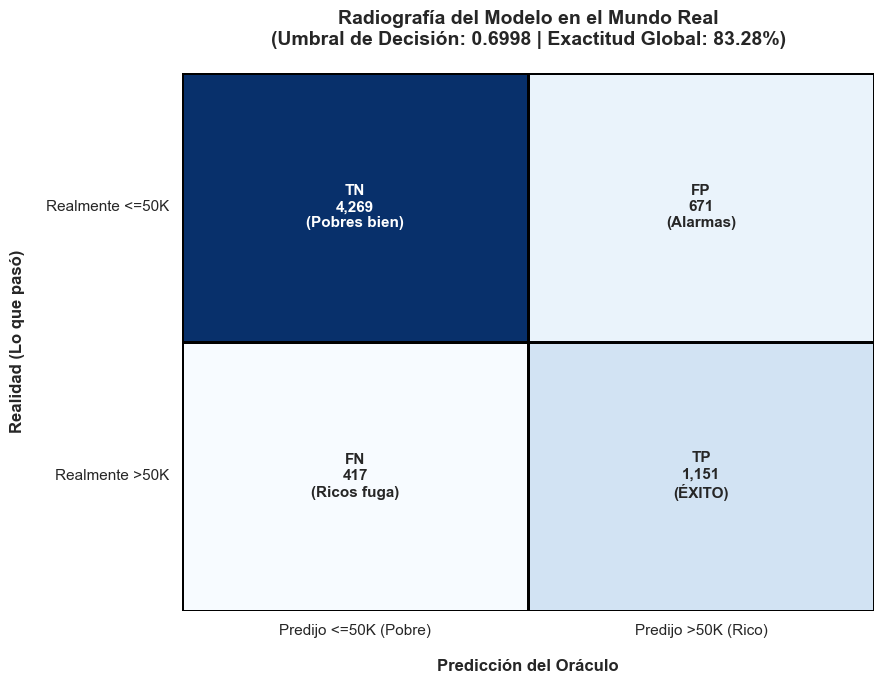

### 📌 Resumen Ejecutivo para Stakeholders

  ✅ ACIERTOS TOTALES: 5,420 registros clasificados correctamente.
  ⚠️ ERRORES TOTALES: 1,088 registros clasificados incorrectamente.

  🎯 F1-Score: 0.6791

  Reporte de Clasificación Final (Listo para Producción):
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      4940
           1       0.63      0.73      0.68      1568

    accuracy                           0.83      6508
   macro avg       0.77      0.80      0.78      6508
weighted avg       0.84      0.83      0.84      6508


⏱️ Análisis completado en 0.257s

📦 [MLOps] Oráculo final, modo de decisión y matriz táctica consolidados correctamente.


In [ ]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import os
import time
import gc
import re
import warnings
import logging
from typing import Tuple, Dict, Any, Optional

import joblib
import optuna
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.metrics import (
    f1_score,
    classification_report,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    balanced_accuracy_score,
)
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.utils.multiclass import type_of_target

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = False  # Cambiar a False en Producción (Docker/Headless)


# ==========================================
# 1. Blindajes Auxiliares del Target y Features
# ==========================================
if 'detectar_naturaleza_target_mlops' not in globals():
    def detectar_naturaleza_target_mlops(y: pd.Series) -> Dict[str, object]:
        """
        [FASE 18-19] Escáner de Naturaleza del Target.
        - Detecta si el problema es binario, multiclase o regresión.
        - Devuelve una ficha técnica estándar para el resto del pipeline.
        """
        serie = pd.Series(y).dropna()

        if serie.empty:
            return {
                'tipo': 'desconocido',
                'es_regresion': False,
                'es_binario': False,
                'es_multiclase': False,
                'num_clases': 0,
            }

        serie_tipada = serie if pd.api.types.is_numeric_dtype(serie) else serie.astype(str)

        try:
            tipo_detectado = type_of_target(serie_tipada)
        except Exception:
            tipo_detectado = 'desconocido'

        es_regresion = tipo_detectado in ('continuous', 'continuous-multioutput')
        num_clases = int(serie.nunique()) if not es_regresion else 0
        es_multiclase = (not es_regresion) and num_clases > 2
        es_binario = (not es_regresion) and num_clases == 2

        if es_regresion:
            tipo = 'regression'
        elif es_multiclase:
            tipo = 'multiclass'
        elif es_binario:
            tipo = 'binary'
        else:
            tipo = 'desconocido'

        return {
            'tipo': tipo,
            'es_regresion': es_regresion,
            'es_binario': es_binario,
            'es_multiclase': es_multiclase,
            'num_clases': num_clases,
        }


if 'resolver_etiquetas_target_mlops' not in globals():
    def resolver_etiquetas_target_mlops(y: pd.Series, manager_ref=None):
        """
        Resuelve etiquetas crudas y nombres humanos del target.
        Si existe un diccionario maestro en artefactos, lo usa.
        """
        serie = pd.Series(y).dropna()
        etiquetas = sorted(serie.unique().tolist())
        nombres = [str(etiqueta) for etiqueta in etiquetas]

        artefactos = getattr(manager_ref, 'artefactos', {}) if manager_ref is not None else {}
        diccionario = artefactos.get('diccionario_target_maestro') if isinstance(artefactos, dict) else None

        if isinstance(diccionario, dict) and diccionario:
            diccionario_inverso = {valor: clave for clave, valor in diccionario.items()}
            if all(etiqueta in diccionario_inverso for etiqueta in etiquetas):
                nombres = [str(diccionario_inverso[etiqueta]) for etiqueta in etiquetas]

        return etiquetas, nombres


if 'predecir_argmax_multiclase_mlops' not in globals():
    def predecir_argmax_multiclase_mlops(modelo, X: pd.DataFrame):
        """
        Ejecuta predicción robusta para problemas multiclase.
        - Si hay predict_proba, usa Argmax.
        - Si no, cae elegantemente en predict().
        """
        if hasattr(modelo, "predict_proba"):
            probabilidades = np.asarray(modelo.predict_proba(X))
            if probabilidades.ndim == 2 and probabilidades.shape[1] > 1:
                clases = np.asarray(getattr(modelo, 'classes_', np.arange(probabilidades.shape[1])))
                predicciones = clases[np.argmax(probabilidades, axis=1)]
                return predicciones, probabilidades

        return np.asarray(modelo.predict(X)), None


if 'alinear_features_oraculo_mlops' not in globals():
    def alinear_features_oraculo_mlops(modelo, X: pd.DataFrame) -> pd.DataFrame:
        """
        Alinea el espacio vectorial del DataFrame contra las features esperadas por el modelo:
        - elimina columnas extra,
        - crea faltantes en cero,
        - respeta el orden exacto de entrenamiento.
        """
        nombres = None

        if hasattr(modelo, 'feature_names_in_'):
            nombres = list(modelo.feature_names_in_)
        elif hasattr(modelo, 'feature_name_'):
            try:
                nombres = list(modelo.feature_name_)
            except Exception:
                nombres = None
        elif hasattr(modelo, 'feature_name'):
            try:
                nombres = list(modelo.feature_name())
            except Exception:
                nombres = None

        if not nombres:
            return X

        X_alineada = X.copy()

        extras = [col for col in X_alineada.columns if col not in nombres]
        if extras:
            X_alineada = X_alineada.drop(columns=extras, errors='ignore')

        faltantes = [col for col in nombres if col not in X_alineada.columns]
        for col in faltantes:
            X_alineada[col] = 0

        return X_alineada[nombres]


if 'calcular_metricas_multiclase_mlops' not in globals():
    def calcular_metricas_multiclase_mlops(y_true, y_pred) -> Dict[str, float]:
        """
        Calcula el paquete ejecutivo de métricas multiclase:
        - F1 macro
        - F1 weighted
        - exactitud
        - balanced accuracy
        - score compuesto 70/30
        """
        macro_f1 = float(f1_score(y_true, y_pred, average='macro'))
        weighted_f1 = float(f1_score(y_true, y_pred, average='weighted'))
        exactitud = float((np.asarray(y_true) == np.asarray(y_pred)).mean())
        balanced_acc = float(balanced_accuracy_score(y_true, y_pred))
        score_compuesto = float((0.7 * macro_f1) + (0.3 * weighted_f1))

        return {
            'macro_f1': macro_f1,
            'weighted_f1': weighted_f1,
            'exactitud': exactitud,
            'balanced_accuracy': balanced_acc,
            'score_compuesto': score_compuesto,
        }


# ==========================================
# 2. FASE 19.4: MATRIZ DE CONFUSIÓN TÁCTICA
# ==========================================
def renderizar_matriz_confusion_mlops(
    modelo_calibrado,
    umbral_oro: Optional[float],
    X_test: pd.DataFrame,
    y_test: pd.Series
):
    """
    [FASE 19 - Paso 19.4] Matriz de Confusión Táctica (UI/UX para Negocio).
    - 🧠 Binario: aplica el Umbral de Oro real.
    - 🎯 Multiclase: usa decisión Argmax sin umbral global operativo.
    - 📊 Entrega una radiografía visual lista para stakeholders.
    """
    logger.info("\n=== 🎯 FASE 19.4: Matriz de Confusión Táctica ===")
    inicio_timer = time.time()

    info_target = detectar_naturaleza_target_mlops(y_test)
    es_multiclase = info_target['es_multiclase']
    manager_ref = globals().get('manager', None)
    etiquetas_target, nombres_target = resolver_etiquetas_target_mlops(y_test, manager_ref=manager_ref)
    X_test_modelo = alinear_features_oraculo_mlops(modelo_calibrado, X_test)

    if es_multiclase:
        logger.info("  🧠 Extrayendo predicciones finales en modo Argmax Multiclase...")
        preds_finales, _ = predecir_argmax_multiclase_mlops(modelo_calibrado, X_test_modelo)
        metricas = calcular_metricas_multiclase_mlops(y_test, preds_finales)
        cm = confusion_matrix(y_test, preds_finales, labels=etiquetas_target)
        tasa_acierto = metricas['exactitud']
        etiquetas = cm.astype(str)

        reporte = classification_report(
            y_test,
            preds_finales,
            labels=etiquetas_target,
            target_names=nombres_target,
            zero_division=0,
        )
    else:
        umbral_operativo = float(umbral_oro) if umbral_oro is not None else 0.50
        logger.info(f"  ⚖️ Extrayendo probabilidades y aplicando Umbral de Oro ({umbral_operativo:.4f})...")
        proba_test = modelo_calibrado.predict_proba(X_test_modelo)[:, 1]
        preds_finales = (proba_test >= umbral_operativo).astype(int)
        f1_actual = float(f1_score(y_test, preds_finales, zero_division=0))
        cm = confusion_matrix(y_test, preds_finales)

        tn, fp, fn, tp = cm.ravel()
        total = np.sum(cm)
        tasa_acierto = (tp + tn) / total if total else 0.0

        etiquetas = np.array([
            [f"TN\n{tn:,}\n(Pobres bien)", f"FP\n{fp:,}\n(Alarmas)"],
            [f"FN\n{fn:,}\n(Ricos fuga)", f"TP\n{tp:,}\n(ÉXITO)"],
        ])

        reporte = classification_report(y_test, preds_finales, zero_division=0)

    logger.info("  🖼️ Procesando Matriz para Presentación a Negocio...")
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=etiquetas,
        fmt="",
        cmap="Blues",
        cbar=False,
        annot_kws={"size": 11, "weight": "bold"},
        linewidths=2,
        linecolor='black',
        ax=ax,
    )

    if es_multiclase:
        ax.set_title(
            f"Radiografía del Modelo Multiclase\n(Modo: Argmax | Exactitud Global: {tasa_acierto:.2%})",
            fontsize=14,
            pad=20,
            fontweight='bold',
        )
        ax.set_xticklabels(nombres_target, fontsize=11, rotation=25, ha='right')
        ax.set_yticklabels(nombres_target, fontsize=11, rotation=0)
    else:
        umbral_operativo = float(umbral_oro) if umbral_oro is not None else 0.50
        ax.set_title(
            f"Radiografía del Modelo en el Mundo Real\n(Umbral de Decisión: {umbral_operativo:.4f} | Exactitud Global: {tasa_acierto:.2%})",
            fontsize=14,
            pad=20,
            fontweight='bold',
        )
        ax.set_xticklabels(['Predijo <=50K (Pobre)', 'Predijo >50K (Rico)'], fontsize=11)
        ax.set_yticklabels(['Realmente <=50K', 'Realmente >50K'], fontsize=11, rotation=0)

    ax.set_xlabel('Predicción del Oráculo', fontsize=12, fontweight='bold', labelpad=15)
    ax.set_ylabel('Realidad (Lo que pasó)', fontsize=12, fontweight='bold', labelpad=15)
    plt.tight_layout()

    if MODO_VISUAL:
        plt.show()
        display(Markdown("### 📌 Resumen Ejecutivo para Stakeholders"))
    else:
        plt.close(fig)
        logger.info("\n### 📌 Resumen Ejecutivo para Stakeholders")

    aciertos = int(np.trace(cm))
    errores = int(np.sum(cm) - aciertos)

    logger.info(f"  ✅ ACIERTOS TOTALES: {aciertos:,} registros clasificados correctamente.")
    logger.warning(f"  ⚠️ ERRORES TOTALES: {errores:,} registros clasificados incorrectamente.")

    if es_multiclase:
        logger.info("  🔒 MODO ACTIVO: multiclass_argmax. No existe un umbral global operativo.")
        logger.info(
            "  Exactitud = "
            f"{metricas['exactitud']:.4f} | F1 weighted = {metricas['weighted_f1']:.4f} | "
            f"F1 macro = {metricas['macro_f1']:.4f} | Balanced Accuracy = {metricas['balanced_accuracy']:.4f}"
        )
    else:
        logger.info(f"\n  🎯 F1-Score: {f1_actual:.4f}")

    logger.info("\n  Reporte de Clasificación Final (Listo para Producción):\n" + reporte)
    logger.info(f"\n⏱️ Análisis completado en {time.time() - inicio_timer:.3f}s")

    return cm, tasa_acierto


# ==========================================
# 3. FASE 18.3: FORJA DEL ORÁCULO (OPTUNA + CV)
# ==========================================
def forjar_oraculo_lightgbm(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: Optional[pd.DataFrame] = None,
    y_test: Optional[pd.Series] = None,
    rutas: Optional[Dict] = None,
    pesos_train: Optional[pd.Series] = None,
    grupos_cv: Optional[pd.Series] = None,
    n_trials: int = 40,
    n_splits: int = 5,
    seed_estatica: int = 42,
    directorio_salida: str = "mlops_activos",
    modo_silencioso: bool = False
) -> Tuple[Optional[lgb.LGBMClassifier], Optional[float], Dict[str, Any]]:
    """
    [FASE 18 - Paso 18.3] Forja del Oráculo con Optuna + CV.
    - 🧬 Binario: mantiene threshold tuning real.
    - 🎯 Multiclase: usa score compuesto 70/30 y decisión final por Argmax.
    - 🔪 Extirpa columnas sospechosas de Target Leakage.
    - 💾 Guarda el campeón en la Caja Fuerte MLOps.
    """
    if X_train is None or X_train.empty:
        logger.error("🛑 Error Crítico: La matriz está vacía.")
        raise ValueError("La matriz está vacía.")

    X_tr_copy = X_train.copy()
    X_te_copy = X_test.copy() if X_test is not None else None

    patron_troya = re.compile(r'(^cf_|^gbdt_|_prob_|^prob_)', re.IGNORECASE)
    cols_trampa = [col for col in X_tr_copy.columns if patron_troya.search(col)]

    if cols_trampa:
        if not modo_silencioso:
            logger.warning(f"  🔪 [CIRUGÍA] Extirpando {len(cols_trampa)} variables con Target Leakage...")
        X_tr_copy.drop(columns=cols_trampa, inplace=True)
        if X_te_copy is not None:
            X_te_copy.drop(columns=[c for c in cols_trampa if c in X_te_copy.columns], inplace=True)

    if not modo_silencioso:
        logger.info(f"=== 🧬 FASE 18.3: Evolución del Oráculo (Optuna - {n_trials} Mutaciones) ===")

    rutas = rutas or {}
    warnings.filterwarnings("ignore")

    info_target = detectar_naturaleza_target_mlops(y_train)
    num_clases = info_target['num_clases']
    es_multiclase = info_target['es_multiclase']
    cat_features = [c for c in rutas.get('cat_vars', []) if c in X_tr_copy.columns]
    config_bagging = rutas.get('asymmetric_bagging', {}).copy()
    clase_minoritaria = y_train.value_counts().idxmin() if not es_multiclase else None

    pesos_train_norm = None
    if pesos_train is not None:
        if isinstance(pesos_train, pd.Series):
            pesos_train_norm = pesos_train.reset_index(drop=True)
        else:
            pesos_train_norm = pd.Series(np.asarray(pesos_train).reshape(-1))

    estrategias_pesos_multiclase = ['base']
    if es_multiclase:
        if config_bagging and 'class_weight' in config_bagging:
            estrategias_pesos_multiclase.append('class_weight')
        if pesos_train_norm is not None:
            estrategias_pesos_multiclase.append('sample_weight')

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        param = {
            'objective': 'multiclass' if es_multiclase else 'binary',
            'metric': 'multi_logloss' if es_multiclase else 'binary_logloss',
            'random_state': seed_estatica,
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'n_estimators': 800,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 120),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        }

        estrategia_pesos_multiclase = 'base'

        if es_multiclase:
            param['num_class'] = num_clases
            param['subsample'] = trial.suggest_float('subsample', 0.5, 1.0)
            estrategia_pesos_multiclase = trial.suggest_categorical(
                'estrategia_pesos_multiclase',
                estrategias_pesos_multiclase,
            )
            if estrategia_pesos_multiclase == 'class_weight' and config_bagging and 'class_weight' in config_bagging:
                param['class_weight'] = config_bagging['class_weight']
        else:
            if config_bagging:
                if clase_minoritaria == 1:
                    param['pos_bagging_fraction'] = 1.0
                    param['neg_bagging_fraction'] = trial.suggest_float('neg_bagging_fraction', 0.01, 1.0)
                else:
                    param['pos_bagging_fraction'] = trial.suggest_float('pos_bagging_fraction', 0.01, 1.0)
                    param['neg_bagging_fraction'] = 1.0

                param['bagging_freq'] = trial.suggest_int('bagging_freq', 1, 7)
            else:
                param['subsample'] = trial.suggest_float('subsample', 0.5, 1.0)

        cv = GroupKFold(n_splits=n_splits) if grupos_cv is not None else StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed_estatica,
        )

        splits = (
            list(cv.split(X_tr_copy, y_train, groups=grupos_cv))
            if grupos_cv is not None
            else list(cv.split(X_tr_copy, y_train))
        )

        metricas_fold = []

        for train_idx, val_idx in splits:
            X_tr_fold = X_tr_copy.iloc[train_idx]
            y_tr_fold = y_train.iloc[train_idx]
            X_va_fold = X_tr_copy.iloc[val_idx]
            y_va_fold = y_train.iloc[val_idx]

            w_tr = None
            if pesos_train_norm is not None and (not es_multiclase or estrategia_pesos_multiclase == 'sample_weight'):
                w_tr = pesos_train_norm.iloc[train_idx].to_numpy()

            modelo = lgb.LGBMClassifier(**param)
            modelo.fit(
                X_tr_fold,
                y_tr_fold,
                sample_weight=w_tr,
                eval_set=[(X_va_fold, y_va_fold)],
                callbacks=[lgb.early_stopping(30, verbose=False)],
                categorical_feature=cat_features if cat_features else 'auto',
            )

            if es_multiclase:
                preds_fold = modelo.predict(X_va_fold)
                metricas_multiclase = calcular_metricas_multiclase_mlops(y_va_fold, preds_fold)
                score = metricas_multiclase['score_compuesto']
            else:
                score = float(average_precision_score(y_va_fold, modelo.predict_proba(X_va_fold)[:, 1]))

            metricas_fold.append(score)

            del X_tr_fold, y_tr_fold, X_va_fold, y_va_fold, modelo
            gc.collect()

        return float(np.mean(metricas_fold))

    if not modo_silencioso:
        logger.info(f"  ⚙️ Iniciando simulaciones bayesianas ({n_trials * n_splits} entrenamientos totales)...")

    sampler_determinista = optuna.samplers.TPESampler(seed=seed_estatica)
    estudio = optuna.create_study(
        direction='maximize',
        study_name="Oraculo_LGBM_CV",
        sampler=sampler_determinista,
    )
    estudio.optimize(objective, n_trials=n_trials, n_jobs=1, callbacks=[lambda s, t: gc.collect()])

    mejores_params = estudio.best_params
    parametros_finales = mejores_params.copy()
    estrategia_pesos_multiclase_optima = 'base'

    if es_multiclase:
        estrategia_pesos_multiclase_optima = parametros_finales.pop('estrategia_pesos_multiclase', 'base')

    parametros_finales.update({
        'n_estimators': 500,
        'random_state': seed_estatica,
        'verbosity': -1,
        'n_jobs': -1,
    })

    if es_multiclase:
        parametros_finales['num_class'] = num_clases
        if estrategia_pesos_multiclase_optima == 'class_weight' and config_bagging and 'class_weight' in config_bagging:
            parametros_finales['class_weight'] = config_bagging['class_weight']
    else:
        if config_bagging:
            for k in ['subsample', 'class_weight', 'scale_pos_weight']:
                parametros_finales.pop(k, None)

    oraculo_final = lgb.LGBMClassifier(**parametros_finales)

    pesos_finales = (
        pesos_train_norm.to_numpy()
        if (pesos_train_norm is not None and (not es_multiclase or estrategia_pesos_multiclase_optima == 'sample_weight'))
        else None
    )

    oraculo_final.fit(
        X_tr_copy,
        y_train,
        sample_weight=pesos_finales,
        categorical_feature=cat_features if cat_features else 'auto',
    )

    umbral_final = None
    if not es_multiclase:
        probas_train = oraculo_final.predict_proba(X_tr_copy)[:, 1]
        precision, recall, thresholds = precision_recall_curve(y_train, probas_train)

        if len(thresholds) > 0:
            fscore = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
            ix = int(np.argmax(fscore))
            umbral_final = float(thresholds[ix])
        else:
            umbral_final = 0.50

    modo_decision_optimo = 'multiclass_argmax' if es_multiclase else 'binary_threshold'

    if not modo_silencioso:
        if es_multiclase:
            logger.info("  🧠 Estrategia Óptima de Entrenamiento: Argmax Multiclase (sin umbral global).")
            logger.info(f"  ⚖️ Estrategia Óptima de Pesos Multiclase: {estrategia_pesos_multiclase_optima}")
        else:
            logger.info(f"  🏆 Umbral Óptimo de Entrenamiento: {umbral_final:.4f}")

    if not os.path.exists(directorio_salida):
        os.makedirs(directorio_salida)

    ruta_modelo = os.path.join(directorio_salida, "oraculo_lightgbm.pkl")
    joblib.dump(oraculo_final, ruta_modelo)

    rutas['umbral_decision_optimo'] = float(umbral_final) if umbral_final is not None else None
    rutas['modo_decision_optimo'] = modo_decision_optimo

    if es_multiclase:
        rutas['estrategia_pesos_multiclase_optima'] = estrategia_pesos_multiclase_optima

    if not modo_silencioso:
        logger.info(f"  💾 Oráculo guardado en Caja Fuerte MLOps: {ruta_modelo}")

    del estudio
    gc.collect()

    return oraculo_final, (float(umbral_final) if umbral_final is not None else None), mejores_params


# ==========================================
# 4. Celda Maestra de Ejecución del Bloque 18.3
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError as exc:
        raise EnvironmentError("El PipelineManager no está inicializado.") from exc

    if not hasattr(manager, 'X_train') or manager.X_train is None or getattr(manager, 'y_train', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_train' o 'y_train'.")

    if getattr(manager, 'X_test', None) is None or getattr(manager, 'y_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices 'X_test' o 'y_test'.")

    # 🎛️ Punto de Control del Arquitecto
    SEMILLA_MANUAL = 87499  # Reemplazar por la semilla que quieras fijar manualmente

    logger.info(f">>> 🧠 DESATANDO OPTUNA CON VALIDACIÓN CRUZADA (SEMILLA MANUAL: {SEMILLA_MANUAL}) <<<")
    logger.info("-" * 80)

    # ==========================================
    # 4.1 Forja del Campeón
    # ==========================================
    modelo_campeon, umbral_entrenamiento, adn_campeon = forjar_oraculo_lightgbm(
        X_train=manager.X_train,
        y_train=manager.y_train,
        X_test=manager.X_test,
        y_test=manager.y_test,
        rutas=getattr(manager, 'rutas', {}),
        pesos_train=getattr(manager, 'pesos_train', None),
        grupos_cv=getattr(manager, 'grupos_cv', None),
        n_trials=40,
        n_splits=5,
        seed_estatica=SEMILLA_MANUAL,
        modo_silencioso=False,
    )

    # ==========================================
    # 4.2 Blindaje de Artefactos y Modelos
    # ==========================================
    if not hasattr(manager, 'modelos_preprocesamiento') or manager.modelos_preprocesamiento is None:
        manager.modelos_preprocesamiento = {}

    manager.modelos_preprocesamiento['oraculo_lightgbm'] = modelo_campeon

    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('oraculo_lightgbm', modelo_campeon)

    if not hasattr(manager, 'artefactos') or manager.artefactos is None:
        manager.artefactos = {}

    info_target_final = detectar_naturaleza_target_mlops(manager.y_test)
    manager.artefactos['umbral_decision'] = umbral_entrenamiento
    manager.artefactos['modo_decision'] = (
        'multiclass_argmax' if info_target_final['es_multiclase'] else 'binary_threshold'
    )

    if umbral_entrenamiento is None:
        logger.info("  💾 Artefacto Guardado: 'umbral_decision' = None (modo multiclass_argmax)")
    else:
        logger.info(f"  💾 Artefacto Guardado: 'umbral_decision' = {umbral_entrenamiento:.4f}")

    logger.info("-" * 80)

    # ==========================================
    # 4.3 Radiografía Final del Modelo
    # ==========================================
    matriz_final, exactitud_final = renderizar_matriz_confusion_mlops(
        modelo_calibrado=modelo_campeon,
        umbral_oro=umbral_entrenamiento,
        X_test=manager.X_test,
        y_test=manager.y_test,
    )

    logger.info("\n📦 [MLOps] Oráculo final, modo de decisión y matriz táctica consolidados correctamente.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error Crítico en la forja del modelo: {e}")

>>> 🧠 INICIANDO DIAGNÓSTICO DE CERTEZA <<<
--------------------------------------------------------------------------------
=== 🩺 FASE 19.1: Diagnóstico de Certeza Matemática (Reliability) ===
  🔎 Extrayendo logits y probabilidades del Oráculo...


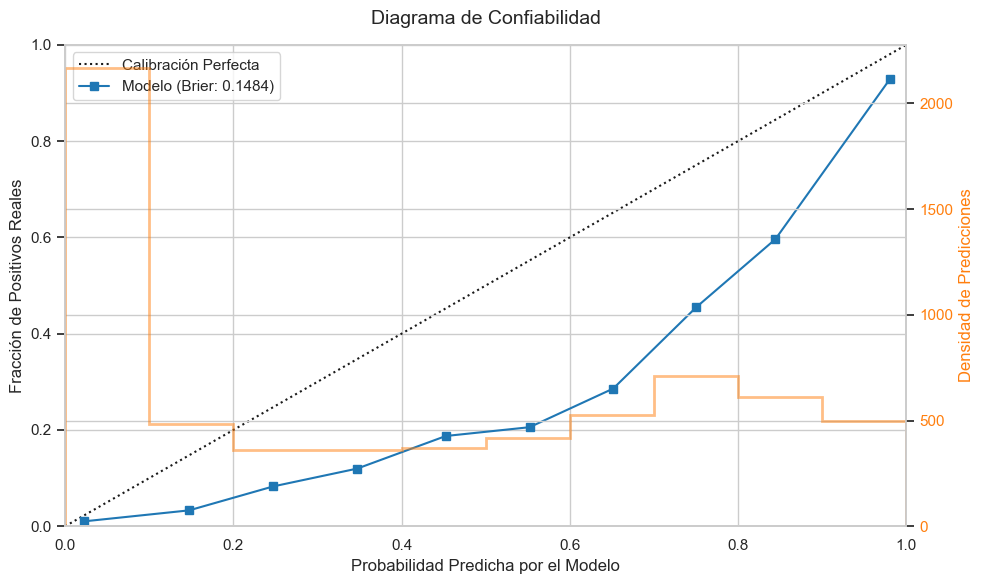

### 📊 Resultado del Diagnóstico MLOps

  • Brier Score: 0.1484
  🟡 Diagnóstico: Ligera descalibración detectada. Sugerido: Platt Scaling.

⏱️ Diagnóstico completado en 0.271s
  💾 Telemetría guardada: brier_score_pre_calibracion = 0.1484
📦 [MLOps] Diagnóstico de certeza consolidado correctamente en el PipelineManager.


In [ ]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import logging
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.utils.multiclass import type_of_target

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🛡️ Bandera de Entorno MLOps
MODO_VISUAL = False  # Cambiar a False en Producción (Docker / Headless)


# ==========================================
# 1. Blindajes Auxiliares del Espacio Vectorial
# ==========================================
if 'alinear_features_oraculo_mlops' not in globals():
    def alinear_features_oraculo_mlops(modelo, X: pd.DataFrame) -> pd.DataFrame:
        """
        [FASE 19 - Blindaje de Compatibilidad]
        - Alinea las features del request contra las features esperadas por el modelo.
        - Elimina columnas extra.
        - Crea columnas faltantes en cero.
        - Respeta el orden exacto del entrenamiento.
        """
        nombres = None

        if hasattr(modelo, 'feature_names_in_'):
            nombres = list(modelo.feature_names_in_)
        elif hasattr(modelo, 'feature_name_'):
            try:
                nombres = list(modelo.feature_name_)
            except Exception:
                nombres = None
        elif hasattr(modelo, 'feature_name'):
            try:
                nombres = list(modelo.feature_name())
            except Exception:
                nombres = None

        if not nombres:
            return X

        X_alineada = X.copy()

        extras = [col for col in X_alineada.columns if col not in nombres]
        if extras:
            X_alineada = X_alineada.drop(columns=extras, errors='ignore')

        faltantes = [col for col in nombres if col not in X_alineada.columns]
        for col in faltantes:
            X_alineada[col] = 0

        return X_alineada[nombres]


# ==========================================
# 2. FASE 19.1: DIAGNÓSTICO DE CERTEZA MATEMÁTICA
# ==========================================
def evaluar_certeza_oraculo(
    modelo,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    n_bins: int = 10
):
    """
    [FASE 7 - Paso 19.1] Diagnóstico de Certeza Matemática (Reliability).
    - 🔍 Inspecciona la honestidad probabilística del Oráculo.
    - 🎯 En binario usa Brier Score.
    - 🧠 En multiclase usa Log Loss + curvas OVR.
    - 📊 Genera una radiografía visual del nivel de confianza del modelo.
    """
    logger.info("=== 🩺 FASE 19.1: Diagnóstico de Certeza Matemática (Reliability) ===")
    inicio_timer = time.time()

    if not hasattr(modelo, "predict_proba"):
        logger.error("🛑 Error Crítico: El modelo no soporta 'predict_proba'.")
        raise ValueError("El modelo no soporta 'predict_proba'.")

    serie_target = pd.Series(y_test).dropna()
    tipo_target = type_of_target(
        serie_target if pd.api.types.is_numeric_dtype(serie_target) else serie_target.astype(str)
    )
    es_multiclase = tipo_target == 'multiclass'

    logger.info("  🔎 Extrayendo logits y probabilidades del Oráculo...")
    X_test_modelo = alinear_features_oraculo_mlops(modelo, X_test)
    probabilidades = modelo.predict_proba(X_test_modelo)

    # ==========================================
    # 2A. MODO MULTICLASE
    # ==========================================
    if es_multiclase:
        clases = list(getattr(modelo, 'classes_', np.sort(serie_target.unique())))
        score_logloss = float(log_loss(y_test, probabilidades, labels=clases))

        manager_ref = globals().get('manager', None)
        etiquetas_target, nombres_target = resolver_etiquetas_target_mlops(y_test, manager_ref=manager_ref)
        mapa_nombres = {etiqueta: str(nombre) for etiqueta, nombre in zip(etiquetas_target, nombres_target)}
        nombres_clases = [mapa_nombres.get(clase, str(clase)) for clase in clases]

        if MODO_VISUAL:
            sns.set_theme(style="whitegrid")
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.plot([0, 1], [0, 1], "k:", linewidth=2, label="Calibración Perfecta")

            paleta = sns.color_palette("tab10", n_colors=max(len(clases), 3))
            y_array = pd.Series(y_test).to_numpy()

            for idx, (clase, nombre, color) in enumerate(zip(clases, nombres_clases, paleta)):
                y_binario = (y_array == clase).astype(int)
                if y_binario.sum() == 0:
                    continue

                fraccion_positivos, valor_medio_predicho = calibration_curve(
                    y_binario,
                    probabilidades[:, idx],
                    n_bins=n_bins,
                    strategy='uniform'
                )

                ax.plot(
                    valor_medio_predicho,
                    fraccion_positivos,
                    "o-",
                    color=color,
                    linewidth=2.5,
                    label=f"{nombre} (OVR)"
                )

            ax.set_title(
                f"Radiografía Base del Oráculo Multiclase (Sin Calibrar)\n(Log Loss: {score_logloss:.4f})",
                fontsize=14,
                pad=15
            )
            ax.set_xlabel("Probabilidad Media Predicha", fontsize=12)
            ax.set_ylabel("Frecuencia Real Observada", fontsize=12)
            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.0])
            ax.legend(loc="lower right", fontsize=9)
            plt.tight_layout()
            plt.show()
            display(Markdown("### 🧠 Radiografía Base del Oráculo Multiclase"))
        else:
            logger.info(f"  📴 [HEADLESS] Log Loss multiclase calculado: {score_logloss:.4f}. Gráficos omitidos.")
            logger.info("### 🧠 Radiografía Base del Oráculo Multiclase")

        logger.info(f"  • Log Loss Multiclase: {score_logloss:.4f}")
        logger.info(f"  • Confianza Máxima Media: {np.mean(np.max(probabilidades, axis=1)):.4f}")
        logger.info(f"\n⏱️ Diagnóstico completado en {time.time() - inicio_timer:.3f}s")

        return score_logloss

    # ==========================================
    # 2B. MODO BINARIO
    # ==========================================
    probabilidades = probabilidades[:, 1]
    brier_score = brier_score_loss(y_test, probabilidades)
    fraccion_positivos, valor_medio_predicho = calibration_curve(
        y_test,
        probabilidades,
        n_bins=n_bins,
        strategy='uniform'
    )

    if MODO_VISUAL:
        sns.set_theme(style="whitegrid")
        fig, ax1 = plt.subplots(figsize=(10, 6))

        ax1.plot([0, 1], [0, 1], "k:", label="Calibración Perfecta")
        ax1.plot(
            valor_medio_predicho,
            fraccion_positivos,
            "s-",
            color="#1f77b4",
            label=f"Modelo (Brier: {brier_score:.4f})"
        )
        ax1.set_ylabel("Fracción de Positivos Reales", fontsize=12)
        ax1.set_xlabel("Probabilidad Predicha por el Modelo", fontsize=12)
        ax1.set_title("Diagrama de Confiabilidad", fontsize=14, pad=15)
        ax1.set_xlim([0.0, 1.0])
        ax1.set_ylim([0.0, 1.0])
        ax1.legend(loc="upper left")

        ax2 = ax1.twinx()
        ax2.hist(
            probabilidades,
            range=(0, 1),
            bins=n_bins,
            histtype="step",
            lw=2,
            color="#ff7f0e",
            alpha=0.5
        )
        ax2.set_ylabel("Densidad de Predicciones", color="#ff7f0e", fontsize=12)
        ax2.tick_params(axis='y', labelcolor="#ff7f0e")

        plt.tight_layout()
        plt.show()
        display(Markdown("### 📊 Resultado del Diagnóstico MLOps"))
    else:
        logger.info(f"  📴 [HEADLESS] Brier Score calculado: {brier_score:.4f}. Gráficos omitidos.")
        logger.info("### 📊 Resultado del Diagnóstico MLOps")

    logger.info(f"  • Brier Score: {brier_score:.4f}")

    if brier_score < 0.10:
        logger.info("  🟢 Diagnóstico: El modelo es extremadamente honesto.")
    elif brier_score < 0.20:
        logger.warning("  🟡 Diagnóstico: Ligera descalibración detectada. Sugerido: Platt Scaling.")
    else:
        logger.warning("  🔴 Diagnóstico: Modelo sobreconfiado o mentiroso. Calibración obligatoria.")

    logger.info(f"\n⏱️ Diagnóstico completado en {time.time() - inicio_timer:.3f}s")

    return brier_score


# ==========================================
# 3. Celda de Ejecución Maestra
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError as exc:
        raise EnvironmentError("El PipelineManager no está inicializado. Ejecuta las fases previas.") from exc

    if getattr(manager, 'modelos_preprocesamiento', None) is None or 'oraculo_lightgbm' not in manager.modelos_preprocesamiento:
        raise ValueError(
            "El modelo 'oraculo_lightgbm' no existe en la caja fuerte del Manager. Ejecuta la Fase 18.3."
        )

    if getattr(manager, 'X_test', None) is None or getattr(manager, 'y_test', None) is None:
        raise ValueError(
            "El Manager no tiene cargadas las matrices de Test ('X_test' o 'y_test')."
        )

    modelo_campeon = manager.modelos_preprocesamiento['oraculo_lightgbm']

    logger.info(">>> 🧠 INICIANDO DIAGNÓSTICO DE CERTEZA <<<")
    logger.info("-" * 80)

    score_brier_actual = evaluar_certeza_oraculo(
        modelo=modelo_campeon,
        X_test=manager.X_test,
        y_test=manager.y_test,
        n_bins=10
    )

    # ==========================================
    # 3.1 Blindaje de Telemetría MLOps
    # ==========================================
    if score_brier_actual is not None:
        info_target_final = type_of_target(pd.Series(manager.y_test).dropna())
        nombre_artefacto = (
            'log_loss_pre_calibracion'
            if info_target_final == 'multiclass'
            else 'brier_score_pre_calibracion'
        )

        if hasattr(manager, 'guardar_artefacto'):
            manager.guardar_artefacto(nombre_artefacto, score_brier_actual)
        else:
            if not hasattr(manager, 'artefactos'):
                manager.artefactos = {}
            manager.artefactos[nombre_artefacto] = score_brier_actual

        logger.info(f"  💾 Telemetría guardada: {nombre_artefacto} = {score_brier_actual:.4f}")
        logger.info("📦 [MLOps] Diagnóstico de certeza consolidado correctamente en el PipelineManager.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Diagnóstico Post-hoc: {e}")

In [ ]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetria
# ==========================================
import logging
import time
import gc
import inspect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, f1_score, classification_report, accuracy_score, log_loss, balanced_accuracy_score
from sklearn.utils.multiclass import type_of_target
from IPython.display import display, Markdown

logger = logging.getLogger("MLOps_Pipeline")
MODO_VISUAL = True

if 'detectar_naturaleza_target_mlops' not in globals():
    def detectar_naturaleza_target_mlops(y: pd.Series) -> dict:
        serie = pd.Series(y).dropna()
        if serie.empty:
            return {'tipo': 'desconocido', 'es_regresion': False, 'es_binario': False, 'es_multiclase': False, 'num_clases': 0}
        serie_tipada = serie if pd.api.types.is_numeric_dtype(serie) else serie.astype(str)
        try:
            tipo_detectado = type_of_target(serie_tipada)
        except Exception:
            tipo_detectado = 'desconocido'
        es_regresion = tipo_detectado in ('continuous', 'continuous-multioutput')
        num_clases = int(serie.nunique()) if not es_regresion else 0
        es_multiclase = (not es_regresion) and num_clases > 2
        es_binario = (not es_regresion) and num_clases == 2
        if es_regresion:
            tipo = 'regression'
        elif es_multiclase:
            tipo = 'multiclass'
        elif es_binario:
            tipo = 'binary'
        else:
            tipo = 'desconocido'
        return {'tipo': tipo, 'es_regresion': es_regresion, 'es_binario': es_binario, 'es_multiclase': es_multiclase, 'num_clases': num_clases}

if 'resolver_etiquetas_target_mlops' not in globals():
    def resolver_etiquetas_target_mlops(y: pd.Series, manager_ref=None):
        serie = pd.Series(y).dropna()
        etiquetas = sorted(serie.unique().tolist())
        nombres = [str(etiqueta) for etiqueta in etiquetas]
        artefactos = getattr(manager_ref, 'artefactos', {}) if manager_ref is not None else {}
        diccionario = artefactos.get('diccionario_target_maestro') if isinstance(artefactos, dict) else None
        if isinstance(diccionario, dict) and diccionario:
            diccionario_inverso = {valor: clave for clave, valor in diccionario.items()}
            if all(etiqueta in diccionario_inverso for etiqueta in etiquetas):
                nombres = [str(diccionario_inverso[etiqueta]) for etiqueta in etiquetas]
        return etiquetas, nombres

if 'predecir_argmax_multiclase_mlops' not in globals():
    def predecir_argmax_multiclase_mlops(modelo, X: pd.DataFrame):
        if hasattr(modelo, "predict_proba"):
            probabilidades = np.asarray(modelo.predict_proba(X))
            if probabilidades.ndim == 2 and probabilidades.shape[1] > 1:
                clases = np.asarray(getattr(modelo, 'classes_', np.arange(probabilidades.shape[1])))
                predicciones = clases[np.argmax(probabilidades, axis=1)]
                return predicciones, probabilidades
        return np.asarray(modelo.predict(X)), None

if 'alinear_features_oraculo_mlops' not in globals():
    def alinear_features_oraculo_mlops(modelo, X: pd.DataFrame) -> pd.DataFrame:
        nombres = None
        if hasattr(modelo, 'feature_names_in_'):
            nombres = list(modelo.feature_names_in_)
        elif hasattr(modelo, 'feature_name_'):
            try:
                nombres = list(modelo.feature_name_)
            except Exception:
                nombres = None
        elif hasattr(modelo, 'feature_name'):
            try:
                nombres = list(modelo.feature_name())
            except Exception:
                nombres = None
        if not nombres:
            return X
        X_alineada = X.copy()
        extras = [col for col in X_alineada.columns if col not in nombres]
        if extras:
            X_alineada = X_alineada.drop(columns=extras, errors='ignore')
        faltantes = [col for col in nombres if col not in X_alineada.columns]
        for col in faltantes:
            X_alineada[col] = 0
        return X_alineada[nombres]

if 'calcular_metricas_multiclase_mlops' not in globals():
    def calcular_metricas_multiclase_mlops(y_true, y_pred) -> dict:
        macro_f1 = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
        weighted_f1 = float(f1_score(y_true, y_pred, average='weighted', zero_division=0))
        exactitud = float(accuracy_score(y_true, y_pred))
        balanced_acc = float(balanced_accuracy_score(y_true, y_pred))
        score_compuesto = float((0.7 * macro_f1) + (0.3 * weighted_f1))
        return {'macro_f1': macro_f1, 'weighted_f1': weighted_f1, 'exactitud': exactitud, 'balanced_accuracy': balanced_acc, 'score_compuesto': score_compuesto}

def graficar_calibracion_binaria_mlops(proba_antes, proba_despues, y_true):
    plt.close('all')
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 6))
    fraccion_antes, media_antes = calibration_curve(y_true, proba_antes, n_bins=10, strategy='uniform')
    fraccion_despues, media_despues = calibration_curve(y_true, proba_despues, n_bins=10, strategy='uniform')

    ax.plot([0, 1], [0, 1], 'k:', linewidth=2, label='Calibracion ideal')
    ax.plot(media_antes, fraccion_antes, 'o--', color='#C44E52', linewidth=2, label='Antes')
    ax.plot(media_despues, fraccion_despues, 'o-', color='#4C72B0', linewidth=3, label='Despues')
    ax.set_title("Radiografia de Calibracion Binaria", fontsize=13, pad=15, fontweight='bold')
    ax.set_xlabel("Probabilidad Media Predicha", fontsize=11)
    ax.set_ylabel("Frecuencia Real", fontsize=11)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.legend(loc='upper left', fontsize=10)

    plt.tight_layout()
    return fig

def graficar_calibracion_multiclase_mlops(
    proba_antes,
    proba_despues,
    y_true,
    etiquetas_clase,
    nombres_clase,
    logloss_antes=None,
    logloss_despues=None
):
    plt.close('all')
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10.5, 6))
    ax.plot([0, 1], [0, 1], 'k:', linewidth=2, label='Calibracion ideal')
    paleta = sns.color_palette("tab10", n_colors=max(len(etiquetas_clase), 3))
    y_array = pd.Series(y_true).to_numpy()

    for idx, (etiqueta, nombre, color) in enumerate(zip(etiquetas_clase, nombres_clase, paleta)):
        y_binario = (y_array == etiqueta).astype(int)
        if y_binario.sum() == 0:
            continue
        fraccion_antes, media_antes = calibration_curve(y_binario, proba_antes[:, idx], n_bins=8, strategy='uniform')
        fraccion_despues, media_despues = calibration_curve(y_binario, proba_despues[:, idx], n_bins=8, strategy='uniform')
        ax.plot(
            media_antes,
            fraccion_antes,
            'o--',
            color=color,
            alpha=0.35,
            linewidth=1.8,
            markersize=5,
            label=f'{nombre} PRE'
        )
        ax.plot(
            media_despues,
            fraccion_despues,
            'o-',
            color=color,
            linewidth=2.8,
            markersize=6,
            label=f'{nombre} POST'
        )

        pares = min(len(media_antes), len(media_despues))
        for j in range(pares):
            ax.annotate(
                '',
                xy=(media_despues[j], fraccion_despues[j]),
                xytext=(media_antes[j], fraccion_antes[j]),
                arrowprops=dict(
                    arrowstyle='->',
                    color=color,
                    lw=1.4,
                    alpha=0.45,
                    shrinkA=3,
                    shrinkB=3
                )
            )

    titulo = "Radiografia Calibrada Multiclase (Desplazamiento PRE -> POST)"
    if logloss_antes is not None and logloss_despues is not None:
        delta = float(logloss_despues - logloss_antes)
        titulo += f"\n(Log Loss: {logloss_antes:.4f} -> {logloss_despues:.4f} | Cambio: {delta:+.4f})"
    ax.set_title(titulo, fontsize=13, pad=15, fontweight='bold')
    ax.set_xlabel("Probabilidad Media Predicha", fontsize=11)
    ax.set_ylabel("Frecuencia Real OVR", fontsize=11)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    return fig

# ==========================================
# FASE 19.2: CALIBRACION ISOTONICA / PLATT
# ==========================================
def calibrar_oraculo_mlops(
    modelo_base,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    cv: int = 5
):
    logger.info("\n" + "="*50)
    logger.info("=== FASE 19.2: Calibracion Matematica ===")
    logger.info("="*50)
    inicio_timer = time.time()
    info_target = detectar_naturaleza_target_mlops(y_test)
    es_multiclase = info_target['es_multiclase']
    X_train_modelo = alinear_features_oraculo_mlops(modelo_base, X_train)
    X_test_modelo = alinear_features_oraculo_mlops(modelo_base, X_test)
    metodo = 'sigmoid' if es_multiclase else 'isotonic'
    modelo_calibrado = CalibratedClassifierCV(modelo_base, method=metodo, cv=cv)
    modelo_calibrado.fit(X_train_modelo, y_train)
    proba_antes = modelo_base.predict_proba(X_test_modelo)
    proba_despues = modelo_calibrado.predict_proba(X_test_modelo)
    if es_multiclase:
        logloss_antes = float(log_loss(y_test, proba_antes, labels=getattr(modelo_base, 'classes_', None)))
        logloss_despues = float(log_loss(y_test, proba_despues, labels=getattr(modelo_calibrado, 'classes_', None)))
        if MODO_VISUAL:
            manager_ref = globals().get('manager', None)
            etiquetas_visuales, nombres_visuales = resolver_etiquetas_target_mlops(y_test, manager_ref=manager_ref)
            etiquetas_modelo = list(getattr(modelo_calibrado, 'classes_', getattr(modelo_base, 'classes_', etiquetas_visuales)))
            mapa_nombres = {etiqueta: str(nombre) for etiqueta, nombre in zip(etiquetas_visuales, nombres_visuales)}
            nombres_modelo = [mapa_nombres.get(etiqueta, str(etiqueta)) for etiqueta in etiquetas_modelo]
            parametros_grafico = inspect.signature(graficar_calibracion_multiclase_mlops).parameters
            if 'logloss_antes' in parametros_grafico and 'logloss_despues' in parametros_grafico:
                fig_cal = graficar_calibracion_multiclase_mlops(
                    proba_antes,
                    proba_despues,
                    y_test,
                    etiquetas_modelo,
                    nombres_modelo,
                    logloss_antes=logloss_antes,
                    logloss_despues=logloss_despues
                )
            else:
                fig_cal = graficar_calibracion_multiclase_mlops(
                    proba_antes,
                    proba_despues,
                    y_test,
                    etiquetas_modelo,
                    nombres_modelo
                )
            plt.show()
            display(Markdown("### Radiografia Calibrada Multiclase"))
            plt.close(fig_cal)
        logger.info(f"  - Log Loss PRE-Calibracion:  {logloss_antes:.4f}")
        logger.info(f"  - Log Loss POST-Calibracion: {logloss_despues:.4f}")
    else:
        brier_antes = brier_score_loss(y_test, proba_antes[:, 1])
        brier_despues = brier_score_loss(y_test, proba_despues[:, 1])
        if MODO_VISUAL:
            fig_cal = graficar_calibracion_binaria_mlops(proba_antes[:, 1], proba_despues[:, 1], y_test)
            plt.show()
            display(Markdown("### Radiografia Visual de Calibracion Binaria"))
            plt.close(fig_cal)
        logger.info(f"  - Brier Score PRE-Calibracion:  {brier_antes:.4f}")
        logger.info(f"  - Brier Score POST-Calibracion: {brier_despues:.4f}")
    logger.info(f"Calibracion completada en {time.time() - inicio_timer:.3f}s")
    return modelo_calibrado

# ==========================================
# FASE 19.2.5
# ==========================================
def optimizar_umbral_mlops(
    modelo_calibrado,
    X_test: pd.DataFrame,
    y_test: pd.Series
):
    logger.info("\n" + "="*50)
    logger.info("=== FASE 19.2.5: Optimizacion de Decision ===")
    logger.info("="*50)
    inicio_timer = time.time()

    info_target = detectar_naturaleza_target_mlops(y_test)
    es_multiclase = info_target['es_multiclase']
    manager_ref = globals().get('manager', None)
    etiquetas_target, nombres_target = resolver_etiquetas_target_mlops(y_test, manager_ref=manager_ref)
    X_test_modelo = alinear_features_oraculo_mlops(modelo_calibrado, X_test)

    if es_multiclase:
        logger.info("  [INFO] Target Multiclase detectado. Threshold Tuning sustituido por decision Argmax.")
        preds_nuevas, _ = predecir_argmax_multiclase_mlops(modelo_calibrado, X_test_modelo)
        metricas = calcular_metricas_multiclase_mlops(y_test, preds_nuevas)
        logger.info("-" * 80)
        logger.info("  MODO ACTIVO: multiclass_argmax. No existe un umbral global operativo.")
        logger.info(
            f"  Exactitud = {metricas['exactitud']:.4f} | F1 weighted = {metricas['weighted_f1']:.4f} | "
            f"F1 macro = {metricas['macro_f1']:.4f} | Balanced Accuracy = {metricas['balanced_accuracy']:.4f}"
        )
        logger.info(
            "\n  Reporte Final con Decision Argmax:\n" +
            classification_report(
                y_test,
                preds_nuevas,
                labels=etiquetas_target,
                target_names=nombres_target,
                zero_division=0
            )
        )
        logger.info(f"\nOptimizacion completada en {time.time() - inicio_timer:.3f}s")
        return None

    logger.info("  Extrayendo probabilidades calibradas del Test Set...")
    proba_test = modelo_calibrado.predict_proba(X_test_modelo)[:, 1]
    logger.info("  Escaneando 100 umbrales buscando el F1-Score maximo...")
    umbrales = np.arange(0.01, 1.0, 0.01)
    mejores_metricas = {'umbral': 0.5, 'f1': 0.0}
    for umbral in umbrales:
        preds_simuladas = (proba_test >= umbral).astype(int)
        score_actual = f1_score(y_test, preds_simuladas)
        if score_actual > mejores_metricas['f1']:
            mejores_metricas['f1'] = score_actual
            mejores_metricas['umbral'] = umbral
    umbral_oro = mejores_metricas['umbral']
    logger.info(f"  Umbral de Oro encontrado! El corte perfecto es: {umbral_oro:.2f}")
    preds_viejas = (proba_test >= 0.50).astype(int)
    preds_nuevas = (proba_test >= umbral_oro).astype(int)
    f1_viejo = f1_score(y_test, preds_viejas)
    f1_nuevo = f1_score(y_test, preds_nuevas)
    mejora = f1_nuevo - f1_viejo
    logger.info("-" * 80)
    logger.info(f"  ANTES (Umbral 0.50) -> F1-Score: {f1_viejo:.4f}")
    logger.info(f"  AHORA (Umbral {umbral_oro:.2f}) -> F1-Score: {f1_nuevo:.4f}")
    if mejora > 0:
        logger.info(f"  Incremento de +{mejora:.4f} puntos en F1-Score!")
    else:
        logger.info("  El umbral 0.50 ya era el optimo.")
    logger.info("-" * 80)
    logger.info("\n  Reporte Final con Umbral Optimizado:\n" + classification_report(y_test, preds_nuevas))
    logger.info(f"\nOptimizacion completada en {time.time() - inicio_timer:.3f}s")
    return umbral_oro


try:
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no esta inicializado. Instancialo en la linea 1 (Fase 1.1).")

    if not hasattr(manager, 'modelos_preprocesamiento') or 'oraculo_lightgbm' not in manager.modelos_preprocesamiento:
        raise ValueError("El modelo 'oraculo_lightgbm' no existe en la caja fuerte del Manager. Ejecuta la Fase 18.3.")

    if getattr(manager, 'X_train', None) is None or getattr(manager, 'y_train', None) is None or getattr(manager, 'X_test', None) is None or getattr(manager, 'y_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices X_train, y_train, X_test o y_test. Ejecuta el Split (Fase 3.3).")

    modelo_crudo = manager.modelos_preprocesamiento['oraculo_lightgbm']
    logger.info(">>> INICIANDO FASE DE CALIBRACION Y DECISION <<<")
    logger.info("-" * 80)

    oraculo_calibrado_definitivo = calibrar_oraculo_mlops(
        modelo_base=modelo_crudo,
        X_train=manager.X_train,
        y_train=manager.y_train,
        X_test=manager.X_test,
        y_test=manager.y_test,
        cv=5
    )

    if not hasattr(manager, 'modelos_preprocesamiento'):
        manager.modelos_preprocesamiento = {}
    manager.modelos_preprocesamiento['oraculo_calibrado'] = oraculo_calibrado_definitivo
    logger.info("  El modelo 'oraculo_calibrado' fue almacenado exitosamente en el Manager.")

    umbral_definitivo = optimizar_umbral_mlops(
        modelo_calibrado=oraculo_calibrado_definitivo,
        X_test=manager.X_test,
        y_test=manager.y_test
    )

    if not hasattr(manager, 'artefactos'):
        manager.artefactos = {}
    manager.artefactos['umbral_decision'] = umbral_definitivo
    info_target_final = detectar_naturaleza_target_mlops(manager.y_test)
    manager.artefactos['modo_decision'] = 'multiclass_argmax' if info_target_final['es_multiclase'] else 'binary_threshold'
    if umbral_definitivo is None:
        logger.info("  El 'umbral_decision' se almacenó como None (modo multiclass_argmax).")
    else:
        logger.info(f"  El 'umbral_decision' ({umbral_definitivo:.4f}) fue almacenado exitosamente en el Manager.")

except EnvironmentError as env_err:
    logger.error(f"Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"Error Critico en la Fase 19: {e}")


>>> 💉 UTILIZANDO ORÁCULO CALIBRADO (FASE 19.2 DETECTADA) <<<
--------------------------------------------------------------------------------
=== 📊 FASE 19.3: Escáner Vectorizado de Decisión ===
  🔎 Extrayendo probabilidades del Test Set...
  ⚙️ Calculando la frontera de Pareto (Precisión vs Recall)...


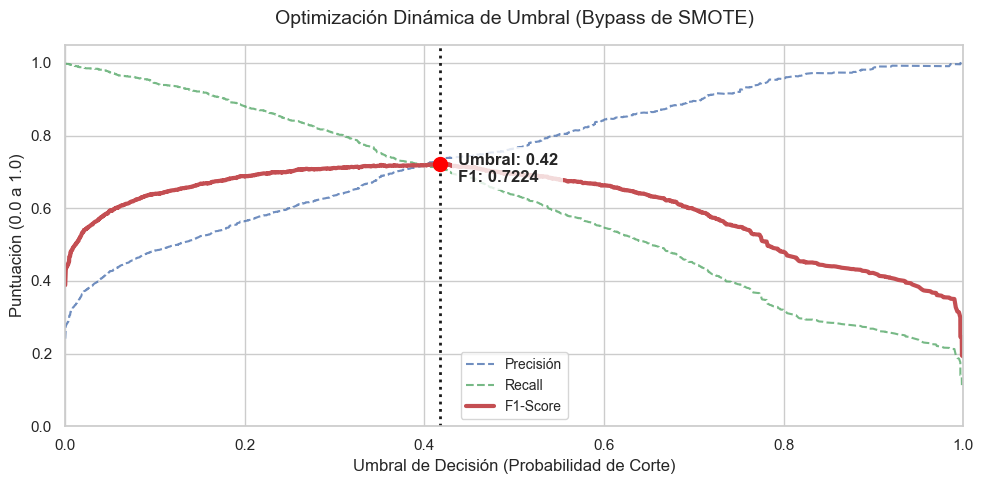

### ⚔️ Impacto de la Guillotina Dinámica

  ANTES (Umbral ciego 0.50): F1-Score = 0.6954
  AHORA (Umbral exacto 0.4170): F1-Score = 0.7224
  🟢 Incremento garantizado de +0.0269 puntos en F1-Score.

  Reporte de Clasificación Final (Listo para Producción):
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      4940
           1       0.73      0.71      0.72      1568

    accuracy                           0.87      6508
   macro avg       0.82      0.81      0.82      6508
weighted avg       0.87      0.87      0.87      6508


⏱️ Escáner completado en 0.398s
  💾 Artefacto Guardado: 'umbral_decision' (0.4170) asegurado en el PipelineManager.

📦 [MLOps] Escáner visual de decisión y modo operativo consolidados correctamente.


In [1437]:
# ==========================================
# 0. Blindaje de Dependencias y Estética
# ==========================================
import logging
import time
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.metrics import (
    f1_score,
    precision_recall_curve,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
)
from sklearn.utils.multiclass import type_of_target

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🛡️ Bandera de Entorno MLOps
MODO_VISUAL = True  # Cambiar a False en Producción (Docker / Headless)


# ==========================================
# 1. Blindajes Auxiliares del Target y Features
# ==========================================
if 'detectar_naturaleza_target_mlops' not in globals():
    def detectar_naturaleza_target_mlops(y: pd.Series) -> dict:
        """
        [FASE 19 - Escáner de Naturaleza del Target]
        - Detecta si el problema es binario, multiclase o regresión.
        - Devuelve una ficha técnica estándar para el resto del pipeline.
        """
        serie = pd.Series(y).dropna()

        if serie.empty:
            return {
                'tipo': 'desconocido',
                'es_regresion': False,
                'es_binario': False,
                'es_multiclase': False,
                'num_clases': 0,
            }

        serie_tipada = serie if pd.api.types.is_numeric_dtype(serie) else serie.astype(str)

        try:
            tipo_detectado = type_of_target(serie_tipada)
        except Exception:
            tipo_detectado = 'desconocido'

        es_regresion = tipo_detectado in ('continuous', 'continuous-multioutput')
        num_clases = int(serie.nunique()) if not es_regresion else 0
        es_multiclase = (not es_regresion) and num_clases > 2
        es_binario = (not es_regresion) and num_clases == 2

        if es_regresion:
            tipo = 'regression'
        elif es_multiclase:
            tipo = 'multiclass'
        elif es_binario:
            tipo = 'binary'
        else:
            tipo = 'desconocido'

        return {
            'tipo': tipo,
            'es_regresion': es_regresion,
            'es_binario': es_binario,
            'es_multiclase': es_multiclase,
            'num_clases': num_clases,
        }


if 'resolver_etiquetas_target_mlops' not in globals():
    def resolver_etiquetas_target_mlops(y: pd.Series, manager_ref=None):
        """
        Resuelve etiquetas crudas y nombres humanos del target.
        Si existe un diccionario maestro en artefactos, lo usa.
        """
        serie = pd.Series(y).dropna()
        etiquetas = sorted(serie.unique().tolist())
        nombres = [str(etiqueta) for etiqueta in etiquetas]

        artefactos = getattr(manager_ref, 'artefactos', {}) if manager_ref is not None else {}
        diccionario = artefactos.get('diccionario_target_maestro') if isinstance(artefactos, dict) else None

        if isinstance(diccionario, dict) and diccionario:
            diccionario_inverso = {valor: clave for clave, valor in diccionario.items()}
            if all(etiqueta in diccionario_inverso for etiqueta in etiquetas):
                nombres = [str(diccionario_inverso[etiqueta]) for etiqueta in etiquetas]

        return etiquetas, nombres


if 'predecir_argmax_multiclase_mlops' not in globals():
    def predecir_argmax_multiclase_mlops(modelo, X: pd.DataFrame):
        """
        Ejecuta predicción robusta para multiclase.
        - Si hay predict_proba, usa Argmax.
        - Si no, cae en predict().
        """
        if hasattr(modelo, "predict_proba"):
            probabilidades = np.asarray(modelo.predict_proba(X))
            if probabilidades.ndim == 2 and probabilidades.shape[1] > 1:
                clases = np.asarray(getattr(modelo, 'classes_', np.arange(probabilidades.shape[1])))
                predicciones = clases[np.argmax(probabilidades, axis=1)]
                return predicciones, probabilidades

        return np.asarray(modelo.predict(X)), None


if 'alinear_features_oraculo_mlops' not in globals():
    def alinear_features_oraculo_mlops(modelo, X: pd.DataFrame) -> pd.DataFrame:
        """
        Alinea el DataFrame con las features esperadas por el modelo:
        - elimina columnas extra,
        - crea faltantes en cero,
        - respeta el orden exacto del entrenamiento.
        """
        nombres = None

        if hasattr(modelo, 'feature_names_in_'):
            nombres = list(modelo.feature_names_in_)
        elif hasattr(modelo, 'feature_name_'):
            try:
                nombres = list(modelo.feature_name_)
            except Exception:
                nombres = None
        elif hasattr(modelo, 'feature_name'):
            try:
                nombres = list(modelo.feature_name())
            except Exception:
                nombres = None

        if not nombres:
            return X

        X_alineada = X.copy()

        extras = [col for col in X_alineada.columns if col not in nombres]
        if extras:
            X_alineada = X_alineada.drop(columns=extras, errors='ignore')

        faltantes = [col for col in nombres if col not in X_alineada.columns]
        for col in faltantes:
            X_alineada[col] = 0

        return X_alineada[nombres]


if 'calcular_metricas_multiclase_mlops' not in globals():
    def calcular_metricas_multiclase_mlops(y_true, y_pred) -> dict:
        """
        Calcula el paquete ejecutivo de métricas multiclase.
        """
        macro_f1 = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
        weighted_f1 = float(f1_score(y_true, y_pred, average='weighted', zero_division=0))
        exactitud = float(accuracy_score(y_true, y_pred))
        balanced_acc = float(balanced_accuracy_score(y_true, y_pred))
        score_compuesto = float((0.7 * macro_f1) + (0.3 * weighted_f1))

        return {
            'macro_f1': macro_f1,
            'weighted_f1': weighted_f1,
            'exactitud': exactitud,
            'balanced_accuracy': balanced_acc,
            'score_compuesto': score_compuesto,
        }


# ==========================================
# 2. Renderizador Táctico Multiclase
# ==========================================
if 'graficar_escaner_multiclase_mlops' not in globals():
    def graficar_escaner_multiclase_mlops(y_true, y_pred, etiquetas_target, nombres_target, metricas):
        """
        Genera el escáner táctico multiclase:
        - precision por clase,
        - recall por clase,
        - F1 por clase,
        - soporte por clase,
        - métricas globales de referencia.
        """
        reporte = classification_report(
            y_true,
            y_pred,
            labels=etiquetas_target,
            target_names=nombres_target,
            zero_division=0,
            output_dict=True
        )

        precision = np.array([reporte[nombre]['precision'] for nombre in nombres_target], dtype=float)
        recall = np.array([reporte[nombre]['recall'] for nombre in nombres_target], dtype=float)
        f1_clase = np.array([reporte[nombre]['f1-score'] for nombre in nombres_target], dtype=float)
        soporte = np.array([reporte[nombre]['support'] for nombre in nombres_target], dtype=float)
        posiciones = np.arange(len(nombres_target))

        sns.set_theme(style="whitegrid")
        fig, ax1 = plt.subplots(figsize=(11, 5.5))
        ax2 = ax1.twinx()

        ax2.bar(posiciones, soporte, alpha=0.18, color='gray', width=0.58, label='Soporte')
        ax1.plot(posiciones, precision, 'o--', color='#4C72B0', linewidth=2, label='Precisión')
        ax1.plot(posiciones, recall, 's--', color='#55A868', linewidth=2, label='Recall')
        ax1.plot(posiciones, f1_clase, 'o-', color='#C44E52', linewidth=3, label='F1 por clase')
        ax1.axhline(metricas['macro_f1'], color='#8172B2', linestyle=':', linewidth=2, label=f"F1 macro = {metricas['macro_f1']:.4f}")
        ax1.axhline(metricas['weighted_f1'], color='#CCB974', linestyle='-.', linewidth=2, label=f"F1 weighted = {metricas['weighted_f1']:.4f}")
        ax1.axhline(metricas['balanced_accuracy'], color='black', linestyle='--', linewidth=1.8, label=f"Balanced Acc = {metricas['balanced_accuracy']:.4f}")

        ax1.set_title("Escáner Táctico Multiclase (Decisión Argmax)", fontsize=14, pad=15, fontweight='bold')
        ax1.set_xlabel("Clases del Target", fontsize=11)
        ax1.set_ylabel("Puntuación (0.0 a 1.0)", fontsize=11)
        ax2.set_ylabel("Soporte", fontsize=11)
        ax1.set_ylim([0.0, 1.05])
        ax1.set_xticks(posiciones)
        ax1.set_xticklabels(nombres_target, rotation=20, ha='right')

        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(
            handles1 + handles2,
            labels1 + labels2,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.33),
            ncol=3,
            fontsize=9
        )

        plt.tight_layout()
        return fig


# ==========================================
# 3. FASE 19.3: ESCÁNER VECTORIZADO DE DECISIÓN
# ==========================================
def optimizador_visual_umbral(
    modelo,
    X_test: pd.DataFrame,
    y_test: pd.Series
):
    """
    [FASE 7 - Paso 19.3] Escáner Vectorizado de Decisión.
    - 🧠 En multiclase: activa modo Argmax y muestra escáner táctico.
    - ⚖️ En binario: encuentra el Umbral de Oro con frontera Precision-Recall.
    - 📊 Emite el reporte final listo para producción.
    """
    logger.info("=== 📊 FASE 19.3: Escáner Vectorizado de Decisión ===")
    inicio_timer = time.time()

    if not hasattr(modelo, "predict_proba"):
        logger.error("🛑 Error Crítico: El modelo no soporta probabilidades (predict_proba).")
        raise ValueError("El modelo no soporta probabilidades (predict_proba).")

    info_target = detectar_naturaleza_target_mlops(y_test)
    es_multiclase = info_target['es_multiclase']
    manager_ref = globals().get('manager', None)
    etiquetas_target, nombres_target = resolver_etiquetas_target_mlops(y_test, manager_ref=manager_ref)
    X_test_modelo = alinear_features_oraculo_mlops(modelo, X_test)

    # ==========================================
    # 3A. MODO MULTICLASE
    # ==========================================
    if es_multiclase:
        logger.warning("  🧠 [INFO] Target Multiclase detectado. Threshold Tuning reemplazado por escáner táctico Argmax.")
        logger.info("  📌 [INFO] La Matriz de Confusión queda reservada para la FASE 19.4.")

        preds_nuevas, _ = predecir_argmax_multiclase_mlops(modelo, X_test_modelo)
        metricas = calcular_metricas_multiclase_mlops(y_test, preds_nuevas)

        fig = graficar_escaner_multiclase_mlops(
            y_true=y_test,
            y_pred=preds_nuevas,
            etiquetas_target=etiquetas_target,
            nombres_target=nombres_target,
            metricas=metricas
        )

        if MODO_VISUAL:
            plt.show()
            display(Markdown("### 🧠 Escáner Táctico de la Decisión Multiclase"))
        else:
            plt.close(fig)
            logger.info("### 🧠 Escáner Táctico de la Decisión Multiclase")

        logger.info("  🔒 MODO ACTIVO: multiclass_argmax. No existe un umbral global operativo.")
        logger.info(
            f"  Producción (argmax): Exactitud = {metricas['exactitud']:.4f} | "
            f"F1 weighted = {metricas['weighted_f1']:.4f} | "
            f"F1 macro = {metricas['macro_f1']:.4f} | "
            f"Balanced Accuracy = {metricas['balanced_accuracy']:.4f} | "
            f"Score 70/30 = {metricas['score_compuesto']:.4f}"
        )
        logger.info(
            "\n  Reporte de Clasificación Final (Listo para Producción):\n" +
            classification_report(
                y_test,
                preds_nuevas,
                labels=etiquetas_target,
                target_names=nombres_target,
                zero_division=0
            )
        )
        logger.info(f"\n⏱️ Escáner completado en {time.time() - inicio_timer:.3f}s")
        return None

    # ==========================================
    # 3B. MODO BINARIO
    # ==========================================
    logger.info("  🔎 Extrayendo probabilidades del Test Set...")
    proba_test = modelo.predict_proba(X_test_modelo)[:, 1]

    logger.info("  ⚙️ Calculando la frontera de Pareto (Precisión vs Recall)...")
    precisiones, recalls, umbrales = precision_recall_curve(y_test, proba_test)

    f1_scores = 2 * (precisiones * recalls) / (precisiones + recalls + 1e-10)
    indice_optimo = np.argmax(f1_scores[:-1])
    umbral_oro = umbrales[indice_optimo]
    f1_maximo = f1_scores[indice_optimo]

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(umbrales, precisiones[:-1], 'b--', label='Precisión', alpha=0.8)
    ax.plot(umbrales, recalls[:-1], 'g--', label='Recall', alpha=0.8)
    ax.plot(umbrales, f1_scores[:-1], 'r-', linewidth=3, label='F1-Score')
    ax.axvline(x=umbral_oro, color='k', linestyle=':', linewidth=2)
    ax.scatter([umbral_oro], [f1_maximo], color='red', s=100, zorder=5)
    ax.text(
        umbral_oro + 0.02,
        f1_maximo - 0.05,
        f"Umbral: {umbral_oro:.2f}\nF1: {f1_maximo:.4f}",
        fontsize=12,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )
    ax.set_xlabel("Umbral de Decisión (Probabilidad de Corte)", fontsize=12)
    ax.set_ylabel("Puntuación (0.0 a 1.0)", fontsize=12)
    ax.set_title("Optimización Dinámica de Umbral (Bypass de SMOTE)", fontsize=14, pad=15)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc="lower center", fontsize=10)

    plt.tight_layout()

    if MODO_VISUAL:
        plt.show()
        display(Markdown("### ⚔️ Impacto de la Guillotina Dinámica"))
    else:
        plt.close(fig)
        logger.info("### ⚔️ Impacto de la Guillotina Dinámica")

    preds_viejas = (proba_test >= 0.50).astype(int)
    preds_nuevas = (proba_test >= umbral_oro).astype(int)

    f1_viejo = f1_score(y_test, preds_viejas)
    mejora = f1_maximo - f1_viejo

    logger.info(f"  ANTES (Umbral ciego 0.50): F1-Score = {f1_viejo:.4f}")
    logger.info(f"  AHORA (Umbral exacto {umbral_oro:.4f}): F1-Score = {f1_maximo:.4f}")

    if mejora > 0.001:
        logger.info(f"  🟢 Incremento garantizado de +{mejora:.4f} puntos en F1-Score.")
    else:
        logger.info("  🟡 El umbral 0.50 ya era el matemático ideal.")

    logger.info("\n  Reporte de Clasificación Final (Listo para Producción):\n" + classification_report(y_test, preds_nuevas))
    logger.info(f"\n⏱️ Escáner completado en {time.time() - inicio_timer:.3f}s")

    del proba_test, precisiones, recalls, umbrales, f1_scores
    gc.collect()

    return umbral_oro


# ==========================================
# 4. Celda de Ejecución Maestra
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError as exc:
        raise EnvironmentError(
            "El PipelineManager no está inicializado. Instáncialo en la línea 1 (Fase 1.1)."
        ) from exc

    if not hasattr(manager, 'modelos_preprocesamiento'):
        raise ValueError("El Manager no tiene la caja fuerte de modelos inicializada.")

    if getattr(manager, 'X_test', None) is None or getattr(manager, 'y_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices X_test o y_test. Ejecuta el Split (Fase 3.3).")

    if 'oraculo_calibrado' in manager.modelos_preprocesamiento:
        logger.info(">>> 💉 UTILIZANDO ORÁCULO CALIBRADO (FASE 19.2 DETECTADA) <<<")
        modelo_activo = manager.modelos_preprocesamiento['oraculo_calibrado']
    elif 'oraculo_lightgbm' in manager.modelos_preprocesamiento:
        logger.warning(">>> ⚠️ UTILIZANDO ORÁCULO CRUDO (NO SE DETECTÓ CALIBRACIÓN) <<<")
        modelo_activo = manager.modelos_preprocesamiento['oraculo_lightgbm']
    else:
        raise ValueError("No se encontró ningún modelo LightGBM en el Manager.")

    logger.info("-" * 80)

    # ==========================================
    # 4.1 Optimización Visual / Umbral Final
    # ==========================================
    umbral_definitivo = optimizador_visual_umbral(
        modelo=modelo_activo,
        X_test=manager.X_test,
        y_test=manager.y_test
    )

    # ==========================================
    # 4.2 Blindaje de Artefactos MLOps
    # ==========================================
    if hasattr(manager, 'guardar_artefacto'):
        manager.guardar_artefacto('umbral_decision', umbral_definitivo)
    else:
        if not hasattr(manager, 'artefactos'):
            manager.artefactos = {}
        manager.artefactos['umbral_decision'] = umbral_definitivo

    if not hasattr(manager, 'artefactos'):
        manager.artefactos = {}

    info_target_final = detectar_naturaleza_target_mlops(manager.y_test)
    manager.artefactos['modo_decision'] = (
        'multiclass_argmax' if info_target_final['es_multiclase'] else 'binary_threshold'
    )

    if umbral_definitivo is None:
        logger.info("  💾 Artefacto Guardado: 'umbral_decision' = None (modo multiclass_argmax) asegurado en el PipelineManager.")
    else:
        logger.info(
            f"  💾 Artefacto Guardado: 'umbral_decision' ({umbral_definitivo:.4f}) "
            f"asegurado en el PipelineManager."
        )

    logger.info("\n📦 [MLOps] Escáner visual de decisión y modo operativo consolidados correctamente.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en el Optimizador Visual: {e}")

--------------------------------------------------------------------------------
=== 🎯 FASE 19.4: Matriz de Confusión Táctica ===
  ⚙️ Extrayendo probabilidades y aplicando Umbral de Oro (0.4170)...
  📊 Procesando Matriz para Presentación a Negocio...


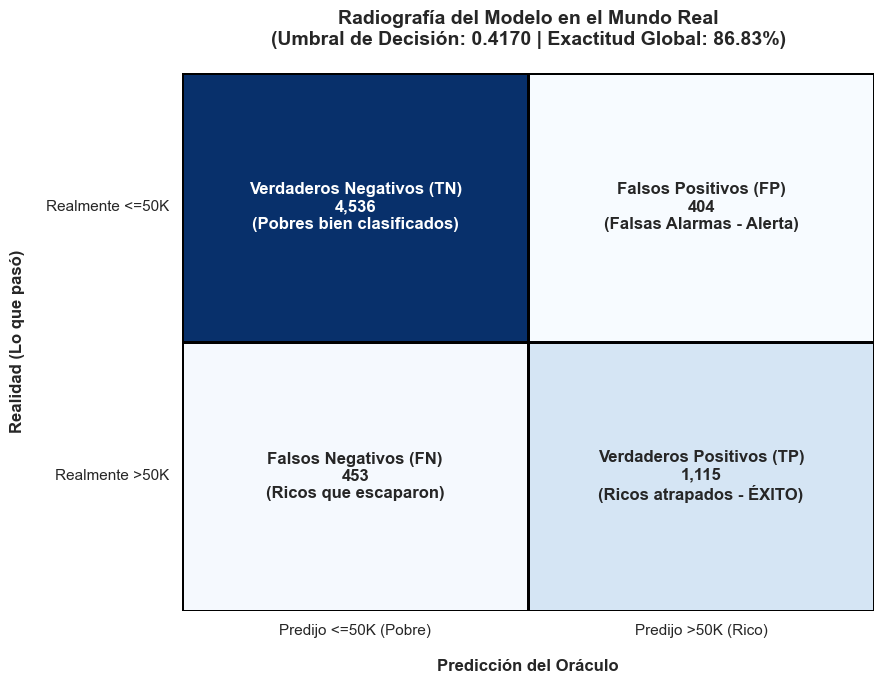

### 📋 Resumen Ejecutivo para Stakeholders

  🟢 ACIERTOS TOTALES: 5,651 registros clasificados correctamente.
  🔴 ERRORES TOTALES: 857 registros clasificados incorrectamente.
     ↳ De 1,568 personas ricas reales, el modelo logró atrapar a 1,115 (Recall).
     ↳ De 1,519 veces que el modelo gritó '¡Es rico!', acertó 1,115 veces (Precisión).

⏱️ Matriz generada en 0.333s


In [1438]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import time
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import type_of_target
from IPython.display import display, Markdown

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = True # Cambiar a False en Producción (Docker/Headless)

if 'detectar_naturaleza_target_mlops' not in globals():
    def detectar_naturaleza_target_mlops(y: pd.Series) -> dict:
        serie = pd.Series(y).dropna()
        if serie.empty:
            return {'tipo': 'desconocido', 'es_regresion': False, 'es_binario': False, 'es_multiclase': False, 'num_clases': 0}
        serie_tipada = serie if pd.api.types.is_numeric_dtype(serie) else serie.astype(str)
        try:
            tipo_detectado = type_of_target(serie_tipada)
        except Exception:
            tipo_detectado = 'desconocido'
        es_regresion = tipo_detectado in ('continuous', 'continuous-multioutput')
        num_clases = int(serie.nunique()) if not es_regresion else 0
        es_multiclase = (not es_regresion) and num_clases > 2
        es_binario = (not es_regresion) and num_clases == 2
        if es_regresion:
            tipo = 'regression'
        elif es_multiclase:
            tipo = 'multiclass'
        elif es_binario:
            tipo = 'binary'
        else:
            tipo = 'desconocido'
        return {'tipo': tipo, 'es_regresion': es_regresion, 'es_binario': es_binario, 'es_multiclase': es_multiclase, 'num_clases': num_clases}

if 'resolver_etiquetas_target_mlops' not in globals():
    def resolver_etiquetas_target_mlops(y: pd.Series, manager_ref=None):
        serie = pd.Series(y).dropna()
        etiquetas = sorted(serie.unique().tolist())
        nombres = [str(etiqueta) for etiqueta in etiquetas]
        artefactos = getattr(manager_ref, 'artefactos', {}) if manager_ref is not None else {}
        diccionario = artefactos.get('diccionario_target_maestro') if isinstance(artefactos, dict) else None
        if isinstance(diccionario, dict) and diccionario:
            diccionario_inverso = {valor: clave for clave, valor in diccionario.items()}
            if all(etiqueta in diccionario_inverso for etiqueta in etiquetas):
                nombres = [str(diccionario_inverso[etiqueta]) for etiqueta in etiquetas]
        return etiquetas, nombres

if 'predecir_argmax_multiclase_mlops' not in globals():
    def predecir_argmax_multiclase_mlops(modelo, X: pd.DataFrame):
        if hasattr(modelo, "predict_proba"):
            probabilidades = np.asarray(modelo.predict_proba(X))
            if probabilidades.ndim == 2 and probabilidades.shape[1] > 1:
                clases = np.asarray(getattr(modelo, 'classes_', np.arange(probabilidades.shape[1])))
                predicciones = clases[np.argmax(probabilidades, axis=1)]
                return predicciones, probabilidades
        return np.asarray(modelo.predict(X)), None

if 'alinear_features_oraculo_mlops' not in globals():
    def alinear_features_oraculo_mlops(modelo, X: pd.DataFrame) -> pd.DataFrame:
        nombres = None
        if hasattr(modelo, 'feature_names_in_'):
            nombres = list(modelo.feature_names_in_)
        elif hasattr(modelo, 'feature_name_'):
            try:
                nombres = list(modelo.feature_name_)
            except Exception:
                nombres = None
        elif hasattr(modelo, 'feature_name'):
            try:
                nombres = list(modelo.feature_name())
            except Exception:
                nombres = None
        if not nombres:
            return X
        X_alineada = X.copy()
        extras = [col for col in X_alineada.columns if col not in nombres]
        if extras:
            X_alineada = X_alineada.drop(columns=extras, errors='ignore')
        faltantes = [col for col in nombres if col not in X_alineada.columns]
        for col in faltantes:
            X_alineada[col] = 0
        return X_alineada[nombres]

def renderizar_matriz_confusion_mlops(
    modelo_calibrado, 
    umbral_oro: float, 
    X_test: pd.DataFrame, 
    y_test: pd.Series
):
    """
    [FASE 7 - Paso 19.4] Matriz de Confusión Táctica (UI/UX para Negocio).
    
    - Inteligencia de Umbral: Aplica la guillotina exacta (ej. 0.38) en lugar del 0.50 por defecto.
    - Renderizado de Negocio: Traduce los cuadrantes matemáticos a impacto real (Aciertos/Errores).
    - Blindaje: Funciona dinámicamente según la distribución del Test Set.
    """
    logger.info("=== 🎯 FASE 19.4: Matriz de Confusión Táctica ===")
    inicio_timer = time.time()

    info_target = detectar_naturaleza_target_mlops(y_test)
    es_multiclase = info_target['es_multiclase']
    manager_ref = globals().get('manager', None)
    etiquetas_target, nombres_target = resolver_etiquetas_target_mlops(y_test, manager_ref=manager_ref)

    # 1. Extracción de Predicciones Finales
    if es_multiclase:
        logger.info("  ⚙️ Generando dictámenes finales en modo Argmax Multiclase...")
        X_test_modelo = alinear_features_oraculo_mlops(modelo_calibrado, X_test)
        preds_finales, _ = predecir_argmax_multiclase_mlops(modelo_calibrado, X_test_modelo)
    else:
        logger.info(f"  ⚙️ Extrayendo probabilidades y aplicando Umbral de Oro ({umbral_oro:.4f})...")
        X_test_modelo = alinear_features_oraculo_mlops(modelo_calibrado, X_test)
        proba_test = modelo_calibrado.predict_proba(X_test_modelo)[:, 1]
        preds_finales = (proba_test >= umbral_oro).astype(int)

    # 2. Cálculo Matemático
    cm = confusion_matrix(y_test, preds_finales, labels=etiquetas_target if es_multiclase else None)

    # 3. Cálculos porcentuales para dar contexto
    total = np.sum(cm)
    tasa_acierto = np.trace(cm) / total

    # ==========================================
    # 4. Renderizado Visual (Nivel Dashboard)
    # ==========================================
    logger.info("  📊 Procesando Matriz para Presentación a Negocio...")
    if es_multiclase:
        etiquetas = cm.astype(str)
    else:
        tn, fp, fn, tp = cm.ravel()
        etiquetas = np.array([
            [f"Verdaderos Negativos (TN)\n{tn:,}\n(Pobres bien clasificados)", 
             f"Falsos Positivos (FP)\n{fp:,}\n(Falsas Alarmas - Alerta)"],
            [f"Falsos Negativos (FN)\n{fn:,}\n(Ricos que escaparon)", 
             f"Verdaderos Positivos (TP)\n{tp:,}\n(Ricos atrapados - ÉXITO)"]
        ])

    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(9, 7))

    # Mapa de calor usando una paleta profesional (Rojos para errores, Azules para aciertos)
    sns.heatmap(
        cm, 
        annot=etiquetas, 
        fmt="", 
        cmap="Blues", 
        cbar=False, 
        annot_kws={"size": 12, "weight": "bold"}, 
        linewidths=2, 
        linecolor='black',
        ax=ax
    )

    # Estética del gráfico
    if es_multiclase:
        ax.set_title(
            f"Radiografía del Modelo Multiclase\n(Modo: Argmax | Exactitud Global: {tasa_acierto:.2%})",
            fontsize=14, pad=20, fontweight='bold'
        )
    else:
        ax.set_title(f"Radiografía del Modelo en el Mundo Real\n(Umbral de Decisión: {umbral_oro:.4f} | Exactitud Global: {tasa_acierto:.2%})", 
                     fontsize=14, pad=20, fontweight='bold')
    ax.set_xlabel('Predicción del Oráculo', fontsize=12, fontweight='bold', labelpad=15)
    ax.set_ylabel('Realidad (Lo que pasó)', fontsize=12, fontweight='bold', labelpad=15)

    # Etiquetas de los ejes
    if es_multiclase:
        ax.set_xticklabels(nombres_target, fontsize=11, rotation=25, ha='right')
        ax.set_yticklabels(nombres_target, fontsize=11, rotation=0)
    else:
        ax.set_xticklabels(['Predijo <=50K (Pobre)', 'Predijo >50K (Rico)'], fontsize=11)
        ax.set_yticklabels(['Realmente <=50K', 'Realmente >50K'], fontsize=11, rotation=0)

    plt.tight_layout()
    
    # 🛡️ Cláusula de Seguridad Visual
    if MODO_VISUAL:
        plt.show()
        display(Markdown("### 📋 Resumen Ejecutivo para Stakeholders"))
    else:
        plt.close(fig)
        logger.info("\n### 📋 Resumen Ejecutivo para Stakeholders")

    # 5. Resumen Ejecutivo (Siempre se loguea)
    aciertos = int(np.trace(cm))
    errores = int(total - aciertos)
    logger.info(f"  🟢 ACIERTOS TOTALES: {aciertos:,} registros clasificados correctamente.")
    logger.warning(f"  🔴 ERRORES TOTALES: {errores:,} registros clasificados incorrectamente.")
    if es_multiclase:
        resumen_por_clase = pd.DataFrame({
            'Clase': nombres_target,
            'Aciertos': np.diag(cm),
            'Soporte': cm.sum(axis=1)
        })
        logger.info("\n  📋 Resumen por Clase:\n" + resumen_por_clase.to_string(index=False))
    else:
        logger.info(f"     ↳ De {tp + fn:,} personas ricas reales, el modelo logró atrapar a {tp:,} (Recall).")
        logger.info(f"     ↳ De {tp + fp:,} veces que el modelo gritó '¡Es rico!', acertó {tp:,} veces (Precisión).")

    logger.info(f"\n⏱️ Matriz generada en {time.time() - inicio_timer:.3f}s")

    return cm

# ==========================================
# Celda de Ejecución Maestra en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta del Manager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Instáncialo en la línea 1 (Fase 1.1).")

    if not hasattr(manager, 'modelos_preprocesamiento') or 'oraculo_calibrado' not in manager.modelos_preprocesamiento:
        raise ValueError("El modelo 'oraculo_calibrado' no existe en la caja fuerte. Ejecuta la Fase 19.2.")

    if not hasattr(manager, 'artefactos') or 'umbral_decision' not in manager.artefactos:
        raise ValueError("El 'umbral_decision' no existe en los artefactos. Ejecuta la Fase 19.2.5 (o la Fase Unificada).")

    if getattr(manager, 'X_test', None) is None or getattr(manager, 'y_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices de Test ('X_test' o 'y_test').")

    modelo_final = manager.modelos_preprocesamiento['oraculo_calibrado']
    umbral_final = manager.artefactos['umbral_decision']

    logger.info("-" * 80)

    # Invocamos al renderizador
    matriz_final = renderizar_matriz_confusion_mlops(
        modelo_calibrado=modelo_final,
        umbral_oro=umbral_final,
        X_test=manager.X_test,
        y_test=manager.y_test
    )

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error renderizando la Matriz de Confusión: {e}")


>>> 🧠 UTILIZANDO ORÁCULO CALIBRADO <<<

>>> INICIANDO AUDITORIA LEGAL (Umbral Activo: 0.4170) <<<
--------------------------------------------------------------------------------
=== ⚖️ FASE 19.5: Auditoría de Justicia Algorítmica (Legal MLOps) ===
  ⚙️ Extrayendo dictámenes finales usando el Umbral Optimizado (0.4170)...
  🔍 Atributos protegidos detectados para auditoría: ['age', 'sex', 'llm_age_*_education_num']
  ⏭️ Saltando 'age' (Demasiados valores únicos para un reporte categórico claro).
  ⏭️ Saltando 'llm_age_*_education_num' (Demasiados valores únicos para un reporte categórico claro).
  📊 Generando Diagnóstico de Equidad...


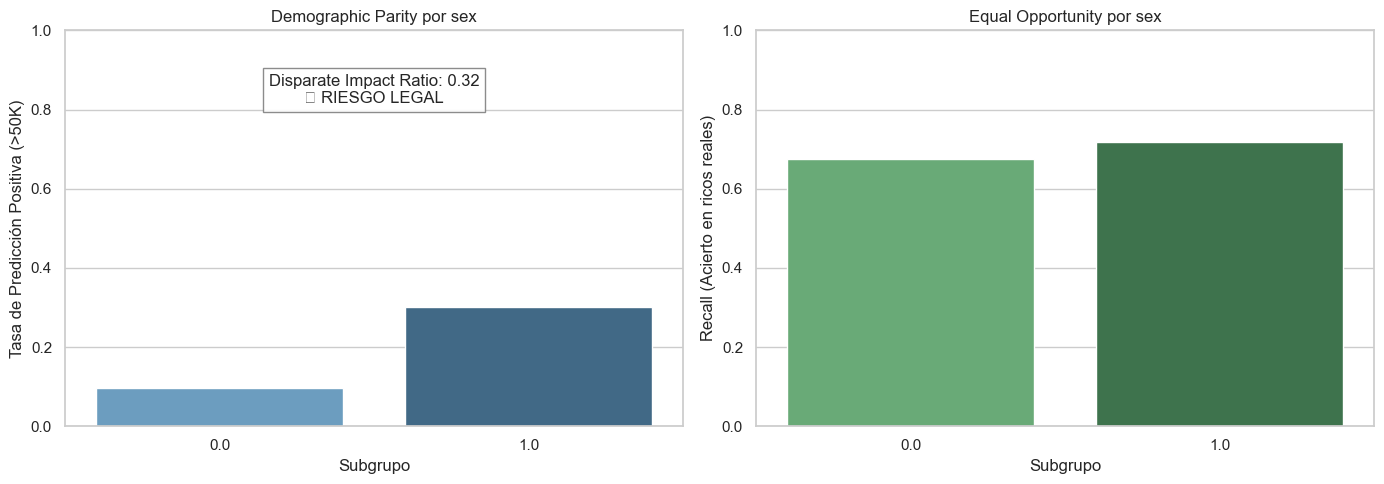

### 📋 Veredicto de Justicia Algorítmica

,Atributo,Subgrupo,Tamaño (N),Selection Rate (Demographic Parity),Recall (Equal Opportunity)
0,sex,1.000000,4335,30.22%,71.74%
1,sex,0.000000,2173,9.62%,67.63%



  💡 NOTA DEL ARQUITECTO: Si hay diferencias extremas entre subgrupos, conviene revisar sesgo histórico, cobertura de datos y definición de etiquetas.
     ↳ Este tablero no reemplaza una revisión causal, pero sí sirve como radar operativo temprano.

⏱️ Auditoría completada en 0.577s


In [1439]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import time
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score
from sklearn.utils.multiclass import type_of_target
from IPython.display import display, Markdown

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")

# 🛡️ Banderas de Entorno MLOps
MODO_VISUAL = True # Cambiar a False en Producción (Docker/Headless)

if 'detectar_naturaleza_target_mlops' not in globals():
    def detectar_naturaleza_target_mlops(y: pd.Series) -> dict:
        serie = pd.Series(y).dropna()
        if serie.empty:
            return {'tipo': 'desconocido', 'es_regresion': False, 'es_binario': False, 'es_multiclase': False, 'num_clases': 0}
        serie_tipada = serie if pd.api.types.is_numeric_dtype(serie) else serie.astype(str)
        try:
            tipo_detectado = type_of_target(serie_tipada)
        except Exception:
            tipo_detectado = 'desconocido'
        es_regresion = tipo_detectado in ('continuous', 'continuous-multioutput')
        num_clases = int(serie.nunique()) if not es_regresion else 0
        es_multiclase = (not es_regresion) and num_clases > 2
        es_binario = (not es_regresion) and num_clases == 2
        if es_regresion:
            tipo = 'regression'
        elif es_multiclase:
            tipo = 'multiclass'
        elif es_binario:
            tipo = 'binary'
        else:
            tipo = 'desconocido'
        return {'tipo': tipo, 'es_regresion': es_regresion, 'es_binario': es_binario, 'es_multiclase': es_multiclase, 'num_clases': num_clases}

if 'resolver_etiquetas_target_mlops' not in globals():
    def resolver_etiquetas_target_mlops(y: pd.Series, manager_ref=None):
        serie = pd.Series(y).dropna()
        etiquetas = sorted(serie.unique().tolist())
        nombres = [str(etiqueta) for etiqueta in etiquetas]
        artefactos = getattr(manager_ref, 'artefactos', {}) if manager_ref is not None else {}
        diccionario = artefactos.get('diccionario_target_maestro') if isinstance(artefactos, dict) else None
        if isinstance(diccionario, dict) and diccionario:
            diccionario_inverso = {valor: clave for clave, valor in diccionario.items()}
            if all(etiqueta in diccionario_inverso for etiqueta in etiquetas):
                nombres = [str(diccionario_inverso[etiqueta]) for etiqueta in etiquetas]
        return etiquetas, nombres

if 'predecir_argmax_multiclase_mlops' not in globals():
    def predecir_argmax_multiclase_mlops(modelo, X: pd.DataFrame):
        if hasattr(modelo, "predict_proba"):
            probabilidades = np.asarray(modelo.predict_proba(X))
            if probabilidades.ndim == 2 and probabilidades.shape[1] > 1:
                clases = np.asarray(getattr(modelo, 'classes_', np.arange(probabilidades.shape[1])))
                predicciones = clases[np.argmax(probabilidades, axis=1)]
                return predicciones, probabilidades
        return np.asarray(modelo.predict(X)), None

if 'alinear_features_oraculo_mlops' not in globals():
    def alinear_features_oraculo_mlops(modelo, X: pd.DataFrame) -> pd.DataFrame:
        nombres = None
        if hasattr(modelo, 'feature_names_in_'):
            nombres = list(modelo.feature_names_in_)
        elif hasattr(modelo, 'feature_name_'):
            try:
                nombres = list(modelo.feature_name_)
            except Exception:
                nombres = None
        elif hasattr(modelo, 'feature_name'):
            try:
                nombres = list(modelo.feature_name())
            except Exception:
                nombres = None
        if not nombres:
            return X
        X_alineada = X.copy()
        extras = [col for col in X_alineada.columns if col not in nombres]
        if extras:
            X_alineada = X_alineada.drop(columns=extras, errors='ignore')
        faltantes = [col for col in nombres if col not in X_alineada.columns]
        for col in faltantes:
            X_alineada[col] = 0
        return X_alineada[nombres]

def auditoria_justicia_mlops(
    modelo_calibrado, 
    umbral_oro: float, 
    X_test: pd.DataFrame, 
    y_test: pd.Series,
    atributos_sospechosos: list = None
):
    """
    [FASE 7 - Paso 19.5] Auditoría de Justicia Algorítmica (Fairness Constraints).
    - Muro Legal: Aplica la "Regla de los 4/5" (Disparate Impact).
    - Demographic Parity: ¿El modelo aprueba a hombres y mujeres en proporciones similares?
    - Equal Opportunity: De los que verdaderamente son ricos, ¿el modelo los detecta igual sin importar su raza/sexo?
    - Inmunidad de Pipeline: Evalúa predicciones duras basadas EXCLUSIVAMENTE en el Umbral Optimizado.
    """
    logger.info("=== ⚖️ FASE 19.5: Auditoría de Justicia Algorítmica (Legal MLOps) ===")
    inicio_timer = time.time()

    info_target = detectar_naturaleza_target_mlops(y_test)
    es_multiclase = info_target['es_multiclase']
    manager_ref = globals().get('manager', None)
    etiquetas_target, nombres_target = resolver_etiquetas_target_mlops(y_test, manager_ref=manager_ref)
    mapa_nombres = dict(zip(etiquetas_target, nombres_target))

    # 1. Aplicación estricta de la regla de decisión final
    if es_multiclase:
        logger.info("  ⚙️ Extrayendo dictámenes finales usando decisión Argmax Multiclase...")
        X_test_modelo = alinear_features_oraculo_mlops(modelo_calibrado, X_test)
        preds_finales, _ = predecir_argmax_multiclase_mlops(modelo_calibrado, X_test_modelo)
    else:
        logger.info(f"  ⚙️ Extrayendo dictámenes finales usando el Umbral Optimizado ({umbral_oro:.4f})...")
        X_test_modelo = alinear_features_oraculo_mlops(modelo_calibrado, X_test)
        proba_test = modelo_calibrado.predict_proba(X_test_modelo)[:, 1]
        preds_finales = (proba_test >= umbral_oro).astype(int)

    # 2. Radar de Atributos Protegidos
    if atributos_sospechosos is None:
        # Búsqueda automática de variables sensibles comunes en el dataset Adult
        palabras_clave = ['sex', 'gender', 'race', 'age', 'edad', 'sexo', 'raza']
        atributos_protegidos = [col for col in X_test.columns if any(kw in col.lower() for kw in palabras_clave)]
    else:
        atributos_protegidos = [col for col in atributos_sospechosos if col in X_test.columns]

    if not atributos_protegidos:
        logger.warning("  ⚠️ [ALERTA MLOps] No se encontraron atributos protegidos en X_test.")
        logger.info("     ↳ Nota: Si Boruta extirpó 'sex' o 'race' por ser ruido, el modelo es matemáticamente ciego a ellos (Good news!).")
        return None

    logger.info(f"  🔍 Atributos protegidos detectados para auditoría: {atributos_protegidos}")

    # 3. Motor de Análisis por Subgrupos
    resultados_fairness = []

    for atributo in atributos_protegidos:
        grupos = X_test[atributo].unique()

        # Si la variable es continua (ej. edad numérica) o tiene muchos grupos, la saltamos para el reporte simple
        if len(grupos) > 5:
            logger.info(f"  ⏭️ Saltando '{atributo}' (Demasiados valores únicos para un reporte categórico claro).")
            continue

        for grupo in grupos:
            mascara = (X_test[atributo] == grupo)
            n_grupo = mascara.sum()

            # Métricas Base
            y_verdadero_grupo = y_test[mascara]
            y_pred_grupo = preds_finales[mascara]

            if es_multiclase:
                for clase in etiquetas_target:
                    y_verdadero_ovr = (y_verdadero_grupo == clase).astype(int)
                    y_pred_ovr = (y_pred_grupo == clase).astype(int)
                    tasa_seleccion = float(y_pred_ovr.mean()) if len(y_pred_ovr) else 0.0
                    tasa_oportunidad = recall_score(y_verdadero_ovr, y_pred_ovr, zero_division=0)

                    resultados_fairness.append({
                        'Atributo': atributo,
                        'Subgrupo': grupo,
                        'Clase': mapa_nombres.get(clase, str(clase)),
                        'N': n_grupo,
                        'Selection Rate OVR': tasa_seleccion,
                        'Recall OVR': tasa_oportunidad
                    })
            else:
                # Demographic Parity (Selection Rate): % del grupo que fue clasificado como Clase 1
                tasa_seleccion = y_pred_grupo.mean()

                # Equal Opportunity (True Positive Rate / Recall): De los que son Clase 1, ¿cuántos atrapó?
                tasa_oportunidad = recall_score(y_verdadero_grupo, y_pred_grupo, zero_division=0)

                resultados_fairness.append({
                    'Atributo': atributo,
                    'Subgrupo': grupo,
                    'Tamaño (N)': n_grupo,
                    'Selection Rate (Demographic Parity)': tasa_seleccion,
                    'Recall (Equal Opportunity)': tasa_oportunidad
                })

    if not resultados_fairness:
        logger.info("  ✅ [BYPASS] Análisis completado sin subgrupos categóricos viables.")
        return None

    df_fairness = pd.DataFrame(resultados_fairness)

    # ==========================================
    # 4. Renderizado Inteligente UI (El Veredicto Legal)
    # ==========================================
    logger.info("  📊 Generando Diagnóstico de Equidad...")
    sns.set_theme(style="whitegrid")

    atributos_validos = df_fairness['Atributo'].unique()
    fig, axes = plt.subplots(len(atributos_validos), 2, figsize=(14, 5 * len(atributos_validos)))

    # Manejo de dimensiones si solo hay 1 atributo
    if len(atributos_validos) == 1:
        axes = [axes]

    for i, atributo in enumerate(atributos_validos):
        data_attr = df_fairness[df_fairness['Atributo'] == atributo]

        if es_multiclase:
            sns.barplot(data=data_attr, x='Subgrupo', y='Selection Rate OVR', hue='Clase', ax=axes[i][0], palette="Blues_d")
            axes[i][0].set_title(f"Selection Rate OVR por {atributo}", fontsize=12)
            axes[i][0].set_ylim(0, 1.0)
            axes[i][0].set_ylabel("Selection Rate OVR")

            sns.barplot(data=data_attr, x='Subgrupo', y='Recall OVR', hue='Clase', ax=axes[i][1], palette="Greens_d")
            axes[i][1].set_title(f"Recall OVR por {atributo}", fontsize=12)
            axes[i][1].set_ylim(0, 1.0)
            axes[i][1].set_ylabel("Recall OVR")

            ratios = []
            for _, data_clase in data_attr.groupby('Clase'):
                tasas_seleccion = data_clase['Selection Rate OVR'].values
                if len(tasas_seleccion) >= 2:
                    max_tasa = tasas_seleccion.max()
                    min_tasa = tasas_seleccion.min()
                    ratios.append(min_tasa / (max_tasa + 1e-9))
            if ratios:
                peor_ratio = min(ratios)
                color_alerta = "🔴 RIESGO LEGAL" if peor_ratio < 0.8 else "🟢 APROBADO"
                axes[i][0].text(
                    0.5, 0.88, f"Worst OVR Disparate Impact: {peor_ratio:.2f}\n{color_alerta}",
                    horizontalalignment='center', verticalalignment='center', transform=axes[i][0].transAxes,
                    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray')
                )
        else:
            # Gráfico 1: Demographic Parity (Tasa de Aprobación Global)
            sns.barplot(data=data_attr, x='Subgrupo', y='Selection Rate (Demographic Parity)', ax=axes[i][0], palette="Blues_d")
            axes[i][0].set_title(f"Demographic Parity por {atributo}", fontsize=12)
            axes[i][0].set_ylim(0, 1.0)
            axes[i][0].set_ylabel("Tasa de Predicción Positiva (>50K)")

            # Gráfico 2: Equal Opportunity (Tasa de Verdaderos Positivos)
            sns.barplot(data=data_attr, x='Subgrupo', y='Recall (Equal Opportunity)', ax=axes[i][1], palette="Greens_d")
            axes[i][1].set_title(f"Equal Opportunity por {atributo}", fontsize=12)
            axes[i][1].set_ylim(0, 1.0)
            axes[i][1].set_ylabel("Recall (Acierto en ricos reales)")

            # 5. Evaluación de la Regla Legal (Four-Fifths Rule)
            tasas_seleccion = data_attr['Selection Rate (Demographic Parity)'].values
            if len(tasas_seleccion) >= 2:
                max_tasa = tasas_seleccion.max()
                min_tasa = tasas_seleccion.min()
                disparate_impact_ratio = min_tasa / (max_tasa + 1e-9)

                color_alerta = "🔴 RIESGO LEGAL" if disparate_impact_ratio < 0.8 else "🟢 APROBADO"

                axes[i][0].text(0.5, 0.85, f"Disparate Impact Ratio: {disparate_impact_ratio:.2f}\n{color_alerta}", 
                                horizontalalignment='center', verticalalignment='center', transform=axes[i][0].transAxes,
                                bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

    plt.tight_layout()
    
    # 🛡️ Aplicación de la Cláusula de Seguridad Visual
    if MODO_VISUAL:
        plt.show()
        # Consola MLOps (Interactiva)
        display(Markdown("### 📋 Veredicto de Justicia Algorítmica"))
        try:
            if es_multiclase:
                display(df_fairness.style.format({
                    'Selection Rate OVR': "{:.2%}",
                    'Recall OVR': "{:.2%}"
                }).background_gradient(cmap='viridis', subset=['Selection Rate OVR', 'Recall OVR']))
            else:
                display(df_fairness.style.format({
                    'Selection Rate (Demographic Parity)': "{:.2%}",
                    'Recall (Equal Opportunity)': "{:.2%}"
                }).background_gradient(cmap='viridis', subset=['Selection Rate (Demographic Parity)', 'Recall (Equal Opportunity)']))
        except Exception as style_err:
            logger.warning(f"  âš ï¸ [FALLBACK UI] No fue posible renderizar DataFrame.style: {style_err}")
            display(df_fairness)
    else:
        plt.close(fig)
        # Consola MLOps (Texto Plano)
        logger.info("\n### 📋 Veredicto de Justicia Algorítmica")
        logger.info("\n" + df_fairness.to_string())

    logger.info("\n  💡 NOTA DEL ARQUITECTO: Si hay diferencias extremas entre subgrupos, conviene revisar sesgo histórico, cobertura de datos y definición de etiquetas.")
    logger.info("     ↳ Este tablero no reemplaza una revisión causal, pero sí sirve como radar operativo temprano.")
    logger.info(f"\n⏱️ Auditoría completada en {time.time() - inicio_timer:.3f}s")

    return df_fairness

# ==========================================
# Celda de Ejecución Maestra en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta del Manager
    try:
        _ = manager
    except NameError:
        raise EnvironmentError("El PipelineManager no está inicializado. Instáncialo en la línea 1 (Fase 1.1).")

    if getattr(manager, 'X_test', None) is None or getattr(manager, 'y_test', None) is None:
        raise ValueError("El Manager no tiene cargadas las matrices de Test ('X_test' o 'y_test').")

    if not hasattr(manager, 'modelos_preprocesamiento'):
        raise ValueError("La caja fuerte de modelos no existe en el Manager.")

    if 'oraculo_calibrado' in manager.modelos_preprocesamiento:
        modelo_final = manager.modelos_preprocesamiento['oraculo_calibrado']
        logger.info(">>> 🧠 UTILIZANDO ORÁCULO CALIBRADO <<<")
    elif 'oraculo_lightgbm' in manager.modelos_preprocesamiento:
        modelo_final = manager.modelos_preprocesamiento['oraculo_lightgbm']
        logger.warning(">>> ⚠️ UTILIZANDO ORÁCULO CRUDO (NO SE DETECTÓ CALIBRACIÓN) <<<")
    else:
        raise ValueError("No se encontró ningún modelo ('oraculo_calibrado' u 'oraculo_lightgbm') en la caja fuerte.")

    if not hasattr(manager, 'artefactos') or 'umbral_decision' not in manager.artefactos:
        raise ValueError("El 'umbral_decision' no existe en los artefactos. Ejecuta la Fase 19.3.")

    umbral_final = manager.artefactos['umbral_decision']
    if umbral_final is None:
        logger.info("\n>>> INICIANDO AUDITORIA LEGAL (Modo Activo: multiclass_argmax) <<<")
    else:
        logger.info(f"\n>>> INICIANDO AUDITORIA LEGAL (Umbral Activo: {umbral_final:.4f}) <<<")
    logger.info("-" * 80)

    # Disparamos el Auditor Legal
    reporte_fairness = auditoria_justicia_mlops(
        modelo_calibrado=modelo_final,
        umbral_oro=umbral_final,
        X_test=manager.X_test,
        y_test=manager.y_test
    )

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as e:
    logger.error(f"🛑 Error en la Auditoría de Justicia: {e}")


In [1440]:
# ==========================================
# 0. Blindaje de Dependencias y Telemetría
# ==========================================
import json
import importlib
import logging
import time
from pathlib import Path
from typing import Dict

import joblib
import pandas as pd

from app.ml import custom_transformers as custom_transformers_module

custom_transformers_module = importlib.reload(custom_transformers_module)
PipelineProduccionMLOps = custom_transformers_module.PipelineProduccionMLOps

# Conexión al Logger Global configurado en el Paso 1.1
logger = logging.getLogger("MLOps_Pipeline")


def asegurar_directorio_salida(directorio_salida: str) -> Path:
    """
    Crea y blinda el directorio donde vivirá el artefacto final de producción.
    """
    ruta_salida = Path(directorio_salida)
    ruta_salida.mkdir(parents=True, exist_ok=True)
    return ruta_salida


def obtener_artefactos_serializables(manager_obj) -> Dict:
    """
    Recupera todos los artefactos serializables del PipelineManager.
    Si el manager tiene un recolector oficial, lo usa.
    Si no, construye el paquete desde los almacenes internos conocidos.
    """
    if hasattr(manager_obj, 'obtener_artefactos_serializables'):
        return manager_obj.obtener_artefactos_serializables()

    return {
        **getattr(manager_obj, 'artefactos_preprocesamiento', {}),
        **getattr(manager_obj, 'artefactos', {}),
    }


def obtener_modelos_serializables(manager_obj) -> Dict:
    """
    Recupera los modelos serializables del PipelineManager.
    """
    if hasattr(manager_obj, 'obtener_modelos_serializables'):
        return manager_obj.obtener_modelos_serializables()

    return dict(getattr(manager_obj, 'modelos_preprocesamiento', {}))


def validar_manager_para_exportacion(manager_obj, modelos: Dict) -> None:
    """
    Ejecuta las validaciones críticas previas al ensamblaje del artefacto:
    - existencia del manager
    - presencia de modelos serializables
    - existencia del oráculo final exportable
    """
    if manager_obj is None:
        logger.error("🛑 Error Crítico: El PipelineManager es nulo.")
        raise ValueError("El PipelineManager es nulo.")

    if not modelos:
        logger.error("🛑 Error Crítico: No se detectaron modelos serializables en el PipelineManager.")
        raise ValueError("No se detectaron modelos serializables en el PipelineManager.")

    if {'oraculo_calibrado', 'oraculo_lightgbm'}.isdisjoint(modelos):
        logger.error("🛑 Error Crítico: No se encontró el modelo final del oráculo para exportación.")
        raise ValueError("No se encontró el modelo final del oráculo para exportación.")


def construir_muestra_request(manager_obj, filas: int = 3) -> pd.DataFrame:
    """
    Construye una muestra de request para probar el pipeline antes de exportarlo.
    Prioriza el dataset fuente si existe; si no, cae en X_test.
    """
    ruta_dataset = Path('adult.csv')
    target_name = getattr(manager_obj, 'rutas', {}).get('target_name', 'income')

    if ruta_dataset.exists():
        muestra = pd.read_csv(ruta_dataset, sep=';').head(filas)
        muestra = PipelineProduccionMLOps._normalize_input_frame(muestra)

        if target_name in muestra.columns:
            return muestra.drop(columns=[target_name])

        return muestra

    X_test = getattr(manager_obj, 'X_test', None)
    if X_test is None or X_test.empty:
        logger.error("🛑 Error Crítico: No existe una muestra válida para probar el pipeline antes de exportarlo.")
        raise ValueError("No existe una muestra válida para probar el pipeline antes de exportarlo.")

    return X_test.head(filas).copy()


def validar_pipeline_exportado(pipeline_api: PipelineProduccionMLOps, manager_obj) -> None:
    """
    Ejecuta una prueba de humo del pipeline ensamblado:
    - predict
    - predict_proba
    """
    muestra_request = construir_muestra_request(manager_obj)
    predicciones = pipeline_api.predict(muestra_request)
    probabilidades = pipeline_api.predict_proba(muestra_request)

    if len(predicciones) == 0:
        logger.error("🛑 Error Crítico: La validación del pipeline no generó predicciones.")
        raise RuntimeError("La validación del pipeline no generó predicciones.")

    if len(probabilidades) == 0:
        logger.error("🛑 Error Crítico: La validación del pipeline no generó probabilidades.")
        raise RuntimeError("La validación del pipeline no generó probabilidades.")

    logger.info(f"  ✅ [PRUEBA SUPERADA] Validación de inferencia exitosa. Predicciones de prueba: {predicciones}")


def construir_model_manifest(
    pipeline_api: PipelineProduccionMLOps,
    ruta_exportacion: Path,
    manager_obj
) -> Dict:
    """
    Construye el manifiesto del modelo para despliegue y trazabilidad.
    """
    expected_features = []
    if hasattr(pipeline_api, '_get_training_feature_names'):
        expected_features = list(pipeline_api._get_training_feature_names())

    threshold = getattr(pipeline_api, 'umbral_oro', None)
    modo_decision = getattr(
        pipeline_api,
        'modo_decision',
        getattr(manager_obj, 'artefactos', {}).get(
            'modo_decision',
            getattr(manager_obj, 'rutas', {}).get('modo_decision_optimo', 'binary_threshold')
        )
    )

    class_labels = []
    if hasattr(pipeline_api, '_get_class_labels'):
        class_labels = list(pipeline_api._get_class_labels())
    elif hasattr(pipeline_api, '_get_modelo_final'):
        modelo_final = pipeline_api._get_modelo_final()
        class_labels = [str(valor) for valor in getattr(modelo_final, 'classes_', [])]

    return {
        'artifact_name': ruta_exportacion.name,
        'artifact_path': str(ruta_exportacion),
        'model_version': getattr(pipeline_api, 'version', 'unknown'),
        'threshold': None if threshold is None else float(threshold),
        'decision_mode': str(modo_decision),
        'target_name': getattr(manager_obj, 'rutas', {}).get('target_name', 'income'),
        'class_labels': class_labels,
        'expected_features': expected_features,
    }


def construir_y_exportar_pipeline_produccion(
    manager_obj,
    directorio_salida: str = 'mlops_activos'
) -> Path:
    """
    [FASE 7 - Paso 20.1] Ensamblador Maestro del Artefacto de Producción.
    - 🚀 Muro MLOps: Empaqueta rutas, artefactos y modelos en una única máquina de inferencia.
    - 🧪 Prueba de Integridad: Ejecuta predict y predict_proba antes de exportar.
    - 💾 Serialización Segura: Genera el .pkl final listo para despliegue.
    - 🧾 Trazabilidad Operativa: Emite un manifest JSON con metadatos críticos del modelo.
    - 🏭 Modo Producción: Deja listo el activo final para API, batch scoring o consumo externo.
    """
    logger.info("=== 🏭 FASE 20.1: Ensamblador Maestro de Producción (Artefacto Final de Despliegue) ===")
    inicio_timer = time.time()

    # ==========================================
    # 1. Recolección de Activos Críticos
    # ==========================================
    logger.info("  📦 Recolectando rutas, artefactos y modelos serializables del PipelineManager...")

    ruta_salida = asegurar_directorio_salida(directorio_salida)
    rutas = getattr(manager_obj, 'rutas', {})
    artefactos = obtener_artefactos_serializables(manager_obj)
    modelos = obtener_modelos_serializables(manager_obj)

    validar_manager_para_exportacion(manager_obj, modelos)

    # ==========================================
    # 2. Ensamblaje de la Máquina de Inferencia
    # ==========================================
    logger.info("  🧠 Construyendo la máquina de inferencia definitiva de producción...")

    pipeline_api = PipelineProduccionMLOps(
        rutas=rutas,
        artefactos=artefactos,
        modelos=modelos
    )

    if hasattr(pipeline_api, '_infer_missing_artefacts'):
        logger.info("  🛠️ Infiriendo artefactos faltantes para blindar compatibilidad de despliegue...")
        pipeline_api._infer_missing_artefacts()

    # ==========================================
    # 3. Prueba de Integridad Pre-Exportación
    # ==========================================
    logger.info("  🧪 Ejecutando prueba de integridad previa a la exportación...")
    validar_pipeline_exportado(pipeline_api, manager_obj)

    # ==========================================
    # 4. Exportación del Artefacto Final
    # ==========================================
    ruta_exportacion = ruta_salida / 'pipeline_produccion.pkl'
    joblib.dump(pipeline_api, ruta_exportacion, compress=3)

    # ==========================================
    # 5. Emisión del Manifest de Producción
    # ==========================================
    manifest = construir_model_manifest(pipeline_api, ruta_exportacion, manager_obj)
    ruta_manifest = ruta_salida / 'model_manifest.json'
    ruta_manifest.write_text(
        json.dumps(manifest, indent=2, ensure_ascii=False),
        encoding='utf-8'
    )

    tamano_mb = ruta_exportacion.stat().st_size / (1024 * 1024)

    # ==========================================
    # 6. Reporte Ejecutivo MLOps
    # ==========================================
    logger.info("-" * 80)
    logger.info(f"  ✅ [ARTEFACTO GENERADO] Archivo maestro exportado en: {ruta_exportacion} ({tamano_mb:.2f} MB)")
    logger.info(f"  🧾 [MANIFEST LISTO] Metadata operativa emitida en: {ruta_manifest}")
    logger.info("  🚀 [MODO USO] joblib.load('pipeline_produccion.pkl').predict(df_json)")
    logger.info(f"\n⏱️ Ensamblaje completado en {time.time() - inicio_timer:.3f}s")

    return ruta_exportacion


# ==========================================
# Celda de Ejecución en tu .ipynb (VÍA MANAGER)
# ==========================================
try:
    # 🚀 FIX ARQUITECTÓNICO: Validación estricta y segura del Manager usando NameError
    try:
        _ = manager
    except NameError as exc:
        raise EnvironmentError(
            "El PipelineManager no está inicializado. Ejecuta la Ingesta y el entrenamiento completo primero."
        ) from exc

    logger.info(">>> 🚂 INICIANDO ENSAMBLAJE DEL ARTEFACTO DE DESPLIEGUE <<<")

    construir_y_exportar_pipeline_produccion(
        manager_obj=manager,
        directorio_salida='mlops_activos',
    )

    logger.info("\n📦 [MLOps] Artefacto de producción ensamblado y exportado correctamente. Listo para despliegue.")

except EnvironmentError as env_err:
    logger.error(f"⚠️ Dependencia faltante:\n{env_err}")
except Exception as exc:
    logger.error(f"🛑 Error crítico en el Ensamblador de Producción: {exc}")


>>> 🚂 INICIANDO ENSAMBLAJE DEL ARTEFACTO DE DESPLIEGUE <<<
=== 🏭 FASE 20.1: Ensamblador Maestro de Producción (Artefacto Final de Despliegue) ===
  📦 Recolectando rutas, artefactos y modelos serializables del PipelineManager...
  🧠 Construyendo la máquina de inferencia definitiva de producción...
  🛠️ Infiriendo artefactos faltantes para blindar compatibilidad de despliegue...
  🧪 Ejecutando prueba de integridad previa a la exportación...
  ✅ [PRUEBA SUPERADA] Validación de inferencia exitosa. Predicciones de prueba: ['<=50K' '<=50K' '<=50K']
--------------------------------------------------------------------------------
  ✅ [ARTEFACTO GENERADO] Archivo maestro exportado en: mlops_activos\pipeline_produccion.pkl (6.15 MB)
  🧾 [MANIFEST LISTO] Metadata operativa emitida en: mlops_activos\model_manifest.json
  🚀 [MODO USO] joblib.load('pipeline_produccion.pkl').predict(df_json)

⏱️ Ensamblaje completado en 0.864s

📦 [MLOps] Artefacto de producción ensamblado y exportado correctamente. L